<a href="https://www.kaggle.com/code/maryammoghaddasbayat/dsb-comprehensive-analysis?scriptVersionId=334644993" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os

folders = [
    "datasets",
    "cleaned_data",
    "figures",
    "figures/Part_A",
    "figures/Part_B",
    "figures/Part_C",
    "figures/Part_D",
    "figures/Part_E",
    "figures/Bonus",
    "tables",
    "dashboard",
    "results"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [2]:
!pip install yfinance -q

import yfinance as yf

btc = yf.download(
    "BTC-USD",
    start="2020-01-01",
    end="2026-06-30",
    interval="1mo",
    auto_adjust=True
)

btc.reset_index(inplace=True)

btc.to_csv(
    "datasets/Bitcoin_2020_2026_Monthly.csv",
    index=False
)

print("Bitcoin dataset saved.")

[*********************100%***********************]  1 of 1 completed

Bitcoin dataset saved.


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/maryammoghaddasbayat/set2-crypto/Crypto_Market_Dataset_2025_2026-2.xlsx
/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/swift_currency_tracker_research_ready_MAY_ADDED.xlsx
/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/Gold 100years.csv
/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/Brent Oil.csv
/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/silver 100 years.csv


In [4]:
import pandas as pd

oil = pd.read_csv("/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/Brent Oil.csv")
gold = pd.read_csv("/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/Gold 100years.csv")
silver = pd.read_csv("/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/silver 100 years.csv")

swift_file = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/swift_currency_tracker_research_ready_MAY_ADDED.xlsx"

print("Oil:", oil.shape)
print("Gold:", gold.shape)
print("Silver:", silver.shape)
print("SWIFT file path saved")

Oil: (963, 2)
Gold: (1336, 2)
Silver: (1336, 2)
SWIFT file path saved


In [5]:
btc = pd.read_csv("datasets/Bitcoin_2020_2026_Monthly.csv")

print(btc.shape)
btc.head()

(79, 6)


,Date,Close,High,Low,Open,Volume
0,NaN,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,2020-01-01,9350.529296875,9553.1259765625,6914.99609375,7194.89208984375,852872174496
2,2020-02-01,8599.5087890625,10457.626953125,8492.9326171875,9346.357421875,1163376492768
3,2020-03-01,6438.64453125,9167.6953125,4106.98095703125,8599.7587890625,1290442059648
4,2020-04-01,8658.5537109375,9440.650390625,6202.37353515625,6437.3193359375,1156127164831


In [6]:
import pandas as pd

oil = pd.read_csv("/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/Brent Oil.csv")

gold = pd.read_csv("/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/Gold 100years.csv")

silver = pd.read_csv("/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/silver 100 years.csv")

print("Oil:", oil.shape)
print("Gold:", gold.shape)
print("Silver:", silver.shape)

oil.head()

Oil: (963, 2)
Gold: (1336, 2)
Silver: (1336, 2)


,Date,Value
0,01/01/1946,21.23
1,02/01/1946,21.35
2,03/01/1946,21.11
3,04/01/1946,22.79
4,05/01/1946,22.67


In [7]:
oil.head()
gold.head()
silver.head()
btc.head()

,Date,Close,High,Low,Open,Volume
0,NaN,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,2020-01-01,9350.529296875,9553.1259765625,6914.99609375,7194.89208984375,852872174496
2,2020-02-01,8599.5087890625,10457.626953125,8492.9326171875,9346.357421875,1163376492768
3,2020-03-01,6438.64453125,9167.6953125,4106.98095703125,8599.7587890625,1290442059648
4,2020-04-01,8658.5537109375,9440.650390625,6202.37353515625,6437.3193359375,1156127164831


In [8]:
oil.columns
gold.columns
silver.columns
btc.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [9]:
btc = pd.read_csv("datasets/Bitcoin_2020_2026_Monthly.csv")

# Remove bad first row
btc = btc.iloc[1:].reset_index(drop=True)

# Convert Date
btc['Date'] = pd.to_datetime(btc['Date'])

# Convert numeric columns
cols = ['Close','High','Low','Open','Volume']

for c in cols:
    btc[c] = pd.to_numeric(btc[c], errors='coerce')

btc.info()
btc.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    78 non-null     datetime64[ns]
 1   Close   78 non-null     float64       
 2   High    78 non-null     float64       
 3   Low     78 non-null     float64       
 4   Open    78 non-null     float64       
 5   Volume  78 non-null     int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 3.8 KB


,Date,Close,High,Low,Open,Volume
0,2020-01-01,9350.529297,9553.125977,6914.996094,7194.892090,852872174496
1,2020-02-01,8599.508789,10457.626953,8492.932617,9346.357422,1163376492768
2,2020-03-01,6438.644531,9167.695312,4106.980957,8599.758789,1290442059648
3,2020-04-01,8658.553711,9440.650391,6202.373535,6437.319336,1156127164831
4,2020-05-01,9461.058594,9996.743164,8374.323242,8672.782227,1286368141507


In [10]:
oil.columns
gold.columns
silver.columns

Index(['Date', 'Value'], dtype='object')

In [11]:
oil.head(3)
gold.head(3)
silver.head(3)

,Date,Value
0,01/01/1915,0.51
1,02/01/1915,0.51
2,03/01/1915,0.51


In [12]:
# Convert dates

oil['Date'] = pd.to_datetime(oil['Date'])
gold['Date'] = pd.to_datetime(gold['Date'])
silver['Date'] = pd.to_datetime(silver['Date'])

# Create Year and Month

for df in [oil, gold, silver]:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

print(oil.head())
print(gold.head())
print(silver.head())

        Date  Value  Year  Month
0 1946-01-01  21.23  1946      1
1 1946-02-01  21.35  1946      2
2 1946-03-01  21.11  1946      3
3 1946-04-01  22.79  1946      4
4 1946-05-01  22.67  1946      5
        Date  Value  Year  Month
0 1915-01-01  19.25  1915      1
1 1915-02-01  19.25  1915      2
2 1915-03-01  19.25  1915      3
3 1915-04-01  19.25  1915      4
4 1915-05-01  19.25  1915      5
        Date  Value  Year  Month
0 1915-01-01   0.51  1915      1
1 1915-02-01   0.51  1915      2
2 1915-03-01   0.51  1915      3
3 1915-04-01   0.51  1915      4
4 1915-05-01   0.51  1915      5


In [13]:
oil.to_csv(
    "cleaned_data/Brent_Oil_Cleaned.csv",
    index=False
)

gold.to_csv(
    "cleaned_data/Gold_Cleaned.csv",
    index=False
)

silver.to_csv(
    "cleaned_data/Silver_Cleaned.csv",
    index=False
)

print("Cleaned commodity datasets saved.")

Cleaned commodity datasets saved.


In [14]:
oil.info()
gold.info()
silver.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 963 entries, 0 to 962
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    963 non-null    datetime64[ns]
 1   Value   963 non-null    float64       
 2   Year    963 non-null    int32         
 3   Month   963 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(2)
memory usage: 22.7 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1336 non-null   datetime64[ns]
 1   Value   1336 non-null   float64       
 2   Year    1336 non-null   int32         
 3   Month   1336 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(2)
memory usage: 31.4 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 4 columns):
 #   Column  Non

In [15]:
# ====================================
# PART I-A : DATA OVERVIEW SUMMARY
# ====================================

summary = pd.DataFrame({
    'Dataset':['Brent Oil','Gold','Silver'],
    'Rows':[len(oil),len(gold),len(silver)],
    'Start Date':[oil['Date'].min(),
                  gold['Date'].min(),
                  silver['Date'].min()],
    'End Date':[oil['Date'].max(),
                gold['Date'].max(),
                silver['Date'].max()],
    'Missing Values':[oil.isnull().sum().sum(),
                      gold.isnull().sum().sum(),
                      silver.isnull().sum().sum()],
    'Duplicate Dates':[oil['Date'].duplicated().sum(),
                       gold['Date'].duplicated().sum(),
                       silver['Date'].duplicated().sum()]
})

summary

,Dataset,Rows,Start Date,End Date,Missing Values,Duplicate Dates
0,Brent Oil,963,1946-01-01,2026-03-01,0,0
1,Gold,1336,1915-01-01,2026-04-01,0,0
2,Silver,1336,1915-01-01,2026-04-01,0,0


In [16]:
summary.to_csv(
    "tables/Table_1_Data_Summary.csv",
    index=False
)

print("Table 1 saved.")

Table 1 saved.


In [17]:
# ====================================
# PART I-B : HIGHEST & LOWEST VALUES
# ====================================

summary_stats = pd.DataFrame({
    'Dataset':['Brent Oil','Gold','Silver'],
    'Highest Value':[
        oil['Value'].max(),
        gold['Value'].max(),
        silver['Value'].max()
    ],
    'Lowest Value':[
        oil['Value'].min(),
        gold['Value'].min(),
        silver['Value'].min()
    ],
    'Average Value':[
        oil['Value'].mean(),
        gold['Value'].mean(),
        silver['Value'].mean()
    ]
})

summary_stats

,Dataset,Highest Value,Lowest Value,Average Value
0,Brent Oil,211.2100,21.11,62.709470
1,Gold,5277.8900,19.25,397.551394
2,Silver,113.9528,0.28,6.421755


In [18]:
summary_stats.to_csv(
    "tables/Table_2_Highest_Lowest_Average.csv",
    index=False
)

print("Table 2 saved.")

Table 2 saved.


In [19]:
# Find year of highest and lowest value

extremes = []

for name, df in [
    ("Brent Oil", oil),
    ("Gold", gold),
    ("Silver", silver)
]:
    
    max_row = df.loc[df['Value'].idxmax()]
    min_row = df.loc[df['Value'].idxmin()]
    
    extremes.append({
        "Dataset": name,
        "Highest Value": max_row["Value"],
        "Highest Date": max_row["Date"],
        "Lowest Value": min_row["Value"],
        "Lowest Date": min_row["Date"]
    })

extremes = pd.DataFrame(extremes)

extremes

,Dataset,Highest Value,Highest Date,Lowest Value,Lowest Date
0,Brent Oil,211.2100,2008-06-01,21.11,1946-03-01
1,Gold,5277.8900,2026-02-01,19.25,1915-01-01
2,Silver,113.9528,2026-01-01,0.28,1932-01-01


In [20]:
extremes.to_csv(
    "tables/Table_3_Extreme_Values_Dates.csv",
    index=False
)

print("Table 3 saved.")

Table 3 saved.


In [21]:
# ====================================
# TOP 5 YEARS
# ====================================

def top5_years(df, name):
    
    annual = (
        df.groupby('Year')['Value']
        .mean()
        .reset_index()
        .sort_values('Value', ascending=False)
        .head(5)
    )
    
    annual['Dataset'] = name
    
    return annual

top_oil = top5_years(oil, "Brent Oil")
top_gold = top5_years(gold, "Gold")
top_silver = top5_years(silver, "Silver")

top5 = pd.concat(
    [top_oil, top_gold, top_silver],
    ignore_index=True
)

top5

,Year,Value,Dataset
0,2008,150.963333,Brent Oil
1,1980,149.860000,Brent Oil
2,2011,142.115000,Brent Oil
3,2013,138.301667,Brent Oil
4,2012,135.268333,Brent Oil
5,2026,4881.619800,Gold
6,2025,3472.540975,Gold
7,2024,2404.577567,Gold
8,2023,1953.688517,Gold
9,2022,1798.956575,Gold


In [22]:
top5.to_csv(
    "tables/Table_4_Top5_Years.csv",
    index=False
)

print("Table 4 saved.")

Table 4 saved.


In [23]:
summary_stats

,Dataset,Highest Value,Lowest Value,Average Value
0,Brent Oil,211.2100,21.11,62.709470
1,Gold,5277.8900,19.25,397.551394
2,Silver,113.9528,0.28,6.421755


In [24]:
extremes

,Dataset,Highest Value,Highest Date,Lowest Value,Lowest Date
0,Brent Oil,211.2100,2008-06-01,21.11,1946-03-01
1,Gold,5277.8900,2026-02-01,19.25,1915-01-01
2,Silver,113.9528,2026-01-01,0.28,1932-01-01


In [25]:
top5

,Year,Value,Dataset
0,2008,150.963333,Brent Oil
1,1980,149.860000,Brent Oil
2,2011,142.115000,Brent Oil
3,2013,138.301667,Brent Oil
4,2012,135.268333,Brent Oil
5,2026,4881.619800,Gold
6,2025,3472.540975,Gold
7,2024,2404.577567,Gold
8,2023,1953.688517,Gold
9,2022,1798.956575,Gold


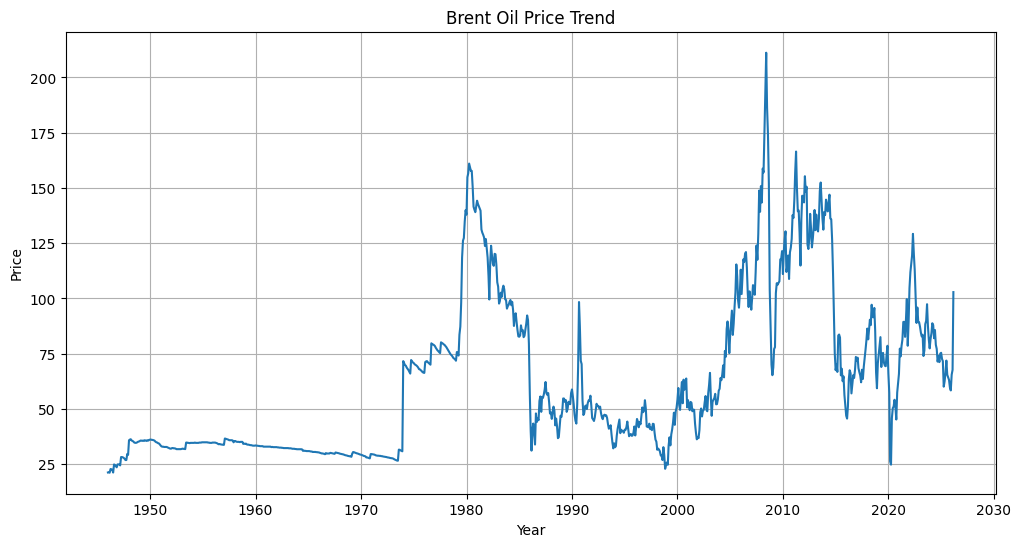

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    oil['Date'],
    oil['Value']
)

plt.title('Brent Oil Price Trend')
plt.xlabel('Year')
plt.ylabel('Price')

plt.grid(True)

plt.savefig(
    'figures/Part_C/Figure_1_Brent_Oil_Trend.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

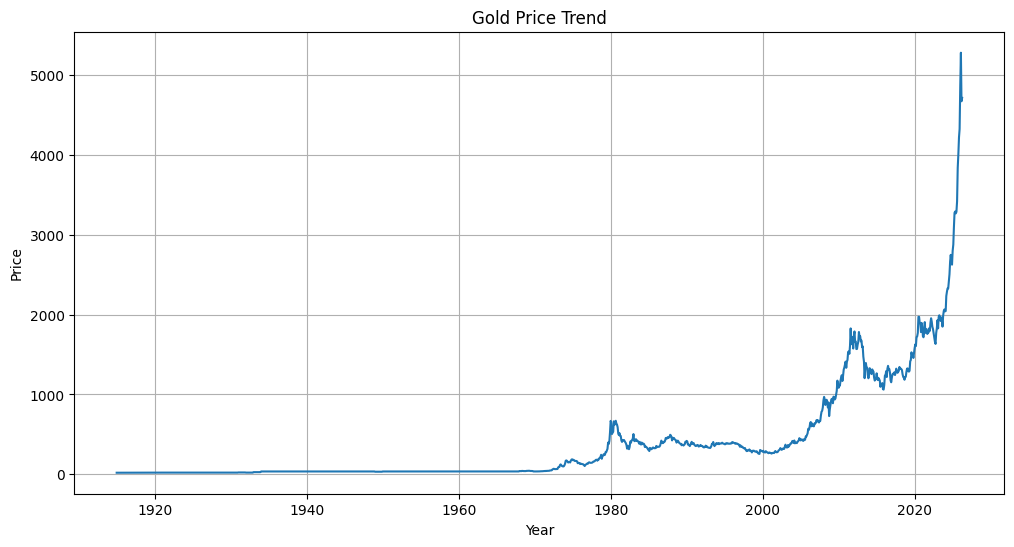

In [27]:
plt.figure(figsize=(12,6))

plt.plot(
    gold['Date'],
    gold['Value']
)

plt.title('Gold Price Trend')
plt.xlabel('Year')
plt.ylabel('Price')

plt.grid(True)

plt.savefig(
    'figures/Part_C/Figure_2_Gold_Trend.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

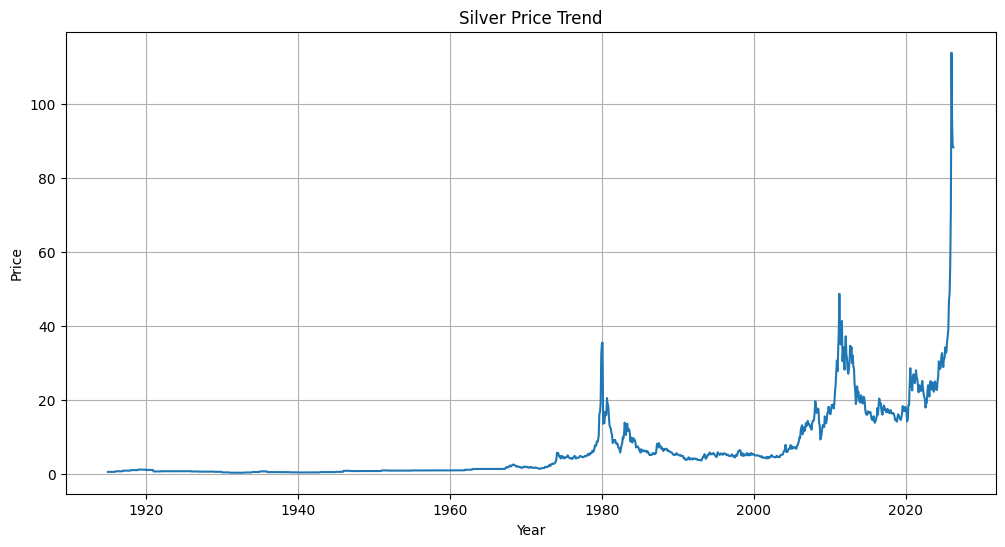

In [28]:
plt.figure(figsize=(12,6))

plt.plot(
    silver['Date'],
    silver['Value']
)

plt.title('Silver Price Trend')
plt.xlabel('Year')
plt.ylabel('Price')

plt.grid(True)

plt.savefig(
    'figures/Part_C/Figure_3_Silver_Trend.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

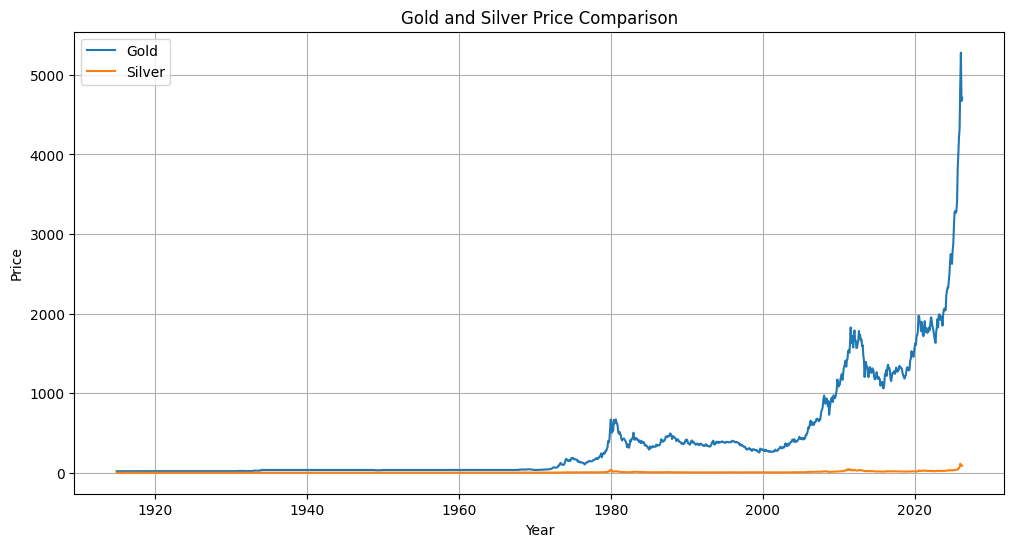

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    gold['Date'],
    gold['Value'],
    label='Gold'
)

plt.plot(
    silver['Date'],
    silver['Value'],
    label='Silver'
)

plt.title('Gold and Silver Price Comparison')
plt.xlabel('Year')
plt.ylabel('Price')

plt.legend()
plt.grid(True)

plt.savefig(
    'figures/Part_C/Figure_4_Gold_Silver_Comparison.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

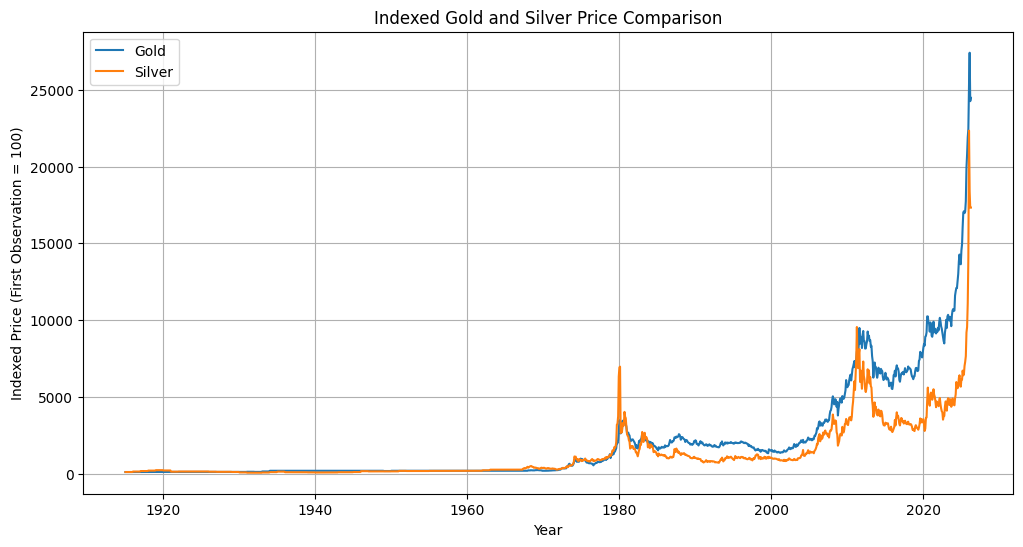

In [30]:
import matplotlib.pyplot as plt

# Sort by date
gold_plot = gold.sort_values('Date').copy()
silver_plot = silver.sort_values('Date').copy()

# Create index: first available value = 100
gold_plot['Indexed_Value'] = gold_plot['Value'] / gold_plot['Value'].iloc[0] * 100
silver_plot['Indexed_Value'] = silver_plot['Value'] / silver_plot['Value'].iloc[0] * 100

plt.figure(figsize=(12, 6))

plt.plot(
    gold_plot['Date'],
    gold_plot['Indexed_Value'],
    label='Gold'
)

plt.plot(
    silver_plot['Date'],
    silver_plot['Indexed_Value'],
    label='Silver'
)

plt.title('Indexed Gold and Silver Price Comparison')
plt.xlabel('Year')
plt.ylabel('Indexed Price (First Observation = 100)')

plt.legend()
plt.grid(True)

plt.savefig(
    'figures/Part_C/Figure_4_Gold_Silver_Comparison_Indexed.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

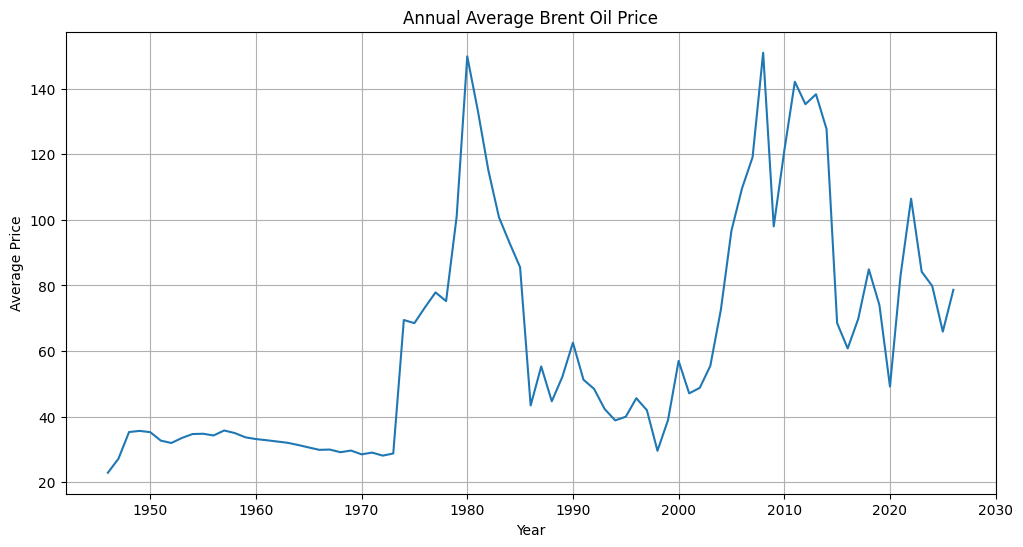

In [31]:
annual_oil = (
    oil.groupby('Year')['Value']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    annual_oil['Year'],
    annual_oil['Value']
)

plt.title('Annual Average Brent Oil Price')
plt.xlabel('Year')
plt.ylabel('Average Price')

plt.grid(True)

plt.savefig(
    'figures/Part_C/Figure_5_Annual_Brent_Oil_Average.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

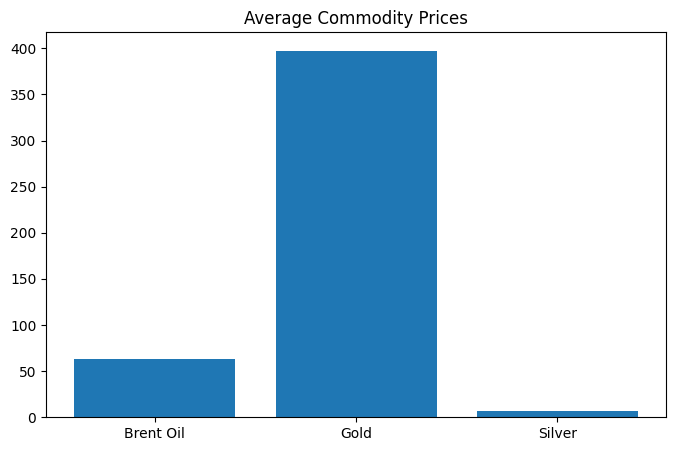

In [32]:
avg_df = pd.DataFrame({
    'Commodity':['Brent Oil','Gold','Silver'],
    'Average Value':[
        oil['Value'].mean(),
        gold['Value'].mean(),
        silver['Value'].mean()
    ]
})

plt.figure(figsize=(8,5))

plt.bar(
    avg_df['Commodity'],
    avg_df['Average Value']
)

plt.title('Average Commodity Prices')

plt.savefig(
    'figures/Part_C/Figure_6_Average_Commodity_Comparison.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

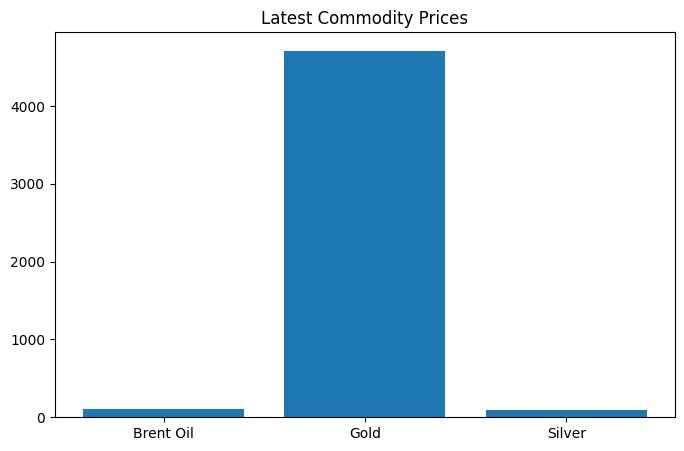

In [33]:
latest_df = pd.DataFrame({
    'Commodity':['Brent Oil','Gold','Silver'],
    'Latest Value':[
        oil.iloc[-1]['Value'],
        gold.iloc[-1]['Value'],
        silver.iloc[-1]['Value']
    ]
})

plt.figure(figsize=(8,5))

plt.bar(
    latest_df['Commodity'],
    latest_df['Latest Value']
)

plt.title('Latest Commodity Prices')

plt.savefig(
    'figures/Part_C/Figure_7_Latest_Commodity_Values.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

In [34]:
# ====================================
# PHASE 1 MERGE
# Brent Oil + Gold + Silver
# ====================================

oil_merge = oil[['Date','Value']].rename(
    columns={'Value':'Brent_Oil'}
)

gold_merge = gold[['Date','Value']].rename(
    columns={'Value':'Gold'}
)

silver_merge = silver[['Date','Value']].rename(
    columns={'Value':'Silver'}
)

commodity = oil_merge.merge(
    gold_merge,
    on='Date',
    how='inner'
)

commodity = commodity.merge(
    silver_merge,
    on='Date',
    how='inner'
)

commodity['Year'] = commodity['Date'].dt.year
commodity['Month'] = commodity['Date'].dt.month

commodity.head()

,Date,Brent_Oil,Gold,Silver,Year,Month
0,1946-01-01,21.23,35.0,0.8,1946,1
1,1946-02-01,21.35,35.0,0.8,1946,2
2,1946-03-01,21.11,35.0,0.8,1946,3
3,1946-04-01,22.79,35.0,0.8,1946,4
4,1946-05-01,22.67,35.0,0.8,1946,5


In [35]:
commodity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 963 entries, 0 to 962
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       963 non-null    datetime64[ns]
 1   Brent_Oil  963 non-null    float64       
 2   Gold       963 non-null    float64       
 3   Silver     963 non-null    float64       
 4   Year       963 non-null    int32         
 5   Month      963 non-null    int32         
dtypes: datetime64[ns](1), float64(3), int32(2)
memory usage: 37.7 KB


In [36]:
commodity.head()

,Date,Brent_Oil,Gold,Silver,Year,Month
0,1946-01-01,21.23,35.0,0.8,1946,1
1,1946-02-01,21.35,35.0,0.8,1946,2
2,1946-03-01,21.11,35.0,0.8,1946,3
3,1946-04-01,22.79,35.0,0.8,1946,4
4,1946-05-01,22.67,35.0,0.8,1946,5


In [37]:
commodity.to_csv(
    "cleaned_data/Commodity_Merged.csv",
    index=False
)

print("Commodity_Merged.csv saved.")

Commodity_Merged.csv saved.


In [38]:
commodity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 963 entries, 0 to 962
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       963 non-null    datetime64[ns]
 1   Brent_Oil  963 non-null    float64       
 2   Gold       963 non-null    float64       
 3   Silver     963 non-null    float64       
 4   Year       963 non-null    int32         
 5   Month      963 non-null    int32         
dtypes: datetime64[ns](1), float64(3), int32(2)
memory usage: 37.7 KB


In [39]:
commodity.describe()

,Date,Brent_Oil,Gold,Silver,Year,Month
count,963,963.000000,963.000000,963.000000,963.000000,963.000000
mean,1986-01-30 14:46:43.738317760,62.709470,536.533346,8.600275,1985.626168,6.485981
min,1946-01-01 00:00:00,21.110000,31.880000,0.720000,1946.000000,1.000000
25%,1966-01-16 12:00:00,33.360000,35.310000,1.297500,1966.000000,3.000000
50%,1986-02-01 00:00:00,50.120000,328.100000,5.000000,1986.000000,6.000000
75%,2006-02-15 00:00:00,82.380000,634.725000,13.140000,2006.000000,9.000000
max,2026-03-01 00:00:00,211.210000,5277.890000,113.952800,2026.000000,12.000000
std,NaN,35.964228,704.832658,10.530733,23.178450,3.457879


In [40]:
commodity.describe().to_csv(
    "tables/Table_5_Commodity_Merged_Statistics.csv"
)

In [41]:
table5 = commodity.describe()

table5.to_csv(
    "tables/Table_5_Commodity_Merged_Statistics.csv"
)

table5

,Date,Brent_Oil,Gold,Silver,Year,Month
count,963,963.000000,963.000000,963.000000,963.000000,963.000000
mean,1986-01-30 14:46:43.738317760,62.709470,536.533346,8.600275,1985.626168,6.485981
min,1946-01-01 00:00:00,21.110000,31.880000,0.720000,1946.000000,1.000000
25%,1966-01-16 12:00:00,33.360000,35.310000,1.297500,1966.000000,3.000000
50%,1986-02-01 00:00:00,50.120000,328.100000,5.000000,1986.000000,6.000000
75%,2006-02-15 00:00:00,82.380000,634.725000,13.140000,2006.000000,9.000000
max,2026-03-01 00:00:00,211.210000,5277.890000,113.952800,2026.000000,12.000000
std,NaN,35.964228,704.832658,10.530733,23.178450,3.457879


In [42]:
commodity.describe()

,Date,Brent_Oil,Gold,Silver,Year,Month
count,963,963.000000,963.000000,963.000000,963.000000,963.000000
mean,1986-01-30 14:46:43.738317760,62.709470,536.533346,8.600275,1985.626168,6.485981
min,1946-01-01 00:00:00,21.110000,31.880000,0.720000,1946.000000,1.000000
25%,1966-01-16 12:00:00,33.360000,35.310000,1.297500,1966.000000,3.000000
50%,1986-02-01 00:00:00,50.120000,328.100000,5.000000,1986.000000,6.000000
75%,2006-02-15 00:00:00,82.380000,634.725000,13.140000,2006.000000,9.000000
max,2026-03-01 00:00:00,211.210000,5277.890000,113.952800,2026.000000,12.000000
std,NaN,35.964228,704.832658,10.530733,23.178450,3.457879


In [43]:
import os

print(os.listdir("tables"))

['Table_5_Commodity_Merged_Statistics.csv', 'Table_1_Data_Summary.csv', 'Table_4_Top5_Years.csv', 'Table_3_Extreme_Values_Dates.csv', 'Table_2_Highest_Lowest_Average.csv']


In [44]:
table5 = commodity.describe()
table5

,Date,Brent_Oil,Gold,Silver,Year,Month
count,963,963.000000,963.000000,963.000000,963.000000,963.000000
mean,1986-01-30 14:46:43.738317760,62.709470,536.533346,8.600275,1985.626168,6.485981
min,1946-01-01 00:00:00,21.110000,31.880000,0.720000,1946.000000,1.000000
25%,1966-01-16 12:00:00,33.360000,35.310000,1.297500,1966.000000,3.000000
50%,1986-02-01 00:00:00,50.120000,328.100000,5.000000,1986.000000,6.000000
75%,2006-02-15 00:00:00,82.380000,634.725000,13.140000,2006.000000,9.000000
max,2026-03-01 00:00:00,211.210000,5277.890000,113.952800,2026.000000,12.000000
std,NaN,35.964228,704.832658,10.530733,23.178450,3.457879


In [45]:
import pandas as pd

swift = pd.ExcelFile(
    "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/swift_currency_tracker_research_ready_MAY_ADDED.xlsx"
)

swift.sheet_names

['Data_Summary',
 'Cleaned_Data',
 'report_month',
 'data_month',
 'source_report_name',
 'metric',
 'category',
 'rmb_global_rank',
 'notes',
 'MAY2026_GlobalPayments',
 'MAY2026_TradeFinance']

In [46]:
swift_data = pd.read_excel(
    "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/swift_currency_tracker_research_ready_MAY_ADDED.xlsx",
    sheet_name=None
)

for sheet in swift_data:
    print("\n")
    print("="*50)
    print(sheet)
    print("="*50)
    print(swift_data[sheet].head())



Data_Summary
  Swift Currency Tracker - Research Ready Summary Unnamed: 1
0                                             NaN        NaN
1                                            Rows        330
2                                         Columns         10
3                                             NaN        NaN
4                                       Variables        NaN


Cleaned_Data
   report_month     data_month source_report_name                metric  \
0  January 2026  December 2025        RMB Tracker  Global Payment Share   
1  January 2026  December 2025        RMB Tracker  Global Payment Share   
2  January 2026  December 2025        RMB Tracker  Global Payment Share   
3  January 2026  December 2025        RMB Tracker  Global Payment Share   
4  January 2026  December 2025        RMB Tracker  Global Payment Share   

           category currency_or_economy  value unit  rmb_global_rank   notes  
0  Currency Ranking                 USD  50.49    %              NaN  Rank

In [47]:
swift_clean = pd.read_excel(
    "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/swift_currency_tracker_research_ready_MAY_ADDED.xlsx",
    sheet_name="Cleaned_Data"
)

metric_summary = (
    swift_clean.groupby('metric')['value']
    .count()
    .reset_index()
    .rename(columns={'value':'Count'})
)

metric_summary

,metric,Count
0,All Currencies MoM Payment Growth,2
1,FX Spot Currency Ranking,0
2,FX Spot Economies (RMB),24
3,Global Payment Share,80
4,International Payment Share (ex-Eurozone),80
5,Offshore RMB by Economy,60
6,RMB MoM Payment Growth,2
7,Trade Finance Share,40


In [48]:
metric_summary.to_csv(
    "tables/Table_6_SWIFT_Metric_Summary.csv",
    index=False
)

In [49]:
source_summary = (
    swift_clean.groupby('source_report_name')
    .size()
    .reset_index(name='Count')
)

source_summary

,source_report_name,Count
0,Global Currency Tracker,164
1,RMB Tracker,166


In [50]:
source_summary.to_csv(
    "tables/Table_7_SWIFT_Source_Summary.csv",
    index=False
)

In [51]:
source_summary.to_csv(
    "tables/Table_7_SWIFT_Source_Summary.csv",
    index=False
)

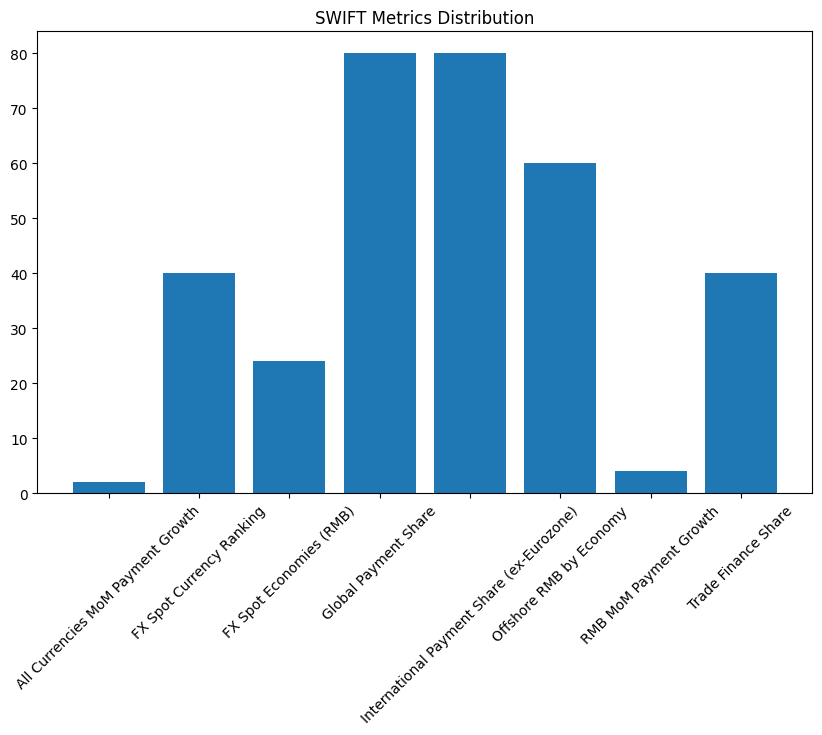

In [52]:
import matplotlib.pyplot as plt

metric_summary = (
    swift_clean.groupby('metric')
    .size()
    .reset_index(name='Count')
)

plt.figure(figsize=(10,6))

plt.bar(
    metric_summary['metric'],
    metric_summary['Count']
)

plt.xticks(rotation=45)
plt.title("SWIFT Metrics Distribution")

plt.savefig(
    "figures/Part_D/Figure_8_SWIFT_Metrics_Distribution.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

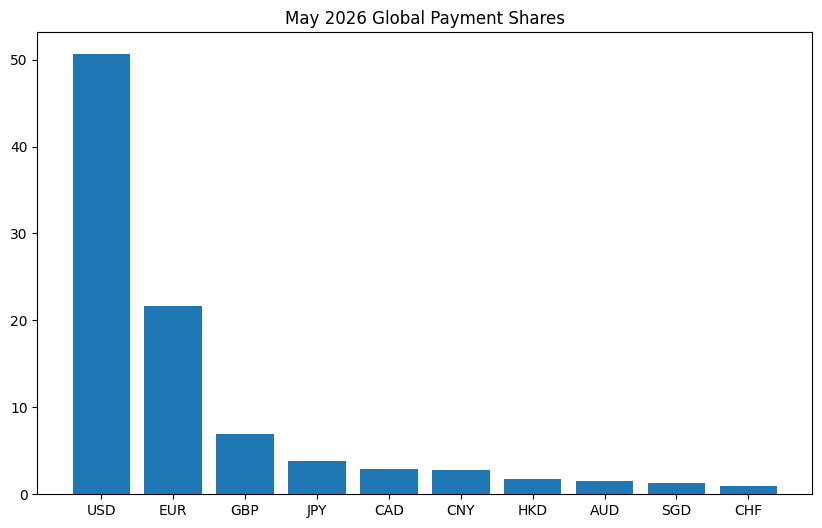

In [53]:
may_global = pd.read_excel(
    "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/swift_currency_tracker_research_ready_MAY_ADDED.xlsx",
    sheet_name="MAY2026_GlobalPayments"
)

plt.figure(figsize=(10,6))

plt.bar(
    may_global['Currency'],
    may_global['Share_%']
)

plt.title("May 2026 Global Payment Shares")

plt.savefig(
    "figures/Part_D/Figure_9_Global_Payment_Shares.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

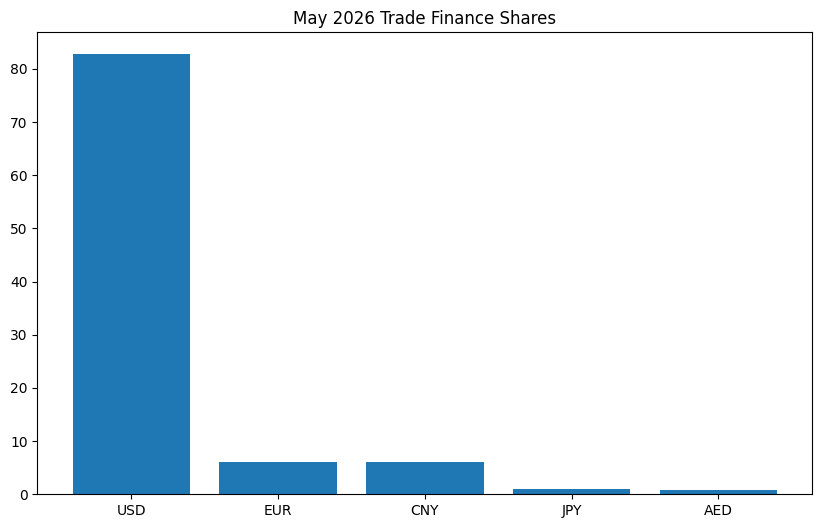

In [54]:
may_trade = pd.read_excel(
    "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/swift_currency_tracker_research_ready_MAY_ADDED.xlsx",
    sheet_name="MAY2026_TradeFinance"
)

plt.figure(figsize=(10,6))

plt.bar(
    may_trade['Currency'],
    may_trade['Share_%']
)

plt.title("May 2026 Trade Finance Shares")

plt.savefig(
    "figures/Part_D/Figure_10_Trade_Finance_Shares.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [55]:
comparison = pd.DataFrame({
    'Commodity':['Brent Oil','Gold','Silver'],
    'Historical Average':[
        oil['Value'].mean(),
        gold['Value'].mean(),
        silver['Value'].mean()
    ],
    'Latest Value':[
        oil.iloc[-1]['Value'],
        gold.iloc[-1]['Value'],
        silver.iloc[-1]['Value']
    ]
})

comparison['Difference'] = (
    comparison['Latest Value']
    - comparison['Historical Average']
)

comparison

,Commodity,Historical Average,Latest Value,Difference
0,Brent Oil,62.709470,102.8600,40.150530
1,Gold,397.551394,4712.8906,4315.339206
2,Silver,6.421755,88.3600,81.938245


In [56]:
comparison.to_csv(
    "tables/Table_8_Latest_vs_Historical.csv",
    index=False
)

In [57]:
volatility = pd.DataFrame({
    'Commodity':['Brent Oil','Gold','Silver'],
    'Standard Deviation':[
        oil['Value'].std(),
        gold['Value'].std(),
        silver['Value'].std()
    ]
})

volatility

,Commodity,Standard Deviation
0,Brent Oil,35.964228
1,Gold,651.394525
2,Silver,9.896696


In [58]:
volatility.to_csv(
    "tables/Table_9_Volatility.csv",
    index=False
)

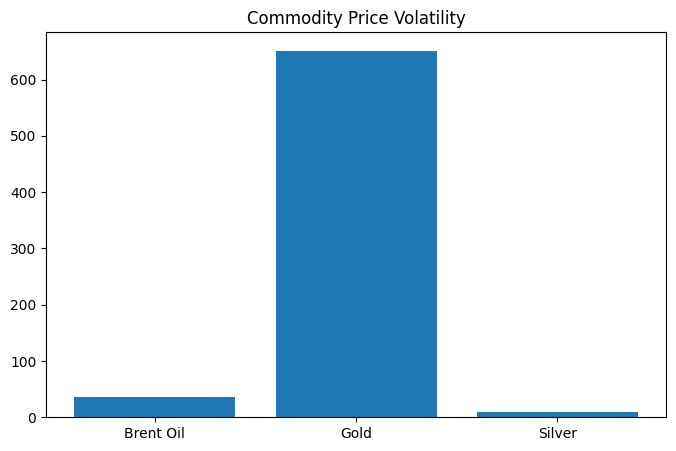

In [59]:
plt.figure(figsize=(8,5))

plt.bar(
    volatility['Commodity'],
    volatility['Standard Deviation']
)

plt.title('Commodity Price Volatility')

plt.savefig(
    'figures/Part_E/Figure_11_Volatility_Comparison.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

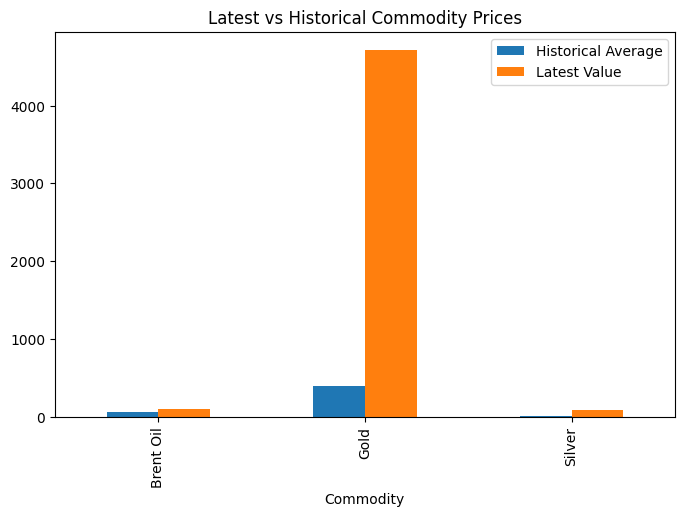

In [60]:
comparison_plot = comparison.set_index('Commodity')

comparison_plot[
    ['Historical Average','Latest Value']
].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Latest vs Historical Commodity Prices')

plt.savefig(
    'figures/Part_E/Figure_12_Latest_vs_Historical.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

In [61]:
# =========================
# BONUS B1: Yearly % Change
# =========================

annual_commodity = (
    commodity.groupby('Year')[['Brent_Oil', 'Gold', 'Silver']]
    .mean()
    .reset_index()
)

annual_pct_change = annual_commodity.copy()

annual_pct_change[['Brent_Oil_%Change', 'Gold_%Change', 'Silver_%Change']] = (
    annual_pct_change[['Brent_Oil', 'Gold', 'Silver']]
    .pct_change() * 100
)

annual_pct_change.to_csv(
    "tables/Bonus_B1_Yearly_Percentage_Change.csv",
    index=False
)

annual_pct_change.head()

,Year,Brent_Oil,Gold,Silver,Brent_Oil_%Change,Gold_%Change,Silver_%Change
0,1946,22.898333,35.00,0.80,NaN,NaN,NaN
1,1947,27.201667,35.00,0.72,18.793216,0.000000,-10.000000
2,1948,35.307500,35.00,0.74,29.799032,0.000000,2.777778
3,1949,35.647500,31.88,0.72,0.962968,-8.914286,-2.702703
4,1950,35.277500,35.00,0.74,-1.037941,9.786700,2.777778


In [62]:
# =========================
# BONUS B2: Correlation Table
# =========================

corr_table = annual_commodity[['Brent_Oil', 'Gold', 'Silver']].corr()

corr_table.to_csv(
    "tables/Bonus_B2_Correlation_Table.csv"
)

corr_table

,Brent_Oil,Gold,Silver
Brent_Oil,1.000000,0.455984,0.507748
Gold,0.455984,1.000000,0.952709
Silver,0.507748,0.952709,1.000000


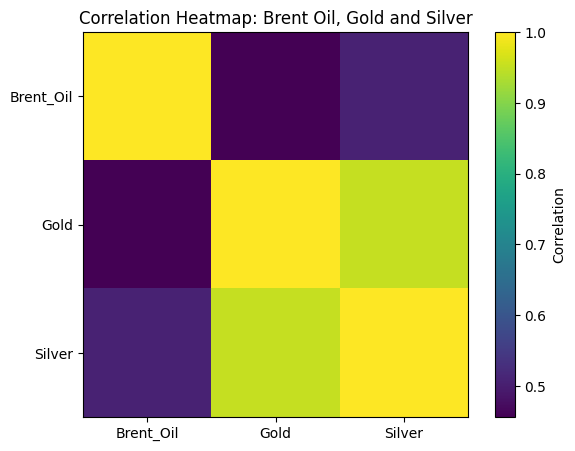

In [63]:
# =========================
# BONUS B3: Correlation Heatmap PDF
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.imshow(corr_table)
plt.xticks(range(len(corr_table.columns)), corr_table.columns)
plt.yticks(range(len(corr_table.columns)), corr_table.columns)
plt.colorbar(label='Correlation')

plt.title('Correlation Heatmap: Brent Oil, Gold and Silver')

plt.savefig(
    "figures/Bonus/Bonus_B3_Correlation_Heatmap.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

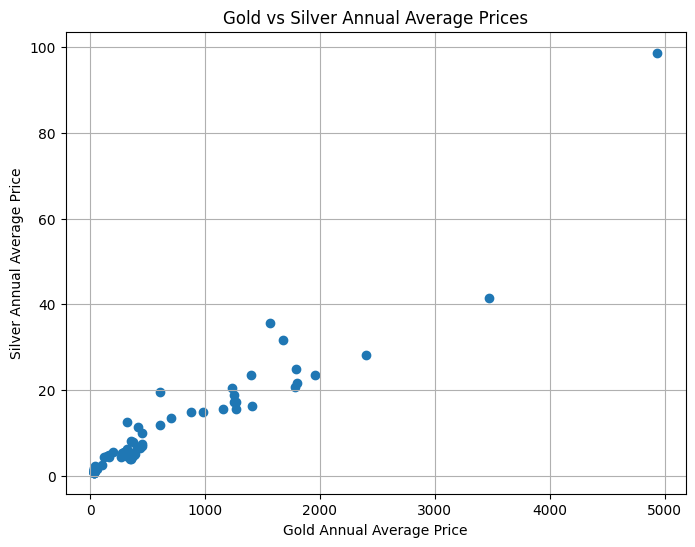

In [64]:
plt.figure(figsize=(8,6))

plt.scatter(
    annual_commodity['Gold'],
    annual_commodity['Silver']
)

plt.title('Gold vs Silver Annual Average Prices')
plt.xlabel('Gold Annual Average Price')
plt.ylabel('Silver Annual Average Price')
plt.grid(True)

plt.savefig(
    "figures/Bonus/Bonus_B4_Gold_Silver_Scatter.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

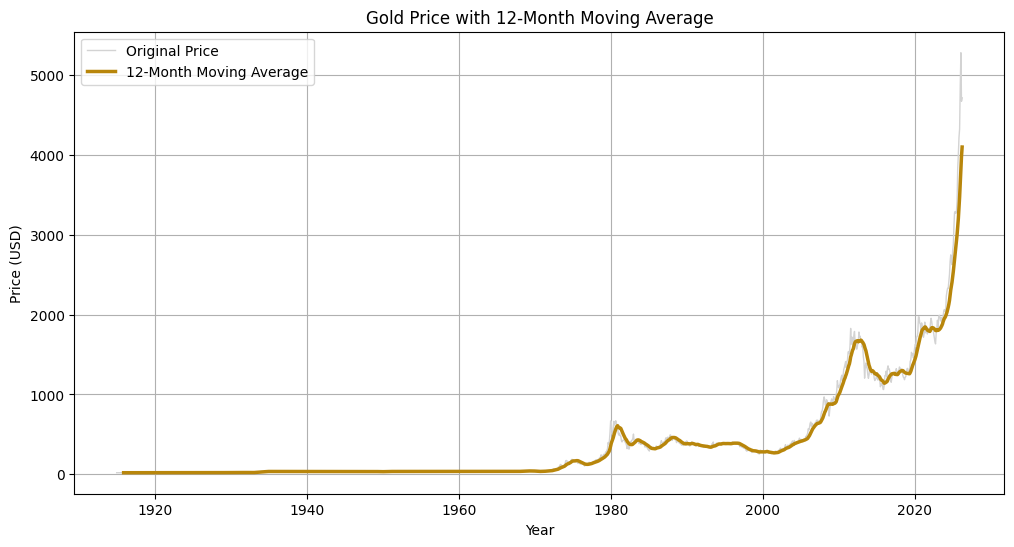

In [65]:
import matplotlib.pyplot as plt

gold_ma = gold.sort_values('Date').copy()

# 12-month Moving Average
gold_ma['MA_12'] = gold_ma['Value'].rolling(window=12).mean()

plt.figure(figsize=(12,6))

# Original price
plt.plot(
    gold_ma['Date'],
    gold_ma['Value'],
    color='lightgray',
    linewidth=1,
    label='Original Price'
)

# Smoothed trend
plt.plot(
    gold_ma['Date'],
    gold_ma['MA_12'],
    color='darkgoldenrod',
    linewidth=2.5,
    label='12-Month Moving Average'
)

plt.title('Gold Price with 12-Month Moving Average')
plt.xlabel('Year')
plt.ylabel('Price (USD)')

plt.grid(True)
plt.legend()

plt.savefig(
    'figures/Part_C/Figure_Gold_Moving_Average.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

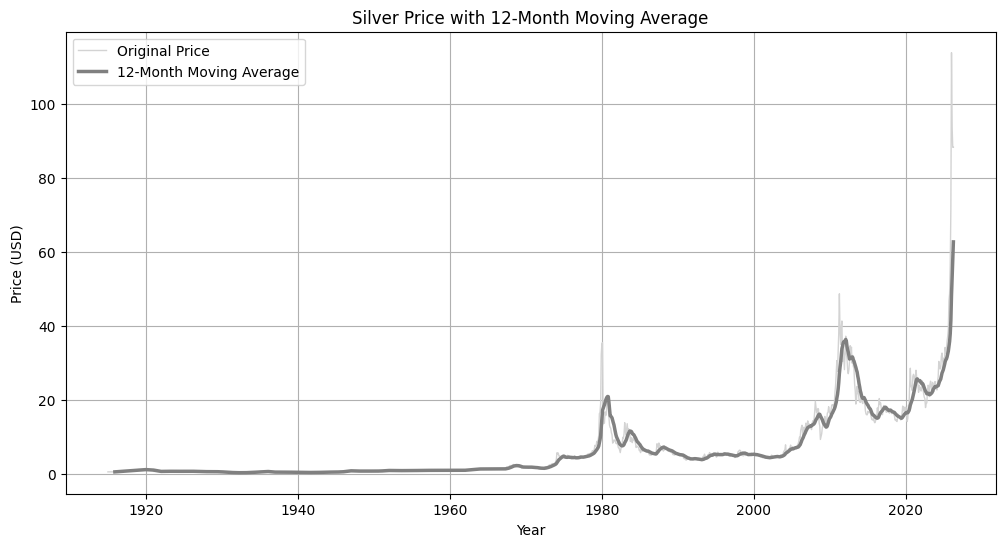

In [66]:
silver_ma = silver.sort_values('Date').copy()

silver_ma['MA_12'] = silver_ma['Value'].rolling(window=12).mean()

plt.figure(figsize=(12,6))

plt.plot(
    silver_ma['Date'],
    silver_ma['Value'],
    color='lightgray',
    linewidth=1,
    label='Original Price'
)

plt.plot(
    silver_ma['Date'],
    silver_ma['MA_12'],
    color='gray',
    linewidth=2.5,
    label='12-Month Moving Average'
)

plt.title('Silver Price with 12-Month Moving Average')
plt.xlabel('Year')
plt.ylabel('Price (USD)')

plt.grid(True)
plt.legend()

plt.savefig(
    'figures/Part_C/Figure_Silver_Moving_Average.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

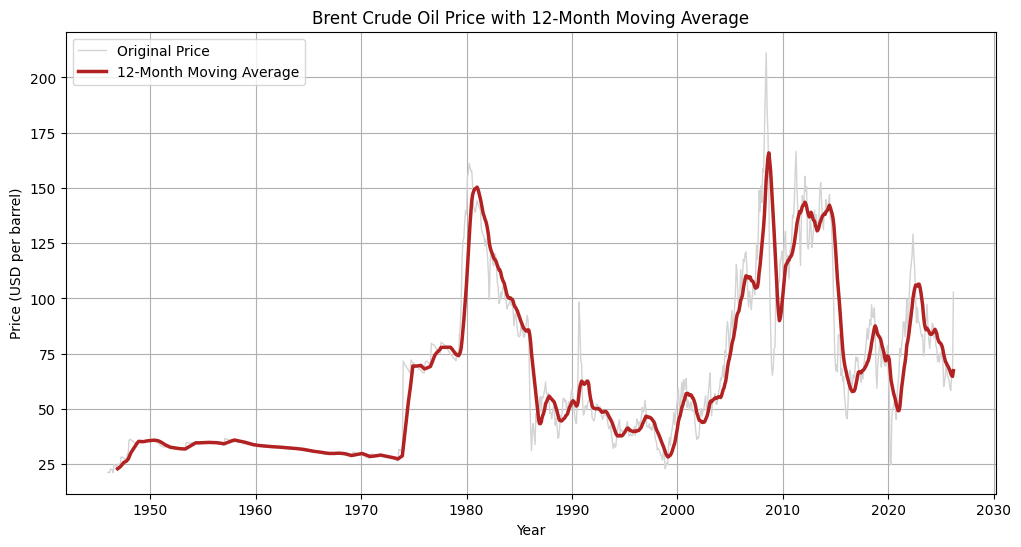

In [67]:
oil_ma = oil.sort_values('Date').copy()

oil_ma['MA_12'] = oil_ma['Value'].rolling(window=12).mean()

plt.figure(figsize=(12,6))

plt.plot(
    oil_ma['Date'],
    oil_ma['Value'],
    color='lightgray',
    linewidth=1,
    label='Original Price'
)

plt.plot(
    oil_ma['Date'],
    oil_ma['MA_12'],
    color='firebrick',
    linewidth=2.5,
    label='12-Month Moving Average'
)

plt.title('Brent Crude Oil Price with 12-Month Moving Average')
plt.xlabel('Year')
plt.ylabel('Price (USD per barrel)')

plt.grid(True)
plt.legend()

plt.savefig(
    'figures/Part_C/Figure_Oil_Moving_Average.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

In [68]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'os', 'folders', 'folder', '_i2', '_exit_code', 'yf', 'btc', '_i3', 'dirname', 'filenames', 'filename', '_i4', 'pd', 'oil', 'gold', 'silver', 'swift_file', '_i5', '_5', '_i6', '_6', '_i7', '_7', '_i8', '_8', '_i9', 'cols', 'c', '_9', '_i10', '_10', '_i11', '_11', '_i12', 'df', '_i13', '_i14', '_i15', 'summary', '_15', '_i16', '_i17', 'summary_stats', '_17', '_i18', '_i19', 'extremes', 'name', 'max_row', 'min_row', '_19', '_i20', '_i21', 'top5_years', 'top_oil', 'top_gold', 'top_silver', 'top5', '_21', '_i22', '_i23', '_23', '_i24', '_24', '_i25', '_25', '_i26', 'plt', '_i27', '_i28', '_i29', '_i30', 'gold_plot', 'silver_plot', '_i31', 'annual_oil', '_i32', 'avg_df', '_i33', 'latest_df', '_i34', 'oil_merge', 'gold_merge', 'silver_merge', 'commodity', '_34', '_i35', '_i36', 

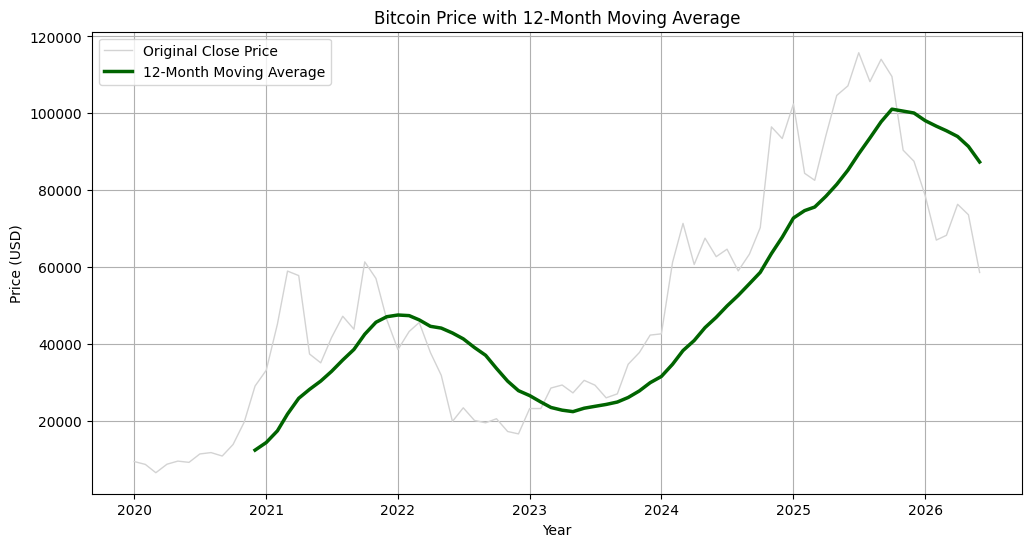

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# Make a copy
bitcoin_ma = btc.copy()

# Convert Date to datetime
bitcoin_ma['Date'] = pd.to_datetime(bitcoin_ma['Date'])

# Sort by Date
bitcoin_ma = bitcoin_ma.sort_values('Date')

# Calculate 12-month Moving Average
bitcoin_ma['MA_12'] = bitcoin_ma['Close'].rolling(window=12).mean()

# Plot
plt.figure(figsize=(12,6))

# Original price
plt.plot(
    bitcoin_ma['Date'],
    bitcoin_ma['Close'],
    color='lightgray',
    linewidth=1,
    label='Original Close Price'
)

# Moving Average
plt.plot(
    bitcoin_ma['Date'],
    bitcoin_ma['MA_12'],
    color='darkgreen',
    linewidth=2.5,
    label='12-Month Moving Average'
)

plt.title('Bitcoin Price with 12-Month Moving Average')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend()

plt.savefig(
    'figures/Part_C/Figure_Bitcoin_Moving_Average.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures/Part_C", exist_ok=True)

# Load SWIFT cleaned data
swift_path = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/swift_currency_tracker_research_ready_MAY_ADDED.xlsx"

swift = pd.read_excel(swift_path, sheet_name="Cleaned_Data")

# Check columns
print(swift.columns)
print(swift.head())

Index(['report_month', 'data_month', 'source_report_name', 'metric',
       'category', 'currency_or_economy', 'value', 'unit', 'rmb_global_rank',
       'notes'],
      dtype='object')
   report_month     data_month source_report_name                metric  \
0  January 2026  December 2025        RMB Tracker  Global Payment Share   
1  January 2026  December 2025        RMB Tracker  Global Payment Share   
2  January 2026  December 2025        RMB Tracker  Global Payment Share   
3  January 2026  December 2025        RMB Tracker  Global Payment Share   
4  January 2026  December 2025        RMB Tracker  Global Payment Share   

           category currency_or_economy  value unit  rmb_global_rank   notes  
0  Currency Ranking                 USD  50.49    %              NaN  Rank 1  
1  Currency Ranking                 EUR  21.90    %              NaN  Rank 2  
2  Currency Ranking                 GBP   6.73    %              NaN  Rank 3  
3  Currency Ranking                 CAD   3.44 

In [71]:
# Standardize text columns
swift["metric"] = swift["metric"].astype(str).str.strip()
swift["currency_or_economy"] = swift["currency_or_economy"].astype(str).str.strip()

# Select major currencies
major_currencies = ["USD", "EUR", "GBP", "JPY", "CNY"]

# Select global payment shares
global_payments = swift[
    (swift["metric"].str.contains("Global payments", case=False, na=False)) &
    (swift["currency_or_economy"].isin(major_currencies))
].copy()

# Select trade finance shares
trade_finance = swift[
    (swift["metric"].str.contains("Trade finance", case=False, na=False)) &
    (swift["currency_or_economy"].isin(major_currencies))
].copy()

# Keep latest available month for each metric/currency
global_latest = (
    global_payments
    .sort_values("data_month")
    .groupby("currency_or_economy")
    .tail(1)
    [["currency_or_economy", "value"]]
    .rename(columns={"value": "Global Payments"})
)

trade_latest = (
    trade_finance
    .sort_values("data_month")
    .groupby("currency_or_economy")
    .tail(1)
    [["currency_or_economy", "value"]]
    .rename(columns={"value": "Trade Finance"})
)

# Merge
comparison = pd.merge(
    global_latest,
    trade_latest,
    on="currency_or_economy",
    how="inner"
)

# Order currencies
comparison["currency_or_economy"] = pd.Categorical(
    comparison["currency_or_economy"],
    categories=major_currencies,
    ordered=True
)

comparison = comparison.sort_values("currency_or_economy")

print(comparison)

Empty DataFrame
Columns: [currency_or_economy, Global Payments, Trade Finance]
Index: []


In [72]:
import pandas as pd

swift_path = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/swift_currency_tracker_research_ready_MAY_ADDED.xlsx"

swift = pd.read_excel(swift_path, sheet_name="Cleaned_Data")

print(swift.columns)
print(swift["metric"].unique())
print(swift["category"].unique())
print(swift.head(20))

Index(['report_month', 'data_month', 'source_report_name', 'metric',
       'category', 'currency_or_economy', 'value', 'unit', 'rmb_global_rank',
       'notes'],
      dtype='object')
['Global Payment Share' 'International Payment Share (ex-Eurozone)'
 'RMB MoM Payment Growth' 'All Currencies MoM Payment Growth'
 'Offshore RMB by Economy' 'Trade Finance Share'
 'FX Spot Currency Ranking' 'FX Spot Economies (RMB)']
['Currency Ranking' 'RMB Activity' 'Market Activity' 'Offshore Economies'
 'FX Spot']
    report_month     data_month source_report_name                metric  \
0   January 2026  December 2025        RMB Tracker  Global Payment Share   
1   January 2026  December 2025        RMB Tracker  Global Payment Share   
2   January 2026  December 2025        RMB Tracker  Global Payment Share   
3   January 2026  December 2025        RMB Tracker  Global Payment Share   
4   January 2026  December 2025        RMB Tracker  Global Payment Share   
5   January 2026  December 2025       

/tmp/ipykernel_23/534689888.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  swift["data_month"] = pd.to_datetime(swift["data_month"])


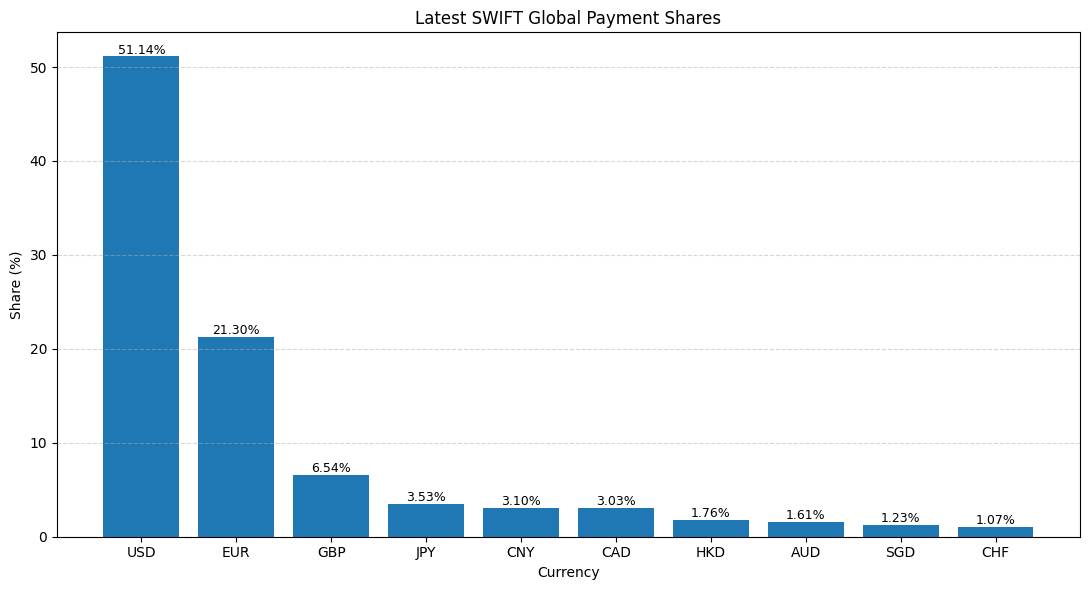

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures/Part_C", exist_ok=True)

swift_path = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/swift_currency_tracker_research_ready_MAY_ADDED.xlsx"

swift = pd.read_excel(swift_path, sheet_name="Cleaned_Data")

swift["data_month"] = pd.to_datetime(swift["data_month"])
swift["metric"] = swift["metric"].astype(str).str.strip()
swift["currency_or_economy"] = swift["currency_or_economy"].astype(str).str.strip()

major = ["USD", "EUR", "GBP", "JPY", "CAD", "CNY", "HKD", "AUD", "SGD", "CHF"]

payments = swift[
    (swift["metric"] == "Global Payment Share") &
    (swift["currency_or_economy"].isin(major))
].copy()

payments_latest = (
    payments.sort_values("data_month")
    .groupby("currency_or_economy")
    .tail(1)
    .sort_values("value", ascending=False)
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    payments_latest["currency_or_economy"],
    payments_latest["value"]
)

plt.title("Latest SWIFT Global Payment Shares")
plt.xlabel("Currency")
plt.ylabel("Share (%)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "figures/Part_C/Figure_SWIFT_Global_Payment_Shares.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

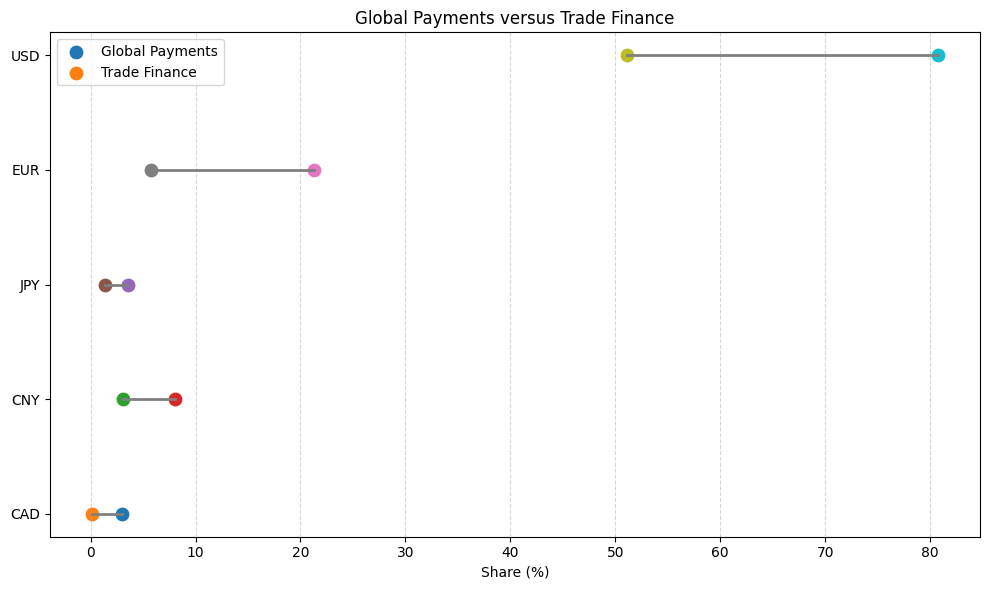

In [74]:
trade = swift[
    (swift["metric"] == "Trade Finance Share") &
    (swift["currency_or_economy"].isin(major))
].copy()

trade_latest = (
    trade.sort_values("data_month")
    .groupby("currency_or_economy")
    .tail(1)
)

comparison = pd.merge(
    payments_latest[["currency_or_economy", "value"]],
    trade_latest[["currency_or_economy", "value"]],
    on="currency_or_economy",
    suffixes=("_Payments", "_Trade")
)

comparison = comparison.sort_values("value_Payments")

plt.figure(figsize=(10, 6))

for i, row in enumerate(comparison.itertuples()):
    plt.plot(
        [row.value_Payments, row.value_Trade],
        [i, i],
        color="gray",
        linewidth=2
    )

    plt.scatter(
        row.value_Payments,
        i,
        s=80,
        label="Global Payments" if i == 0 else ""
    )

    plt.scatter(
        row.value_Trade,
        i,
        s=80,
        label="Trade Finance" if i == 0 else ""
    )

plt.yticks(range(len(comparison)), comparison["currency_or_economy"])
plt.xlabel("Share (%)")
plt.title("Global Payments versus Trade Finance")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/Part_C/Figure_SWIFT_Payments_vs_Trade.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("figures/Part_C", exist_ok=True)

crypto_path = "/kaggle/input/datasets/maryammoghaddasbayat/set2-crypto/Crypto_Market_Dataset_2025_2026-2.xlsx"

sheet_map = {
    "SUI": "sui-usd-max",
    "PEPE": "pepe-usd-max",
    "ONDO": "ondo-usd-max",
    "KASPA": "KAS-usd-max"
}

crypto_list = []

for asset, sheet in sheet_map.items():
    temp = pd.read_excel(crypto_path, sheet_name=sheet)
    
    temp["Date"] = pd.to_datetime(temp["Clean_Date"])
    
    # Standardize column names
    if asset == "SUI":
        temp = temp.rename(columns={
            "Price_USD": "Price",
            "Market_Cap_USD": "Market_Cap",
            "Volume_USD": "Volume"
        })
    else:
        temp = temp.rename(columns={
            "price": "Price",
            "market_cap": "Market_Cap",
            "total_volume": "Volume"
        })
    
    temp = temp[["Date", "Price", "Market_Cap", "Volume"]].copy()
    temp["Asset"] = asset
    
    crypto_list.append(temp)

crypto_all = pd.concat(crypto_list, ignore_index=True)

crypto_all.head()

,Date,Price,Market_Cap,Volume,Asset
0,2025-01-01,4.118603,1.206175e+10,9.583455e+08,SUI
1,2025-01-02,4.269667,1.283769e+10,7.118013e+08,SUI
2,2025-01-03,4.351739,1.309511e+10,9.110769e+08,SUI
3,2025-01-04,4.959401,1.496097e+10,1.328921e+09,SUI
4,2025-01-05,5.297820,1.592683e+10,2.282690e+09,SUI


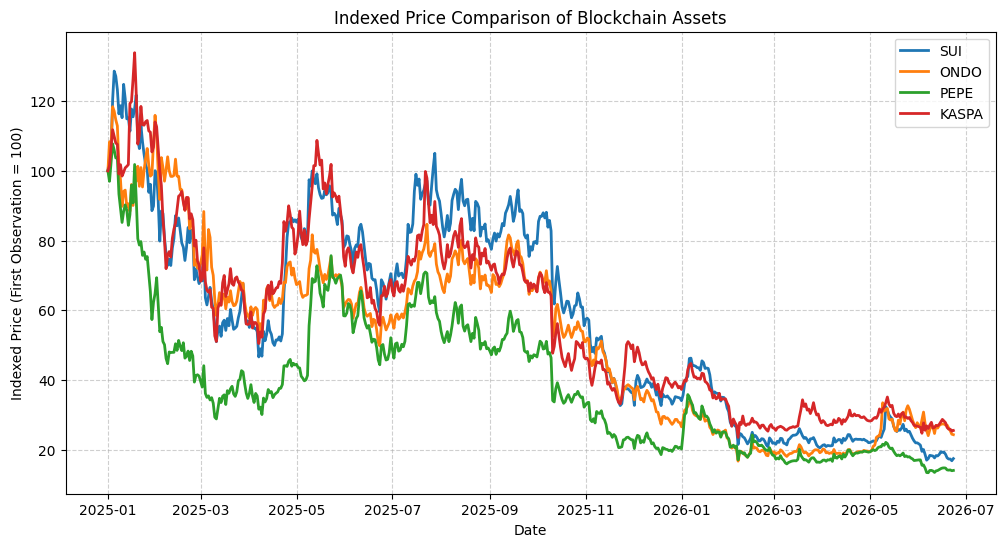

In [76]:
indexed_prices = []

for asset in crypto_all["Asset"].unique():
    temp = crypto_all[crypto_all["Asset"] == asset].sort_values("Date").copy()
    temp["Indexed_Price"] = temp["Price"] / temp["Price"].iloc[0] * 100
    indexed_prices.append(temp)

indexed_prices = pd.concat(indexed_prices)

plt.figure(figsize=(12,6))

for asset in ["SUI", "ONDO", "PEPE", "KASPA"]:
    temp = indexed_prices[indexed_prices["Asset"] == asset]
    plt.plot(
        temp["Date"],
        temp["Indexed_Price"],
        linewidth=2,
        label=asset
    )

plt.title("Indexed Price Comparison of Blockchain Assets")
plt.xlabel("Date")
plt.ylabel("Indexed Price (First Observation = 100)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.savefig(
    "figures/Part_C/Figure_Blockchain_Indexed_Price_Comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

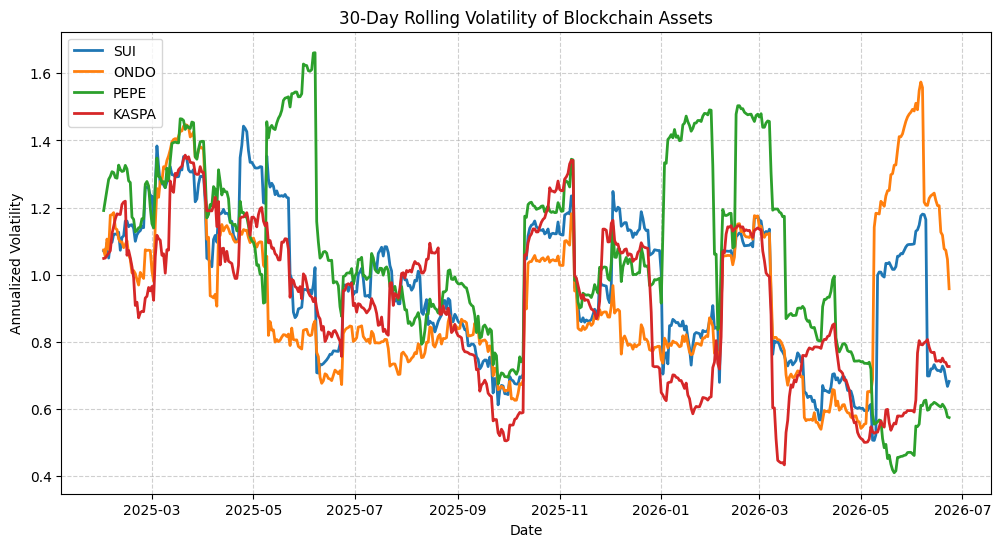

In [77]:
volatility_list = []

for asset in crypto_all["Asset"].unique():
    temp = crypto_all[crypto_all["Asset"] == asset].sort_values("Date").copy()
    temp["Daily_Return"] = temp["Price"].pct_change()
    temp["Rolling_30D_Volatility"] = temp["Daily_Return"].rolling(window=30).std() * np.sqrt(365)
    volatility_list.append(temp)

crypto_volatility = pd.concat(volatility_list)

plt.figure(figsize=(12,6))

for asset in ["SUI", "ONDO", "PEPE", "KASPA"]:
    temp = crypto_volatility[crypto_volatility["Asset"] == asset]
    plt.plot(
        temp["Date"],
        temp["Rolling_30D_Volatility"],
        linewidth=2,
        label=asset
    )

plt.title("30-Day Rolling Volatility of Blockchain Assets")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.savefig(
    "figures/Part_C/Figure_Blockchain_Rolling_Volatility.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

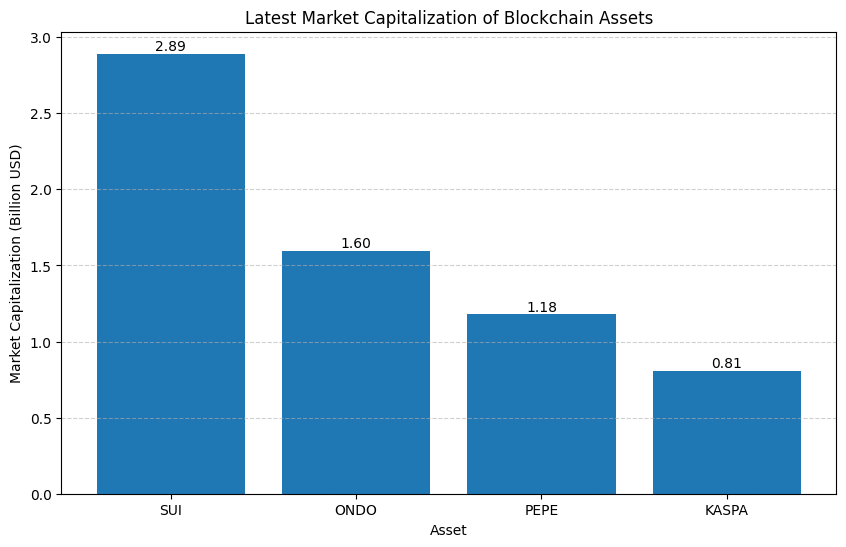

In [78]:
latest_market_cap = (
    crypto_all
    .sort_values("Date")
    .groupby("Asset")
    .tail(1)
    [["Asset", "Market_Cap"]]
    .copy()
)

latest_market_cap["Market_Cap_Billion_USD"] = latest_market_cap["Market_Cap"] / 1e9
latest_market_cap = latest_market_cap.sort_values("Market_Cap_Billion_USD", ascending=False)

plt.figure(figsize=(10,6))

bars = plt.bar(
    latest_market_cap["Asset"],
    latest_market_cap["Market_Cap_Billion_USD"]
)

plt.title("Latest Market Capitalization of Blockchain Assets")
plt.xlabel("Asset")
plt.ylabel("Market Capitalization (Billion USD)")
plt.grid(axis="y", linestyle="--", alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.savefig(
    "figures/Part_C/Figure_Blockchain_Market_Cap_Comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

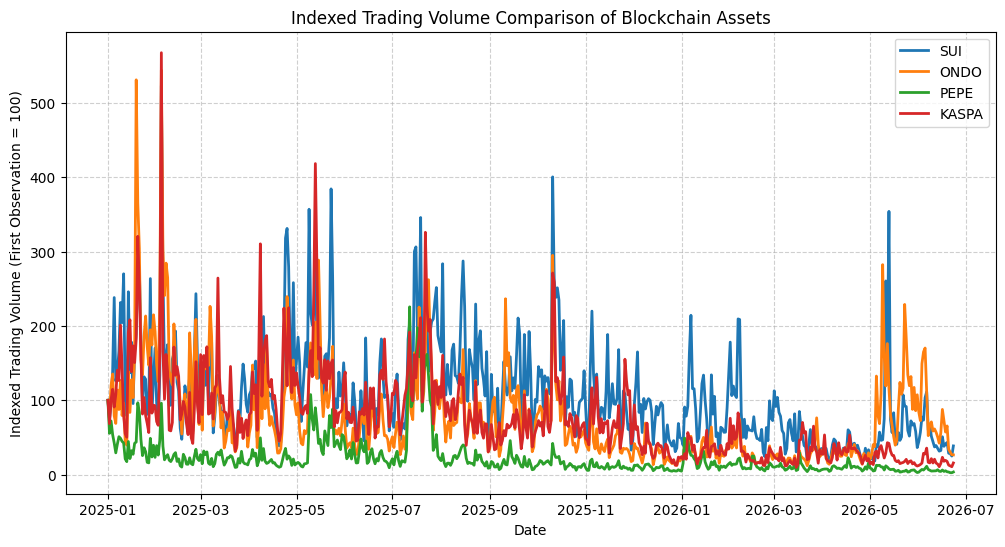

In [79]:
volume_indexed_list = []

for asset in crypto_all["Asset"].unique():
    temp = crypto_all[crypto_all["Asset"] == asset].sort_values("Date").copy()
    temp["Indexed_Volume"] = temp["Volume"] / temp["Volume"].iloc[0] * 100
    volume_indexed_list.append(temp)

crypto_volume_indexed = pd.concat(volume_indexed_list)

plt.figure(figsize=(12,6))

for asset in ["SUI", "ONDO", "PEPE", "KASPA"]:
    temp = crypto_volume_indexed[crypto_volume_indexed["Asset"] == asset]
    plt.plot(
        temp["Date"],
        temp["Indexed_Volume"],
        linewidth=2,
        label=asset
    )

plt.title("Indexed Trading Volume Comparison of Blockchain Assets")
plt.xlabel("Date")
plt.ylabel("Indexed Trading Volume (First Observation = 100)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.savefig(
    "figures/Part_C/Figure_Blockchain_Indexed_Volume_Comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures/Part_C", exist_ok=True)

def trendline_forecast(
    data,
    date_col,
    value_col,
    asset_name,
    forecast_months=12,
    output_path=None
):
    """
    Creates a simple linear trendline forecast.
    This is only an estimate and should not be interpreted as a guaranteed prediction.
    """

    df_forecast = data[[date_col, value_col]].dropna().copy()
    df_forecast[date_col] = pd.to_datetime(df_forecast[date_col])
    df_forecast = df_forecast.sort_values(date_col)

    # Create numeric time index
    df_forecast["t"] = np.arange(len(df_forecast))

    # Fit linear trendline
    slope, intercept = np.polyfit(df_forecast["t"], df_forecast[value_col], 1)

    # Historical trend
    df_forecast["Trendline"] = intercept + slope * df_forecast["t"]

    # Future dates
    last_date = df_forecast[date_col].max()
    future_dates = pd.date_range(
        start=last_date + pd.DateOffset(months=1),
        periods=forecast_months,
        freq="MS"
    )

    future_t = np.arange(len(df_forecast), len(df_forecast) + forecast_months)
    future_values = intercept + slope * future_t

    future_df = pd.DataFrame({
        date_col: future_dates,
        "Forecast": future_values
    })

    # Plot
    plt.figure(figsize=(12, 6))

    plt.plot(
        df_forecast[date_col],
        df_forecast[value_col],
        color="lightgray",
        linewidth=1,
        label="Historical Price"
    )

    plt.plot(
        df_forecast[date_col],
        df_forecast["Trendline"],
        linewidth=2.5,
        label="Historical Linear Trend"
    )

    plt.plot(
        future_df[date_col],
        future_df["Forecast"],
        linestyle="--",
        linewidth=2.5,
        label="Estimated Forecast"
    )

    plt.axvline(
        x=last_date,
        linestyle=":",
        linewidth=2,
        label="Forecast Start"
    )

    plt.title(f"{asset_name} Simple Trendline Forecast")
    plt.xlabel("Year")
    plt.ylabel("Price")
    plt.grid(True)
    plt.legend()

    note = "Note: Forecast is based on a simple linear trendline and is only an estimate, not a guaranteed prediction."
    plt.figtext(
        0.5,
        -0.05,
        note,
        wrap=True,
        horizontalalignment="center",
        fontsize=9
    )

    if output_path:
        plt.savefig(
            output_path,
            format="pdf",
            bbox_inches="tight"
        )

    plt.show()

    return future_df

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures/Part_C", exist_ok=True)

def trendline_forecast(
    data,
    date_col,
    value_col,
    asset_name,
    forecast_periods=12,
    freq="MS",
    output_path=None
):
    """
    Simple linear trendline forecast.
    This is only an illustrative estimate, not a guaranteed prediction.
    """

    df = data[[date_col, value_col]].dropna().copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    df["t"] = np.arange(len(df))

    slope, intercept = np.polyfit(df["t"], df[value_col], 1)

    df["Trendline"] = intercept + slope * df["t"]

    last_date = df[date_col].max()

    future_dates = pd.date_range(
        start=last_date + pd.DateOffset(months=1),
        periods=forecast_periods,
        freq=freq
    )

    future_t = np.arange(len(df), len(df) + forecast_periods)
    future_values = intercept + slope * future_t

    future_df = pd.DataFrame({
        date_col: future_dates,
        "Forecast": future_values
    })

    plt.figure(figsize=(12, 6))

    plt.plot(
        df[date_col],
        df[value_col],
        color="lightgray",
        linewidth=1,
        label="Historical Price"
    )

    plt.plot(
        df[date_col],
        df["Trendline"],
        linewidth=2.5,
        label="Historical Linear Trend"
    )

    plt.plot(
        future_df[date_col],
        future_df["Forecast"],
        linestyle="--",
        linewidth=2.5,
        label="Estimated Forecast"
    )

    plt.axvline(
        x=last_date,
        linestyle=":",
        linewidth=2,
        label="Forecast Start"
    )

    plt.title(f"{asset_name} Trendline-Based Projection")
    plt.xlabel("Year")
    plt.ylabel("Price")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()

    plt.figtext(
        0.5,
        -0.05,
        "Note: This projection is based on a simple linear trendline and is only an estimate, not a guaranteed prediction.",
        wrap=True,
        horizontalalignment="center",
        fontsize=9
    )

    if output_path:
        plt.savefig(output_path, format="pdf", bbox_inches="tight")

    plt.show()

    return future_df

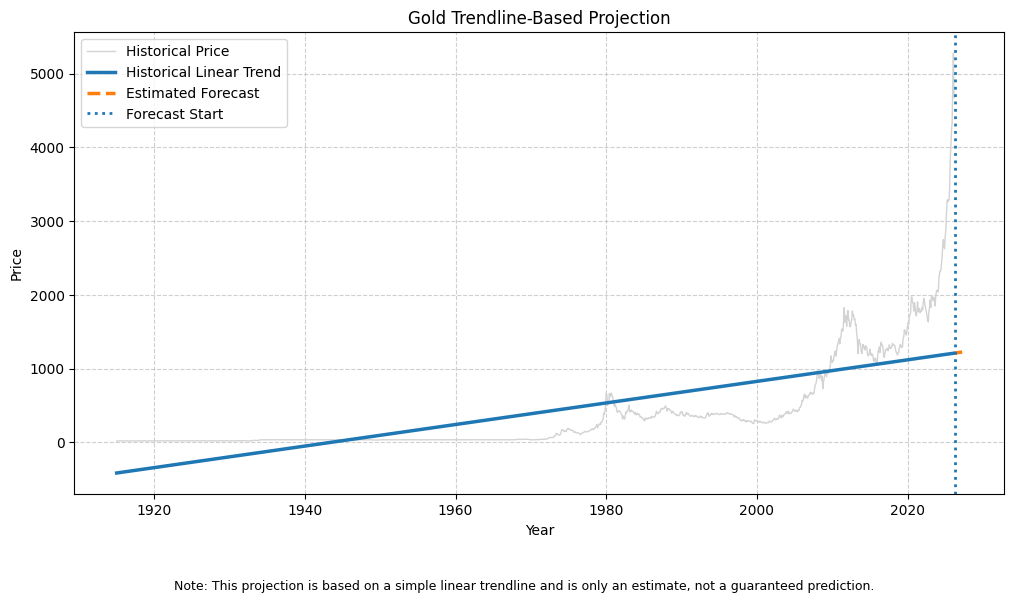

,Date,Forecast
0,2026-05-01,1211.442016
1,2026-06-01,1212.659503
2,2026-07-01,1213.876991
3,2026-08-01,1215.094479
4,2026-09-01,1216.311967
5,2026-10-01,1217.529455
6,2026-11-01,1218.746943
7,2026-12-01,1219.964430
8,2027-01-01,1221.181918
9,2027-02-01,1222.399406


In [82]:
gold_forecast = trendline_forecast(
    data=gold,
    date_col="Date",
    value_col="Value",
    asset_name="Gold",
    forecast_periods=12,
    output_path="figures/Part_C/Figure_Gold_Trendline_Forecast.pdf"
)

gold_forecast

In [83]:
import pandas as pd

base_path = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset"

gold = pd.read_csv(f"{base_path}/Gold 100years.csv")
silver = pd.read_csv(f"{base_path}/silver 100 years.csv")
oil = pd.read_csv(f"{base_path}/Brent Oil.csv")

gold["Date"] = pd.to_datetime(gold["Date"])
silver["Date"] = pd.to_datetime(silver["Date"])
oil["Date"] = pd.to_datetime(oil["Date"])

In [84]:
print(btc.columns)
btc.head()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


,Date,Close,High,Low,Open,Volume
0,2020-01-01,9350.529297,9553.125977,6914.996094,7194.892090,852872174496
1,2020-02-01,8599.508789,10457.626953,8492.932617,9346.357422,1163376492768
2,2020-03-01,6438.644531,9167.695312,4106.980957,8599.758789,1290442059648
3,2020-04-01,8658.553711,9440.650391,6202.373535,6437.319336,1156127164831
4,2020-05-01,9461.058594,9996.743164,8374.323242,8672.782227,1286368141507


In [85]:
# Flatten yfinance MultiIndex columns
btc.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in btc.columns
]

# Check result
print(btc.columns)
btc.head()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


,Date,Close,High,Low,Open,Volume
0,2020-01-01,9350.529297,9553.125977,6914.996094,7194.892090,852872174496
1,2020-02-01,8599.508789,10457.626953,8492.932617,9346.357422,1163376492768
2,2020-03-01,6438.644531,9167.695312,4106.980957,8599.758789,1290442059648
3,2020-04-01,8658.553711,9440.650391,6202.373535,6437.319336,1156127164831
4,2020-05-01,9461.058594,9996.743164,8374.323242,8672.782227,1286368141507


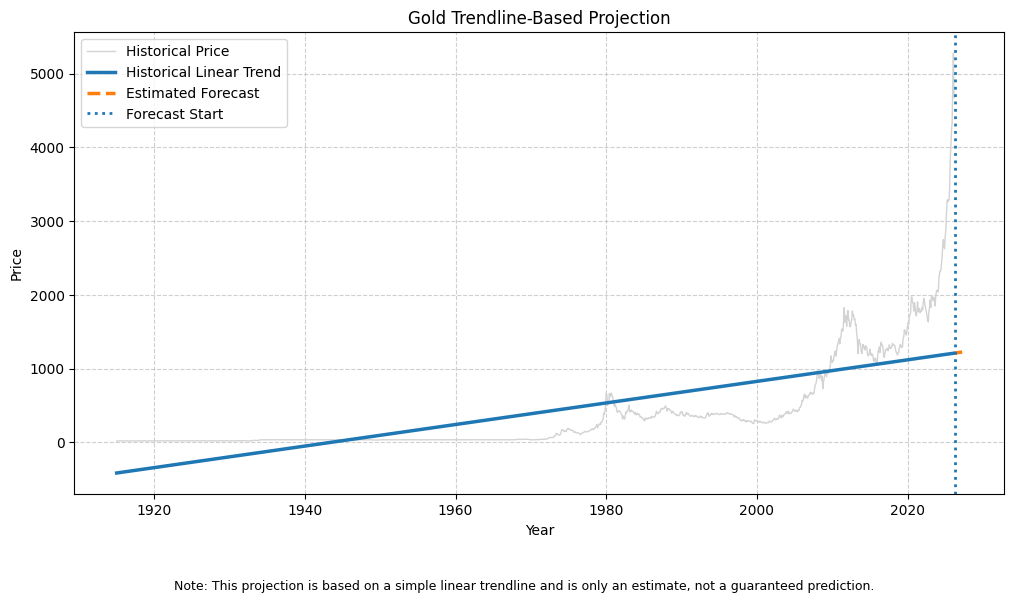

In [86]:
gold_forecast = trendline_forecast(
    data=gold,
    date_col="Date",
    value_col="Value",
    asset_name="Gold",
    forecast_periods=12,
    output_path="figures/Part_C/Figure_Gold_Trendline_Forecast.pdf"
)

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures/Part_C", exist_ok=True)

def trendline_forecast(
    data,
    date_col,
    value_col,
    asset_name,
    forecast_months=12,
    output_path=None
):
    df = data[[date_col, value_col]].dropna().copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    # Numeric time index
    df["t"] = np.arange(len(df))

    # Linear trendline
    slope, intercept = np.polyfit(df["t"], df[value_col], 1)
    df["Trendline"] = intercept + slope * df["t"]

    # Future dates
    last_date = df[date_col].max()
    future_dates = pd.date_range(
        start=last_date + pd.DateOffset(months=1),
        periods=forecast_months,
        freq="MS"
    )

    future_t = np.arange(len(df), len(df) + forecast_months)
    future_values = intercept + slope * future_t

    future_df = pd.DataFrame({
        date_col: future_dates,
        "Forecast": future_values
    })

    # Plot
    plt.figure(figsize=(12, 6))

    plt.plot(
        df[date_col],
        df[value_col],
        color="lightgray",
        linewidth=1,
        label="Historical Price"
    )

    plt.plot(
        df[date_col],
        df["Trendline"],
        linewidth=2.5,
        label="Historical Linear Trend"
    )

    plt.plot(
        future_df[date_col],
        future_df["Forecast"],
        linestyle="--",
        linewidth=2.5,
        label="Estimated Forecast"
    )

    plt.axvline(
        x=last_date,
        linestyle=":",
        linewidth=2,
        label="Forecast Start"
    )

    plt.title(f"{asset_name} Trendline-Based Projection")
    plt.xlabel("Year")
    plt.ylabel("Price")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()

    plt.figtext(
        0.5,
        -0.05,
        "Note: This projection is based on a simple linear trendline and is only an estimate, not a guaranteed prediction.",
        wrap=True,
        horizontalalignment="center",
        fontsize=9
    )

    if output_path:
        plt.savefig(output_path, format="pdf", bbox_inches="tight")

    plt.show()

    return future_df

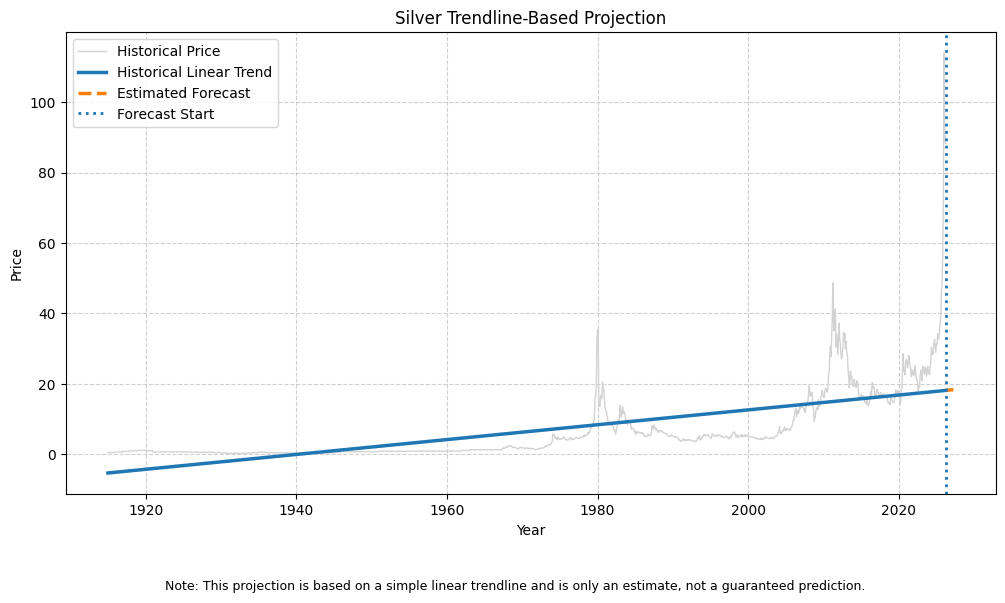

,Date,Forecast
0,2026-05-01,18.166199
1,2026-06-01,18.183768
2,2026-07-01,18.201336
3,2026-08-01,18.218904
4,2026-09-01,18.236473
5,2026-10-01,18.254041
6,2026-11-01,18.271609
7,2026-12-01,18.289178
8,2027-01-01,18.306746
9,2027-02-01,18.324315


In [88]:
silver_forecast = trendline_forecast(
    data=silver,
    date_col="Date",
    value_col="Value",
    asset_name="Silver",
    forecast_months=12,
    output_path="figures/Part_C/Figure_Silver_Trendline_Forecast.pdf"
)

silver_forecast

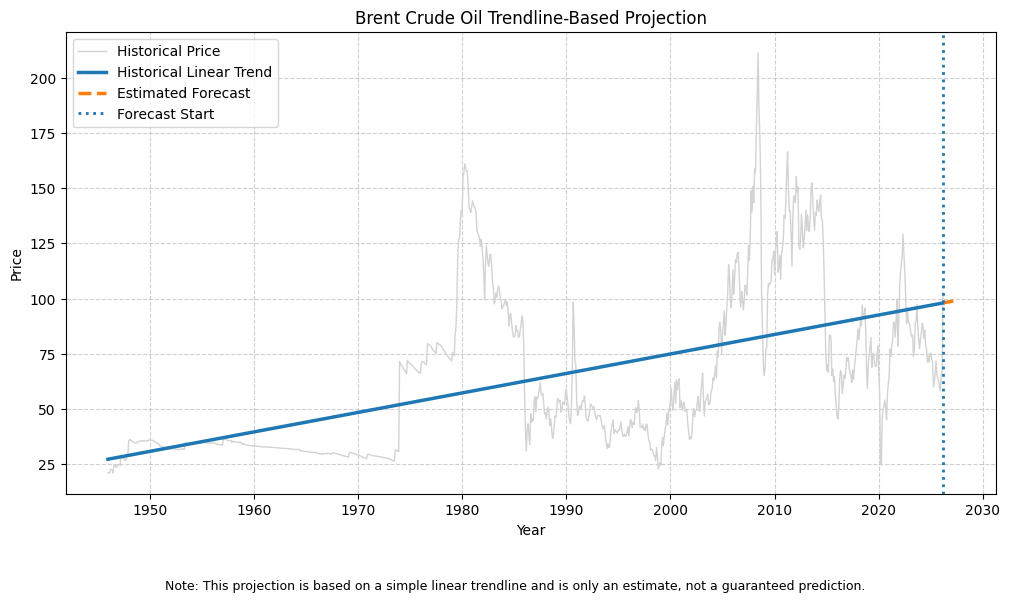

,Date,Forecast
0,2026-04-01,98.152652
1,2026-05-01,98.226186
2,2026-06-01,98.299719
3,2026-07-01,98.373253
4,2026-08-01,98.446786
5,2026-09-01,98.520320
6,2026-10-01,98.593853
7,2026-11-01,98.667387
8,2026-12-01,98.740921
9,2027-01-01,98.814454


In [89]:
oil_forecast = trendline_forecast(
    data=oil,
    date_col="Date",
    value_col="Value",
    asset_name="Brent Crude Oil",
    forecast_months=12,
    output_path="figures/Part_C/Figure_Oil_Trendline_Forecast.pdf"
)

oil_forecast

In [90]:
import pandas as pd

base_path = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset"

gold = pd.read_csv(f"{base_path}/Gold 100years.csv")
silver = pd.read_csv(f"{base_path}/silver 100 years.csv")
oil = pd.read_csv(f"{base_path}/Brent Oil.csv")

gold["Date"] = pd.to_datetime(gold["Date"])
silver["Date"] = pd.to_datetime(silver["Date"])
oil["Date"] = pd.to_datetime(oil["Date"])

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("figures/Part_C", exist_ok=True)

crypto_path = "/kaggle/input/datasets/maryammoghaddasbayat/set2-crypto/Crypto_Market_Dataset_2025_2026-2.xlsx"

# Check sheet names
xls = pd.ExcelFile(crypto_path)
print(xls.sheet_names)

['sui-usd-max', 'pepe-usd-max', 'ondo-usd-max', 'KAS-usd-max']


In [92]:
sheet_map = {
    "SUI": "sui-usd-max",
    "PEPE": "pepe-usd-max",
    "ONDO": "ondo-usd-max",
    "KASPA": "KAS-usd-max"
}

crypto_data = {}

for asset, sheet in sheet_map.items():
    temp = pd.read_excel(crypto_path, sheet_name=sheet)

    temp["Date"] = pd.to_datetime(temp["Clean_Date"])

    if asset == "SUI":
        temp = temp.rename(columns={"Price_USD": "Price"})
    else:
        temp = temp.rename(columns={"price": "Price"})

    temp = temp[["Date", "Price"]].dropna().sort_values("Date").copy()

    crypto_data[asset] = temp

print("Loaded blockchain assets:", crypto_data.keys())

Loaded blockchain assets: dict_keys(['SUI', 'PEPE', 'ONDO', 'KASPA'])


In [93]:
def trendline_forecast_daily(
    data,
    date_col,
    value_col,
    asset_name,
    forecast_days=30,
    output_path=None
):
    df = data[[date_col, value_col]].dropna().copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    df["t"] = np.arange(len(df))

    slope, intercept = np.polyfit(df["t"], df[value_col], 1)
    df["Trendline"] = intercept + slope * df["t"]

    last_date = df[date_col].max()

    future_dates = pd.date_range(
        start=last_date + pd.DateOffset(days=1),
        periods=forecast_days,
        freq="D"
    )

    future_t = np.arange(len(df), len(df) + forecast_days)
    future_values = intercept + slope * future_t

    future_df = pd.DataFrame({
        date_col: future_dates,
        "Forecast": future_values
    })

    plt.figure(figsize=(12, 6))

    plt.plot(df[date_col], df[value_col], color="lightgray", linewidth=1, label="Historical Price")
    plt.plot(df[date_col], df["Trendline"], linewidth=2.5, label="Historical Linear Trend")
    plt.plot(future_df[date_col], future_df["Forecast"], linestyle="--", linewidth=2.5, label="Estimated Forecast")
    plt.axvline(x=last_date, linestyle=":", linewidth=2, label="Forecast Start")

    plt.title(f"{asset_name} Trendline-Based Projection")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()

    plt.figtext(
        0.5,
        -0.05,
        "Note: This projection is based on a simple linear trendline and is only an estimate, not a guaranteed prediction.",
        wrap=True,
        horizontalalignment="center",
        fontsize=9
    )

    if output_path:
        plt.savefig(output_path, format="pdf", bbox_inches="tight")
        print("Saved:", output_path)

    plt.show()

    return future_df

Saved: figures/Part_C/Figure_SUI_Trendline_Forecast.pdf


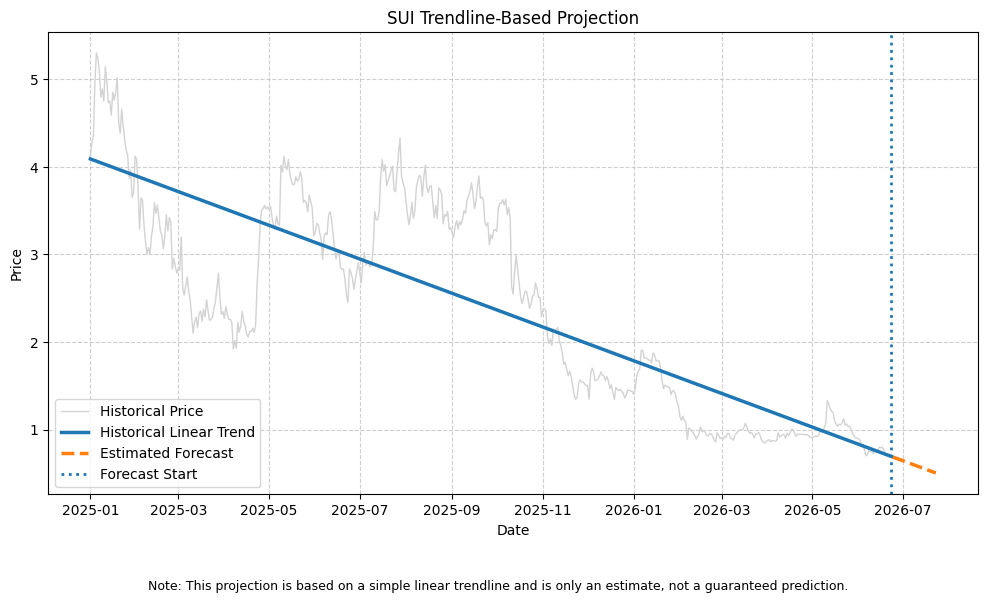

Saved: figures/Part_C/Figure_PEPE_Trendline_Forecast.pdf


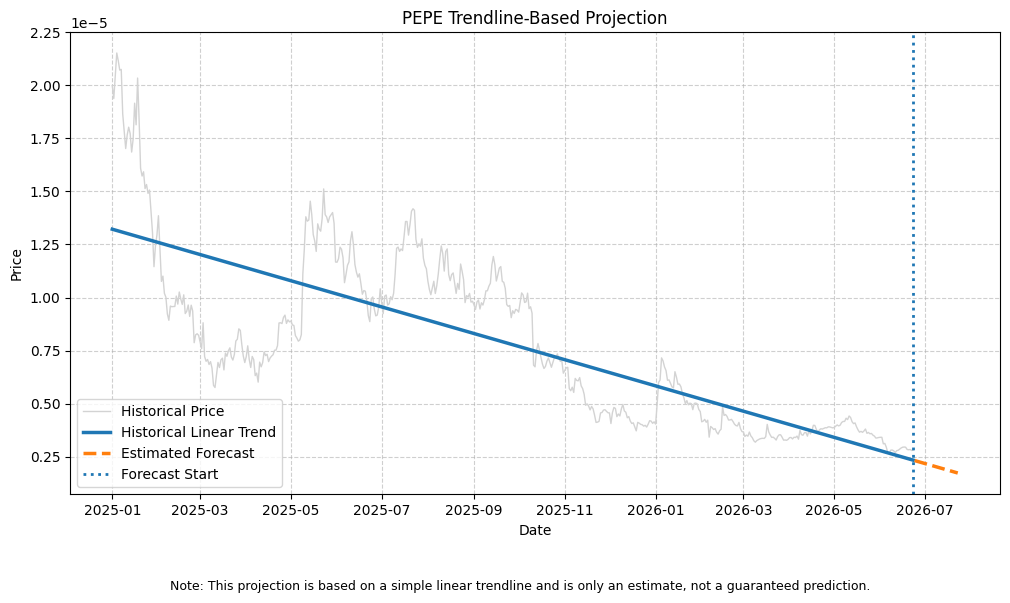

Saved: figures/Part_C/Figure_ONDO_Trendline_Forecast.pdf


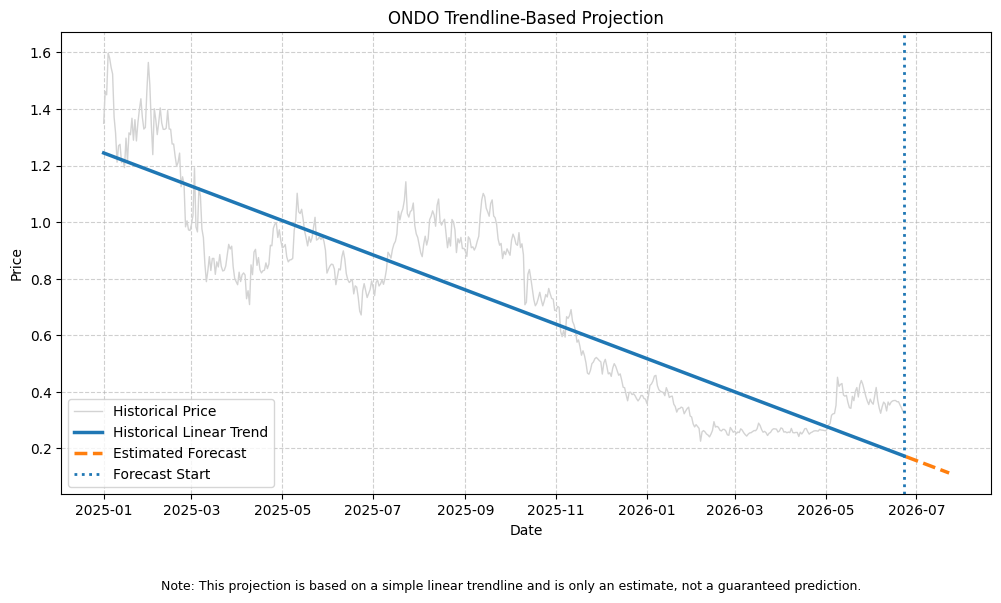

Saved: figures/Part_C/Figure_KASPA_Trendline_Forecast.pdf


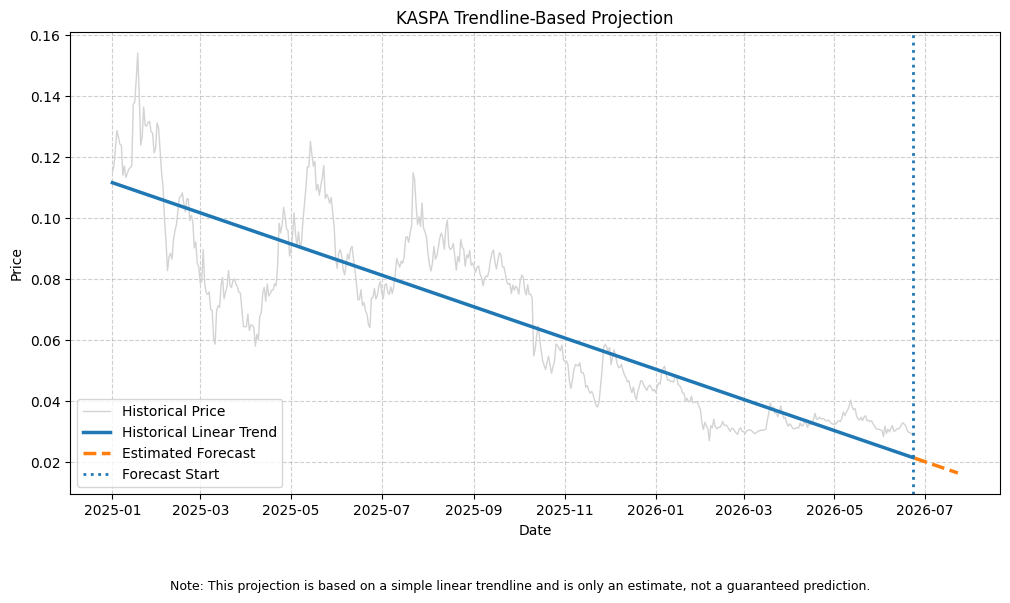

Blockchain forecasts completed.


In [94]:
blockchain_forecasts = {}

for asset, data in crypto_data.items():
    blockchain_forecasts[asset] = trendline_forecast_daily(
        data=data,
        date_col="Date",
        value_col="Price",
        asset_name=asset,
        forecast_days=30,
        output_path=f"figures/Part_C/Figure_{asset}_Trendline_Forecast.pdf"
    )

print("Blockchain forecasts completed.")

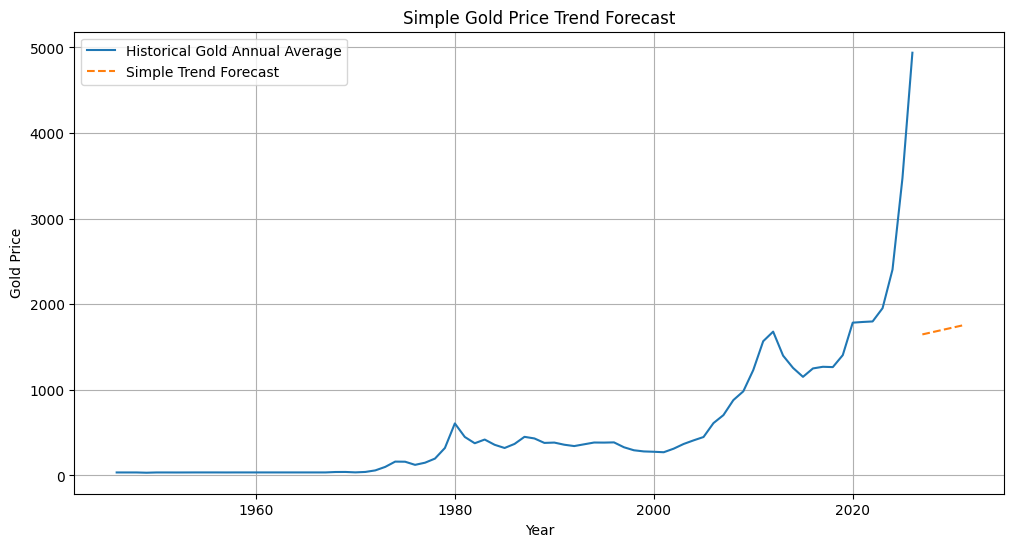

,Year,Forecast_Gold_Value
0,2027,1647.431673
1,2028,1673.532777
2,2029,1699.633882
3,2030,1725.734986
4,2031,1751.836090


In [95]:
import numpy as np

forecast_data = annual_commodity[['Year', 'Gold']].dropna()

x = forecast_data['Year'].values
y = forecast_data['Gold'].values

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

future_years = np.arange(x.max() + 1, x.max() + 6)
future_values = trend(future_years)

plt.figure(figsize=(12,6))

plt.plot(x, y, label='Historical Gold Annual Average')
plt.plot(future_years, future_values, linestyle='--', label='Simple Trend Forecast')

plt.title('Simple Gold Price Trend Forecast')
plt.xlabel('Year')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)

plt.savefig(
    "figures/Bonus/Bonus_B6_Gold_Trend_Forecast.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

forecast_table = pd.DataFrame({
    'Year': future_years,
    'Forecast_Gold_Value': future_values
})

forecast_table.to_csv(
    "tables/Bonus_B6_Gold_Forecast_Table.csv",
    index=False
)

forecast_table

In [96]:
import os

for root, dirs, files in os.walk("figures"):
    for f in files:
        print(os.path.join(root,f))

figures/Part_E/Figure_12_Latest_vs_Historical.pdf
figures/Part_E/Figure_11_Volatility_Comparison.pdf
figures/Bonus/Bonus_B3_Correlation_Heatmap.pdf
figures/Bonus/Bonus_B6_Gold_Trend_Forecast.pdf
figures/Bonus/Bonus_B4_Gold_Silver_Scatter.pdf
figures/Part_C/Figure_Silver_Moving_Average.pdf
figures/Part_C/Figure_PEPE_Trendline_Forecast.pdf
figures/Part_C/Figure_2_Gold_Trend.pdf
figures/Part_C/Figure_Oil_Trendline_Forecast.pdf
figures/Part_C/Figure_1_Brent_Oil_Trend.pdf
figures/Part_C/Figure_SUI_Trendline_Forecast.pdf
figures/Part_C/Figure_Bitcoin_Moving_Average.pdf
figures/Part_C/Figure_KASPA_Trendline_Forecast.pdf
figures/Part_C/Figure_6_Average_Commodity_Comparison.pdf
figures/Part_C/Figure_Blockchain_Market_Cap_Comparison.pdf
figures/Part_C/Figure_Oil_Moving_Average.pdf
figures/Part_C/Figure_4_Gold_Silver_Comparison.pdf
figures/Part_C/Figure_Blockchain_Indexed_Price_Comparison.pdf
figures/Part_C/Figure_Blockchain_Indexed_Volume_Comparison.pdf
figures/Part_C/Figure_5_Annual_Brent_Oil_A

In [97]:
import os

for root, dirs, files in os.walk("tables"):
    for f in files:
        print(os.path.join(root,f))

tables/Table_7_SWIFT_Source_Summary.csv
tables/Bonus_B6_Gold_Forecast_Table.csv
tables/Table_6_SWIFT_Metric_Summary.csv
tables/Table_5_Commodity_Merged_Statistics.csv
tables/Bonus_B1_Yearly_Percentage_Change.csv
tables/Table_8_Latest_vs_Historical.csv
tables/Table_9_Volatility.csv
tables/Table_1_Data_Summary.csv
tables/Table_4_Top5_Years.csv
tables/Bonus_B2_Correlation_Table.csv
tables/Table_3_Extreme_Values_Dates.csv
tables/Table_2_Highest_Lowest_Average.csv


In [98]:
import os
import zipfile

pdf_zip = "results/Figures_PDF.zip"

with zipfile.ZipFile(pdf_zip, "w", zipfile.ZIP_DEFLATED) as zipf:
    
    for root, dirs, files in os.walk("figures"):
        
        for file in files:
            
            if file.endswith(".pdf"):
                
                filepath = os.path.join(root, file)
                
                zipf.write(
                    filepath,
                    arcname=os.path.relpath(filepath, "figures")
                )

print("PDF figures zipped successfully:")
print(pdf_zip)

PDF figures zipped successfully:
results/Figures_PDF.zip


In [99]:
import os
import zipfile

table_zip = "results/Tables_CSV.zip"

with zipfile.ZipFile(table_zip, "w", zipfile.ZIP_DEFLATED) as zipf:
    
    for root, dirs, files in os.walk("tables"):
        
        for file in files:
            
            if file.endswith(".csv"):
                
                filepath = os.path.join(root, file)
                
                zipf.write(
                    filepath,
                    arcname=os.path.relpath(filepath, "tables")
                )

print("Tables zipped successfully:")
print(table_zip)

Tables zipped successfully:
results/Tables_CSV.zip


In [100]:
import os

for root, dirs, files in os.walk("results"):
    for file in files:
        print(os.path.join(root, file))

results/Figures_PDF.zip
results/Tables_CSV.zip


In [101]:
import pandas as pd
import os

os.makedirs("tables", exist_ok=True)

hormuz_weekly = pd.DataFrame([
    ["2026-03-01", "Iran–US conflict risk increased and markets began pricing possible Strait of Hormuz disruption.",
     "Oil risk premium increased because Hormuz is a key energy route.",
     "Higher oil prices can raise transport, fuel, and production costs.",
     "Investor uncertainty increased and risk assets became more sensitive.",
     "Gold and silver supported by safe-haven demand.",
     "Fuel, diesel, LNG, shipping, and petrochemical costs exposed.",
     "Brent Oil, Gold, Silver",
     "Supports Brent Oil volatility and Gold/Silver safe-haven interpretation.",
     "IEA",
     "https://www.iea.org/topics/the-middle-east-and-global-energy-markets"],

    ["2026-03-08", "Energy markets focused on possible shipping disruption in the Strait of Hormuz.",
     "Brent Oil remained sensitive to supply and tanker-flow uncertainty.",
     "Energy inflation risk increased through higher crude and product prices.",
     "Capital markets faced uncertainty from possible oil shock.",
     "Precious metals benefited from uncertainty and risk sentiment.",
     "Shipping, gasoline, diesel, and refinery costs were exposed.",
     "Brent Oil",
     "Supports Figure 1 Brent Oil trend and Table 9 volatility analysis.",
     "UNCTAD",
     "https://unctad.org/publication/strait-hormuz-disruptions-implications-global-trade-and-development"],

    ["2026-03-15", "Analysts warned that the conflict could reduce growth and increase inflation if energy disruption continued.",
     "Oil prices stayed under pressure from supply-risk expectations.",
     "Higher energy costs could keep inflation elevated.",
     "Lower growth expectations affected investor confidence.",
     "Gold demand was supported by uncertainty and inflation concerns.",
     "Oil products, refinery margins, and derivatives remained exposed.",
     "Brent Oil, Gold",
     "Connects oil shock risk with Gold safe-haven demand in 2025–2026.",
     "Goldman Sachs",
     "https://www.goldmansachs.com/pdfs/insights/goldman-sachs-research/iran-conflict-how-long-and-how-bad/report.pdf"],

    ["2026-03-22", "Markets continued to monitor Hormuz closure risk and possible energy supply losses.",
     "Oil prices remained supported by supply disruption fears.",
     "Energy costs threatened inflation persistence.",
     "Risk assets remained sensitive to war news.",
     "Safe-haven assets remained relevant.",
     "LNG and petroleum product supply risk continued.",
     "Brent Oil, Gold, Silver",
     "Supports the interpretation that geopolitical risk affects oil and precious metals differently.",
     "Reuters",
     "https://www.reuters.com/commentary/reuters-open-interest/iran-war-triggers-global-race-build-oil-reserves-2026-06-22/"],

    ["2026-04-01", "Hormuz disruption continued into April and maintained pressure on global energy markets.",
     "Supply uncertainty supported Brent prices.",
     "Energy costs continued to pressure importing economies.",
     "Markets reacted to geopolitical uncertainty.",
     "Gold remained a hedge against uncertainty.",
     "Oil shipping, insurance, and tanker costs remained important.",
     "Brent Oil, Gold",
     "Supports Brent Oil latest value above historical average and Gold strength.",
     "IEA",
     "https://www.iea.org/topics/the-middle-east-and-global-energy-markets"],

    ["2026-04-08", "Ceasefire and reopening discussions appeared, but uncertainty remained.",
     "Oil prices reacted to reopening expectations.",
     "Inflation pressure could ease if energy flows resumed.",
     "Capital markets improved when peace expectations increased.",
     "Safe-haven pressure reduced slightly but did not disappear.",
     "Petroleum supply expectations improved.",
     "Brent Oil",
     "Explains why oil can fall quickly when supply-risk expectations improve.",
     "Reuters",
     "https://www.reuters.com/business/energy/oil-gains-after-selloff-awaits-progress-strait-hormuz-flows-2026-06-23/"],

    ["2026-04-17", "Shipping and tanker-flow uncertainty remained important despite negotiation signals.",
     "Oil prices remained sensitive to shipping news.",
     "Energy inflation risk did not disappear fully.",
     "Investors watched reopening and tanker-flow signals.",
     "Gold remained supported by uncertainty.",
     "Tankers, crude flows, marine insurance, and logistics remained central.",
     "Brent Oil, Gold",
     "Connects energy-market uncertainty with safe-haven demand.",
     "UNCTAD",
     "https://unctad.org/publication/strait-hormuz-disruptions-implications-global-trade-and-development"],

    ["2026-05-01", "Sanction, shipping, and energy-security concerns continued around Hormuz traffic.",
     "Oil risk premium remained present.",
     "Energy cost pressure stayed relevant for importers.",
     "Markets remained cautious.",
     "Precious metals were supported by risk environment.",
     "Shipping firms, insurance, transport, and refinery sectors were affected.",
     "Brent Oil, Gold, Silver",
     "Supports Table 8 latest prices above historical averages.",
     "IEA",
     "https://www.iea.org/topics/the-middle-east-and-global-energy-markets"],

    ["2026-05-25", "US strikes in Iran reduced hopes for a quick agreement.",
     "Brent rose about 4%.",
     "Higher oil raised inflation concerns again.",
     "Capital markets became more risk-sensitive.",
     "Gold and silver benefited from uncertainty.",
     "Oil futures and petroleum products were affected.",
     "Brent Oil, Gold, Silver",
     "Supports Table 9 volatility and safe-haven interpretation.",
     "Reuters",
     "https://www.reuters.com/business/energy/us-crude-futures-fall-over-6-report-possible-strait-hormuz-reopening-2026-05-25/"],

    ["2026-06-17", "Oil prices declined as peace hopes and reopening expectations improved.",
     "Brent dropped as supply-risk expectations eased.",
     "Lower oil prices reduced inflation pressure.",
     "Market sentiment improved.",
     "Safe-haven demand could soften.",
     "Energy supply expectations improved.",
     "Brent Oil",
     "Explains reversal in oil-risk premium when geopolitical risk declines.",
     "Al Jazeera",
     "https://www.aljazeera.com/economy/2026/6/17/oil-prices-continue-slide-amid-hopes-for-peace-opening-of-strait-of-hormuz"],

    ["2026-06-19", "Some tankers entered Hormuz and Brent was set for a weekly fall.",
     "Brent was set for a sharp weekly decline.",
     "Energy inflation pressure eased.",
     "Capital-market risk improved.",
     "Gold pressure may ease if geopolitical risk declines.",
     "More oil supply was expected to return.",
     "Brent Oil",
     "Supports interpretation that oil reacts quickly to supply-flow news.",
     "Reuters",
     "https://www.reuters.com/business/energy/oil-falls-supply-starts-moving-through-strait-hormuz-2026-06-19/"],

    ["2026-06-21", "US–Iran talks signaled easing, although oil remained sensitive to renewed threats.",
     "Brent settled down more than 3%.",
     "Lower oil helped inflation expectations.",
     "Markets reacted positively to easing signals.",
     "Safe-haven demand moderated.",
     "Oil products and shipping risk eased.",
     "Brent Oil, Gold",
     "Links easing geopolitical risk to lower oil pressure and weaker safe-haven demand.",
     "Reuters",
     "https://www.reuters.com/business/energy/brent-oil-rises-more-than-1bbl-after-bumpy-start-us-iran-peace-talks-2026-06-21/"],

    ["2026-06-22", "US issued temporary license for Iranian oil sales during peace talks.",
     "Oil prices dropped after easing of sanctions and supply risk.",
     "Lower energy prices reduced inflation pressure.",
     "Capital markets benefited from lower risk expectations.",
     "Gold and silver may face lower safe-haven demand.",
     "Iranian crude, petroleum products, banking, insurance, and transport were included.",
     "Brent Oil",
     "Explains easing in energy-risk premium during negotiations.",
     "Reuters",
     "https://www.reuters.com/business/energy/us-issues-iran-related-general-license-oil-sales-2026-06-22/"],

    ["2026-06-22", "Iran announced a communication line for safe passage through Hormuz.",
     "Shipping-risk premium decreased.",
     "Energy cost pressure eased.",
     "Reduced uncertainty supported markets.",
     "Safe-haven demand may decline.",
     "Marine transport and oil logistics improved.",
     "Brent Oil",
     "Supports the idea that reopening signals reduce oil-market stress.",
     "Reuters",
     "https://www.reuters.com/world/middle-east/iran-establish-communication-line-safe-passage-hormuz-top-negotiator-says-2026-06-22/"]
], columns=[
    "Week",
    "Event",
    "Oil_Energy_Impact",
    "Inflation_Impact",
    "Capital_Market_Impact",
    "Gold_Silver_Impact",
    "Energy_Products_Impact",
    "Commodity_Most_Affected",
    "Connection_to_PartI",
    "Source",
    "Reference_Link"
])

hormuz_weekly.to_csv(
    "tables/PartII_A_Hormuz_Weekly_Event_Table.csv",
    index=False
)

hormuz_weekly

,Week,Event,Oil_Energy_Impact,Inflation_Impact,Capital_Market_Impact,Gold_Silver_Impact,Energy_Products_Impact,Commodity_Most_Affected,Connection_to_PartI,Source,Reference_Link
0,2026-03-01,Iran–US conflict risk increased and markets be...,Oil risk premium increased because Hormuz is a...,"Higher oil prices can raise transport, fuel, a...",Investor uncertainty increased and risk assets...,Gold and silver supported by safe-haven demand.,"Fuel, diesel, LNG, shipping, and petrochemical...","Brent Oil, Gold, Silver",Supports Brent Oil volatility and Gold/Silver ...,IEA,https://www.iea.org/topics/the-middle-east-and...
1,2026-03-08,Energy markets focused on possible shipping di...,Brent Oil remained sensitive to supply and tan...,Energy inflation risk increased through higher...,Capital markets faced uncertainty from possibl...,Precious metals benefited from uncertainty and...,"Shipping, gasoline, diesel, and refinery costs...",Brent Oil,Supports Figure 1 Brent Oil trend and Table 9 ...,UNCTAD,https://unctad.org/publication/strait-hormuz-d...
2,2026-03-15,Analysts warned that the conflict could reduce...,Oil prices stayed under pressure from supply-r...,Higher energy costs could keep inflation eleva...,Lower growth expectations affected investor co...,Gold demand was supported by uncertainty and i...,"Oil products, refinery margins, and derivative...","Brent Oil, Gold",Connects oil shock risk with Gold safe-haven d...,Goldman Sachs,https://www.goldmansachs.com/pdfs/insights/gol...
3,2026-03-22,Markets continued to monitor Hormuz closure ri...,Oil prices remained supported by supply disrup...,Energy costs threatened inflation persistence.,Risk assets remained sensitive to war news.,Safe-haven assets remained relevant.,LNG and petroleum product supply risk continued.,"Brent Oil, Gold, Silver",Supports the interpretation that geopolitical ...,Reuters,https://www.reuters.com/commentary/reuters-ope...
4,2026-04-01,Hormuz disruption continued into April and mai...,Supply uncertainty supported Brent prices.,Energy costs continued to pressure importing e...,Markets reacted to geopolitical uncertainty.,Gold remained a hedge against uncertainty.,"Oil shipping, insurance, and tanker costs rema...","Brent Oil, Gold",Supports Brent Oil latest value above historic...,IEA,https://www.iea.org/topics/the-middle-east-and...
5,2026-04-08,"Ceasefire and reopening discussions appeared, ...",Oil prices reacted to reopening expectations.,Inflation pressure could ease if energy flows ...,Capital markets improved when peace expectatio...,Safe-haven pressure reduced slightly but did n...,Petroleum supply expectations improved.,Brent Oil,Explains why oil can fall quickly when supply-...,Reuters,https://www.reuters.com/business/energy/oil-ga...
6,2026-04-17,Shipping and tanker-flow uncertainty remained ...,Oil prices remained sensitive to shipping news.,Energy inflation risk did not disappear fully.,Investors watched reopening and tanker-flow si...,Gold remained supported by uncertainty.,"Tankers, crude flows, marine insurance, and lo...","Brent Oil, Gold",Connects energy-market uncertainty with safe-h...,UNCTAD,https://unctad.org/publication/strait-hormuz-d...
7,2026-05-01,"Sanction, shipping, and energy-security concer...",Oil risk premium remained present.,Energy cost pressure stayed relevant for impor...,Markets remained cautious.,Precious metals were supported by risk environ...,"Shipping firms, insurance, transport, and refi...","Brent Oil, Gold, Silver",Supports Table 8 latest prices above historica...,IEA,https://www.iea.org/topics/the-middle-east-and...
8,2026-05-25,US strikes in Iran reduced hopes for a quick a...,Brent rose about 4%.,Higher oil raised inflation concerns again.,Capital markets became more risk-sensitive.,Gold and silver benefited from uncertainty.,Oil futures and petroleum products were affected.,"Brent Oil, Gold, Silver",Supports Table 9 volatility and safe-haven int...,Reuters,https://www.reuters.com/business/energy/us-cru...
9,20

In [102]:
# ============================================================
# PART II-A - TABLE A1
# Hormuz / Iran-US Conflict / Energy Market Events 2026
# ============================================================

import pandas as pd
import os

# Create tables folder if it does not exist
os.makedirs("tables", exist_ok=True)

# Importance score:
# 3 = Major event
# 2 = Moderate event
# 1 = Minor event

hormuz_weekly = pd.DataFrame([
    [
        "2026-03-01",
        "Iran-US conflict risk increased and markets began pricing possible Strait of Hormuz disruption.",
        "Oil risk premium increased because Hormuz is a key global energy route.",
        "Higher oil prices can raise transport, fuel, and production costs.",
        "Investor uncertainty increased and risk assets became more sensitive.",
        "Gold and silver were supported by safe-haven demand.",
        "Fuel, diesel, LNG, shipping, and petrochemical costs were exposed.",
        "Brent Oil, Gold, Silver",
        "Supports Brent Oil volatility and Gold/Silver safe-haven interpretation.",
        3,
        "IEA",
        "https://www.iea.org/topics/the-middle-east-and-global-energy-markets"
    ],
    [
        "2026-03-08",
        "Energy markets focused on possible shipping disruption in the Strait of Hormuz.",
        "Brent Oil remained sensitive to supply and tanker-flow uncertainty.",
        "Energy inflation risk increased through higher crude and product prices.",
        "Capital markets faced uncertainty from possible oil shock.",
        "Precious metals benefited from uncertainty and risk sentiment.",
        "Shipping, gasoline, diesel, and refinery costs were exposed.",
        "Brent Oil",
        "Supports Figure 1 Brent Oil trend and Table 9 volatility analysis.",
        3,
        "UNCTAD",
        "https://unctad.org/publication/strait-hormuz-disruptions-implications-global-trade-and-development"
    ],
    [
        "2026-03-15",
        "Analysts warned that the conflict could reduce growth and increase inflation if energy disruption continued.",
        "Oil prices stayed under pressure from supply-risk expectations.",
        "Higher energy costs could keep inflation elevated.",
        "Lower growth expectations affected investor confidence.",
        "Gold demand was supported by uncertainty and inflation concerns.",
        "Oil products, refinery margins, and derivatives remained exposed.",
        "Brent Oil, Gold",
        "Connects oil shock risk with Gold safe-haven demand in 2025-2026.",
        3,
        "Goldman Sachs",
        "https://www.goldmansachs.com/pdfs/insights/goldman-sachs-research/iran-conflict-how-long-and-how-bad/report.pdf"
    ],
    [
        "2026-03-22",
        "Markets continued to monitor Hormuz closure risk and possible energy supply losses.",
        "Oil prices remained supported by supply disruption fears.",
        "Energy costs threatened inflation persistence.",
        "Risk assets remained sensitive to war news.",
        "Safe-haven assets remained relevant.",
        "LNG and petroleum product supply risk continued.",
        "Brent Oil, Gold, Silver",
        "Supports the interpretation that geopolitical risk affects oil and precious metals differently.",
        2,
        "Reuters",
        "https://www.reuters.com/commentary/reuters-open-interest/iran-war-triggers-global-race-build-oil-reserves-2026-06-22/"
    ],
    [
        "2026-04-01",
        "Hormuz disruption continued into April and maintained pressure on global energy markets.",
        "Supply uncertainty supported Brent prices.",
        "Energy costs continued to pressure importing economies.",
        "Markets reacted to geopolitical uncertainty.",
        "Gold remained a hedge against uncertainty.",
        "Oil shipping, insurance, and tanker costs remained important.",
        "Brent Oil, Gold",
        "Supports Brent Oil latest value above historical average and Gold strength.",
        3,
        "IEA",
        "https://www.iea.org/topics/the-middle-east-and-global-energy-markets"
    ],
    [
        "2026-04-08",
        "Ceasefire and reopening discussions appeared, but uncertainty remained.",
        "Oil prices reacted to reopening expectations.",
        "Inflation pressure could ease if energy flows resumed.",
        "Capital markets improved when peace expectations increased.",
        "Safe-haven pressure reduced slightly but did not disappear.",
        "Petroleum supply expectations improved.",
        "Brent Oil",
        "Explains why oil can fall quickly when supply-risk expectations improve.",
        2,
        "Reuters",
        "https://www.reuters.com/business/energy/oil-gains-after-selloff-awaits-progress-strait-hormuz-flows-2026-06-23/"
    ],
    [
        "2026-04-17",
        "Shipping and tanker-flow uncertainty remained important despite negotiation signals.",
        "Oil prices remained sensitive to shipping news.",
        "Energy inflation risk did not disappear fully.",
        "Investors watched reopening and tanker-flow signals.",
        "Gold remained supported by uncertainty.",
        "Tankers, crude flows, marine insurance, and logistics remained central.",
        "Brent Oil, Gold",
        "Connects energy-market uncertainty with safe-haven demand.",
        2,
        "UNCTAD",
        "https://unctad.org/publication/strait-hormuz-disruptions-implications-global-trade-and-development"
    ],
    [
        "2026-05-01",
        "Sanction, shipping, and energy-security concerns continued around Hormuz traffic.",
        "Oil risk premium remained present.",
        "Energy cost pressure stayed relevant for importers.",
        "Markets remained cautious.",
        "Precious metals were supported by risk environment.",
        "Shipping firms, insurance, transport, and refinery sectors were affected.",
        "Brent Oil, Gold, Silver",
        "Supports Table 8 latest prices above historical averages.",
        2,
        "IEA",
        "https://www.iea.org/topics/the-middle-east-and-global-energy-markets"
    ],
    [
        "2026-05-25",
        "US strikes in Iran reduced hopes for a quick agreement.",
        "Brent rose about 4 percent.",
        "Higher oil raised inflation concerns again.",
        "Capital markets became more risk-sensitive.",
        "Gold and silver benefited from uncertainty.",
        "Oil futures and petroleum products were affected.",
        "Brent Oil, Gold, Silver",
        "Supports Table 9 volatility and safe-haven interpretation.",
        3,
        "Reuters",
        "https://www.reuters.com/business/energy/us-crude-futures-fall-over-6-report-possible-strait-hormuz-reopening-2026-05-25/"
    ],
    [
        "2026-06-17",
        "Oil prices declined as peace hopes and reopening expectations improved.",
        "Brent dropped as supply-risk expectations eased.",
        "Lower oil prices reduced inflation pressure.",
        "Market sentiment improved.",
        "Safe-haven demand could soften.",
        "Energy supply expectations improved.",
        "Brent Oil",
        "Explains reversal in oil-risk premium when geopolitical risk declines.",
        2,
        "Reuters",
        "https://www.reuters.com/business/energy/oil-gains-after-selloff-awaits-progress-strait-hormuz-flows-2026-06-23/"
    ],
    [
        "2026-06-19",
        "Some tankers entered Hormuz and Brent was set for a weekly fall.",
        "Brent was set for a sharp weekly decline.",
        "Energy inflation pressure eased.",
        "Capital-market risk improved.",
        "Gold pressure may ease if geopolitical risk declines.",
        "More oil supply was expected to return.",
        "Brent Oil",
        "Supports interpretation that oil reacts quickly to supply-flow news.",
        2,
        "Reuters",
        "https://www.reuters.com/business/energy/oil-falls-supply-starts-moving-through-strait-hormuz-2026-06-19/"
    ],
    [
        "2026-06-21",
        "US-Iran talks signaled easing, although oil remained sensitive to renewed threats.",
        "Brent settled down more than 3 percent.",
        "Lower oil helped inflation expectations.",
        "Markets reacted positively to easing signals.",
        "Safe-haven demand moderated.",
        "Oil products and shipping risk eased.",
        "Brent Oil, Gold",
        "Links easing geopolitical risk to lower oil pressure and weaker safe-haven demand.",
        2,
        "Reuters",
        "https://www.reuters.com/business/energy/brent-oil-rises-more-than-1bbl-after-bumpy-start-us-iran-peace-talks-2026-06-21/"
    ],
    [
        "2026-06-22",
        "US issued temporary license for Iranian oil sales during peace talks.",
        "Oil prices dropped after easing of sanctions and supply risk.",
        "Lower energy prices reduced inflation pressure.",
        "Capital markets benefited from lower risk expectations.",
        "Gold and silver may face lower safe-haven demand.",
        "Iranian crude, petroleum products, banking, insurance, and transport were included.",
        "Brent Oil",
        "Explains easing in energy-risk premium during negotiations.",
        3,
        "Reuters",
        "https://www.reuters.com/business/energy/us-issues-iran-related-general-license-oil-sales-2026-06-22/"
    ],
    [
        "2026-06-22",
        "Iran announced a communication line for safe passage through Hormuz.",
        "Shipping-risk premium decreased.",
        "Energy cost pressure eased.",
        "Reduced uncertainty supported markets.",
        "Safe-haven demand may decline.",
        "Marine transport and oil logistics improved.",
        "Brent Oil",
        "Supports the idea that reopening signals reduce oil-market stress.",
        3,
        "Reuters",
        "https://www.reuters.com/world/middle-east/iran-establish-communication-line-safe-passage-hormuz-top-negotiator-says-2026-06-22/"
    ],
    [
        "2026-06-23",
        "Markets reassessed the probability of a prolonged Strait of Hormuz disruption after reopening signals and ongoing negotiations.",
        "Brent Oil stabilized below crisis expectations as supply-risk concerns eased.",
        "Inflation expectations moderated compared with March-May levels.",
        "Risk sentiment improved and capital markets became less sensitive to energy shocks.",
        "Safe-haven demand remained above pre-conflict levels but eased relative to the peak uncertainty period.",
        "Shipping, tanker flows, and petroleum logistics showed signs of normalization.",
        "Brent Oil, Gold",
        "Provides the latest interpretation of the transition from crisis conditions to market stabilization.",
        3,
        "Reuters",
        "https://www.reuters.com/business/energy/oil-gains-after-selloff-awaits-progress-strait-hormuz-flows-2026-06-23/"
    ]
], columns=[
    "Week",
    "Event",
    "Oil_Energy_Impact",
    "Inflation_Impact",
    "Capital_Market_Impact",
    "Gold_Silver_Impact",
    "Energy_Products_Impact",
    "Commodity_Most_Affected",
    "Connection_to_PartI",
    "Importance_Score",
    "Source",
    "Reference_Link"
])

# Convert Week to date format
hormuz_weekly["Week"] = pd.to_datetime(hormuz_weekly["Week"])

# Save final table
hormuz_weekly.to_csv(
    "tables/Table_A1_Hormuz_Energy_Market_Events_2026.csv",
    index=False
)

print("Table A1 saved successfully:")
print("tables/Table_A1_Hormuz_Energy_Market_Events_2026.csv")

hormuz_weekly

Table A1 saved successfully:
tables/Table_A1_Hormuz_Energy_Market_Events_2026.csv


,Week,Event,Oil_Energy_Impact,Inflation_Impact,Capital_Market_Impact,Gold_Silver_Impact,Energy_Products_Impact,Commodity_Most_Affected,Connection_to_PartI,Importance_Score,Source,Reference_Link
0,2026-03-01,Iran-US conflict risk increased and markets be...,Oil risk premium increased because Hormuz is a...,"Higher oil prices can raise transport, fuel, a...",Investor uncertainty increased and risk assets...,Gold and silver were supported by safe-haven d...,"Fuel, diesel, LNG, shipping, and petrochemical...","Brent Oil, Gold, Silver",Supports Brent Oil volatility and Gold/Silver ...,3,IEA,https://www.iea.org/topics/the-middle-east-and...
1,2026-03-08,Energy markets focused on possible shipping di...,Brent Oil remained sensitive to supply and tan...,Energy inflation risk increased through higher...,Capital markets faced uncertainty from possibl...,Precious metals benefited from uncertainty and...,"Shipping, gasoline, diesel, and refinery costs...",Brent Oil,Supports Figure 1 Brent Oil trend and Table 9 ...,3,UNCTAD,https://unctad.org/publication/strait-hormuz-d...
2,2026-03-15,Analysts warned that the conflict could reduce...,Oil prices stayed under pressure from supply-r...,Higher energy costs could keep inflation eleva...,Lower growth expectations affected investor co...,Gold demand was supported by uncertainty and i...,"Oil products, refinery margins, and derivative...","Brent Oil, Gold",Connects oil shock risk with Gold safe-haven d...,3,Goldman Sachs,https://www.goldmansachs.com/pdfs/insights/gol...
3,2026-03-22,Markets continued to monitor Hormuz closure ri...,Oil prices remained supported by supply disrup...,Energy costs threatened inflation persistence.,Risk assets remained sensitive to war news.,Safe-haven assets remained relevant.,LNG and petroleum product supply risk continued.,"Brent Oil, Gold, Silver",Supports the interpretation that geopolitical ...,2,Reuters,https://www.reuters.com/commentary/reuters-ope...
4,2026-04-01,Hormuz disruption continued into April and mai...,Supply uncertainty supported Brent prices.,Energy costs continued to pressure importing e...,Markets reacted to geopolitical uncertainty.,Gold remained a hedge against uncertainty.,"Oil shipping, insurance, and tanker costs rema...","Brent Oil, Gold",Supports Brent Oil latest value above historic...,3,IEA,https://www.iea.org/topics/the-middle-east-and...
5,2026-04-08,"Ceasefire and reopening discussions appeared, ...",Oil prices reacted to reopening expectations.,Inflation pressure could ease if energy flows ...,Capital markets improved when peace expectatio...,Safe-haven pressure reduced slightly but did n...,Petroleum supply expectations improved.,Brent Oil,Explains why oil can fall quickly when supply-...,2,Reuters,https://www.reuters.com/business/energy/oil-ga...
6,2026-04-17,Shipping and tanker-flow uncertainty remained ...,Oil prices remained sensitive to shipping news.,Energy inflation risk did not disappear fully.,Investors watched reopening and tanker-flow si...,Gold remained supported by uncertainty.,"Tankers, crude flows, marine insurance, and lo...","Brent Oil, Gold",Connects energy-market uncertainty with safe-h...,2,UNCTAD,https://unctad.org/publication/strait-hormuz-d...
7,2026-05-01,"Sanction, shipping, and energy-security concer...",Oil risk premium remained present.,Energy cost pressure stayed relevant for impor...,Markets remained cautious.,Precious metals were supported by risk environ...,"Shipping firms, insurance, transport, and refi...","Brent Oil, Gold, Silver",Supports Table 8 latest prices above historica...,2,IEA,https://www.iea.org/topics/the-middle-east-and...
8,2026-05-25,US strikes in Iran reduced hopes for a quick a...,Brent rose about 4 percent.,Higher oil raised inflation concerns again.,Capital markets became more risk-sensitive.,Gold and silver benefited from uncertainty.,Oil futures and petroleum products were affected.,"Brent Oil, Gold, Silver",Supports Table 9 volatility and safe-haven int...,3,Reuters,https://ww

In [103]:
# ============================================================
# PART II-A - TABLE A2
# Gold & Silver Safe-Haven and Precious Metals Evidence
# ============================================================

import pandas as pd
import os

os.makedirs("tables", exist_ok=True)

# Importance score:
# 3 = Major evidence
# 2 = Moderate evidence
# 1 = Supporting evidence

gold_silver_evidence = pd.DataFrame([
    [
        "Central Bank Gold Buying",
        "2024-2026",
        "Central bank gold purchases remained strong, with 863 tonnes bought in 2025 after three years above 1,000 tonnes.",
        "Strong central-bank demand supports higher gold prices and strengthens gold's role as a reserve asset.",
        "Gold",
        "Explains Gold's very high values in 2025-2026 and supports Figure 2 Gold Trend and Table 4 Top Years.",
        3,
        "World Gold Council",
        "https://www.gold.org/goldhub/research/gold-demand-trends/gold-demand-trends-full-year-2025/central-banks"
    ],
    [
        "Record Gold Demand",
        "2025",
        "Total gold demand, including OTC, exceeded 5,000 tonnes for the first time in 2025.",
        "High demand from investors and institutions supports the sharp increase in gold prices.",
        "Gold",
        "Supports Gold's latest value being far above its historical average in Table 8.",
        3,
        "World Gold Council",
        "https://www.gold.org/goldhub/research/gold-demand-trends/gold-demand-trends-full-year-2025"
    ],
    [
        "Safe-Haven and Diversification Demand",
        "2025-2026",
        "Gold investment increased strongly as geopolitical and economic uncertainty encouraged safe-haven demand.",
        "Investors use gold as a hedge during uncertainty, inflation risk, and market stress.",
        "Gold",
        "Connects geopolitical uncertainty with the strong upward trend in Figure 2.",
        3,
        "World Gold Council",
        "https://www.gold.org/news-and-events/press-releases/gold-investment-rockets-2025-setting-new-high-uncertainty-bites"
    ],
    [
        "Inflation and Interest-Rate Uncertainty",
        "2024-2026",
        "Global inflation remained above pre-pandemic norms in many economies, while monetary policy uncertainty continued.",
        "Inflation uncertainty increases demand for real assets such as gold and silver.",
        "Gold, Silver",
        "Supports Table 8 where Gold and Silver latest prices are above long-term averages.",
        2,
        "IMF",
        "https://www.imf.org/en/publications/weo"
    ],
    [
        "Commodity and Inflation Pressure",
        "2025-2026",
        "Global commodity prices and inflation conditions remained important for market expectations.",
        "Persistent inflation and commodity uncertainty can strengthen precious metals as protection assets.",
        "Gold, Silver",
        "Supports the interpretation of precious metals as inflation-sensitive assets.",
        2,
        "World Bank",
        "https://www.worldbank.org/en/research/commodity-markets"
    ],
    [
        "Silver Industrial Demand",
        "2025",
        "The Silver Institute reports silver supply and demand conditions across industrial sectors, including electronics and solar-related demand.",
        "Industrial demand gives silver a second driver beyond safe-haven demand.",
        "Silver",
        "Explains why Silver rises with Gold but can also behave like an industrial commodity.",
        3,
        "The Silver Institute",
        "https://silverinstitute.org/all-world-silver-surveys-2025/"
    ],
    [
        "Solar and Green Energy Demand",
        "2025-2026",
        "Silver demand is strongly connected to solar PV, electronics, and energy-transition technologies.",
        "Green-energy demand supports silver prices and increases its industrial importance.",
        "Silver",
        "Supports Figure 3 Silver Trend and explains why Silver can move differently from Gold.",
        2,
        "The Silver Institute",
        "https://silverinstitute.org/wp-content/uploads/2025/04/World_Silver_Survey-2025.pdf"
    ],
    [
        "Gold-Silver Market Relationship",
        "1946-2026",
        "Gold and Silver are both precious metals and often respond to similar uncertainty and inflation conditions.",
        "This explains their strong positive relationship.",
        "Gold, Silver",
        "Directly supports Bonus_B2 correlation result where Gold-Silver correlation is about 0.95.",
        3,
        "Part I Result",
        "tables/Bonus_B2_Correlation_Table.csv"
    ]
], columns=[
    "Theme",
    "Period",
    "Evidence",
    "Market_Impact",
    "Commodity_Most_Affected",
    "Connection_to_PartI",
    "Importance_Score",
    "Source",
    "Reference_Link"
])

gold_silver_evidence.to_csv(
    "tables/Table_A2_Gold_Silver_Safe_Haven_Evidence.csv",
    index=False
)

print("Table A2 saved successfully:")
print("tables/Table_A2_Gold_Silver_Safe_Haven_Evidence.csv")

gold_silver_evidence

Table A2 saved successfully:
tables/Table_A2_Gold_Silver_Safe_Haven_Evidence.csv


,Theme,Period,Evidence,Market_Impact,Commodity_Most_Affected,Connection_to_PartI,Importance_Score,Source,Reference_Link
0,Central Bank Gold Buying,2024-2026,"Central bank gold purchases remained strong, w...",Strong central-bank demand supports higher gol...,Gold,Explains Gold's very high values in 2025-2026 ...,3,World Gold Council,https://www.gold.org/goldhub/research/gold-dem...
1,Record Gold Demand,2025,"Total gold demand, including OTC, exceeded 5,0...",High demand from investors and institutions su...,Gold,Supports Gold's latest value being far above i...,3,World Gold Council,https://www.gold.org/goldhub/research/gold-dem...
2,Safe-Haven and Diversification Demand,2025-2026,Gold investment increased strongly as geopolit...,Investors use gold as a hedge during uncertain...,Gold,Connects geopolitical uncertainty with the str...,3,World Gold Council,https://www.gold.org/news-and-events/press-rel...
3,Inflation and Interest-Rate Uncertainty,2024-2026,Global inflation remained above pre-pandemic n...,Inflation uncertainty increases demand for rea...,"Gold, Silver",Supports Table 8 where Gold and Silver latest ...,2,IMF,https://www.imf.org/en/publications/weo
4,Commodity and Inflation Pressure,2025-2026,Global commodity prices and inflation conditio...,Persistent inflation and commodity uncertainty...,"Gold, Silver",Supports the interpretation of precious metals...,2,World Bank,https://www.worldbank.org/en/research/commodit...
5,Silver Industrial Demand,2025,The Silver Institute reports silver supply and...,Industrial demand gives silver a second driver...,Silver,Explains why Silver rises with Gold but can al...,3,The Silver Institute,https://silverinstitute.org/all-world-silver-s...
6,Solar and Green Energy Demand,2025-2026,Silver demand is strongly connected to solar P...,Green-energy demand supports silver prices and...,Silver,Supports Figure 3 Silver Trend and explains wh...,2,The Silver Institute,https://silverinstitute.org/wp-content/uploads...
7,Gold-Silver Market Relationship,1946-2026,Gold and Silver are both precious metals and o...,This explains their strong positive relationship.,"Gold, Silver",Directly supports Bonus_B2 correlation result ...,3,Part I Result,tables/Bonus_B2_Correlation_Table.csv


In [104]:
# ============================================================
# PART II-A - TABLE A3
# Bitcoin & Digital Asset Evidence
# ============================================================

import pandas as pd
import os

os.makedirs("tables", exist_ok=True)

# Importance score:
# 3 = Major evidence
# 2 = Moderate evidence
# 1 = Supporting evidence

bitcoin_evidence = pd.DataFrame([
    [
        "Bitcoin ETF Approval and Institutional Access",
        "2024-2026",
        "Spot Bitcoin ETFs increased institutional access to Bitcoin and made it easier for investors to gain exposure through regulated financial products.",
        "Greater institutional access can increase Bitcoin demand and strengthen its role as a financial asset.",
        "Bitcoin",
        "Supports the inclusion of Bitcoin as an extended digital asset dataset in the analysis.",
        3,
        "SEC",
        "https://www.sec.gov/newsroom/speeches-statements/gensler-statement-spot-bitcoin-011023"
    ],
    [
        "Bitcoin as Digital Gold Debate",
        "2024-2026",
        "Bitcoin is often discussed as a possible digital alternative to Gold, although it remains more volatile and risk-sensitive.",
        "Bitcoin may attract investors seeking alternative stores of value, but it does not behave exactly like Gold.",
        "Bitcoin, Gold",
        "Allows comparison between Gold as a traditional safe-haven asset and Bitcoin as a digital asset.",
        3,
        "IMF",
        "https://www.imf.org/en/Blogs/Articles/2022/01/11/crypto-prices-move-more-in-sync-with-stocks-posing-new-risks"
    ],
    [
        "Risk-On and Risk-Off Market Behaviour",
        "2024-2026",
        "Crypto markets often react strongly to changes in investor sentiment, liquidity, and risk appetite.",
        "Bitcoin may rise in risk-on environments but can fall sharply during market stress.",
        "Bitcoin",
        "Explains why Bitcoin should be treated separately from Gold, Silver, and Oil in the report.",
        3,
        "BIS",
        "https://www.bis.org/publ/arpdf/ar2022e3.htm"
    ],
    [
        "Inflation and Alternative Asset Demand",
        "2024-2026",
        "Some investors view Bitcoin as a hedge against inflation and currency debasement, although empirical evidence remains mixed.",
        "Inflation concerns may support Bitcoin demand, but its volatility makes it less stable than Gold.",
        "Bitcoin, Gold",
        "Supports the discussion of Bitcoin as an optional extension rather than a core commodity.",
        2,
        "IMF",
        "https://www.imf.org/en/Publications/fandd/issues/2022/09/Crypto-as-a-hedge-against-inflation"
    ],
    [
        "Crypto Market Regulation",
        "2024-2026",
        "Regulatory developments remain important for crypto markets because they affect investor confidence, market access, and institutional participation.",
        "Clearer regulation may increase adoption, while uncertainty can increase volatility.",
        "Bitcoin",
        "Explains why Bitcoin has different drivers compared with Brent Oil, Gold, and Silver.",
        2,
        "SEC",
        "https://www.sec.gov/securities-topics/crypto-assets"
    ],
    [
        "Bitcoin and Capital Market Correlation",
        "2024-2026",
        "Research suggests that crypto assets have become more connected with traditional financial markets during periods of high market activity.",
        "Bitcoin can behave more like a risk asset than a pure safe haven.",
        "Bitcoin, Capital Markets",
        "Supports treating Bitcoin as a digital financial asset rather than a direct replacement for Gold.",
        3,
        "IMF",
        "https://www.imf.org/en/Blogs/Articles/2022/01/11/crypto-prices-move-more-in-sync-with-stocks-posing-new-risks"
    ],
    [
        "Geopolitical Uncertainty and Alternative Assets",
        "2024-2026",
        "During geopolitical uncertainty, investors may compare traditional safe havens such as Gold with alternative assets such as Bitcoin.",
        "Bitcoin may receive attention during crises, but its price reaction is less predictable than Gold.",
        "Bitcoin, Gold",
        "Supports the Part II discussion comparing Gold and Bitcoin during uncertainty.",
        2,
        "World Gold Council",
        "https://www.gold.org/goldhub/research/gold-demand-trends/gold-demand-trends-full-year-2025"
    ],
    [
        "Bitcoin Dataset for Extended Analysis",
        "2020-2026",
        "Monthly Bitcoin price data were obtained from Yahoo Finance to support an optional extended comparison with Gold, Silver, and Brent Oil.",
        "The dataset allows Bitcoin to be included as a digital asset extension without changing the core commodity analysis.",
        "Bitcoin",
        "Connects the Bitcoin evidence table to the downloaded BTC-USD dataset used in the project.",
        3,
        "Yahoo Finance",
        "https://finance.yahoo.com/quote/BTC-USD/history/"
    ]
], columns=[
    "Theme",
    "Period",
    "Evidence",
    "Market_Impact",
    "Asset_Most_Affected",
    "Connection_to_PartI",
    "Importance_Score",
    "Source",
    "Reference_Link"
])

bitcoin_evidence.to_csv(
    "tables/Table_A3_Bitcoin_Digital_Asset_Evidence.csv",
    index=False
)

print("Table A3 saved successfully:")
print("tables/Table_A3_Bitcoin_Digital_Asset_Evidence.csv")

bitcoin_evidence

Table A3 saved successfully:
tables/Table_A3_Bitcoin_Digital_Asset_Evidence.csv


,Theme,Period,Evidence,Market_Impact,Asset_Most_Affected,Connection_to_PartI,Importance_Score,Source,Reference_Link
0,Bitcoin ETF Approval and Institutional Access,2024-2026,Spot Bitcoin ETFs increased institutional acce...,Greater institutional access can increase Bitc...,Bitcoin,Supports the inclusion of Bitcoin as an extend...,3,SEC,https://www.sec.gov/newsroom/speeches-statemen...
1,Bitcoin as Digital Gold Debate,2024-2026,Bitcoin is often discussed as a possible digit...,Bitcoin may attract investors seeking alternat...,"Bitcoin, Gold",Allows comparison between Gold as a traditiona...,3,IMF,https://www.imf.org/en/Blogs/Articles/2022/01/...
2,Risk-On and Risk-Off Market Behaviour,2024-2026,Crypto markets often react strongly to changes...,Bitcoin may rise in risk-on environments but c...,Bitcoin,Explains why Bitcoin should be treated separat...,3,BIS,https://www.bis.org/publ/arpdf/ar2022e3.htm
3,Inflation and Alternative Asset Demand,2024-2026,Some investors view Bitcoin as a hedge against...,"Inflation concerns may support Bitcoin demand,...","Bitcoin, Gold",Supports the discussion of Bitcoin as an optio...,2,IMF,https://www.imf.org/en/Publications/fandd/issu...
4,Crypto Market Regulation,2024-2026,Regulatory developments remain important for c...,"Clearer regulation may increase adoption, whil...",Bitcoin,Explains why Bitcoin has different drivers com...,2,SEC,https://www.sec.gov/securities-topics/crypto-a...
5,Bitcoin and Capital Market Correlation,2024-2026,Research suggests that crypto assets have beco...,Bitcoin can behave more like a risk asset than...,"Bitcoin, Capital Markets",Supports treating Bitcoin as a digital financi...,3,IMF,https://www.imf.org/en/Blogs/Articles/2022/01/...
6,Geopolitical Uncertainty and Alternative Assets,2024-2026,"During geopolitical uncertainty, investors may...","Bitcoin may receive attention during crises, b...","Bitcoin, Gold",Supports the Part II discussion comparing Gold...,2,World Gold Council,https://www.gold.org/goldhub/research/gold-dem...
7,Bitcoin Dataset for Extended Analysis,2020-2026,Monthly Bitcoin price data were obtained from ...,The dataset allows Bitcoin to be included as a...,Bitcoin,Connects the Bitcoin evidence table to the dow...,3,Yahoo Finance,https://finance.yahoo.com/quote/BTC-USD/history/


In [105]:
# ============================================================
# PART II-A - TABLE A4
# SWIFT / RMB / De-dollarization / Global Currency Evidence
# ============================================================

import pandas as pd
import os

os.makedirs("tables", exist_ok=True)

# Importance score:
# 3 = Major evidence
# 2 = Moderate evidence
# 1 = Supporting evidence

swift_rmb_evidence = pd.DataFrame([
    [
        "USD Dominance in Global Payments",
        "2025-2026",
        "The US Dollar remains the leading currency in global payments and trade finance.",
        "USD dominance reflects deep financial markets, liquidity, trust, and network effects.",
        "USD, Global Payments",
        "Supports Figure 9 Global Payment Shares and Figure 10 Trade Finance Shares.",
        3,
        "SWIFT",
        "https://www.swift.com/products/global-currency-tracker"
    ],
    [
        "RMB Internationalization",
        "2025-2026",
        "The RMB continues to be used in international payments, trade settlement, and offshore financial centres.",
        "RMB internationalization supports gradual currency diversification in global transactions.",
        "CNY/RMB",
        "Supports the SWIFT Currency Tracker results and RMB-related observations in Part I.",
        3,
        "SWIFT",
        "https://www.swift.com/products/global-currency-tracker"
    ],
    [
        "RMB in Trade Finance",
        "2025-2026",
        "The Chinese Renminbi has become one of the leading currencies in trade finance rankings.",
        "Trade finance use strengthens RMB visibility in cross-border commercial transactions.",
        "CNY/RMB, Trade Finance",
        "Supports Figure 10 Trade Finance Shares where CNY appears among leading currencies.",
        3,
        "SWIFT",
        "https://www.swift.com/products/global-currency-tracker"
    ],
    [
        "Global Currency Tracker Expansion",
        "2026",
        "SWIFT expanded the RMB Tracker into the Global Currency Tracker to monitor international currency use more broadly.",
        "This reflects the need to study currency diversification beyond only the RMB.",
        "Global Currency System",
        "Supports the use of SWIFT data as a core dataset in the assignment.",
        3,
        "SWIFT",
        "https://www.swift.com/products/global-currency-tracker"
    ],
    [
        "BRICS and De-dollarization Discussion",
        "2024-2026",
        "BRICS countries and other emerging economies have discussed alternative settlement systems and reduced dependence on the US Dollar.",
        "These discussions increase interest in alternative currencies, but they do not remove USD dominance in the short run.",
        "USD, RMB, BRICS",
        "Helps interpret why USD remains dominant while RMB continues to grow gradually.",
        2,
        "BIS",
        "https://www.bis.org/publ/bppdf/bispap141.htm"
    ],
    [
        "Central Bank Reserve Diversification",
        "2024-2026",
        "Some central banks increased interest in reserve diversification, including gold and selected non-dollar assets.",
        "Reserve diversification can support gold demand and increase attention to alternative payment systems.",
        "Gold, USD, RMB",
        "Connects SWIFT evidence with Gold safe-haven evidence in Table A2.",
        2,
        "IMF",
        "https://www.imf.org/en/Data"
    ],
    [
        "Offshore RMB Activity",
        "2025-2026",
        "Offshore RMB activity remains important in financial centres such as Hong Kong and other clearing locations.",
        "Offshore RMB centres support RMB settlement and international usage outside mainland China.",
        "CNY/RMB",
        "Supports the offshore RMB components in the SWIFT cleaned dataset.",
        2,
        "SWIFT",
        "https://www.swift.com/products/global-currency-tracker"
    ],
    [
        "Currency Concentration in Global Payments",
        "2025-2026",
        "Global payments remain concentrated in a small group of major currencies, especially USD, EUR, GBP, JPY, and CAD.",
        "High concentration reflects established financial infrastructure and trust in major reserve currencies.",
        "USD, EUR, GBP, JPY, CAD",
        "Supports May 2026 Global Payment Shares in Figure 9.",
        3,
        "Part I SWIFT Results",
        "tables/Table_6_SWIFT_Metric_Summary.csv"
    ],
    [
        "Trade Finance Concentration",
        "2025-2026",
        "Trade finance is even more concentrated in the US Dollar than general global payments.",
        "This shows that USD remains especially powerful in commodity trade and international settlement.",
        "USD, Trade Finance",
        "Supports May 2026 Trade Finance Shares in Figure 10.",
        3,
        "Part I SWIFT Results",
        "tables/Table_7_SWIFT_Source_Summary.csv"
    ],
    [
        "Financial Sanctions and Payment System Risk",
        "2024-2026",
        "Geopolitical sanctions increased attention to payment-system resilience and alternative settlement channels.",
        "Sanctions can encourage some economies to explore non-dollar or non-SWIFT settlement alternatives.",
        "USD, RMB, Alternative Payments",
        "Connects geopolitical risk with SWIFT/RMB interpretation.",
        2,
        "IMF",
        "https://www.imf.org/en/Topics/fintech"
    ]
], columns=[
    "Theme",
    "Period",
    "Evidence",
    "Market_Impact",
    "Currency_or_Asset_Most_Affected",
    "Connection_to_PartI",
    "Importance_Score",
    "Source",
    "Reference_Link"
])

swift_rmb_evidence.to_csv(
    "tables/Table_A4_SWIFT_RMB_DeDollarization_Evidence.csv",
    index=False
)

print("Table A4 saved successfully:")
print("tables/Table_A4_SWIFT_RMB_DeDollarization_Evidence.csv")

swift_rmb_evidence

Table A4 saved successfully:
tables/Table_A4_SWIFT_RMB_DeDollarization_Evidence.csv


,Theme,Period,Evidence,Market_Impact,Currency_or_Asset_Most_Affected,Connection_to_PartI,Importance_Score,Source,Reference_Link
0,USD Dominance in Global Payments,2025-2026,The US Dollar remains the leading currency in ...,"USD dominance reflects deep financial markets,...","USD, Global Payments",Supports Figure 9 Global Payment Shares and Fi...,3,SWIFT,https://www.swift.com/products/global-currency...
1,RMB Internationalization,2025-2026,The RMB continues to be used in international ...,RMB internationalization supports gradual curr...,CNY/RMB,Supports the SWIFT Currency Tracker results an...,3,SWIFT,https://www.swift.com/products/global-currency...
2,RMB in Trade Finance,2025-2026,The Chinese Renminbi has become one of the lea...,Trade finance use strengthens RMB visibility i...,"CNY/RMB, Trade Finance",Supports Figure 10 Trade Finance Shares where ...,3,SWIFT,https://www.swift.com/products/global-currency...
3,Global Currency Tracker Expansion,2026,SWIFT expanded the RMB Tracker into the Global...,This reflects the need to study currency diver...,Global Currency System,Supports the use of SWIFT data as a core datas...,3,SWIFT,https://www.swift.com/products/global-currency...
4,BRICS and De-dollarization Discussion,2024-2026,BRICS countries and other emerging economies h...,These discussions increase interest in alterna...,"USD, RMB, BRICS",Helps interpret why USD remains dominant while...,2,BIS,https://www.bis.org/publ/bppdf/bispap141.htm
5,Central Bank Reserve Diversification,2024-2026,Some central banks increased interest in reser...,Reserve diversification can support gold deman...,"Gold, USD, RMB",Connects SWIFT evidence with Gold safe-haven e...,2,IMF,https://www.imf.org/en/Data
6,Offshore RMB Activity,2025-2026,Offshore RMB activity remains important in fin...,Offshore RMB centres support RMB settlement an...,CNY/RMB,Supports the offshore RMB components in the SW...,2,SWIFT,https://www.swift.com/products/global-currency...
7,Currency Concentration in Global Payments,2025-2026,Global payments remain concentrated in a small...,High concentration reflects established financ...,"USD, EUR, GBP, JPY, CAD",Supports May 2026 Global Payment Shares in Fig...,3,Part I SWIFT Results,tables/Table_6_SWIFT_Metric_Summary.csv
8,Trade Finance Concentration,2025-2026,Trade finance is even more concentrated in the...,This shows that USD remains especially powerfu...,"USD, Trade Finance",Supports May 2026 Trade Finance Shares in Figu...,3,Part I SWIFT Results,tables/Table_7_SWIFT_Source_Summary.csv
9,Financial Sanctions and Payment System Risk,2024-2026,Geopolitical sanctions increased attention to ...,Sanctions can encourage some economies to expl...,"USD, RMB, Alternative Payments",Connects geopolitical risk with SWIFT/RMB inte...,2,IMF,https://www.imf.org/en/Topics/fintech


In [106]:
# ============================================================
# PART II-A - TABLE B1
# Economic Transmission Mechanisms
# ============================================================

import pandas as pd
import os

os.makedirs("tables", exist_ok=True)

mechanisms = pd.DataFrame([

[
"M1",
"Hormuz / Iran-US Conflict",
"Oil Supply Shock",
"Shipping disruption and supply uncertainty increase Brent Oil prices.",
"Brent Oil",
"Figure 1, Figure 5, Table 8, Table 9"
],

[
"M2",
"Higher Oil Prices",
"Inflation Transmission",
"Higher fuel and transportation costs increase inflationary pressure.",
"Brent Oil",
"Table 8 Latest vs Historical Values"
],

[
"M3",
"Inflation Uncertainty",
"Safe-Haven Demand",
"Investors shift toward Gold as a store of value during inflationary periods.",
"Gold",
"Figure 2 Gold Trend, Table 4 Top Years"
],

[
"M4",
"Geopolitical Risk",
"Safe-Haven Demand",
"Political uncertainty increases demand for Gold and Silver.",
"Gold, Silver",
"Figure 2, Figure 3, Table 8"
],

[
"M5",
"Green Energy Transition",
"Industrial Demand",
"Solar panels, electronics, and clean-energy technologies increase Silver demand.",
"Silver",
"Figure 3 Silver Trend"
],

[
"M6",
"ETF Approval",
"Institutional Adoption",
"Spot Bitcoin ETFs increase investor access and participation.",
"Bitcoin",
"Bitcoin Dataset Analysis"
],

[
"M7",
"Risk-On / Risk-Off Markets",
"Capital Market Channel",
"Bitcoin behaves more like a financial asset and reacts strongly to investor sentiment.",
"Bitcoin",
"Bitcoin Dataset Analysis"
],

[
"M8",
"RMB Internationalization",
"Trade Settlement",
"Growth of cross-border RMB use increases RMB visibility in global payments.",
"CNY/RMB",
"Figure 9 Global Payment Shares"
],

[
"M9",
"Offshore RMB Centres",
"Financial Infrastructure",
"Offshore clearing centres facilitate international RMB transactions.",
"CNY/RMB",
"SWIFT Offshore RMB Results"
],

[
"M10",
"BRICS and Currency Diversification",
"Alternative Settlement Systems",
"Some countries seek alternatives to traditional settlement systems.",
"USD, RMB",
"Figure 9 and Figure 10"
],

[
"M11",
"USD Dominance",
"Network Effects",
"Large financial markets and liquidity reinforce USD leadership.",
"USD",
"Figure 9 Global Payment Shares"
],

[
"M12",
"Trade Finance Concentration",
"Commodity Trade Settlement",
"Commodity trade continues to rely heavily on USD-based financing.",
"USD",
"Figure 10 Trade Finance Shares"
]

], columns=[
"Mechanism_ID",
"Event_Driver",
"Economic_Channel",
"Transmission_Process",
"Related_Asset",
"Related_PartI_Result"
])

mechanisms.to_csv(
    "tables/Table_B1_Economic_Transmission_Mechanisms.csv",
    index=False
)

print("Table_B1_Economic_Transmission_Mechanisms.csv saved.")
mechanisms

Table_B1_Economic_Transmission_Mechanisms.csv saved.


,Mechanism_ID,Event_Driver,Economic_Channel,Transmission_Process,Related_Asset,Related_PartI_Result
0,M1,Hormuz / Iran-US Conflict,Oil Supply Shock,Shipping disruption and supply uncertainty inc...,Brent Oil,"Figure 1, Figure 5, Table 8, Table 9"
1,M2,Higher Oil Prices,Inflation Transmission,Higher fuel and transportation costs increase ...,Brent Oil,Table 8 Latest vs Historical Values
2,M3,Inflation Uncertainty,Safe-Haven Demand,Investors shift toward Gold as a store of valu...,Gold,"Figure 2 Gold Trend, Table 4 Top Years"
3,M4,Geopolitical Risk,Safe-Haven Demand,Political uncertainty increases demand for Gol...,"Gold, Silver","Figure 2, Figure 3, Table 8"
4,M5,Green Energy Transition,Industrial Demand,"Solar panels, electronics, and clean-energy te...",Silver,Figure 3 Silver Trend
5,M6,ETF Approval,Institutional Adoption,Spot Bitcoin ETFs increase investor access and...,Bitcoin,Bitcoin Dataset Analysis
6,M7,Risk-On / Risk-Off Markets,Capital Market Channel,Bitcoin behaves more like a financial asset an...,Bitcoin,Bitcoin Dataset Analysis
7,M8,RMB Internationalization,Trade Settlement,Growth of cross-border RMB use increases RMB v...,CNY/RMB,Figure 9 Global Payment Shares
8,M9,Offshore RMB Centres,Financial Infrastructure,Offshore clearing centres facilitate internati...,CNY/RMB,SWIFT Offshore RMB Results
9,M10,BRICS and Currency Diversification,Alternative Settlement Systems,Some countries seek alternatives to traditiona...,"USD, RMB",Figure 9 and Figure 10


In [107]:
# ============================================================
# PART II-A - TABLE B2
# Interpretation of Part I Results
# ============================================================

import pandas as pd
import os

os.makedirs("tables", exist_ok=True)

interpretation = pd.DataFrame([

[
"Figure 1",
"Brent Oil Trend",
"Brent Oil experienced periods of strong upward movement and volatility.",
"M1, M2",
"Hormuz-related supply uncertainty and inflation transmission effects contributed to oil price fluctuations.",
"Table A1 + Table B1"
],

[
"Figure 2",
"Gold Trend",
"Gold showed a strong upward long-run trend and reached record levels in recent years.",
"M3, M4",
"Central-bank purchases, inflation uncertainty, and safe-haven demand supported gold prices.",
"Table A2 + Table B1"
],

[
"Figure 3",
"Silver Trend",
"Silver increased alongside Gold but also reflected industrial demand.",
"M4, M5",
"Silver benefited from both safe-haven demand and green-energy-related industrial demand.",
"Table A2 + Table B1"
],

[
"Figure 4",
"Gold-Silver Comparison",
"Gold and Silver generally moved in similar directions.",
"M3, M4, M5",
"Both metals respond to uncertainty, while Silver additionally benefits from industrial demand.",
"Table A2 + Bonus Correlation"
],

[
"Figure 5",
"Annual Brent Oil Average",
"Oil prices varied considerably across years.",
"M1, M2",
"Energy shocks, geopolitical events, and inflationary pressures influenced annual averages.",
"Table A1 + Table B1"
],

[
"Figure 8",
"SWIFT Metrics Distribution",
"Global payment activity remained concentrated in major currencies.",
"M8, M11",
"RMB usage increased gradually, while USD dominance remained strong.",
"Table A4 + Table B1"
],

[
"Figure 9",
"Global Payment Shares",
"USD remained the dominant payment currency.",
"M11",
"Network effects, liquidity, and global trust reinforced USD leadership.",
"Table A4 + Table B1"
],

[
"Figure 10",
"Trade Finance Shares",
"USD maintained a very large share of trade finance activity.",
"M12",
"Commodity trade and international settlement remain heavily USD-based.",
"Table A4 + Table B1"
],

[
"Table 4",
"Top 5 Years",
"Recent years appeared among the strongest years for Gold and Silver.",
"M3, M4, M5",
"Safe-haven demand, inflation concerns, and industrial demand supported precious metals.",
"Table A2 + Table B1"
],

[
"Table 8",
"Latest vs Historical Values",
"Recent values exceeded long-run historical averages for several assets.",
"M1, M3, M4",
"Recent geopolitical and macroeconomic conditions contributed to elevated prices.",
"A1 + A2 + B1"
],

[
"Table 9",
"Volatility Analysis",
"Brent Oil showed greater sensitivity to geopolitical events.",
"M1",
"Oil markets react rapidly to supply disruptions and geopolitical uncertainty.",
"A1 + B1"
],

[
"Bonus Correlation",
"Gold-Silver Relationship",
"Gold and Silver displayed strong positive correlation.",
"M3, M4, M5",
"Both metals respond to similar macroeconomic forces and investor behaviour.",
"A2 + Correlation Results"
]

], columns=[
"Result_ID",
"Result_Name",
"Observed_Finding",
"Related_Mechanism",
"Economic_Interpretation",
"Supporting_Evidence"
])

interpretation.to_csv(
    "tables/Table_B2_PartI_Result_Interpretation.csv",
    index=False
)

print("Table_B2_PartI_Result_Interpretation.csv saved.")

interpretation

Table_B2_PartI_Result_Interpretation.csv saved.


,Result_ID,Result_Name,Observed_Finding,Related_Mechanism,Economic_Interpretation,Supporting_Evidence
0,Figure 1,Brent Oil Trend,Brent Oil experienced periods of strong upward...,"M1, M2",Hormuz-related supply uncertainty and inflatio...,Table A1 + Table B1
1,Figure 2,Gold Trend,Gold showed a strong upward long-run trend and...,"M3, M4","Central-bank purchases, inflation uncertainty,...",Table A2 + Table B1
2,Figure 3,Silver Trend,Silver increased alongside Gold but also refle...,"M4, M5",Silver benefited from both safe-haven demand a...,Table A2 + Table B1
3,Figure 4,Gold-Silver Comparison,Gold and Silver generally moved in similar dir...,"M3, M4, M5","Both metals respond to uncertainty, while Silv...",Table A2 + Bonus Correlation
4,Figure 5,Annual Brent Oil Average,Oil prices varied considerably across years.,"M1, M2","Energy shocks, geopolitical events, and inflat...",Table A1 + Table B1
5,Figure 8,SWIFT Metrics Distribution,Global payment activity remained concentrated ...,"M8, M11","RMB usage increased gradually, while USD domin...",Table A4 + Table B1
6,Figure 9,Global Payment Shares,USD remained the dominant payment currency.,M11,"Network effects, liquidity, and global trust r...",Table A4 + Table B1
7,Figure 10,Trade Finance Shares,USD maintained a very large share of trade fin...,M12,Commodity trade and international settlement r...,Table A4 + Table B1
8,Table 4,Top 5 Years,Recent years appeared among the strongest year...,"M3, M4, M5","Safe-haven demand, inflation concerns, and ind...",Table A2 + Table B1
9,Table 8,Latest vs Historical Values,Recent values exceeded long-run historical ave...,"M1, M3, M4",Recent geopolitical and macroeconomic conditio...,A1 + A2 + B1


In [108]:
# ============================================================
# PART II-A - TABLE B3
# Integrated Research Narrative
# ============================================================

import pandas as pd
import os

os.makedirs("tables", exist_ok=True)

integrated_narrative = pd.DataFrame([

    [
        "Oil and Energy Security",
        "Hormuz disruption, Iran-US conflict risk, shipping uncertainty, and energy supply concerns.",
        "Table A1: Hormuz / Energy Security Evidence",
        "M1, M2",
        "Oil supply shock and inflation transmission.",
        "Brent Oil",
        "Figure 1 Brent Oil Trend; Figure 5 Annual Brent Oil Average; Table 8 Latest vs Historical Values; Table 9 Volatility Analysis",
        "Brent Oil prices are highly sensitive to geopolitical risk because supply disruption and shipping uncertainty increase the oil risk premium.",
        3
    ],

    [
        "Gold as a Safe-Haven Asset",
        "Central bank gold buying, inflation uncertainty, geopolitical risk, and investment demand.",
        "Table A2: Gold & Silver Evidence",
        "M3, M4",
        "Safe-haven demand and inflation protection.",
        "Gold",
        "Figure 2 Gold Trend; Table 4 Top Five Years; Table 8 Latest vs Historical Values; Bonus B6 Gold Forecast",
        "Gold performed strongly because investors and central banks used it as a store of value during inflation and geopolitical uncertainty.",
        3
    ],

    [
        "Silver as a Precious and Industrial Metal",
        "Silver demand from safe-haven behaviour, solar PV, electronics, and green-energy technologies.",
        "Table A2: Gold & Silver Evidence",
        "M4, M5",
        "Safe-haven demand plus industrial demand.",
        "Silver",
        "Figure 3 Silver Trend; Figure 4 Gold-Silver Comparison; Table 8 Latest vs Historical Values; Bonus B2 Correlation Table",
        "Silver moved closely with Gold but also had an industrial demand channel linked to energy transition and technology use.",
        3
    ],

    [
        "Gold-Silver Relationship",
        "Gold and Silver both respond to inflation, uncertainty, and investor sentiment.",
        "Table A2: Gold & Silver Evidence",
        "M3, M4, M5",
        "Common precious-metal channel and silver industrial channel.",
        "Gold, Silver",
        "Bonus B2 Correlation Table; Bonus B3 Correlation Heatmap; Figure 4 Gold-Silver Comparison",
        "The strong Gold-Silver correlation shows that both metals are affected by similar macroeconomic and geopolitical forces.",
        3
    ],

    [
        "Bitcoin as a Digital Asset Extension",
        "Bitcoin ETF approval, institutional access, regulation, inflation debate, and risk-on/risk-off behaviour.",
        "Table A3: Bitcoin & Digital Asset Evidence",
        "M6, M7",
        "Institutional adoption and capital-market sentiment channel.",
        "Bitcoin",
        "Bitcoin monthly dataset 2020-2026; Bitcoin cleaned dataset; optional extended analysis",
        "Bitcoin is useful as a digital asset extension, but it should not be treated as the same type of safe-haven asset as Gold.",
        2
    ],

    [
        "USD Dominance in Global Payments",
        "Strong role of USD in international payments, trade finance, liquidity, and global financial infrastructure.",
        "Table A4: SWIFT / RMB / De-dollarization Evidence",
        "M11, M12",
        "Network effects and commodity trade settlement.",
        "USD",
        "Figure 9 Global Payment Shares; Figure 10 Trade Finance Shares; Table 6 SWIFT Metric Summary; Table 7 SWIFT Source Summary",
        "The USD remains dominant because of liquidity, trust, network effects, and its central role in international trade finance.",
        3
    ],

    [
        "RMB Internationalization",
        "RMB trade settlement, offshore RMB centres, and gradual diversification of international payments.",
        "Table A4: SWIFT / RMB / De-dollarization Evidence",
        "M8, M9",
        "Trade settlement and financial infrastructure channel.",
        "CNY/RMB",
        "Figure 9 Global Payment Shares; Figure 10 Trade Finance Shares; SWIFT cleaned dataset",
        "RMB use is increasing gradually, especially in trade finance, but it remains far below USD dominance in global payments.",
        3
    ],

    [
        "De-dollarization and Currency Diversification",
        "BRICS discussions, sanctions risk, reserve diversification, and interest in alternative payment systems.",
        "Table A4: SWIFT / RMB / De-dollarization Evidence",
        "M10, M11",
        "Alternative settlement systems and reserve diversification.",
        "USD, RMB, Gold",
        "SWIFT Global Payment Shares; SWIFT Trade Finance Shares; Table A2 Gold Evidence",
        "De-dollarization discussions increase interest in RMB and Gold, but Part I results still show that USD dominance remains strong.",
        2
    ],

    [
        "Integrated Market Interpretation",
        "Commodity shocks, safe-haven demand, digital assets, and currency-system changes are connected through geopolitical uncertainty.",
        "Tables A1-A4 and B1-B2",
        "M1-M12",
        "Combined commodity, financial-market, and payment-system channels.",
        "Oil, Gold, Silver, Bitcoin, USD, RMB",
        "All Part I figures and tables",
        "The full analysis shows that geopolitical risk affects different markets through different channels: oil through supply risk, gold through safe-haven demand, silver through both safe-haven and industrial demand, Bitcoin through capital-market sentiment, and SWIFT through payment-system structure.",
        3
    ]

], columns=[
    "Research_Theme",
    "Main_Evidence",
    "Evidence_Table",
    "Related_Mechanisms",
    "Economic_Channel",
    "Main_Asset_or_Currency",
    "Related_PartI_Results",
    "Integrated_Interpretation",
    "Importance_Score"
])

integrated_narrative.to_csv(
    "tables/Table_B3_Integrated_Research_Narrative.csv",
    index=False
)

print("Table B3 saved successfully:")
print("tables/Table_B3_Integrated_Research_Narrative.csv")

integrated_narrative

Table B3 saved successfully:
tables/Table_B3_Integrated_Research_Narrative.csv


,Research_Theme,Main_Evidence,Evidence_Table,Related_Mechanisms,Economic_Channel,Main_Asset_or_Currency,Related_PartI_Results,Integrated_Interpretation,Importance_Score
0,Oil and Energy Security,"Hormuz disruption, Iran-US conflict risk, ship...",Table A1: Hormuz / Energy Security Evidence,"M1, M2",Oil supply shock and inflation transmission.,Brent Oil,Figure 1 Brent Oil Trend; Figure 5 Annual Bren...,Brent Oil prices are highly sensitive to geopo...,3
1,Gold as a Safe-Haven Asset,"Central bank gold buying, inflation uncertaint...",Table A2: Gold & Silver Evidence,"M3, M4",Safe-haven demand and inflation protection.,Gold,Figure 2 Gold Trend; Table 4 Top Five Years; T...,Gold performed strongly because investors and ...,3
2,Silver as a Precious and Industrial Metal,"Silver demand from safe-haven behaviour, solar...",Table A2: Gold & Silver Evidence,"M4, M5",Safe-haven demand plus industrial demand.,Silver,Figure 3 Silver Trend; Figure 4 Gold-Silver Co...,Silver moved closely with Gold but also had an...,3
3,Gold-Silver Relationship,"Gold and Silver both respond to inflation, unc...",Table A2: Gold & Silver Evidence,"M3, M4, M5",Common precious-metal channel and silver indus...,"Gold, Silver",Bonus B2 Correlation Table; Bonus B3 Correlati...,The strong Gold-Silver correlation shows that ...,3
4,Bitcoin as a Digital Asset Extension,"Bitcoin ETF approval, institutional access, re...",Table A3: Bitcoin & Digital Asset Evidence,"M6, M7",Institutional adoption and capital-market sent...,Bitcoin,Bitcoin monthly dataset 2020-2026; Bitcoin cle...,Bitcoin is useful as a digital asset extension...,2
5,USD Dominance in Global Payments,"Strong role of USD in international payments, ...",Table A4: SWIFT / RMB / De-dollarization Evidence,"M11, M12",Network effects and commodity trade settlement.,USD,Figure 9 Global Payment Shares; Figure 10 Trad...,"The USD remains dominant because of liquidity,...",3
6,RMB Internationalization,"RMB trade settlement, offshore RMB centres, an...",Table A4: SWIFT / RMB / De-dollarization Evidence,"M8, M9",Trade settlement and financial infrastructure ...,CNY/RMB,Figure 9 Global Payment Shares; Figure 10 Trad...,"RMB use is increasing gradually, especially in...",3
7,De-dollarization and Currency Diversification,"BRICS discussions, sanctions risk, reserve div...",Table A4: SWIFT / RMB / De-dollarization Evidence,"M10, M11",Alternative settlement systems and reserve div...,"USD, RMB, Gold",SWIFT Global Payment Shares; SWIFT Trade Finan...,De-dollarization discussions increase interest...,2
8,Integrated Market Interpretation,"Commodity shocks, safe-haven demand, digital a...",Tables A1-A4 and B1-B2,M1-M12,"Combined commodity, financial-market, and paym...","Oil, Gold, Silver, Bitcoin, USD, RMB",All Part I figures and tables,The full analysis shows that geopolitical risk...,3


In [109]:
import os
import zipfile
import shutil

# Create folders
os.makedirs("results_part2", exist_ok=True)
os.makedirs("results_part2/tables", exist_ok=True)
os.makedirs("results_part2/figures", exist_ok=True)

# Part II main tables
part2_tables = [
    "Table_A1_Hormuz_Energy_Market_Events_2026.csv",
    "Table_A2_Gold_Silver_Safe_Haven_Evidence.csv",
    "Table_A3_Bitcoin_Digital_Asset_Evidence.csv",
    "Table_A4_SWIFT_RMB_DeDollarization_Evidence.csv",
    "Table_B1_Economic_Transmission_Mechanisms.csv",
    "Table_B2_PartI_Result_Interpretation.csv",
    "Table_B3_Integrated_Research_Narrative.csv"
]

# Supporting Part I tables for Part II
supporting_tables = [
    "Table_6_SWIFT_Metric_Summary.csv",
    "Table_9_Volatility.csv",
    "Bonus_B2_Correlation_Table.csv"
]

# Supporting figures for Part II
supporting_figures = [
    "Part_C/Figure_1_Brent_Oil_Trend.pdf",
    "Part_C/Figure_2_Gold_Trend.pdf",
    "Part_C/Figure_3_Silver_Trend.pdf",
    "Part_D/Figure_9_Global_Payment_Shares.pdf",
    "Part_D/Figure_10_Trade_Finance_Shares.pdf"
]

# Copy tables
for file in part2_tables + supporting_tables:
    src = os.path.join("tables", file)
    dst = os.path.join("results_part2/tables", file)
    if os.path.exists(src):
        shutil.copy(src, dst)
    else:
        print("Missing table:", src)

# Copy figures
for file in supporting_figures:
    src = os.path.join("figures", file)
    dst = os.path.join("results_part2/figures", os.path.basename(file))
    if os.path.exists(src):
        shutil.copy(src, dst)
    else:
        print("Missing figure:", src)

# Create ZIP
zip_path = "results/Part2_Report_Assets.zip"
os.makedirs("results", exist_ok=True)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk("results_part2"):
        for file in files:
            filepath = os.path.join(root, file)
            zipf.write(filepath, arcname=os.path.relpath(filepath, "results_part2"))

print("Part II assets zipped successfully:")
print(zip_path)

Part II assets zipped successfully:
results/Part2_Report_Assets.zip


In [110]:
# ============================================================
# PART II-B PREPARATION
# TABLE C1: KEY FINDINGS AND IMPLICATIONS
# ============================================================

import pandas as pd
import os

os.makedirs("tables", exist_ok=True)

findings = pd.DataFrame([

[
"Brent Oil is highly sensitive to geopolitical risk.",
"A1 + B1 + B2",
"Oil markets react rapidly to supply disruptions and shipping uncertainty.",
"Energy-intensive industries should monitor geopolitical developments.",
"Energy security and supply-chain resilience remain important policy priorities."
],

[
"Oil price shocks contribute to inflation pressure.",
"A1 + B1",
"Higher energy prices increase transportation and production costs.",
"Businesses may face higher operating costs during energy shocks.",
"Central banks should monitor energy-driven inflation risks."
],

[
"Gold remains a major safe-haven asset.",
"A2 + B2",
"Investors increase Gold holdings during uncertainty and inflationary periods.",
"Gold can be used as a portfolio diversification tool.",
"Reserve diversification strategies may continue supporting Gold demand."
],

[
"Silver benefits from both investment and industrial demand.",
"A2 + B2",
"Silver is influenced by safe-haven demand and green-energy technologies.",
"Silver offers exposure to both industrial growth and precious-metal markets.",
"Industrial policy and renewable-energy investment may influence Silver demand."
],

[
"Gold and Silver exhibit strong positive correlation.",
"A2 + Bonus_B2 + B2",
"Both assets respond to similar macroeconomic and geopolitical factors.",
"Investors should consider correlation effects when diversifying portfolios.",
"Commodity-market monitoring should include both metals."
],

[
"Bitcoin behaves differently from traditional safe-haven assets.",
"A3 + B2",
"Bitcoin is strongly affected by investor sentiment and institutional participation.",
"Bitcoin may provide diversification opportunities but remains highly volatile.",
"Regulatory developments remain important for digital-asset markets."
],

[
"Institutional adoption has increased Bitcoin's financial relevance.",
"A3 + B1",
"ETF approval improved market accessibility and legitimacy.",
"More institutional investors may enter digital-asset markets.",
"Financial regulators should continue monitoring crypto-market development."
],

[
"USD remains dominant in global payments.",
"A4 + B2",
"Network effects, liquidity, and trust reinforce USD leadership.",
"Businesses continue to rely heavily on USD settlement.",
"Global financial stability remains closely connected to USD markets."
],

[
"RMB internationalization continues gradually.",
"A4 + B3",
"Cross-border trade settlement and offshore centers support RMB growth.",
"Firms trading with China may increasingly encounter RMB transactions.",
"Policy makers should monitor long-term changes in currency usage."
],

[
"De-dollarization discussions have increased but have not displaced USD dominance.",
"A4 + B3",
"Alternative settlement systems are developing slowly.",
"Currency diversification opportunities may expand over time.",
"Current evidence suggests gradual rather than disruptive change."
],

[
"Geopolitical uncertainty affects multiple asset classes simultaneously.",
"A1-A4 + B3",
"Oil, Gold, Silver, Bitcoin, and currencies respond through different channels.",
"Investors should consider cross-market relationships when managing risk.",
"Policy makers should adopt integrated approaches to economic risk assessment."
]

], columns=[
"Key_Finding",
"Supporting_Evidence",
"Economic_Meaning",
"Practical_Implication",
"Policy_Implication"
])

findings.to_csv(
    "tables/Table_C1_Key_Findings_and_Implications.csv",
    index=False
)

print("Saved:")
print("tables/Table_C1_Key_Findings_and_Implications.csv")

findings

Saved:
tables/Table_C1_Key_Findings_and_Implications.csv


,Key_Finding,Supporting_Evidence,Economic_Meaning,Practical_Implication,Policy_Implication
0,Brent Oil is highly sensitive to geopolitical ...,A1 + B1 + B2,Oil markets react rapidly to supply disruption...,Energy-intensive industries should monitor geo...,Energy security and supply-chain resilience re...
1,Oil price shocks contribute to inflation press...,A1 + B1,Higher energy prices increase transportation a...,Businesses may face higher operating costs dur...,Central banks should monitor energy-driven inf...
2,Gold remains a major safe-haven asset.,A2 + B2,Investors increase Gold holdings during uncert...,Gold can be used as a portfolio diversificatio...,Reserve diversification strategies may continu...
3,Silver benefits from both investment and indus...,A2 + B2,Silver is influenced by safe-haven demand and ...,Silver offers exposure to both industrial grow...,Industrial policy and renewable-energy investm...
4,Gold and Silver exhibit strong positive correl...,A2 + Bonus_B2 + B2,Both assets respond to similar macroeconomic a...,Investors should consider correlation effects ...,Commodity-market monitoring should include bot...
5,Bitcoin behaves differently from traditional s...,A3 + B2,Bitcoin is strongly affected by investor senti...,Bitcoin may provide diversification opportunit...,Regulatory developments remain important for d...
6,Institutional adoption has increased Bitcoin's...,A3 + B1,ETF approval improved market accessibility and...,More institutional investors may enter digital...,Financial regulators should continue monitorin...
7,USD remains dominant in global payments.,A4 + B2,"Network effects, liquidity, and trust reinforc...",Businesses continue to rely heavily on USD set...,Global financial stability remains closely con...
8,RMB internationalization continues gradually.,A4 + B3,Cross-border trade settlement and offshore cen...,Firms trading with China may increasingly enco...,Policy makers should monitor long-term changes...
9,De-dollarization discussions have increased bu...,A4 + B3,Alternative settlement systems are developing ...,Currency diversification opportunities may exp...,Current evidence suggests gradual rather than ...


In [111]:
# ============================================================
# SAVE PART II-B KEY FINDINGS RESULTS
# ============================================================

import pandas as pd
import os
import shutil
import zipfile

# Create folders
os.makedirs("results_key_findings/tables", exist_ok=True)

# Source file
source_file = "tables/Table_C1_Key_Findings_and_Implications.csv"

# Copy CSV
shutil.copy(
    source_file,
    "results_key_findings/tables/Table_C1_Key_Findings_and_Implications.csv"
)

# Create Excel version
df = pd.read_csv(source_file)

excel_file = "results_key_findings/tables/Table_C1_Key_Findings_and_Implications.xlsx"
df.to_excel(excel_file, index=False)

# Create README
with open(
    "results_key_findings/README.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(
"""PART II-B RESULTS

File Contents:

1. Table_C1_Key_Findings_and_Implications.csv
2. Table_C1_Key_Findings_and_Implications.xlsx

Purpose:
This table summarizes the major findings obtained from:

- Oil Market Analysis
- Gold Analysis
- Silver Analysis
- Bitcoin Analysis
- SWIFT/RMB Analysis

It serves as the foundation for:

2.6 Key Findings
2.7 Economic Implications
2.8 Investment Implications
2.9 Policy Implications
2.10 Limitations
2.11 Future Research
2.12 Final Conclusion
"""
    )

# Create ZIP
zip_path = "results/Results_Key_Findings.zip"
os.makedirs("results", exist_ok=True)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk("results_key_findings"):
        for file in files:
            filepath = os.path.join(root, file)
            zipf.write(
                filepath,
                arcname=os.path.relpath(filepath, "results_key_findings")
            )

print("="*60)
print("KEY FINDINGS RESULTS SAVED")
print("="*60)
print("Folder: results_key_findings/")
print("ZIP:    results/Results_Key_Findings.zip")
print("="*60)

KEY FINDINGS RESULTS SAVED
Folder: results_key_findings/
ZIP:    results/Results_Key_Findings.zip


In [112]:
import pandas as pd
import os
import zipfile

os.makedirs("tables", exist_ok=True)
os.makedirs("results", exist_ok=True)

# =========================
# A1 Hormuz
# =========================
a1 = pd.DataFrame([
    ["2026-03-01","Iran-US conflict risk increased and markets began pricing possible Strait of Hormuz disruption.","Oil risk premium increased because Hormuz is a key global energy route.","Higher oil prices can raise transport, fuel, and production costs.","Investor uncertainty increased and risk assets became more sensitive.","Gold and silver were supported by safe-haven demand.","Fuel, diesel, LNG, shipping, and petrochemical costs were exposed.","Brent Oil, Gold, Silver","Supports Brent Oil volatility and Gold/Silver safe-haven interpretation.",3,"IEA","https://www.iea.org/topics/the-middle-east-and-global-energy-markets"],
    ["2026-03-08","Energy markets focused on possible shipping disruption in the Strait of Hormuz.","Brent Oil remained sensitive to supply and tanker-flow uncertainty.","Energy inflation risk increased through higher crude and product prices.","Capital markets faced uncertainty from possible oil shock.","Precious metals benefited from uncertainty and risk sentiment.","Shipping, gasoline, diesel, and refinery costs were exposed.","Brent Oil","Supports Figure 1 Brent Oil trend and Table 9 volatility analysis.",3,"UNCTAD","https://unctad.org/publication/strait-hormuz-disruptions-implications-global-trade-and-development"],
    ["2026-03-15","Analysts warned that the conflict could reduce growth and increase inflation if energy disruption continued.","Oil prices stayed under pressure from supply-risk expectations.","Higher energy costs could keep inflation elevated.","Lower growth expectations affected investor confidence.","Gold demand was supported by uncertainty and inflation concerns.","Oil products, refinery margins, and derivatives remained exposed.","Brent Oil, Gold","Connects oil shock risk with Gold safe-haven demand in 2025-2026.",3,"Goldman Sachs","https://www.goldmansachs.com/pdfs/insights/goldman-sachs-research/iran-conflict-how-long-and-how-bad/report.pdf"],
    ["2026-03-22","Markets continued to monitor Hormuz closure risk and possible energy supply losses.","Oil prices remained supported by supply disruption fears.","Energy costs threatened inflation persistence.","Risk assets remained sensitive to war news.","Safe-haven assets remained relevant.","LNG and petroleum product supply risk continued.","Brent Oil, Gold, Silver","Supports the interpretation that geopolitical risk affects oil and precious metals differently.",2,"Reuters","https://www.reuters.com/commentary/reuters-open-interest/iran-war-triggers-global-race-build-oil-reserves-2026-06-22/"],
    ["2026-04-01","Hormuz disruption continued into April and maintained pressure on global energy markets.","Supply uncertainty supported Brent prices.","Energy costs continued to pressure importing economies.","Markets reacted to geopolitical uncertainty.","Gold remained a hedge against uncertainty.","Oil shipping, insurance, and tanker costs remained important.","Brent Oil, Gold","Supports Brent Oil latest value above historical average and Gold strength.",3,"IEA","https://www.iea.org/topics/the-middle-east-and-global-energy-markets"],
    ["2026-04-08","Ceasefire and reopening discussions appeared, but uncertainty remained.","Oil prices reacted to reopening expectations.","Inflation pressure could ease if energy flows resumed.","Capital markets improved when peace expectations increased.","Safe-haven pressure reduced slightly but did not disappear.","Petroleum supply expectations improved.","Brent Oil","Explains why oil can fall quickly when supply-risk expectations improve.",2,"Reuters","https://www.reuters.com/business/energy/oil-gains-after-selloff-awaits-progress-strait-hormuz-flows-2026-06-23/"],
    ["2026-04-17","Shipping and tanker-flow uncertainty remained important despite negotiation signals.","Oil prices remained sensitive to shipping news.","Energy inflation risk did not disappear fully.","Investors watched reopening and tanker-flow signals.","Gold remained supported by uncertainty.","Tankers, crude flows, marine insurance, and logistics remained central.","Brent Oil, Gold","Connects energy-market uncertainty with safe-haven demand.",2,"UNCTAD","https://unctad.org/publication/strait-hormuz-disruptions-implications-global-trade-and-development"],
    ["2026-05-01","Sanction, shipping, and energy-security concerns continued around Hormuz traffic.","Oil risk premium remained present.","Energy cost pressure stayed relevant for importers.","Markets remained cautious.","Precious metals were supported by risk environment.","Shipping firms, insurance, transport, and refinery sectors were affected.","Brent Oil, Gold, Silver","Supports Table 8 latest prices above historical averages.",2,"IEA","https://www.iea.org/topics/the-middle-east-and-global-energy-markets"],
    ["2026-05-25","US strikes in Iran reduced hopes for a quick agreement.","Brent rose about 4 percent.","Higher oil raised inflation concerns again.","Capital markets became more risk-sensitive.","Gold and silver benefited from uncertainty.","Oil futures and petroleum products were affected.","Brent Oil, Gold, Silver","Supports Table 9 volatility and safe-haven interpretation.",3,"Reuters","https://www.reuters.com/business/energy/us-crude-futures-fall-over-6-report-possible-strait-hormuz-reopening-2026-05-25/"],
    ["2026-06-17","Oil prices declined as peace hopes and reopening expectations improved.","Brent dropped as supply-risk expectations eased.","Lower oil prices reduced inflation pressure.","Market sentiment improved.","Safe-haven demand could soften.","Energy supply expectations improved.","Brent Oil","Explains reversal in oil-risk premium when geopolitical risk declines.",2,"Reuters","https://www.reuters.com/business/energy/oil-gains-after-selloff-awaits-progress-strait-hormuz-flows-2026-06-23/"],
    ["2026-06-19","Some tankers entered Hormuz and Brent was set for a weekly fall.","Brent was set for a sharp weekly decline.","Energy inflation pressure eased.","Capital-market risk improved.","Gold pressure may ease if geopolitical risk declines.","More oil supply was expected to return.","Brent Oil","Supports interpretation that oil reacts quickly to supply-flow news.",2,"Reuters","https://www.reuters.com/business/energy/oil-falls-supply-starts-moving-through-strait-hormuz-2026-06-19/"],
    ["2026-06-21","US-Iran talks signaled easing, although oil remained sensitive to renewed threats.","Brent settled down more than 3 percent.","Lower oil helped inflation expectations.","Markets reacted positively to easing signals.","Safe-haven demand moderated.","Oil products and shipping risk eased.","Brent Oil, Gold","Links easing geopolitical risk to lower oil pressure and weaker safe-haven demand.",2,"Reuters","https://www.reuters.com/business/energy/brent-oil-rises-more-than-1bbl-after-bumpy-start-us-iran-peace-talks-2026-06-21/"],
    ["2026-06-22","US issued temporary license for Iranian oil sales during peace talks.","Oil prices dropped after easing of sanctions and supply risk.","Lower energy prices reduced inflation pressure.","Capital markets benefited from lower risk expectations.","Gold and silver may face lower safe-haven demand.","Iranian crude, petroleum products, banking, insurance, and transport were included.","Brent Oil","Explains easing in energy-risk premium during negotiations.",3,"Reuters","https://www.reuters.com/business/energy/us-issues-iran-related-general-license-oil-sales-2026-06-22/"],
    ["2026-06-22","Iran announced a communication line for safe passage through Hormuz.","Shipping-risk premium decreased.","Energy cost pressure eased.","Reduced uncertainty supported markets.","Safe-haven demand may decline.","Marine transport and oil logistics improved.","Brent Oil","Supports the idea that reopening signals reduce oil-market stress.",3,"Reuters","https://www.reuters.com/world/middle-east/iran-establish-communication-line-safe-passage-hormuz-top-negotiator-says-2026-06-22/"],
    ["2026-06-23","Markets reassessed the probability of a prolonged Strait of Hormuz disruption after reopening signals and ongoing negotiations.","Brent Oil stabilized below crisis expectations as supply-risk concerns eased.","Inflation expectations moderated compared with March-May levels.","Risk sentiment improved and capital markets became less sensitive to energy shocks.","Safe-haven demand remained above pre-conflict levels but eased relative to the peak uncertainty period.","Shipping, tanker flows, and petroleum logistics showed signs of normalization.","Brent Oil, Gold","Provides the latest interpretation of the transition from crisis conditions to market stabilization.",3,"Reuters","https://www.reuters.com/business/energy/oil-gains-after-selloff-awaits-progress-strait-hormuz-flows-2026-06-23/"]
], columns=["Week","Event","Oil_Energy_Impact","Inflation_Impact","Capital_Market_Impact","Gold_Silver_Impact","Energy_Products_Impact","Commodity_Most_Affected","Connection_to_PartI","Importance_Score","Source","Reference_Link"])

a1.to_csv("tables/Table_A1_Hormuz_Energy_Market_Events_2026.csv", index=False)


# =========================
# A2 Gold & Silver
# =========================
a2 = pd.DataFrame([
    ["Central Bank Gold Buying","2024-2026","Central bank gold purchases remained strong, with 863 tonnes bought in 2025 after three years above 1,000 tonnes.","Strong central-bank demand supports higher gold prices and strengthens gold's role as a reserve asset.","Gold","Explains Gold's very high values in 2025-2026 and supports Figure 2 Gold Trend and Table 4 Top Years.",3,"World Gold Council","https://www.gold.org/goldhub/research/gold-demand-trends/gold-demand-trends-full-year-2025/central-banks"],
    ["Record Gold Demand","2025","Total gold demand, including OTC, exceeded 5,000 tonnes for the first time in 2025.","High demand from investors and institutions supports the sharp increase in gold prices.","Gold","Supports Gold's latest value being far above its historical average in Table 8.",3,"World Gold Council","https://www.gold.org/goldhub/research/gold-demand-trends/gold-demand-trends-full-year-2025"],
    ["Safe-Haven and Diversification Demand","2025-2026","Gold investment increased strongly as geopolitical and economic uncertainty encouraged safe-haven demand.","Investors use gold as a hedge during uncertainty, inflation risk, and market stress.","Gold","Connects geopolitical uncertainty with the strong upward trend in Figure 2.",3,"World Gold Council","https://www.gold.org/news-and-events/press-releases/gold-investment-rockets-2025-setting-new-high-uncertainty-bites"],
    ["Inflation and Interest-Rate Uncertainty","2024-2026","Global inflation remained above pre-pandemic norms in many economies, while monetary policy uncertainty continued.","Inflation uncertainty increases demand for real assets such as gold and silver.","Gold, Silver","Supports Table 8 where Gold and Silver latest prices are above long-term averages.",2,"IMF","https://www.imf.org/en/publications/weo"],
    ["Commodity and Inflation Pressure","2025-2026","Global commodity prices and inflation conditions remained important for market expectations.","Persistent inflation and commodity uncertainty can strengthen precious metals as protection assets.","Gold, Silver","Supports the interpretation of precious metals as inflation-sensitive assets.",2,"World Bank","https://www.worldbank.org/en/research/commodity-markets"],
    ["Silver Industrial Demand","2025","The Silver Institute reports silver supply and demand conditions across industrial sectors, including electronics and solar-related demand.","Industrial demand gives silver a second driver beyond safe-haven demand.","Silver","Explains why Silver rises with Gold but can also behave like an industrial commodity.",3,"The Silver Institute","https://silverinstitute.org/all-world-silver-surveys-2025/"],
    ["Solar and Green Energy Demand","2025-2026","Silver demand is strongly connected to solar PV, electronics, and energy-transition technologies.","Green-energy demand supports silver prices and increases its industrial importance.","Silver","Supports Figure 3 Silver Trend and explains why Silver can move differently from Gold.",2,"The Silver Institute","https://silverinstitute.org/wp-content/uploads/2025/04/World_Silver_Survey-2025.pdf"],
    ["Gold-Silver Market Relationship","1946-2026","Gold and Silver are both precious metals and often respond to similar uncertainty and inflation conditions.","This explains their strong positive relationship.","Gold, Silver","Directly supports Bonus_B2 correlation result where Gold-Silver correlation is about 0.95.",3,"Part I Result","tables/Bonus_B2_Correlation_Table.csv"]
], columns=["Theme","Period","Evidence","Market_Impact","Commodity_Most_Affected","Connection_to_PartI","Importance_Score","Source","Reference_Link"])

a2.to_csv("tables/Table_A2_Gold_Silver_Safe_Haven_Evidence.csv", index=False)


# =========================
# A3 Bitcoin
# =========================
a3 = pd.DataFrame([
    ["Bitcoin ETF Approval and Institutional Access","2024-2026","Spot Bitcoin ETFs increased institutional access to Bitcoin and made it easier for investors to gain exposure through regulated financial products.","Greater institutional access can increase Bitcoin demand and strengthen its role as a financial asset.","Bitcoin","Supports the inclusion of Bitcoin as an extended digital asset dataset in the analysis.",3,"SEC","https://www.sec.gov/newsroom/speeches-statements/gensler-statement-spot-bitcoin-011023"],
    ["Bitcoin as Digital Gold Debate","2024-2026","Bitcoin is often discussed as a possible digital alternative to Gold, although it remains more volatile and risk-sensitive.","Bitcoin may attract investors seeking alternative stores of value, but it does not behave exactly like Gold.","Bitcoin, Gold","Allows comparison between Gold as a traditional safe-haven asset and Bitcoin as a digital asset.",3,"IMF","https://www.imf.org/en/Blogs/Articles/2022/01/11/crypto-prices-move-more-in-sync-with-stocks-posing-new-risks"],
    ["Risk-On and Risk-Off Market Behaviour","2024-2026","Crypto markets often react strongly to changes in investor sentiment, liquidity, and risk appetite.","Bitcoin may rise in risk-on environments but can fall sharply during market stress.","Bitcoin","Explains why Bitcoin should be treated separately from Gold, Silver, and Oil in the report.",3,"BIS","https://www.bis.org/publ/arpdf/ar2022e3.htm"],
    ["Inflation and Alternative Asset Demand","2024-2026","Some investors view Bitcoin as a hedge against inflation and currency debasement, although empirical evidence remains mixed.","Inflation concerns may support Bitcoin demand, but its volatility makes it less stable than Gold.","Bitcoin, Gold","Supports the discussion of Bitcoin as an optional extension rather than a core commodity.",2,"IMF","https://www.imf.org/en/Publications/fandd/issues/2022/09/Crypto-as-a-hedge-against-inflation"],
    ["Crypto Market Regulation","2024-2026","Regulatory developments remain important for crypto markets because they affect investor confidence, market access, and institutional participation.","Clearer regulation may increase adoption, while uncertainty can increase volatility.","Bitcoin","Explains why Bitcoin has different drivers compared with Brent Oil, Gold, and Silver.",2,"SEC","https://www.sec.gov/securities-topics/crypto-assets"],
    ["Bitcoin and Capital Market Correlation","2024-2026","Research suggests that crypto assets have become more connected with traditional financial markets during periods of high market activity.","Bitcoin can behave more like a risk asset than a pure safe haven.","Bitcoin, Capital Markets","Supports treating Bitcoin as a digital financial asset rather than a direct replacement for Gold.",3,"IMF","https://www.imf.org/en/Blogs/Articles/2022/01/11/crypto-prices-move-more-in-sync-with-stocks-posing-new-risks"],
    ["Geopolitical Uncertainty and Alternative Assets","2024-2026","During geopolitical uncertainty, investors may compare traditional safe havens such as Gold with alternative assets such as Bitcoin.","Bitcoin may receive attention during crises, but its price reaction is less predictable than Gold.","Bitcoin, Gold","Supports the Part II discussion comparing Gold and Bitcoin during uncertainty.",2,"World Gold Council","https://www.gold.org/goldhub/research/gold-demand-trends/gold-demand-trends-full-year-2025"],
    ["Bitcoin Dataset for Extended Analysis","2020-2026","Monthly Bitcoin price data were obtained from Yahoo Finance to support an optional extended comparison with Gold, Silver, and Brent Oil.","The dataset allows Bitcoin to be included as a digital asset extension without changing the core commodity analysis.","Bitcoin","Connects the Bitcoin evidence table to the downloaded BTC-USD dataset used in the project.",3,"Yahoo Finance","https://finance.yahoo.com/quote/BTC-USD/history/"]
], columns=["Theme","Period","Evidence","Market_Impact","Asset_Most_Affected","Connection_to_PartI","Importance_Score","Source","Reference_Link"])

a3.to_csv("tables/Table_A3_Bitcoin_Digital_Asset_Evidence.csv", index=False)


# =========================
# A4 SWIFT / RMB
# =========================
a4 = pd.DataFrame([
    ["USD Dominance in Global Payments","2025-2026","The US Dollar remains the leading currency in global payments and trade finance.","USD dominance reflects deep financial markets, liquidity, trust, and network effects.","USD, Global Payments","Supports Figure 9 Global Payment Shares and Figure 10 Trade Finance Shares.",3,"SWIFT","https://www.swift.com/products/global-currency-tracker"],
    ["RMB Internationalization","2025-2026","The RMB continues to be used in international payments, trade settlement, and offshore financial centres.","RMB internationalization supports gradual currency diversification in global transactions.","CNY/RMB","Supports the SWIFT Currency Tracker results and RMB-related observations in Part I.",3,"SWIFT","https://www.swift.com/products/global-currency-tracker"],
    ["RMB in Trade Finance","2025-2026","The Chinese Renminbi has become one of the leading currencies in trade finance rankings.","Trade finance use strengthens RMB visibility in cross-border commercial transactions.","CNY/RMB, Trade Finance","Supports Figure 10 Trade Finance Shares where CNY appears among leading currencies.",3,"SWIFT","https://www.swift.com/products/global-currency-tracker"],
    ["Global Currency Tracker Expansion","2026","SWIFT expanded the RMB Tracker into the Global Currency Tracker to monitor international currency use more broadly.","This reflects the need to study currency diversification beyond only the RMB.","Global Currency System","Supports the use of SWIFT data as a core dataset in the assignment.",3,"SWIFT","https://www.swift.com/products/global-currency-tracker"],
    ["BRICS and De-dollarization Discussion","2024-2026","BRICS countries and other emerging economies have discussed alternative settlement systems and reduced dependence on the US Dollar.","These discussions increase interest in alternative currencies, but they do not remove USD dominance in the short run.","USD, RMB, BRICS","Helps interpret why USD remains dominant while RMB continues to grow gradually.",2,"BIS","https://www.bis.org/publ/bppdf/bispap141.htm"],
    ["Central Bank Reserve Diversification","2024-2026","Some central banks increased interest in reserve diversification, including gold and selected non-dollar assets.","Reserve diversification can support gold demand and increase attention to alternative payment systems.","Gold, USD, RMB","Connects SWIFT evidence with Gold safe-haven evidence in Table A2.",2,"IMF","https://www.imf.org/en/Data"],
    ["Offshore RMB Activity","2025-2026","Offshore RMB activity remains important in financial centres such as Hong Kong and other clearing locations.","Offshore RMB centres support RMB settlement and international usage outside mainland China.","CNY/RMB","Supports the offshore RMB components in the SWIFT cleaned dataset.",2,"SWIFT","https://www.swift.com/products/global-currency-tracker"],
    ["Currency Concentration in Global Payments","2025-2026","Global payments remain concentrated in a small group of major currencies, especially USD, EUR, GBP, JPY, and CAD.","High concentration reflects established financial infrastructure and trust in major reserve currencies.","USD, EUR, GBP, JPY, CAD","Supports May 2026 Global Payment Shares in Figure 9.",3,"Part I SWIFT Results","tables/Table_6_SWIFT_Metric_Summary.csv"],
    ["Trade Finance Concentration","2025-2026","Trade finance is even more concentrated in the US Dollar than general global payments.","This shows that USD remains especially powerful in commodity trade and international settlement.","USD, Trade Finance","Supports May 2026 Trade Finance Shares in Figure 10.",3,"Part I SWIFT Results","tables/Table_7_SWIFT_Source_Summary.csv"],
    ["Financial Sanctions and Payment System Risk","2024-2026","Geopolitical sanctions increased attention to payment-system resilience and alternative settlement channels.","Sanctions can encourage some economies to explore non-dollar or non-SWIFT settlement alternatives.","USD, RMB, Alternative Payments","Connects geopolitical risk with SWIFT/RMB interpretation.",2,"IMF","https://www.imf.org/en/Topics/fintech"]
], columns=["Theme","Period","Evidence","Market_Impact","Currency_or_Asset_Most_Affected","Connection_to_PartI","Importance_Score","Source","Reference_Link"])

a4.to_csv("tables/Table_A4_SWIFT_RMB_DeDollarization_Evidence.csv", index=False)


# =========================
# ZIP all A1-A4
# =========================
zip_path = "results/PartII_A1_A4_Tables.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in [
        "Table_A1_Hormuz_Energy_Market_Events_2026.csv",
        "Table_A2_Gold_Silver_Safe_Haven_Evidence.csv",
        "Table_A3_Bitcoin_Digital_Asset_Evidence.csv",
        "Table_A4_SWIFT_RMB_DeDollarization_Evidence.csv"
    ]:
        zipf.write(
            os.path.join("tables", file),
            arcname=file
        )

print("Done. Created:")
print(zip_path)

Done. Created:
results/PartII_A1_A4_Tables.zip


/tmp/ipykernel_23/1609674240.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  swift["data_month"] = pd.to_datetime(swift["data_month"])
[*********************100%***********************]  1 of 1 completed


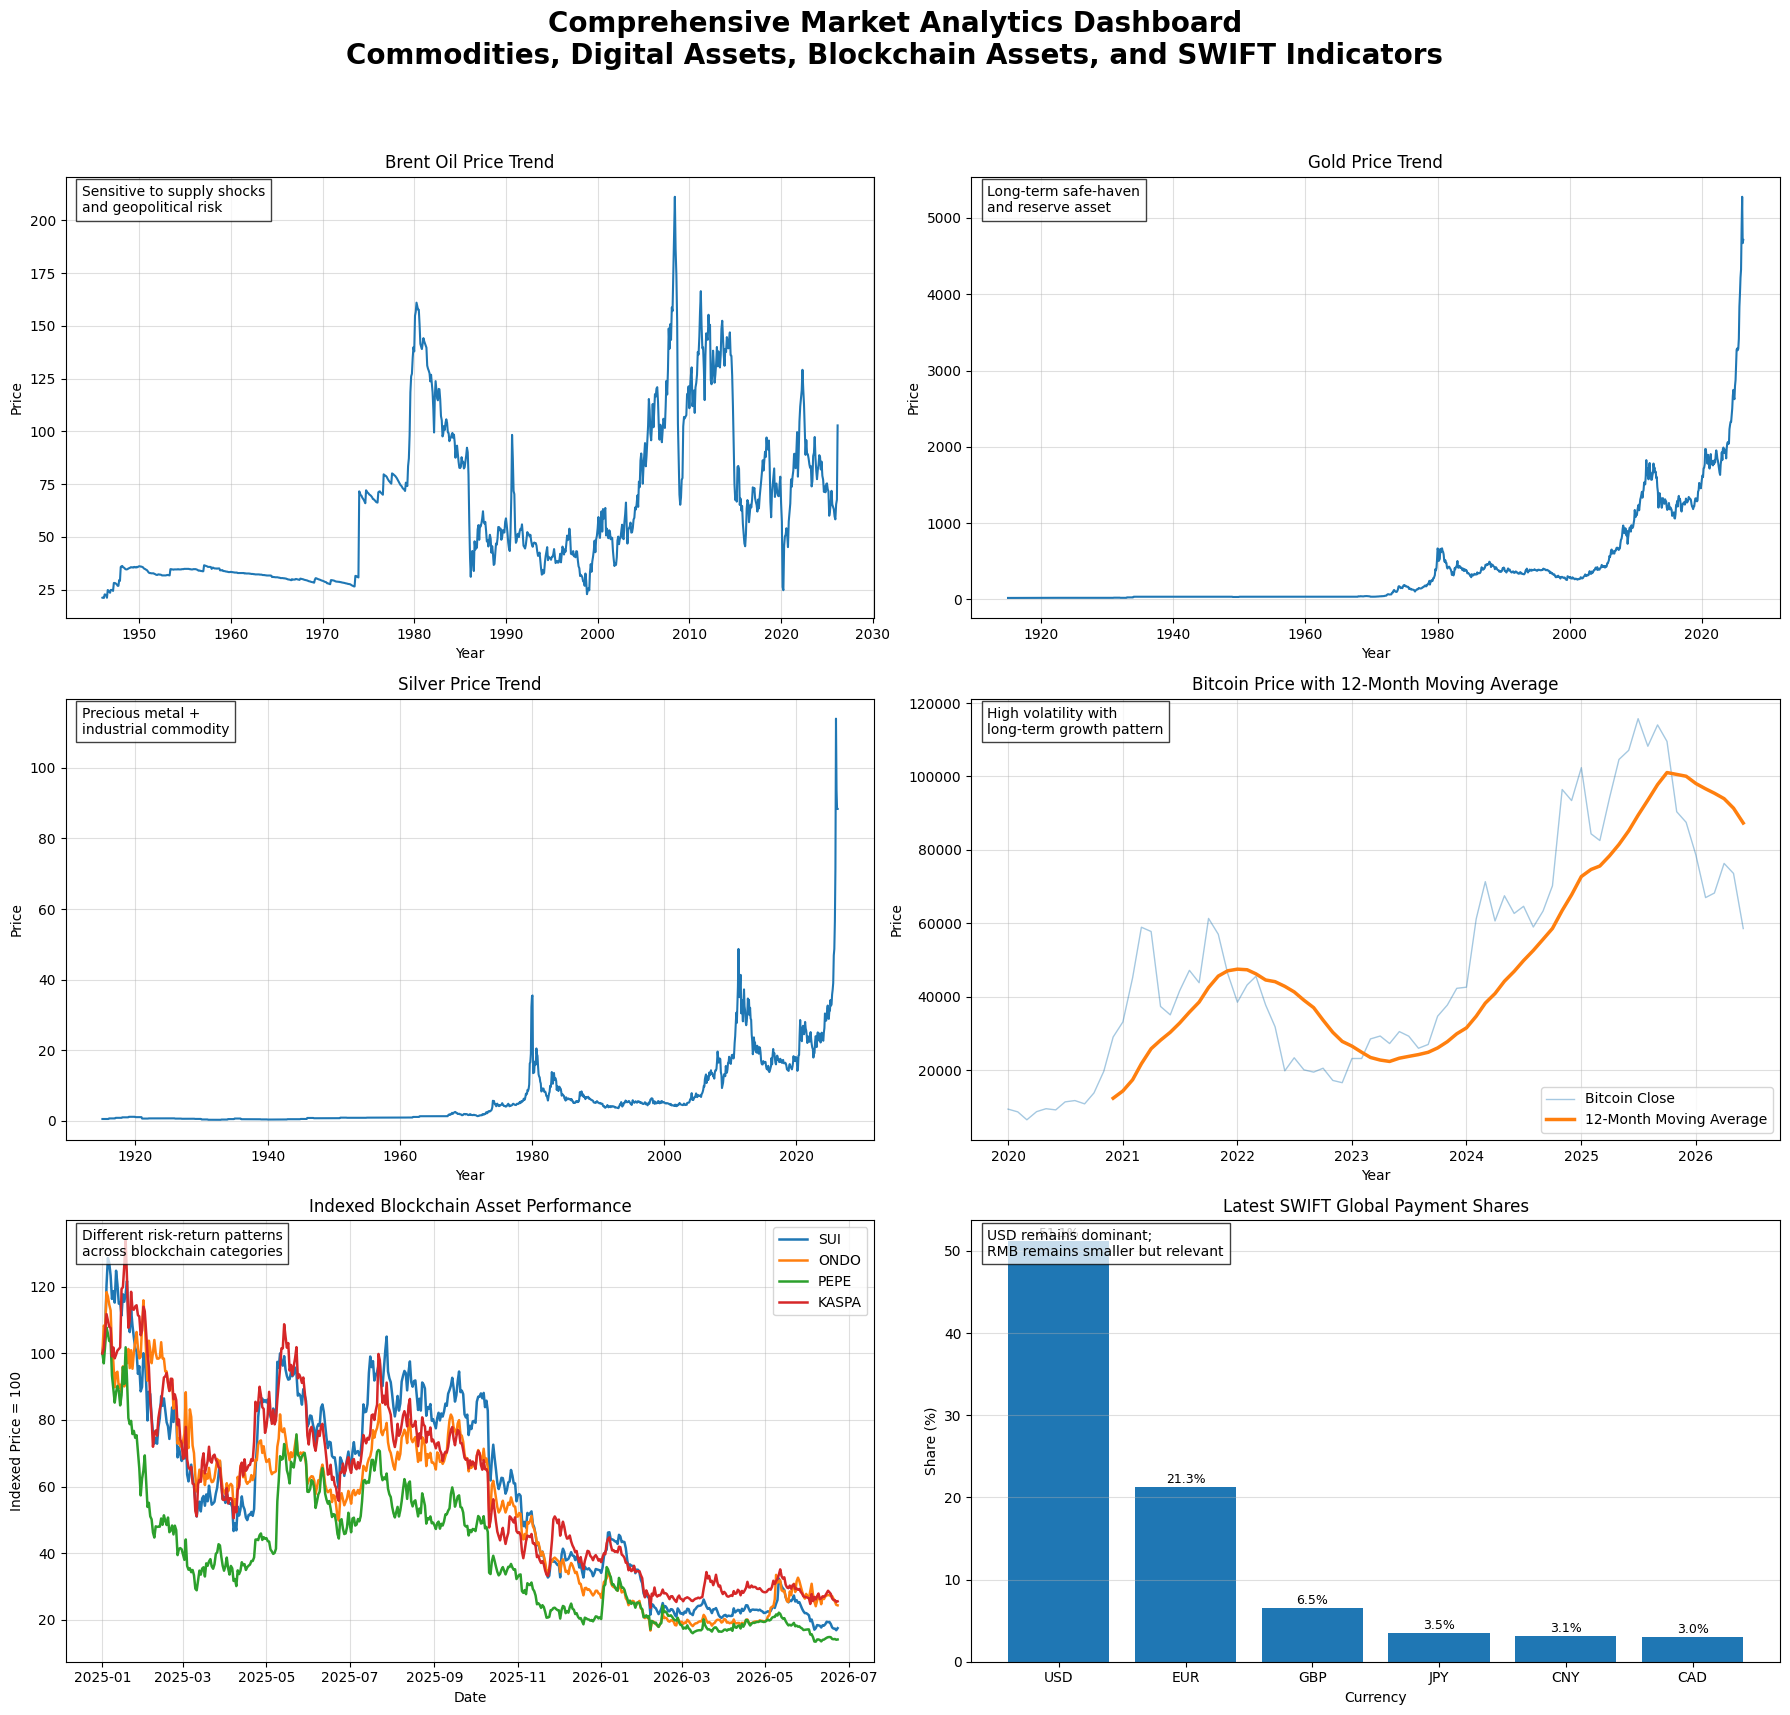

In [113]:
# ============================================================
# Comprehensive Market Analytics Dashboard
# Commodities + Bitcoin + Blockchain + SWIFT
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures/Part_C", exist_ok=True)

# ------------------------------------------------------------
# 1. Load commodity and SWIFT datasets
# ------------------------------------------------------------

base_path = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset"

oil = pd.read_csv(f"{base_path}/Brent Oil.csv")
gold = pd.read_csv(f"{base_path}/Gold 100years.csv")
silver = pd.read_csv(f"{base_path}/silver 100 years.csv")

oil["Date"] = pd.to_datetime(oil["Date"])
gold["Date"] = pd.to_datetime(gold["Date"])
silver["Date"] = pd.to_datetime(silver["Date"])

swift = pd.read_excel(
    f"{base_path}/swift_currency_tracker_research_ready_MAY_ADDED.xlsx",
    sheet_name="Cleaned_Data"
)

swift["data_month"] = pd.to_datetime(swift["data_month"])
swift["metric"] = swift["metric"].astype(str).str.strip()
swift["currency_or_economy"] = swift["currency_or_economy"].astype(str).str.strip()

# ------------------------------------------------------------
# 2. Load Bitcoin from Yahoo Finance
# ------------------------------------------------------------

!pip install yfinance -q

import yfinance as yf

btc = yf.download(
    "BTC-USD",
    start="2020-01-01",
    end="2026-06-30",
    interval="1mo",
    auto_adjust=True
)

btc.reset_index(inplace=True)

# Flatten yfinance MultiIndex columns if needed
btc.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in btc.columns
]

btc["Date"] = pd.to_datetime(btc["Date"])
btc = btc.sort_values("Date")
btc["MA_12"] = btc["Close"].rolling(window=12).mean()

# ------------------------------------------------------------
# 3. Load blockchain datasets
# ------------------------------------------------------------

crypto_path = "/kaggle/input/datasets/maryammoghaddasbayat/set2-crypto/Crypto_Market_Dataset_2025_2026-2.xlsx"

sheet_map = {
    "SUI": "sui-usd-max",
    "PEPE": "pepe-usd-max",
    "ONDO": "ondo-usd-max",
    "KASPA": "KAS-usd-max"
}

crypto_data = {}

for asset, sheet in sheet_map.items():
    temp = pd.read_excel(crypto_path, sheet_name=sheet)
    temp["Date"] = pd.to_datetime(temp["Clean_Date"])

    if asset == "SUI":
        temp = temp.rename(columns={
            "Price_USD": "Price",
            "Market_Cap_USD": "Market_Cap",
            "Volume_USD": "Volume"
        })
    else:
        temp = temp.rename(columns={
            "price": "Price",
            "market_cap": "Market_Cap",
            "total_volume": "Volume"
        })

    temp = temp[["Date", "Price", "Market_Cap", "Volume"]].dropna().sort_values("Date")
    crypto_data[asset] = temp

# Indexed blockchain prices
indexed_crypto = []

for asset, data in crypto_data.items():
    temp = data.copy()
    temp["Indexed_Price"] = temp["Price"] / temp["Price"].iloc[0] * 100
    temp["Asset"] = asset
    indexed_crypto.append(temp)

indexed_crypto = pd.concat(indexed_crypto)

# ------------------------------------------------------------
# 4. Prepare SWIFT latest payment shares
# ------------------------------------------------------------

major = ["USD", "EUR", "GBP", "JPY", "CAD", "CNY"]

payments = swift[
    (swift["metric"] == "Global Payment Share") &
    (swift["currency_or_economy"].isin(major))
].copy()

payments_latest = (
    payments
    .sort_values("data_month")
    .groupby("currency_or_economy")
    .tail(1)
    .sort_values("value", ascending=False)
)

# ------------------------------------------------------------
# 5. Build dashboard
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

fig.suptitle(
    "Comprehensive Market Analytics Dashboard\nCommodities, Digital Assets, Blockchain Assets, and SWIFT Indicators",
    fontsize=20,
    fontweight="bold"
)

# ---------------------------
# Panel 1: Brent Oil
# ---------------------------
axes[0, 0].plot(oil["Date"], oil["Value"], linewidth=1.5)
axes[0, 0].set_title("Brent Oil Price Trend")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Price")
axes[0, 0].grid(True, alpha=0.4)

axes[0, 0].text(
    0.02, 0.92,
    "Sensitive to supply shocks\nand geopolitical risk",
    transform=axes[0, 0].transAxes,
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.75)
)

# ---------------------------
# Panel 2: Gold
# ---------------------------
axes[0, 1].plot(gold["Date"], gold["Value"], linewidth=1.5)
axes[0, 1].set_title("Gold Price Trend")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Price")
axes[0, 1].grid(True, alpha=0.4)

axes[0, 1].text(
    0.02, 0.92,
    "Long-term safe-haven\nand reserve asset",
    transform=axes[0, 1].transAxes,
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.75)
)

# ---------------------------
# Panel 3: Silver
# ---------------------------
axes[1, 0].plot(silver["Date"], silver["Value"], linewidth=1.5)
axes[1, 0].set_title("Silver Price Trend")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Price")
axes[1, 0].grid(True, alpha=0.4)

axes[1, 0].text(
    0.02, 0.92,
    "Precious metal +\nindustrial commodity",
    transform=axes[1, 0].transAxes,
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.75)
)

# ---------------------------
# Panel 4: Bitcoin
# ---------------------------
axes[1, 1].plot(
    btc["Date"],
    btc["Close"],
    linewidth=1,
    alpha=0.4,
    label="Bitcoin Close"
)

axes[1, 1].plot(
    btc["Date"],
    btc["MA_12"],
    linewidth=2.5,
    label="12-Month Moving Average"
)

axes[1, 1].set_title("Bitcoin Price with 12-Month Moving Average")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Price")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.4)

axes[1, 1].text(
    0.02, 0.92,
    "High volatility with\nlong-term growth pattern",
    transform=axes[1, 1].transAxes,
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.75)
)

# ---------------------------
# Panel 5: Blockchain assets
# ---------------------------
for asset in ["SUI", "ONDO", "PEPE", "KASPA"]:
    temp = indexed_crypto[indexed_crypto["Asset"] == asset]
    axes[2, 0].plot(
        temp["Date"],
        temp["Indexed_Price"],
        linewidth=1.8,
        label=asset
    )

axes[2, 0].set_title("Indexed Blockchain Asset Performance")
axes[2, 0].set_xlabel("Date")
axes[2, 0].set_ylabel("Indexed Price = 100")
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.4)

axes[2, 0].text(
    0.02, 0.92,
    "Different risk-return patterns\nacross blockchain categories",
    transform=axes[2, 0].transAxes,
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.75)
)

# ---------------------------
# Panel 6: SWIFT
# ---------------------------
axes[2, 1].bar(
    payments_latest["currency_or_economy"],
    payments_latest["value"]
)

axes[2, 1].set_title("Latest SWIFT Global Payment Shares")
axes[2, 1].set_xlabel("Currency")
axes[2, 1].set_ylabel("Share (%)")
axes[2, 1].grid(axis="y", alpha=0.4)

for i, value in enumerate(payments_latest["value"]):
    axes[2, 1].text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )

axes[2, 1].text(
    0.02, 0.92,
    "USD remains dominant;\nRMB remains smaller but relevant",
    transform=axes[2, 1].transAxes,
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.75)
)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig(
    "figures/Part_C/Figure_Comprehensive_Market_Dashboard.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_23/2838382785.py:94: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  swift["data_month"] = pd.to_datetime(swift["data_month"])


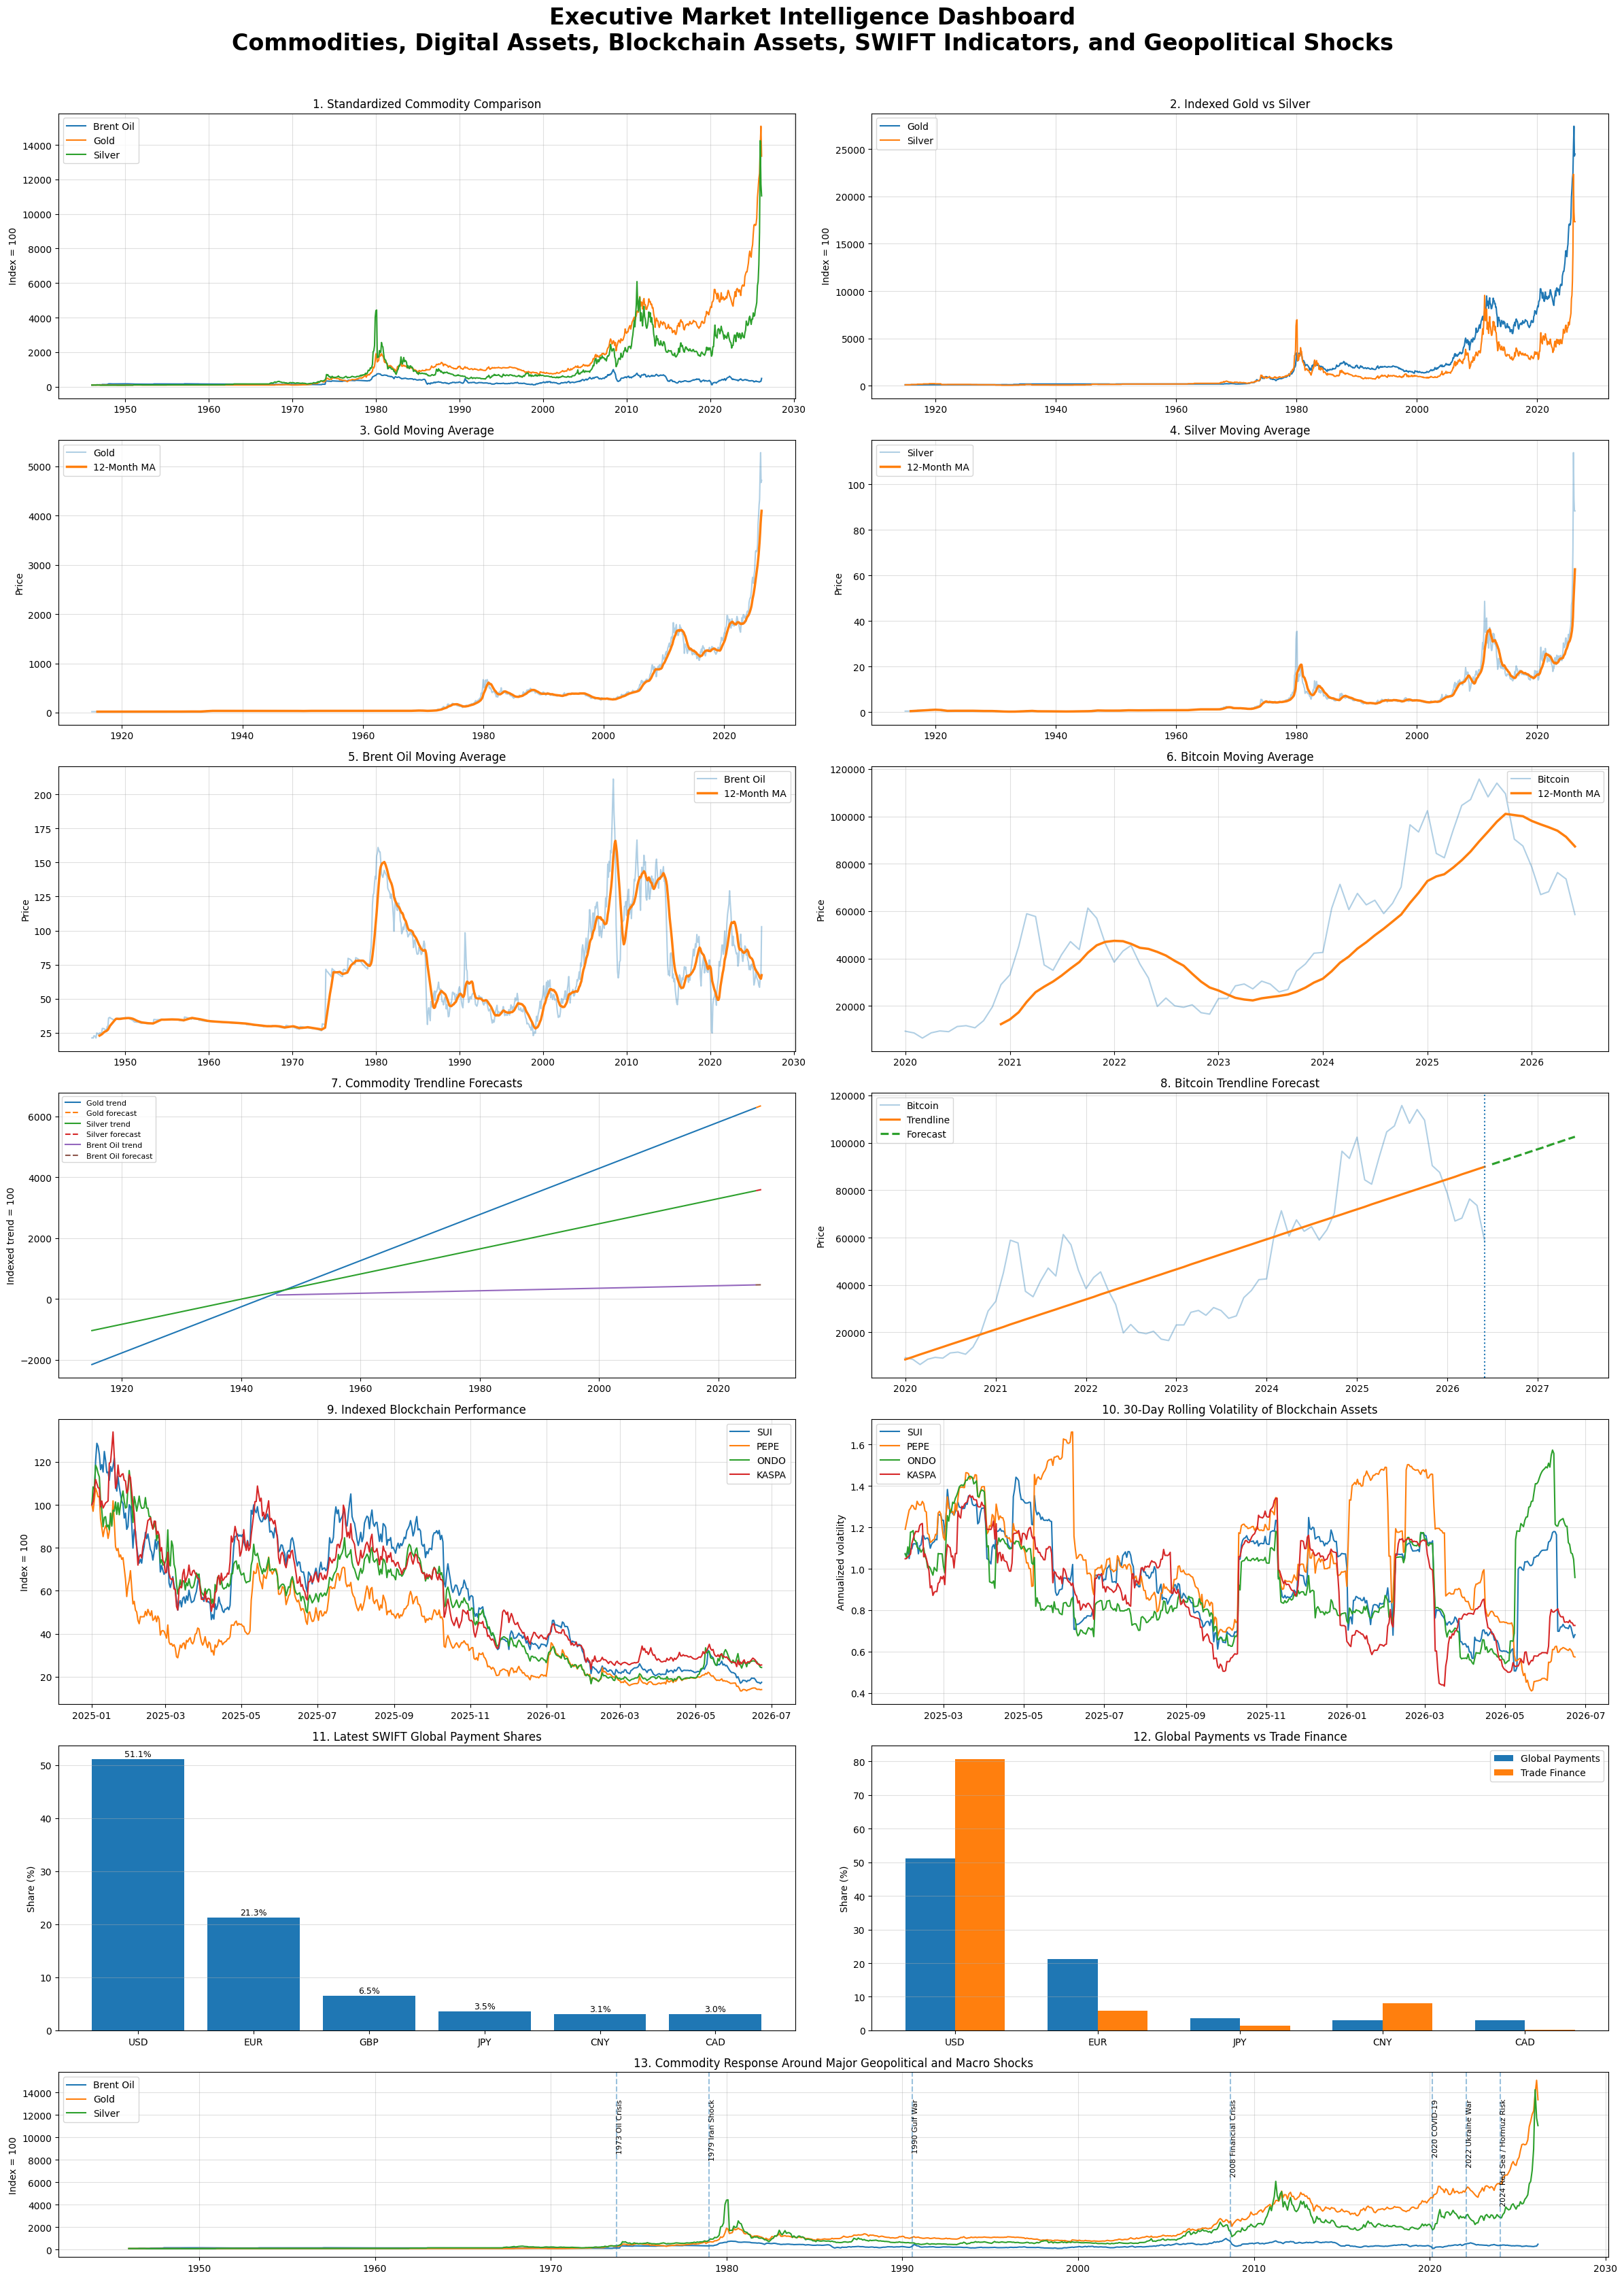

Dashboard saved to: figures/Part_C/Figure_Executive_Market_Intelligence_Dashboard.pdf


In [114]:
# ============================================================
# Executive Market Intelligence Dashboard
# Commodities + Bitcoin + Blockchain + SWIFT + Geopolitical Shocks
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures/Part_C", exist_ok=True)

# ------------------------------------------------------------
# 1. Load datasets
# ------------------------------------------------------------

base_path = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset"
crypto_path = "/kaggle/input/datasets/maryammoghaddasbayat/set2-crypto/Crypto_Market_Dataset_2025_2026-2.xlsx"

oil = pd.read_csv(f"{base_path}/Brent Oil.csv")
gold = pd.read_csv(f"{base_path}/Gold 100years.csv")
silver = pd.read_csv(f"{base_path}/silver 100 years.csv")

for df in [oil, gold, silver]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)

# ------------------------------------------------------------
# 2. Bitcoin
# ------------------------------------------------------------

!pip install yfinance -q
import yfinance as yf

btc = yf.download(
    "BTC-USD",
    start="2020-01-01",
    end="2026-06-30",
    interval="1mo",
    auto_adjust=True
)

btc.reset_index(inplace=True)
btc.columns = [col[0] if isinstance(col, tuple) else col for col in btc.columns]
btc["Date"] = pd.to_datetime(btc["Date"])
btc.sort_values("Date", inplace=True)
btc["MA_12"] = btc["Close"].rolling(12).mean()

# ------------------------------------------------------------
# 3. Blockchain data
# ------------------------------------------------------------

sheet_map = {
    "SUI": "sui-usd-max",
    "PEPE": "pepe-usd-max",
    "ONDO": "ondo-usd-max",
    "KASPA": "KAS-usd-max"
}

crypto_data = {}

for asset, sheet in sheet_map.items():
    temp = pd.read_excel(crypto_path, sheet_name=sheet)
    temp["Date"] = pd.to_datetime(temp["Clean_Date"])

    if asset == "SUI":
        temp = temp.rename(columns={
            "Price_USD": "Price",
            "Market_Cap_USD": "Market_Cap",
            "Volume_USD": "Volume"
        })
    else:
        temp = temp.rename(columns={
            "price": "Price",
            "market_cap": "Market_Cap",
            "total_volume": "Volume"
        })

    temp = temp[["Date", "Price", "Market_Cap", "Volume"]].dropna().sort_values("Date")
    temp["Return"] = temp["Price"].pct_change()
    temp["Rolling_Volatility"] = temp["Return"].rolling(30).std() * np.sqrt(365)
    temp["Indexed_Price"] = temp["Price"] / temp["Price"].iloc[0] * 100
    crypto_data[asset] = temp

# ------------------------------------------------------------
# 4. SWIFT data
# ------------------------------------------------------------

swift = pd.read_excel(
    f"{base_path}/swift_currency_tracker_research_ready_MAY_ADDED.xlsx",
    sheet_name="Cleaned_Data"
)

swift["data_month"] = pd.to_datetime(swift["data_month"])
swift["metric"] = swift["metric"].astype(str).str.strip()
swift["currency_or_economy"] = swift["currency_or_economy"].astype(str).str.strip()

major = ["USD", "EUR", "GBP", "JPY", "CAD", "CNY"]

payments = swift[
    (swift["metric"] == "Global Payment Share") &
    (swift["currency_or_economy"].isin(major))
].copy()

payments_latest = (
    payments.sort_values("data_month")
    .groupby("currency_or_economy")
    .tail(1)
    .sort_values("value", ascending=False)
)

trade = swift[
    (swift["metric"] == "Trade Finance Share") &
    (swift["currency_or_economy"].isin(major))
].copy()

trade_latest = (
    trade.sort_values("data_month")
    .groupby("currency_or_economy")
    .tail(1)
)

swift_compare = pd.merge(
    payments_latest[["currency_or_economy", "value"]],
    trade_latest[["currency_or_economy", "value"]],
    on="currency_or_economy",
    suffixes=("_Payments", "_Trade")
)

# ------------------------------------------------------------
# 5. Helper functions
# ------------------------------------------------------------

def add_moving_average(df, window=12):
    temp = df.copy()
    temp["MA_12"] = temp["Value"].rolling(window).mean()
    return temp

def add_trendline_forecast(df, forecast_months=12):
    temp = df[["Date", "Value"]].dropna().copy()
    temp = temp.sort_values("Date")
    temp["t"] = np.arange(len(temp))
    slope, intercept = np.polyfit(temp["t"], temp["Value"], 1)
    temp["Trendline"] = intercept + slope * temp["t"]

    future_dates = pd.date_range(
        start=temp["Date"].max() + pd.DateOffset(months=1),
        periods=forecast_months,
        freq="MS"
    )

    future_t = np.arange(len(temp), len(temp) + forecast_months)
    future_values = intercept + slope * future_t

    future = pd.DataFrame({
        "Date": future_dates,
        "Forecast": future_values
    })

    return temp, future

def add_btc_trendline_forecast(df, forecast_months=12):
    temp = df[["Date", "Close"]].dropna().copy()
    temp = temp.sort_values("Date")
    temp["t"] = np.arange(len(temp))
    slope, intercept = np.polyfit(temp["t"], temp["Close"], 1)
    temp["Trendline"] = intercept + slope * temp["t"]

    future_dates = pd.date_range(
        start=temp["Date"].max() + pd.DateOffset(months=1),
        periods=forecast_months,
        freq="MS"
    )

    future_t = np.arange(len(temp), len(temp) + forecast_months)
    future_values = intercept + slope * future_t

    future = pd.DataFrame({
        "Date": future_dates,
        "Forecast": future_values
    })

    return temp, future

gold_ma = add_moving_average(gold)
silver_ma = add_moving_average(silver)
oil_ma = add_moving_average(oil)

gold_trend, gold_future = add_trendline_forecast(gold)
silver_trend, silver_future = add_trendline_forecast(silver)
oil_trend, oil_future = add_trendline_forecast(oil)
btc_trend, btc_future = add_btc_trendline_forecast(btc)

# Standardized commodities from common start date
commodity = pd.merge(
    oil[["Date", "Value"]].rename(columns={"Value": "Oil"}),
    gold[["Date", "Value"]].rename(columns={"Value": "Gold"}),
    on="Date",
    how="inner"
)

commodity = pd.merge(
    commodity,
    silver[["Date", "Value"]].rename(columns={"Value": "Silver"}),
    on="Date",
    how="inner"
)

for col in ["Oil", "Gold", "Silver"]:
    commodity[col + "_Index"] = commodity[col] / commodity[col].iloc[0] * 100

# ------------------------------------------------------------
# 6. Create 13-panel dashboard
# ------------------------------------------------------------

fig = plt.figure(figsize=(24, 34))
gs = fig.add_gridspec(7, 2, height_ratios=[1, 1, 1, 1, 1, 1, 0.65])

fig.suptitle(
    "Executive Market Intelligence Dashboard\nCommodities, Digital Assets, Blockchain Assets, SWIFT Indicators, and Geopolitical Shocks",
    fontsize=24,
    fontweight="bold",
    y=0.995
)

# 1. Standardized commodities
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(commodity["Date"], commodity["Oil_Index"], label="Brent Oil")
ax1.plot(commodity["Date"], commodity["Gold_Index"], label="Gold")
ax1.plot(commodity["Date"], commodity["Silver_Index"], label="Silver")
ax1.set_title("1. Standardized Commodity Comparison")
ax1.set_ylabel("Index = 100")
ax1.grid(True, alpha=0.4)
ax1.legend()

# 2. Gold vs Silver indexed
ax2 = fig.add_subplot(gs[0, 1])
gold_silver = pd.merge(
    gold[["Date", "Value"]].rename(columns={"Value": "Gold"}),
    silver[["Date", "Value"]].rename(columns={"Value": "Silver"}),
    on="Date",
    how="inner"
)
gold_silver["Gold_Index"] = gold_silver["Gold"] / gold_silver["Gold"].iloc[0] * 100
gold_silver["Silver_Index"] = gold_silver["Silver"] / gold_silver["Silver"].iloc[0] * 100
ax2.plot(gold_silver["Date"], gold_silver["Gold_Index"], label="Gold")
ax2.plot(gold_silver["Date"], gold_silver["Silver_Index"], label="Silver")
ax2.set_title("2. Indexed Gold vs Silver")
ax2.set_ylabel("Index = 100")
ax2.grid(True, alpha=0.4)
ax2.legend()

# 3. Gold MA
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(gold_ma["Date"], gold_ma["Value"], alpha=0.35, label="Gold")
ax3.plot(gold_ma["Date"], gold_ma["MA_12"], linewidth=2.5, label="12-Month MA")
ax3.set_title("3. Gold Moving Average")
ax3.set_ylabel("Price")
ax3.grid(True, alpha=0.4)
ax3.legend()

# 4. Silver MA
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(silver_ma["Date"], silver_ma["Value"], alpha=0.35, label="Silver")
ax4.plot(silver_ma["Date"], silver_ma["MA_12"], linewidth=2.5, label="12-Month MA")
ax4.set_title("4. Silver Moving Average")
ax4.set_ylabel("Price")
ax4.grid(True, alpha=0.4)
ax4.legend()

# 5. Oil MA
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(oil_ma["Date"], oil_ma["Value"], alpha=0.35, label="Brent Oil")
ax5.plot(oil_ma["Date"], oil_ma["MA_12"], linewidth=2.5, label="12-Month MA")
ax5.set_title("5. Brent Oil Moving Average")
ax5.set_ylabel("Price")
ax5.grid(True, alpha=0.4)
ax5.legend()

# 6. Bitcoin MA
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(btc["Date"], btc["Close"], alpha=0.35, label="Bitcoin")
ax6.plot(btc["Date"], btc["MA_12"], linewidth=2.5, label="12-Month MA")
ax6.set_title("6. Bitcoin Moving Average")
ax6.set_ylabel("Price")
ax6.grid(True, alpha=0.4)
ax6.legend()

# 7. Commodity trendline forecasts
ax7 = fig.add_subplot(gs[3, 0])
for trend, future, name in [
    (gold_trend, gold_future, "Gold"),
    (silver_trend, silver_future, "Silver"),
    (oil_trend, oil_future, "Brent Oil")
]:
    # index for visual comparison
    first_value = trend["Value"].iloc[0]
    ax7.plot(trend["Date"], trend["Trendline"] / first_value * 100, label=f"{name} trend")
    ax7.plot(future["Date"], future["Forecast"] / first_value * 100, linestyle="--", label=f"{name} forecast")
ax7.set_title("7. Commodity Trendline Forecasts")
ax7.set_ylabel("Indexed trend = 100")
ax7.grid(True, alpha=0.4)
ax7.legend(fontsize=8)

# 8. Bitcoin trendline forecast
ax8 = fig.add_subplot(gs[3, 1])
ax8.plot(btc_trend["Date"], btc_trend["Close"], alpha=0.35, label="Bitcoin")
ax8.plot(btc_trend["Date"], btc_trend["Trendline"], linewidth=2.3, label="Trendline")
ax8.plot(btc_future["Date"], btc_future["Forecast"], linestyle="--", linewidth=2.3, label="Forecast")
ax8.axvline(btc_trend["Date"].max(), linestyle=":", linewidth=1.5)
ax8.set_title("8. Bitcoin Trendline Forecast")
ax8.set_ylabel("Price")
ax8.grid(True, alpha=0.4)
ax8.legend()

# 9. Blockchain indexed performance
ax9 = fig.add_subplot(gs[4, 0])
for asset, data in crypto_data.items():
    ax9.plot(data["Date"], data["Indexed_Price"], label=asset)
ax9.set_title("9. Indexed Blockchain Performance")
ax9.set_ylabel("Index = 100")
ax9.grid(True, alpha=0.4)
ax9.legend()

# 10. Blockchain rolling volatility
ax10 = fig.add_subplot(gs[4, 1])
for asset, data in crypto_data.items():
    ax10.plot(data["Date"], data["Rolling_Volatility"], label=asset)
ax10.set_title("10. 30-Day Rolling Volatility of Blockchain Assets")
ax10.set_ylabel("Annualized volatility")
ax10.grid(True, alpha=0.4)
ax10.legend()

# 11. SWIFT payment shares
ax11 = fig.add_subplot(gs[5, 0])
bars = ax11.bar(payments_latest["currency_or_economy"], payments_latest["value"])
ax11.set_title("11. Latest SWIFT Global Payment Shares")
ax11.set_ylabel("Share (%)")
ax11.grid(axis="y", alpha=0.4)
for i, v in enumerate(payments_latest["value"]):
    ax11.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

# 12. SWIFT global payments vs trade finance
ax12 = fig.add_subplot(gs[5, 1])
x = np.arange(len(swift_compare))
width = 0.35
ax12.bar(x - width/2, swift_compare["value_Payments"], width, label="Global Payments")
ax12.bar(x + width/2, swift_compare["value_Trade"], width, label="Trade Finance")
ax12.set_xticks(x)
ax12.set_xticklabels(swift_compare["currency_or_economy"])
ax12.set_title("12. Global Payments vs Trade Finance")
ax12.set_ylabel("Share (%)")
ax12.grid(axis="y", alpha=0.4)
ax12.legend()

# 13. Geopolitical shocks vs standardized commodities
ax13 = fig.add_subplot(gs[6, :])
ax13.plot(commodity["Date"], commodity["Oil_Index"], label="Brent Oil")
ax13.plot(commodity["Date"], commodity["Gold_Index"], label="Gold")
ax13.plot(commodity["Date"], commodity["Silver_Index"], label="Silver")

events = {
    "1973 Oil Crisis": "1973-10-01",
    "1979 Iran Shock": "1979-01-01",
    "1990 Gulf War": "1990-08-01",
    "2008 Financial Crisis": "2008-09-01",
    "2020 COVID-19": "2020-03-01",
    "2022 Ukraine War": "2022-02-01",
    "2024 Red Sea / Hormuz Risk": "2024-01-01"
}

for label, date in events.items():
    date = pd.to_datetime(date)
    ax13.axvline(date, linestyle="--", alpha=0.45)
    ax13.text(
        date,
        ax13.get_ylim()[1] * 0.85,
        label,
        rotation=90,
        fontsize=8,
        verticalalignment="top"
    )

ax13.set_title("13. Commodity Response Around Major Geopolitical and Macro Shocks")
ax13.set_ylabel("Index = 100")
ax13.grid(True, alpha=0.4)
ax13.legend(loc="upper left")

plt.tight_layout(rect=[0, 0.01, 1, 0.985])

output_path = "figures/Part_C/Figure_Executive_Market_Intelligence_Dashboard.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()

print("Dashboard saved to:", output_path)

In [115]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures/Dashboard", exist_ok=True)

base_path = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset"
crypto_path = "/kaggle/input/datasets/maryammoghaddasbayat/set2-crypto/Crypto_Market_Dataset_2025_2026-2.xlsx"

oil = pd.read_csv(f"{base_path}/Brent Oil.csv")
gold = pd.read_csv(f"{base_path}/Gold 100years.csv")
silver = pd.read_csv(f"{base_path}/silver 100 years.csv")

for df in [oil, gold, silver]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)

# Bitcoin
!pip install yfinance -q
import yfinance as yf

btc = yf.download(
    "BTC-USD",
    start="2020-01-01",
    end="2026-06-30",
    interval="1mo",
    auto_adjust=True
)

btc.reset_index(inplace=True)
btc.columns = [col[0] if isinstance(col, tuple) else col for col in btc.columns]
btc["Date"] = pd.to_datetime(btc["Date"])
btc.sort_values("Date", inplace=True)

# Blockchain
sheet_map = {
    "SUI": "sui-usd-max",
    "PEPE": "pepe-usd-max",
    "ONDO": "ondo-usd-max",
    "KASPA": "KAS-usd-max"
}

crypto_data = {}

for asset, sheet in sheet_map.items():
    temp = pd.read_excel(crypto_path, sheet_name=sheet)
    temp["Date"] = pd.to_datetime(temp["Clean_Date"])

    if asset == "SUI":
        temp = temp.rename(columns={
            "Price_USD": "Price",
            "Market_Cap_USD": "Market_Cap",
            "Volume_USD": "Volume"
        })
    else:
        temp = temp.rename(columns={
            "price": "Price",
            "market_cap": "Market_Cap",
            "total_volume": "Volume"
        })

    temp = temp[["Date", "Price", "Market_Cap", "Volume"]].dropna().sort_values("Date")
    temp["Return"] = temp["Price"].pct_change()
    temp["Rolling_Volatility"] = temp["Return"].rolling(30).std() * np.sqrt(365)
    temp["Indexed_Price"] = temp["Price"] / temp["Price"].iloc[0] * 100
    crypto_data[asset] = temp

# SWIFT
swift = pd.read_excel(
    f"{base_path}/swift_currency_tracker_research_ready_MAY_ADDED.xlsx",
    sheet_name="Cleaned_Data"
)

swift["data_month"] = pd.to_datetime(swift["data_month"])
swift["metric"] = swift["metric"].astype(str).str.strip()
swift["currency_or_economy"] = swift["currency_or_economy"].astype(str).str.strip()

print("All datasets loaded.")

[*********************100%***********************]  1 of 1 completed


All datasets loaded.


/tmp/ipykernel_23/3099697855.py:75: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  swift["data_month"] = pd.to_datetime(swift["data_month"])


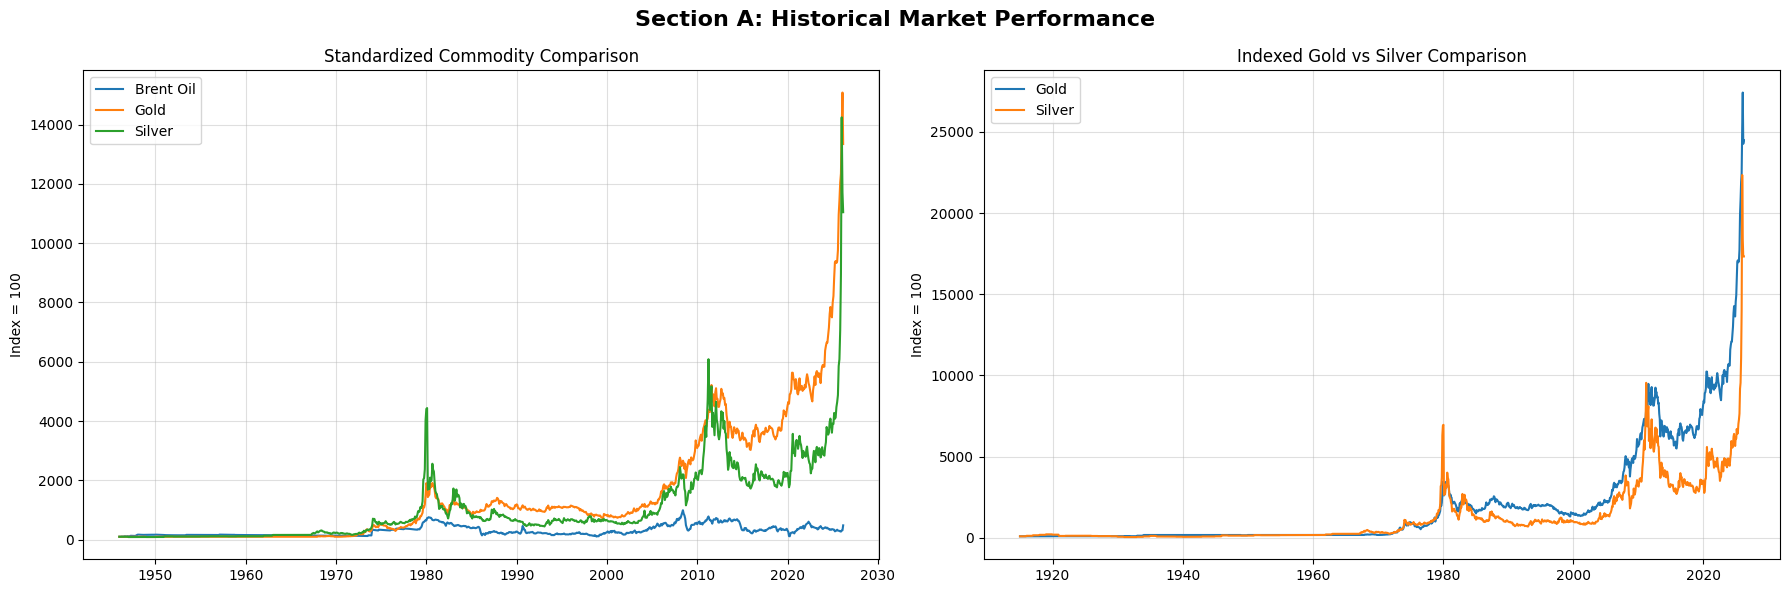

In [116]:
commodity = pd.merge(
    oil[["Date", "Value"]].rename(columns={"Value": "Oil"}),
    gold[["Date", "Value"]].rename(columns={"Value": "Gold"}),
    on="Date",
    how="inner"
)

commodity = pd.merge(
    commodity,
    silver[["Date", "Value"]].rename(columns={"Value": "Silver"}),
    on="Date",
    how="inner"
)

for col in ["Oil", "Gold", "Silver"]:
    commodity[col + "_Index"] = commodity[col] / commodity[col].iloc[0] * 100

gold_silver = pd.merge(
    gold[["Date", "Value"]].rename(columns={"Value": "Gold"}),
    silver[["Date", "Value"]].rename(columns={"Value": "Silver"}),
    on="Date",
    how="inner"
)

gold_silver["Gold_Index"] = gold_silver["Gold"] / gold_silver["Gold"].iloc[0] * 100
gold_silver["Silver_Index"] = gold_silver["Silver"] / gold_silver["Silver"].iloc[0] * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(commodity["Date"], commodity["Oil_Index"], label="Brent Oil")
axes[0].plot(commodity["Date"], commodity["Gold_Index"], label="Gold")
axes[0].plot(commodity["Date"], commodity["Silver_Index"], label="Silver")
axes[0].set_title("Standardized Commodity Comparison")
axes[0].set_ylabel("Index = 100")
axes[0].grid(True, alpha=0.4)
axes[0].legend()

axes[1].plot(gold_silver["Date"], gold_silver["Gold_Index"], label="Gold")
axes[1].plot(gold_silver["Date"], gold_silver["Silver_Index"], label="Silver")
axes[1].set_title("Indexed Gold vs Silver Comparison")
axes[1].set_ylabel("Index = 100")
axes[1].grid(True, alpha=0.4)
axes[1].legend()

fig.suptitle("Section A: Historical Market Performance", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig(
    "figures/Dashboard/Dashboard_Section_A_Historical_Market_Performance.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

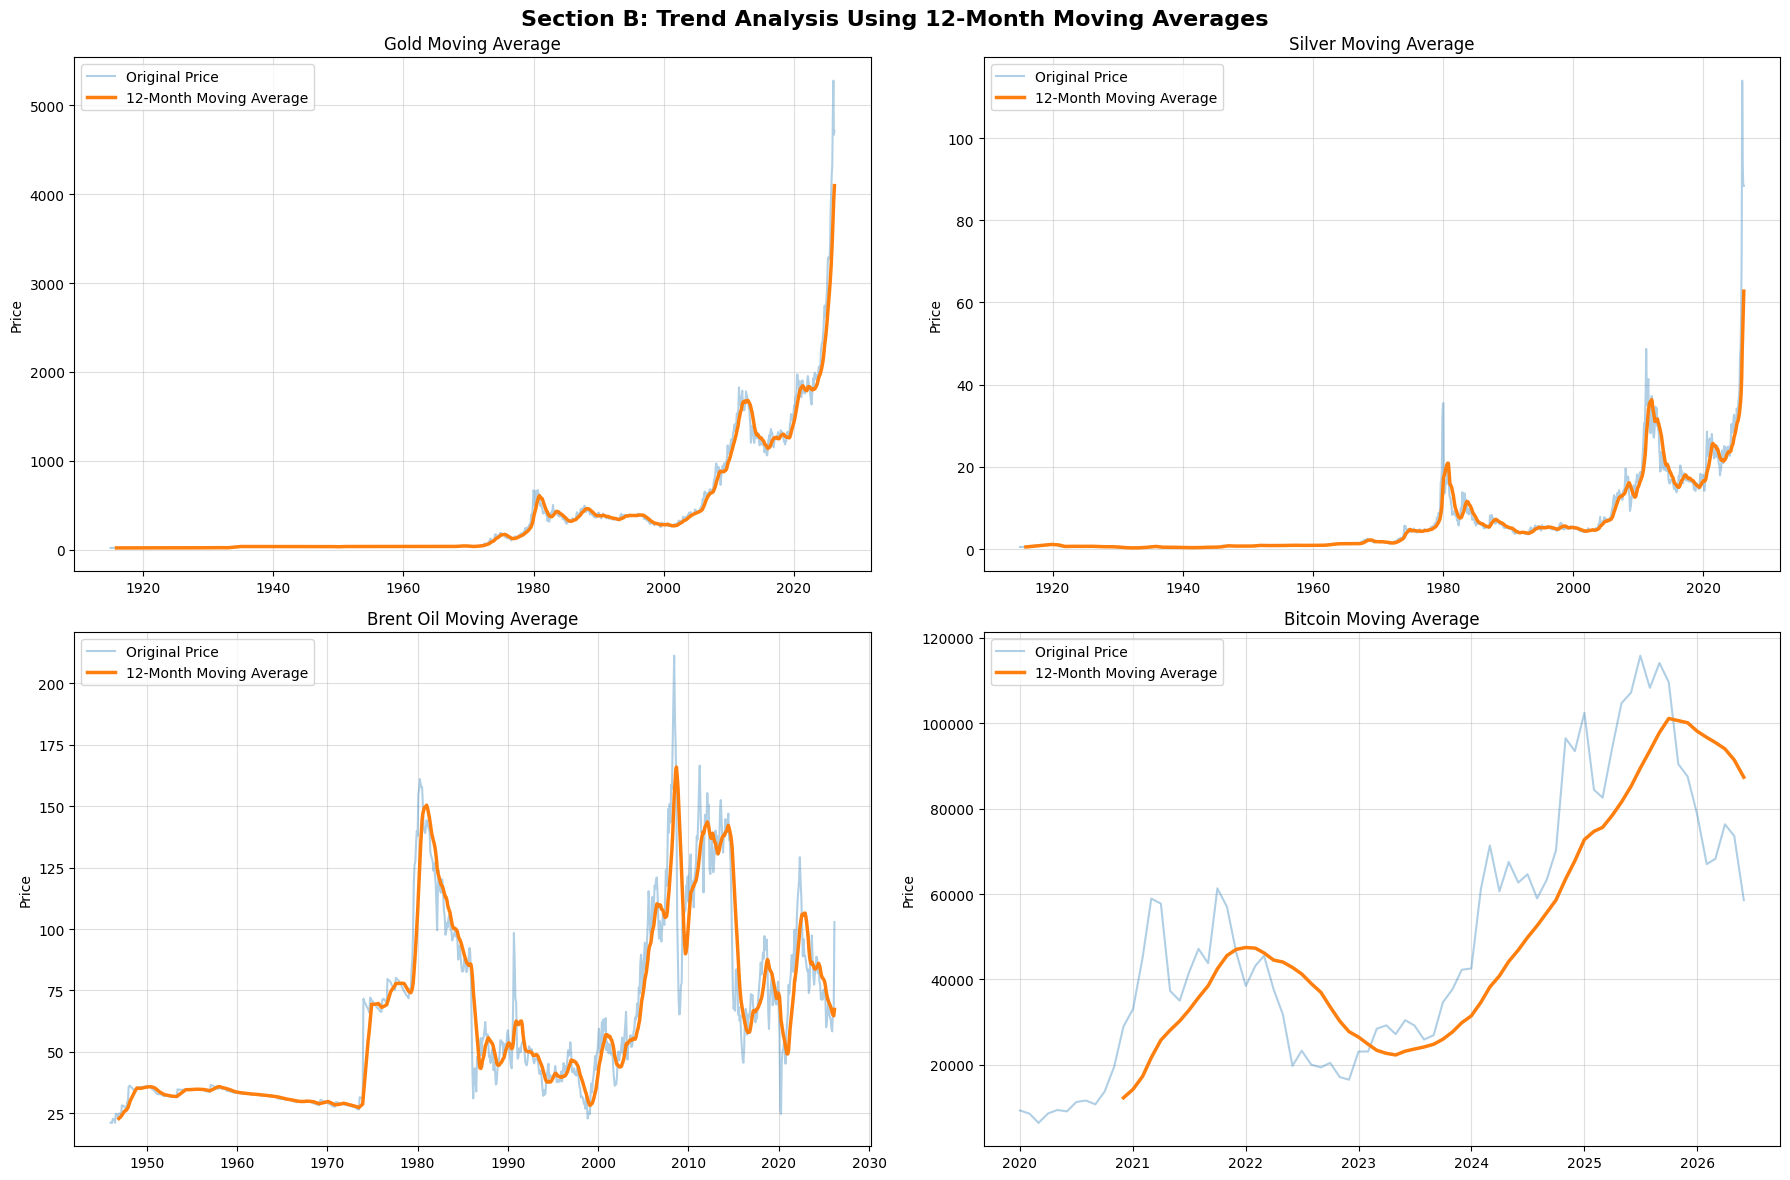

In [117]:
gold["MA_12"] = gold["Value"].rolling(12).mean()
silver["MA_12"] = silver["Value"].rolling(12).mean()
oil["MA_12"] = oil["Value"].rolling(12).mean()
btc["MA_12"] = btc["Close"].rolling(12).mean()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

assets = [
    (gold, "Gold", "Value"),
    (silver, "Silver", "Value"),
    (oil, "Brent Oil", "Value"),
    (btc, "Bitcoin", "Close")
]

for ax, (data, name, col) in zip(axes.flatten(), assets):
    ax.plot(data["Date"], data[col], alpha=0.35, label="Original Price")
    ax.plot(data["Date"], data["MA_12"], linewidth=2.5, label="12-Month Moving Average")
    ax.set_title(f"{name} Moving Average")
    ax.set_ylabel("Price")
    ax.grid(True, alpha=0.4)
    ax.legend()

fig.suptitle("Section B: Trend Analysis Using 12-Month Moving Averages", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig(
    "figures/Dashboard/Dashboard_Section_B_Moving_Averages.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

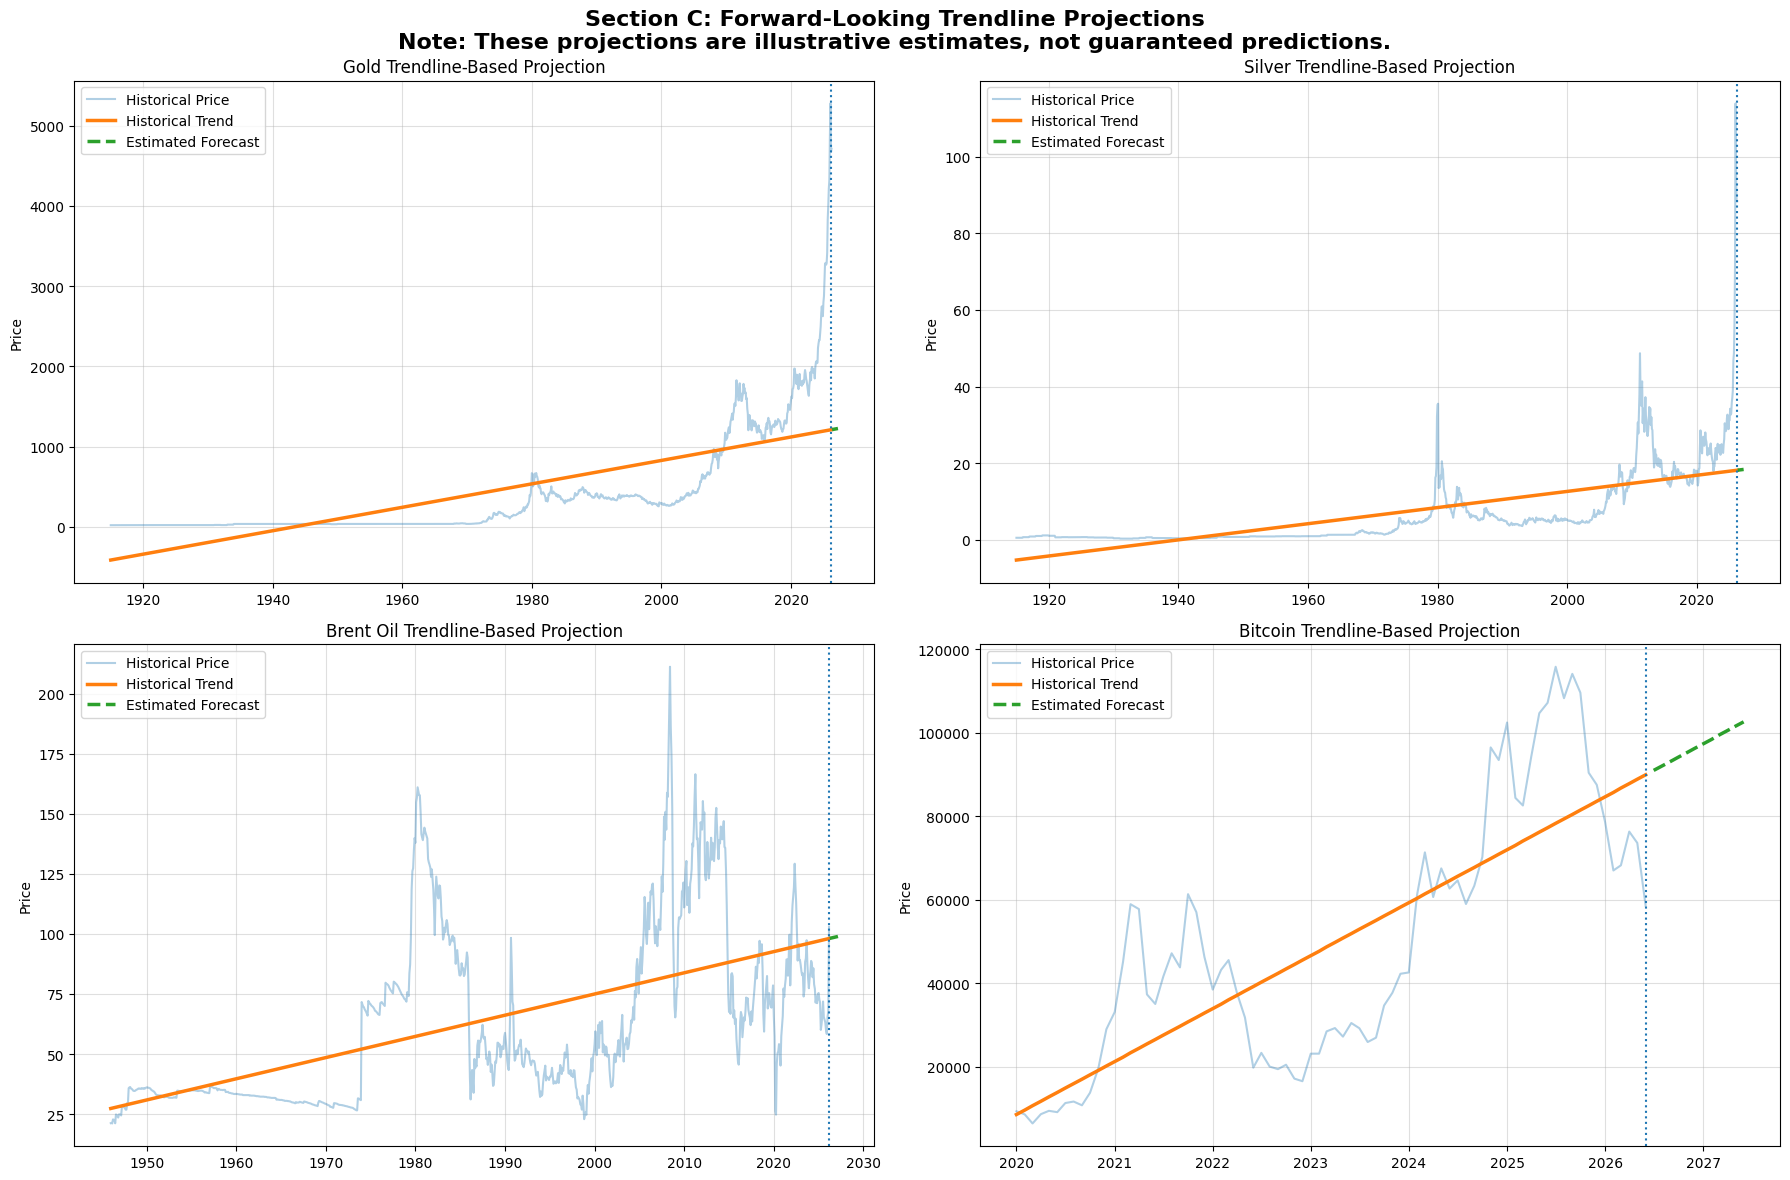

In [118]:
def trendline_forecast(data, value_col, forecast_months=12):
    temp = data[["Date", value_col]].dropna().copy()
    temp = temp.sort_values("Date")
    temp["t"] = np.arange(len(temp))

    slope, intercept = np.polyfit(temp["t"], temp[value_col], 1)
    temp["Trendline"] = intercept + slope * temp["t"]

    future_dates = pd.date_range(
        start=temp["Date"].max() + pd.DateOffset(months=1),
        periods=forecast_months,
        freq="MS"
    )

    future_t = np.arange(len(temp), len(temp) + forecast_months)
    future_values = intercept + slope * future_t

    future = pd.DataFrame({
        "Date": future_dates,
        "Forecast": future_values
    })

    return temp, future

gold_trend, gold_future = trendline_forecast(gold, "Value")
silver_trend, silver_future = trendline_forecast(silver, "Value")
oil_trend, oil_future = trendline_forecast(oil, "Value")
btc_trend, btc_future = trendline_forecast(btc.rename(columns={"Close": "Value"}), "Value")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

items = [
    (gold_trend, gold_future, "Gold"),
    (silver_trend, silver_future, "Silver"),
    (oil_trend, oil_future, "Brent Oil"),
    (btc_trend, btc_future, "Bitcoin")
]

for ax, (trend, future, name) in zip(axes.flatten(), items):
    ax.plot(trend["Date"], trend.iloc[:, 1], alpha=0.35, label="Historical Price")
    ax.plot(trend["Date"], trend["Trendline"], linewidth=2.5, label="Historical Trend")
    ax.plot(future["Date"], future["Forecast"], linestyle="--", linewidth=2.5, label="Estimated Forecast")
    ax.axvline(trend["Date"].max(), linestyle=":", linewidth=1.5)
    ax.set_title(f"{name} Trendline-Based Projection")
    ax.set_ylabel("Price")
    ax.grid(True, alpha=0.4)
    ax.legend()

fig.suptitle(
    "Section C: Forward-Looking Trendline Projections\nNote: These projections are illustrative estimates, not guaranteed predictions.",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "figures/Dashboard/Dashboard_Section_C_Trendline_Projections.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

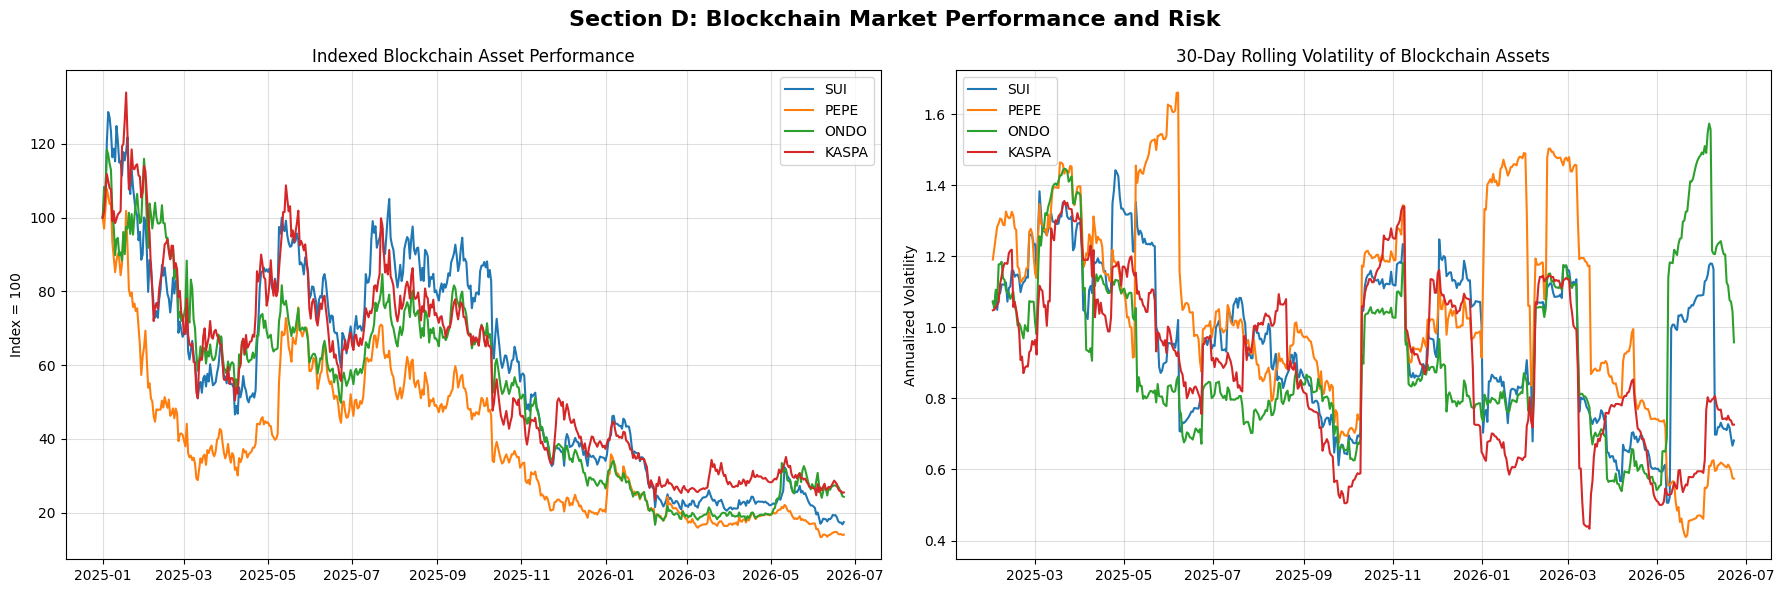

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for asset, data in crypto_data.items():
    axes[0].plot(data["Date"], data["Indexed_Price"], label=asset)

axes[0].set_title("Indexed Blockchain Asset Performance")
axes[0].set_ylabel("Index = 100")
axes[0].grid(True, alpha=0.4)
axes[0].legend()

for asset, data in crypto_data.items():
    axes[1].plot(data["Date"], data["Rolling_Volatility"], label=asset)

axes[1].set_title("30-Day Rolling Volatility of Blockchain Assets")
axes[1].set_ylabel("Annualized Volatility")
axes[1].grid(True, alpha=0.4)
axes[1].legend()

fig.suptitle("Section D: Blockchain Market Performance and Risk", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig(
    "figures/Dashboard/Dashboard_Section_D_Blockchain_Market.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

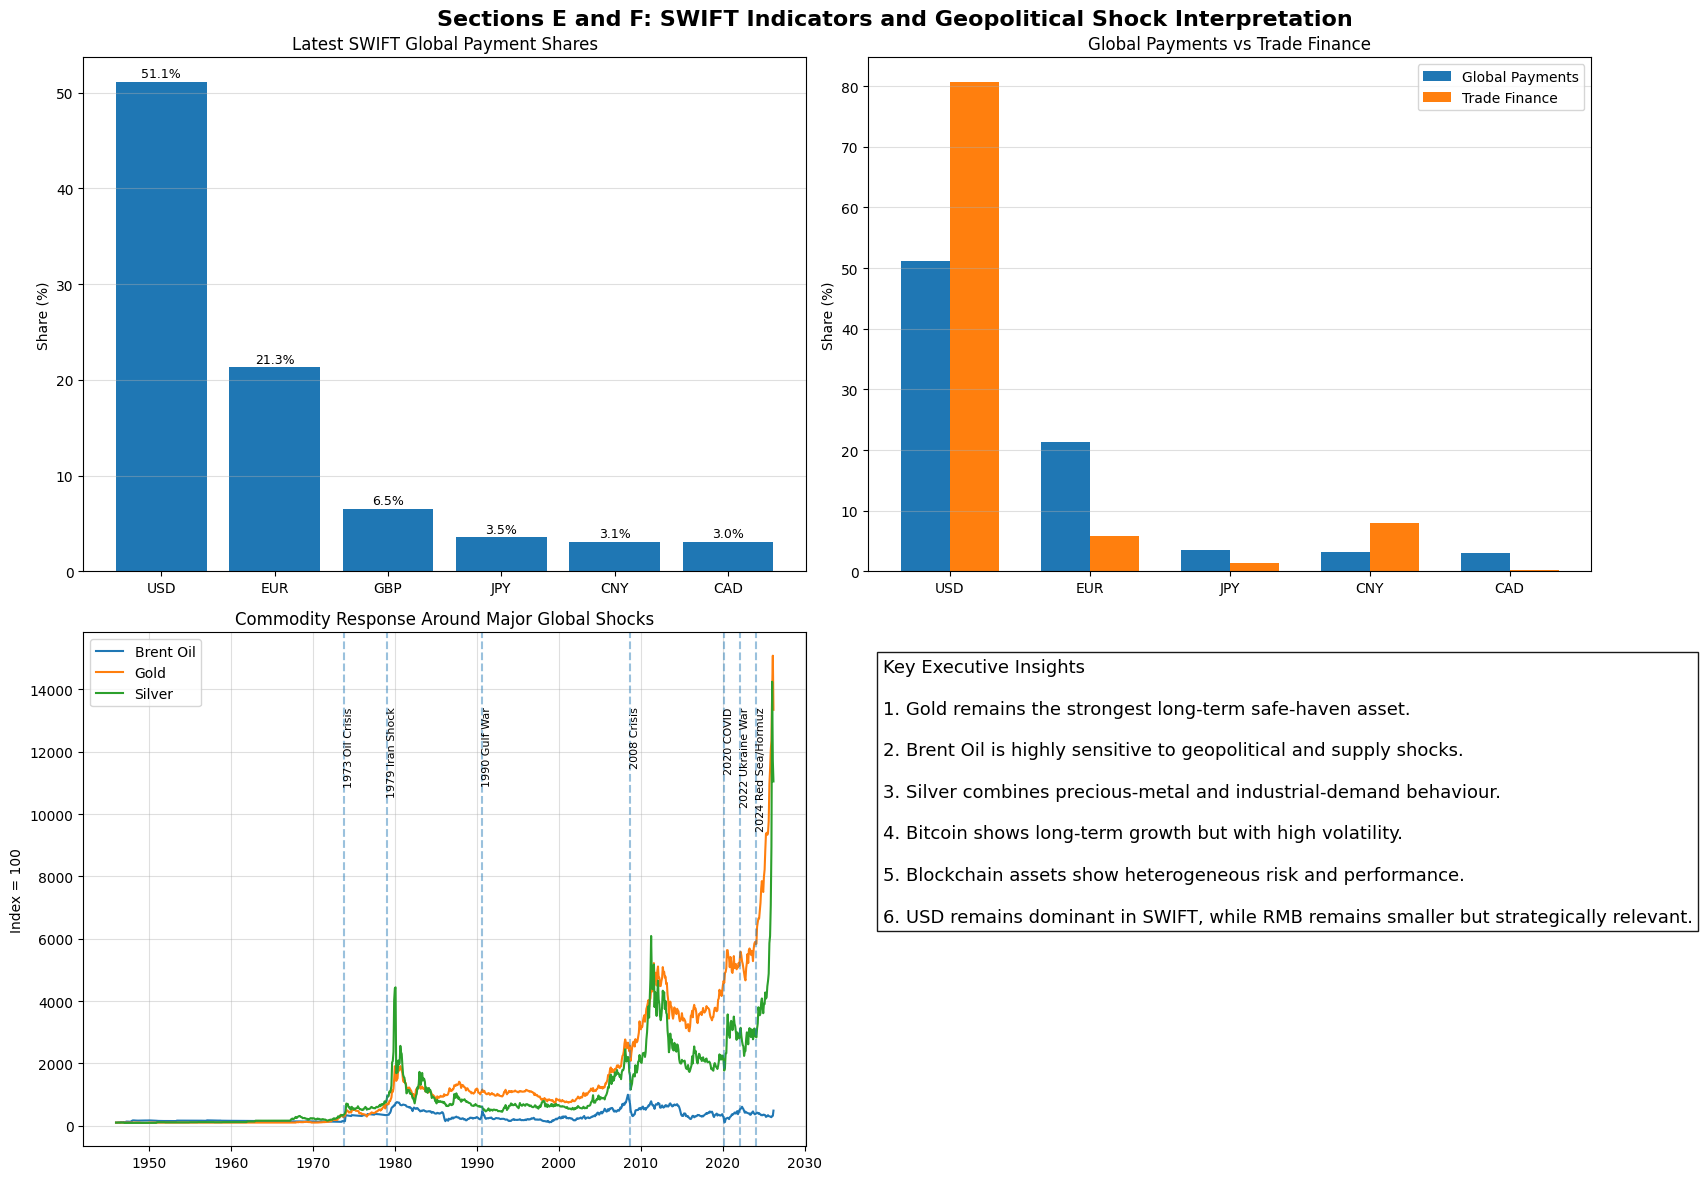

In [120]:
major = ["USD", "EUR", "GBP", "JPY", "CAD", "CNY"]

payments = swift[
    (swift["metric"] == "Global Payment Share") &
    (swift["currency_or_economy"].isin(major))
].copy()

payments_latest = (
    payments.sort_values("data_month")
    .groupby("currency_or_economy")
    .tail(1)
    .sort_values("value", ascending=False)
)

trade = swift[
    (swift["metric"] == "Trade Finance Share") &
    (swift["currency_or_economy"].isin(major))
].copy()

trade_latest = (
    trade.sort_values("data_month")
    .groupby("currency_or_economy")
    .tail(1)
)

swift_compare = pd.merge(
    payments_latest[["currency_or_economy", "value"]],
    trade_latest[["currency_or_economy", "value"]],
    on="currency_or_economy",
    suffixes=("_Payments", "_Trade")
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# SWIFT payment shares
axes[0, 0].bar(payments_latest["currency_or_economy"], payments_latest["value"])
axes[0, 0].set_title("Latest SWIFT Global Payment Shares")
axes[0, 0].set_ylabel("Share (%)")
axes[0, 0].grid(axis="y", alpha=0.4)

for i, v in enumerate(payments_latest["value"]):
    axes[0, 0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

# SWIFT payments vs trade finance
x = np.arange(len(swift_compare))
width = 0.35

axes[0, 1].bar(x - width/2, swift_compare["value_Payments"], width, label="Global Payments")
axes[0, 1].bar(x + width/2, swift_compare["value_Trade"], width, label="Trade Finance")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(swift_compare["currency_or_economy"])
axes[0, 1].set_title("Global Payments vs Trade Finance")
axes[0, 1].set_ylabel("Share (%)")
axes[0, 1].grid(axis="y", alpha=0.4)
axes[0, 1].legend()

# Geopolitical shocks vs standardized commodities
axes[1, 0].plot(commodity["Date"], commodity["Oil_Index"], label="Brent Oil")
axes[1, 0].plot(commodity["Date"], commodity["Gold_Index"], label="Gold")
axes[1, 0].plot(commodity["Date"], commodity["Silver_Index"], label="Silver")

events = {
    "1973 Oil Crisis": "1973-10-01",
    "1979 Iran Shock": "1979-01-01",
    "1990 Gulf War": "1990-08-01",
    "2008 Crisis": "2008-09-01",
    "2020 COVID": "2020-03-01",
    "2022 Ukraine War": "2022-02-01",
    "2024 Red Sea/Hormuz": "2024-01-01"
}

for label, date in events.items():
    date = pd.to_datetime(date)
    axes[1, 0].axvline(date, linestyle="--", alpha=0.45)
    axes[1, 0].text(
        date,
        axes[1, 0].get_ylim()[1] * 0.85,
        label,
        rotation=90,
        fontsize=8,
        verticalalignment="top"
    )

axes[1, 0].set_title("Commodity Response Around Major Global Shocks")
axes[1, 0].set_ylabel("Index = 100")
axes[1, 0].grid(True, alpha=0.4)
axes[1, 0].legend()

# Key dashboard insights box
axes[1, 1].axis("off")
insights = (
    "Key Executive Insights\n\n"
    "1. Gold remains the strongest long-term safe-haven asset.\n\n"
    "2. Brent Oil is highly sensitive to geopolitical and supply shocks.\n\n"
    "3. Silver combines precious-metal and industrial-demand behaviour.\n\n"
    "4. Bitcoin shows long-term growth but with high volatility.\n\n"
    "5. Blockchain assets show heterogeneous risk and performance.\n\n"
    "6. USD remains dominant in SWIFT, while RMB remains smaller but strategically relevant."
)

axes[1, 1].text(
    0.02,
    0.95,
    insights,
    fontsize=13,
    verticalalignment="top",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.9)
)

fig.suptitle("Sections E and F: SWIFT Indicators and Geopolitical Shock Interpretation", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig(
    "figures/Dashboard/Dashboard_Section_EF_SWIFT_Geopolitics.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

/tmp/ipykernel_23/2442151267.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  swift["data_month"] = pd.to_datetime(swift["data_month"])


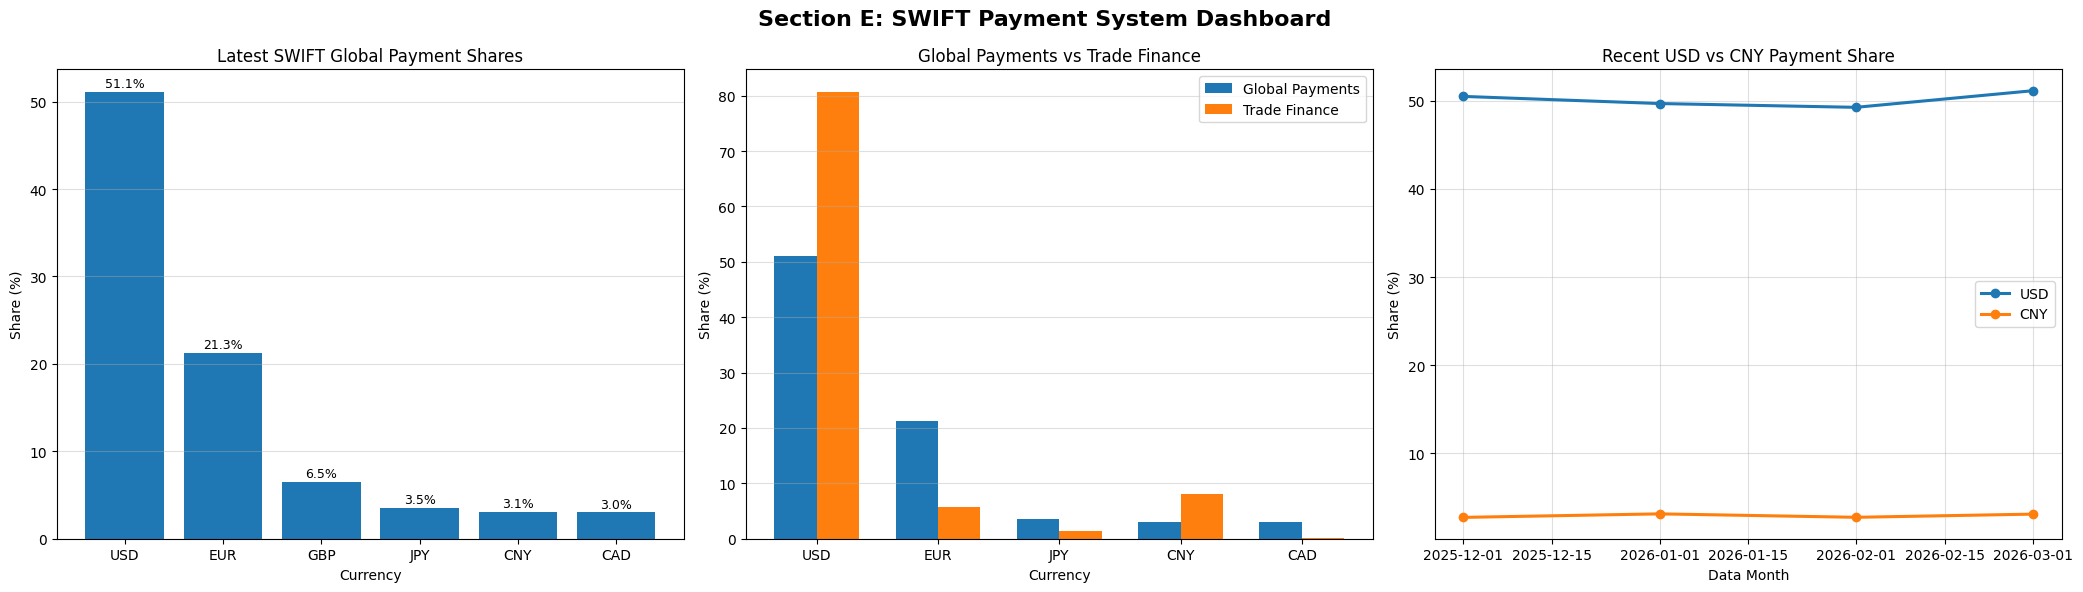

In [121]:
# ============================================================
# Section E: SWIFT Payment System Dashboard
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures/Dashboard", exist_ok=True)

base_path = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset"

swift = pd.read_excel(
    f"{base_path}/swift_currency_tracker_research_ready_MAY_ADDED.xlsx",
    sheet_name="Cleaned_Data"
)

swift["data_month"] = pd.to_datetime(swift["data_month"])
swift["metric"] = swift["metric"].astype(str).str.strip()
swift["currency_or_economy"] = swift["currency_or_economy"].astype(str).str.strip()

major = ["USD", "EUR", "GBP", "JPY", "CAD", "CNY"]

payments = swift[
    (swift["metric"] == "Global Payment Share") &
    (swift["currency_or_economy"].isin(major))
].copy()

payments_latest = (
    payments.sort_values("data_month")
    .groupby("currency_or_economy")
    .tail(1)
    .sort_values("value", ascending=False)
)

trade = swift[
    (swift["metric"] == "Trade Finance Share") &
    (swift["currency_or_economy"].isin(major))
].copy()

trade_latest = (
    trade.sort_values("data_month")
    .groupby("currency_or_economy")
    .tail(1)
)

swift_compare = pd.merge(
    payments_latest[["currency_or_economy", "value"]],
    trade_latest[["currency_or_economy", "value"]],
    on="currency_or_economy",
    suffixes=("_Payments", "_Trade")
)

usd_cny = payments[
    payments["currency_or_economy"].isin(["USD", "CNY"])
].copy()

usd_cny = usd_cny.sort_values("data_month")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Figure E1: Latest payment shares
axes[0].bar(
    payments_latest["currency_or_economy"],
    payments_latest["value"]
)

axes[0].set_title("Latest SWIFT Global Payment Shares")
axes[0].set_xlabel("Currency")
axes[0].set_ylabel("Share (%)")
axes[0].grid(axis="y", alpha=0.4)

for i, value in enumerate(payments_latest["value"]):
    axes[0].text(i, value + 0.5, f"{value:.1f}%", ha="center", fontsize=9)

# Figure E2: Global payments vs trade finance
x = np.arange(len(swift_compare))
width = 0.35

axes[1].bar(
    x - width / 2,
    swift_compare["value_Payments"],
    width,
    label="Global Payments"
)

axes[1].bar(
    x + width / 2,
    swift_compare["value_Trade"],
    width,
    label="Trade Finance"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(swift_compare["currency_or_economy"])
axes[1].set_title("Global Payments vs Trade Finance")
axes[1].set_xlabel("Currency")
axes[1].set_ylabel("Share (%)")
axes[1].grid(axis="y", alpha=0.4)
axes[1].legend()

# Figure E3: USD vs CNY recent movement
for currency in ["USD", "CNY"]:
    temp = usd_cny[usd_cny["currency_or_economy"] == currency]
    axes[2].plot(
        temp["data_month"],
        temp["value"],
        marker="o",
        linewidth=2.2,
        label=currency
    )

axes[2].set_title("Recent USD vs CNY Payment Share")
axes[2].set_xlabel("Data Month")
axes[2].set_ylabel("Share (%)")
axes[2].grid(True, alpha=0.4)
axes[2].legend()

fig.suptitle(
    "Section E: SWIFT Payment System Dashboard",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "figures/Dashboard/Dashboard_Section_E_SWIFT_Payment_System.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_23/2480958537.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  swift["data_month"] = pd.to_datetime(swift["data_month"])
[*********************100%***********************]  1 of 1 completed


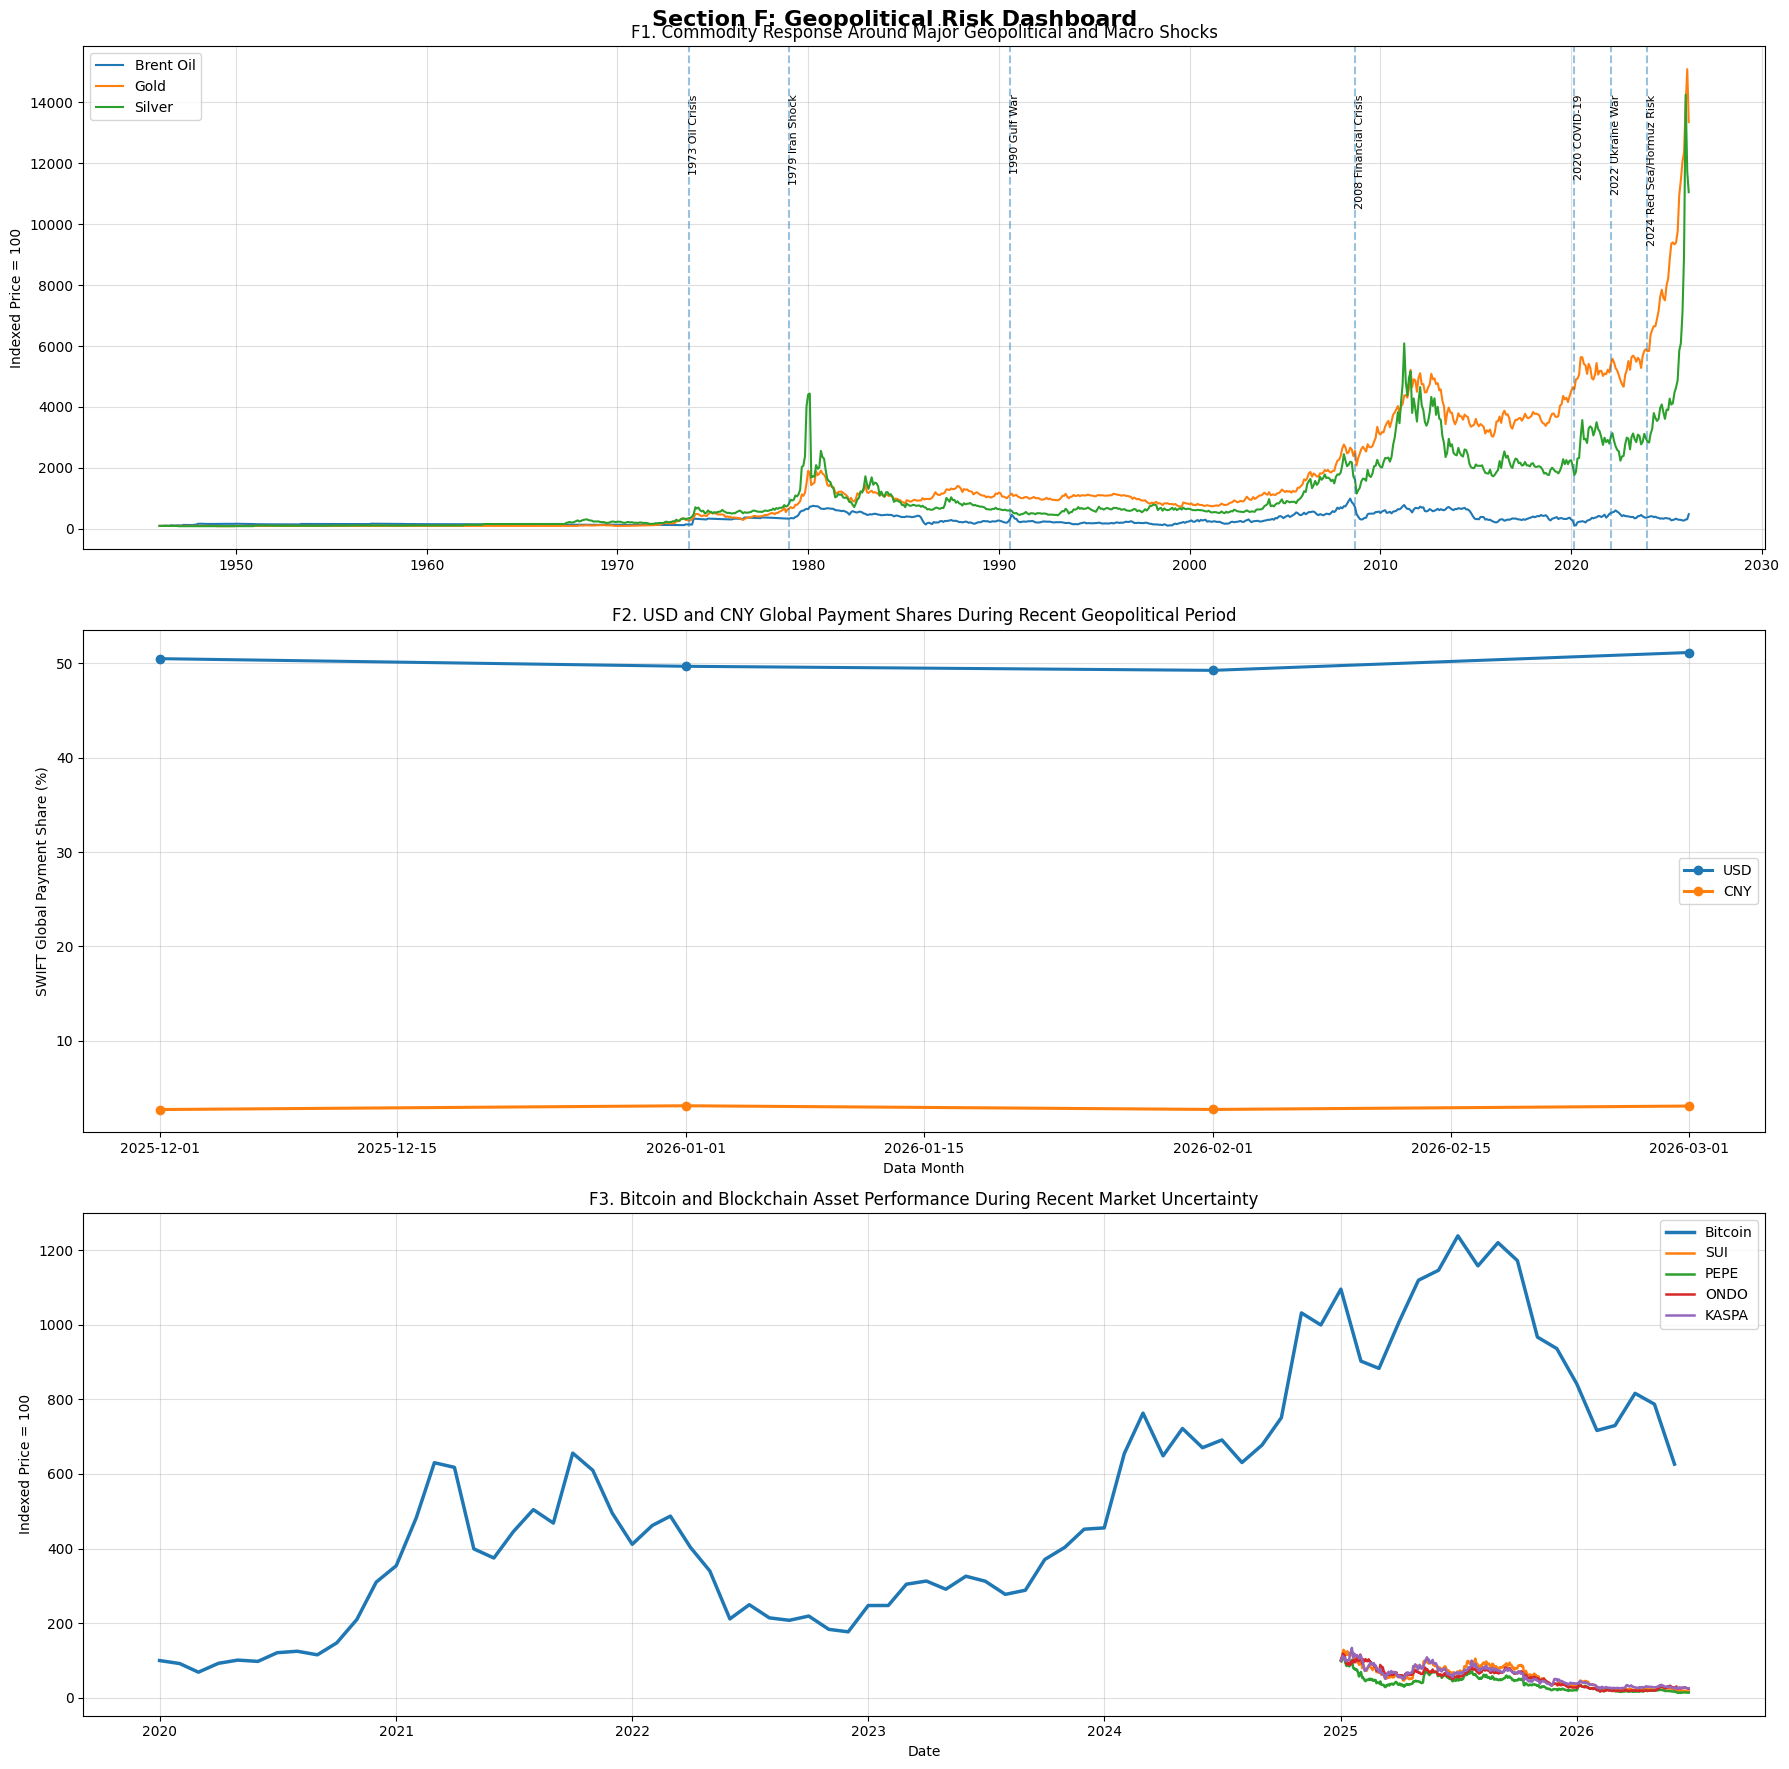

In [122]:
# ============================================================
# Section F: Geopolitical Risk Dashboard
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures/Dashboard", exist_ok=True)

base_path = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset"
crypto_path = "/kaggle/input/datasets/maryammoghaddasbayat/set2-crypto/Crypto_Market_Dataset_2025_2026-2.xlsx"

# ------------------------------------------------------------
# Load commodities
# ------------------------------------------------------------

oil = pd.read_csv(f"{base_path}/Brent Oil.csv")
gold = pd.read_csv(f"{base_path}/Gold 100years.csv")
silver = pd.read_csv(f"{base_path}/silver 100 years.csv")

for df in [oil, gold, silver]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)

commodity = pd.merge(
    oil[["Date", "Value"]].rename(columns={"Value": "Oil"}),
    gold[["Date", "Value"]].rename(columns={"Value": "Gold"}),
    on="Date",
    how="inner"
)

commodity = pd.merge(
    commodity,
    silver[["Date", "Value"]].rename(columns={"Value": "Silver"}),
    on="Date",
    how="inner"
)

for col in ["Oil", "Gold", "Silver"]:
    commodity[col + "_Index"] = commodity[col] / commodity[col].iloc[0] * 100

# ------------------------------------------------------------
# Load SWIFT
# ------------------------------------------------------------

swift = pd.read_excel(
    f"{base_path}/swift_currency_tracker_research_ready_MAY_ADDED.xlsx",
    sheet_name="Cleaned_Data"
)

swift["data_month"] = pd.to_datetime(swift["data_month"])
swift["metric"] = swift["metric"].astype(str).str.strip()
swift["currency_or_economy"] = swift["currency_or_economy"].astype(str).str.strip()

swift_usd_cny = swift[
    (swift["metric"] == "Global Payment Share") &
    (swift["currency_or_economy"].isin(["USD", "CNY"]))
].copy()

swift_usd_cny = swift_usd_cny.sort_values("data_month")

# ------------------------------------------------------------
# Bitcoin
# ------------------------------------------------------------

!pip install yfinance -q
import yfinance as yf

btc = yf.download(
    "BTC-USD",
    start="2020-01-01",
    end="2026-06-30",
    interval="1mo",
    auto_adjust=True
)

btc.reset_index(inplace=True)
btc.columns = [col[0] if isinstance(col, tuple) else col for col in btc.columns]
btc["Date"] = pd.to_datetime(btc["Date"])
btc = btc.sort_values("Date")
btc["BTC_Index"] = btc["Close"] / btc["Close"].iloc[0] * 100

# ------------------------------------------------------------
# Blockchain
# ------------------------------------------------------------

sheet_map = {
    "SUI": "sui-usd-max",
    "PEPE": "pepe-usd-max",
    "ONDO": "ondo-usd-max",
    "KASPA": "KAS-usd-max"
}

crypto_data = {}

for asset, sheet in sheet_map.items():
    temp = pd.read_excel(crypto_path, sheet_name=sheet)
    temp["Date"] = pd.to_datetime(temp["Clean_Date"])

    if asset == "SUI":
        temp = temp.rename(columns={"Price_USD": "Price"})
    else:
        temp = temp.rename(columns={"price": "Price"})

    temp = temp[["Date", "Price"]].dropna().sort_values("Date")
    temp["Indexed_Price"] = temp["Price"] / temp["Price"].iloc[0] * 100
    crypto_data[asset] = temp

# ------------------------------------------------------------
# Build dashboard
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(18, 18))

# F1: Commodities and global shocks
axes[0].plot(commodity["Date"], commodity["Oil_Index"], label="Brent Oil")
axes[0].plot(commodity["Date"], commodity["Gold_Index"], label="Gold")
axes[0].plot(commodity["Date"], commodity["Silver_Index"], label="Silver")

events = {
    "1973 Oil Crisis": "1973-10-01",
    "1979 Iran Shock": "1979-01-01",
    "1990 Gulf War": "1990-08-01",
    "2008 Financial Crisis": "2008-09-01",
    "2020 COVID-19": "2020-03-01",
    "2022 Ukraine War": "2022-02-01",
    "2024 Red Sea/Hormuz Risk": "2024-01-01"
}

for label, date in events.items():
    date = pd.to_datetime(date)
    axes[0].axvline(date, linestyle="--", alpha=0.45)
    axes[0].text(
        date,
        axes[0].get_ylim()[1] * 0.90,
        label,
        rotation=90,
        fontsize=8,
        verticalalignment="top"
    )

axes[0].set_title("F1. Commodity Response Around Major Geopolitical and Macro Shocks")
axes[0].set_ylabel("Indexed Price = 100")
axes[0].grid(True, alpha=0.4)
axes[0].legend(loc="upper left")

# F2: USD and CNY during recent payment-system period
for currency in ["USD", "CNY"]:
    temp = swift_usd_cny[swift_usd_cny["currency_or_economy"] == currency]
    axes[1].plot(
        temp["data_month"],
        temp["value"],
        marker="o",
        linewidth=2.2,
        label=currency
    )

axes[1].set_title("F2. USD and CNY Global Payment Shares During Recent Geopolitical Period")
axes[1].set_xlabel("Data Month")
axes[1].set_ylabel("SWIFT Global Payment Share (%)")
axes[1].grid(True, alpha=0.4)
axes[1].legend()

# F3: Bitcoin and blockchain indexed performance
axes[2].plot(
    btc["Date"],
    btc["BTC_Index"],
    linewidth=2.5,
    label="Bitcoin"
)

for asset, data in crypto_data.items():
    axes[2].plot(
        data["Date"],
        data["Indexed_Price"],
        linewidth=1.8,
        label=asset
    )

axes[2].set_title("F3. Bitcoin and Blockchain Asset Performance During Recent Market Uncertainty")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Indexed Price = 100")
axes[2].grid(True, alpha=0.4)
axes[2].legend()

fig.suptitle(
    "Section F: Geopolitical Risk Dashboard",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "figures/Dashboard/Dashboard_Section_F_Geopolitical_Risk.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_23/3146921523.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  swift["data_month"] = pd.to_datetime(swift["data_month"])
[*********************100%***********************]  1 of 1 completed


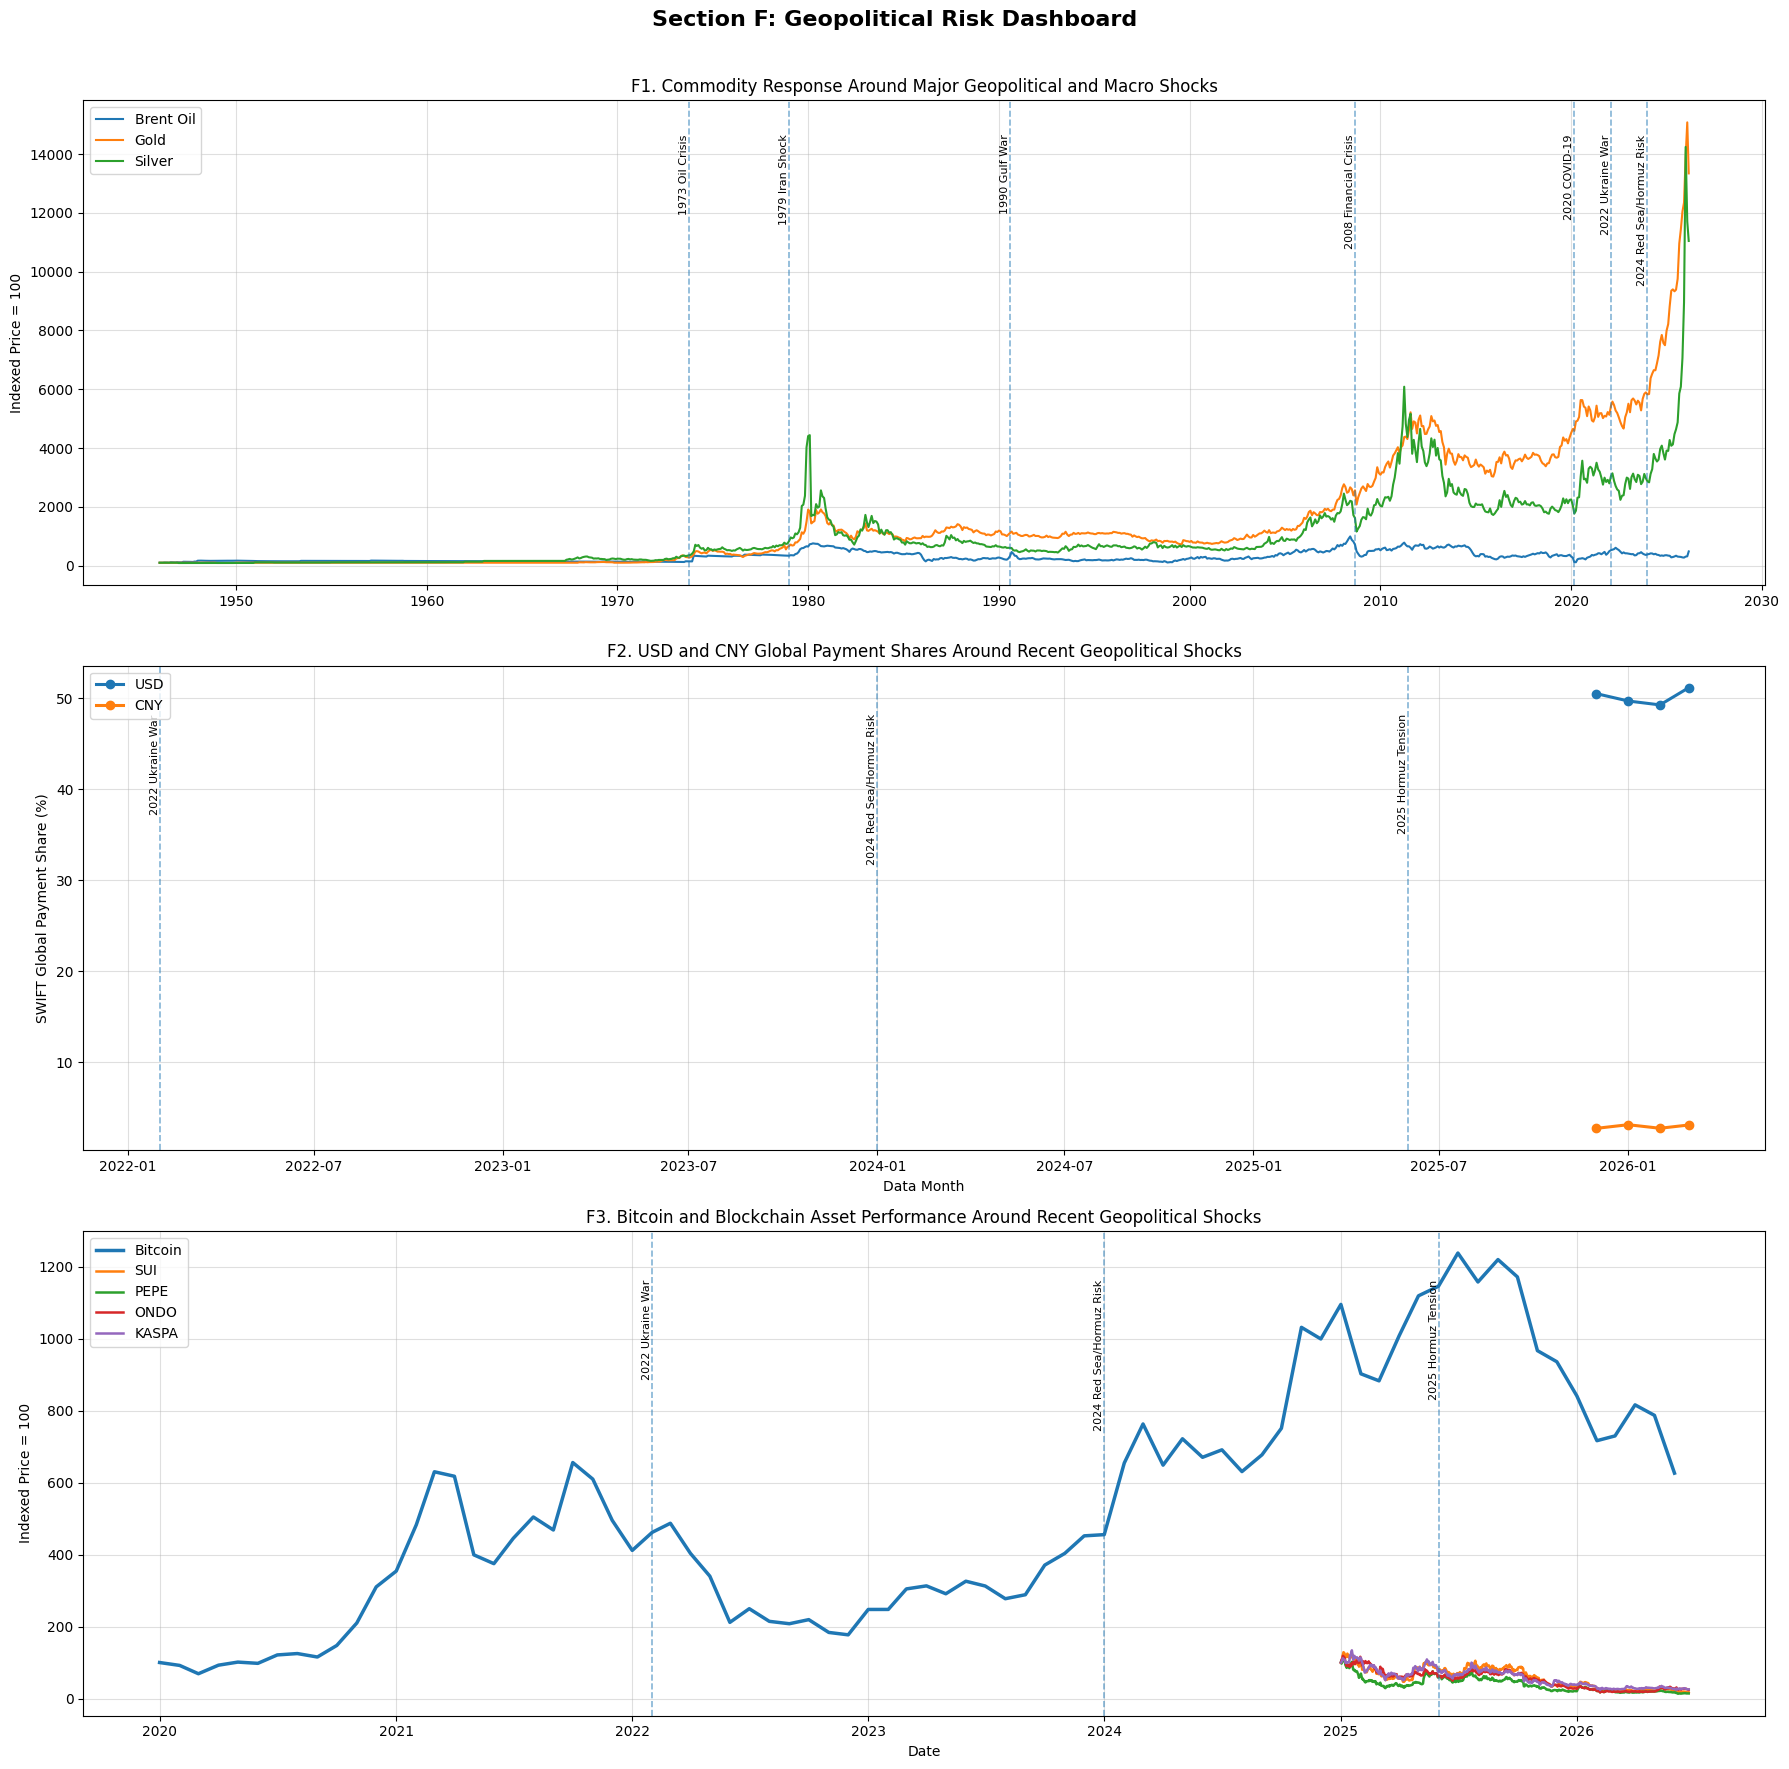

In [123]:
# ============================================================
# Section F: Geopolitical Risk Dashboard
# With shock-marker lines in commodities, SWIFT, and crypto
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures/Dashboard", exist_ok=True)

base_path = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset"
crypto_path = "/kaggle/input/datasets/maryammoghaddasbayat/set2-crypto/Crypto_Market_Dataset_2025_2026-2.xlsx"

# ------------------------------------------------------------
# 1. Load commodity data
# ------------------------------------------------------------

oil = pd.read_csv(f"{base_path}/Brent Oil.csv")
gold = pd.read_csv(f"{base_path}/Gold 100years.csv")
silver = pd.read_csv(f"{base_path}/silver 100 years.csv")

for df in [oil, gold, silver]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)

commodity = pd.merge(
    oil[["Date", "Value"]].rename(columns={"Value": "Oil"}),
    gold[["Date", "Value"]].rename(columns={"Value": "Gold"}),
    on="Date",
    how="inner"
)

commodity = pd.merge(
    commodity,
    silver[["Date", "Value"]].rename(columns={"Value": "Silver"}),
    on="Date",
    how="inner"
)

for col in ["Oil", "Gold", "Silver"]:
    commodity[col + "_Index"] = commodity[col] / commodity[col].iloc[0] * 100

# ------------------------------------------------------------
# 2. Load SWIFT data
# ------------------------------------------------------------

swift = pd.read_excel(
    f"{base_path}/swift_currency_tracker_research_ready_MAY_ADDED.xlsx",
    sheet_name="Cleaned_Data"
)

swift["data_month"] = pd.to_datetime(swift["data_month"])
swift["metric"] = swift["metric"].astype(str).str.strip()
swift["currency_or_economy"] = swift["currency_or_economy"].astype(str).str.strip()

swift_usd_cny = swift[
    (swift["metric"] == "Global Payment Share") &
    (swift["currency_or_economy"].isin(["USD", "CNY"]))
].copy()

swift_usd_cny = swift_usd_cny.sort_values("data_month")

# ------------------------------------------------------------
# 3. Bitcoin data
# ------------------------------------------------------------

!pip install yfinance -q
import yfinance as yf

btc = yf.download(
    "BTC-USD",
    start="2020-01-01",
    end="2026-06-30",
    interval="1mo",
    auto_adjust=True
)

btc.reset_index(inplace=True)
btc.columns = [col[0] if isinstance(col, tuple) else col for col in btc.columns]
btc["Date"] = pd.to_datetime(btc["Date"])
btc = btc.sort_values("Date")
btc["BTC_Index"] = btc["Close"] / btc["Close"].iloc[0] * 100

# ------------------------------------------------------------
# 4. Blockchain data
# ------------------------------------------------------------

sheet_map = {
    "SUI": "sui-usd-max",
    "PEPE": "pepe-usd-max",
    "ONDO": "ondo-usd-max",
    "KASPA": "KAS-usd-max"
}

crypto_data = {}

for asset, sheet in sheet_map.items():
    temp = pd.read_excel(crypto_path, sheet_name=sheet)
    temp["Date"] = pd.to_datetime(temp["Clean_Date"])

    if asset == "SUI":
        temp = temp.rename(columns={"Price_USD": "Price"})
    else:
        temp = temp.rename(columns={"price": "Price"})

    temp = temp[["Date", "Price"]].dropna().sort_values("Date")
    temp["Indexed_Price"] = temp["Price"] / temp["Price"].iloc[0] * 100
    crypto_data[asset] = temp

# ------------------------------------------------------------
# 5. Event dictionaries
# ------------------------------------------------------------

long_events = {
    "1973 Oil Crisis": "1973-10-01",
    "1979 Iran Shock": "1979-01-01",
    "1990 Gulf War": "1990-08-01",
    "2008 Financial Crisis": "2008-09-01",
    "2020 COVID-19": "2020-03-01",
    "2022 Ukraine War": "2022-02-01",
    "2024 Red Sea/Hormuz Risk": "2024-01-01"
}

recent_events = {
    "2022 Ukraine War": "2022-02-01",
    "2024 Red Sea/Hormuz Risk": "2024-01-01",
    "2025 Hormuz Tension": "2025-06-01"
}

# ------------------------------------------------------------
# 6. Helper function for event lines
# ------------------------------------------------------------

def add_event_lines(ax, events, label_y=0.90, fontsize=8):
    y_min, y_max = ax.get_ylim()
    y_pos = y_min + (y_max - y_min) * label_y

    for label, date in events.items():
        date = pd.to_datetime(date)
        ax.axvline(date, linestyle="--", linewidth=1.2, alpha=0.55)
        ax.text(
            date,
            y_pos,
            label,
            rotation=90,
            fontsize=fontsize,
            verticalalignment="top",
            horizontalalignment="right"
        )

# ------------------------------------------------------------
# 7. Build dashboard
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(18, 18))

# ------------------------------------------------------------
# F1: Commodity shocks
# ------------------------------------------------------------

axes[0].plot(commodity["Date"], commodity["Oil_Index"], label="Brent Oil")
axes[0].plot(commodity["Date"], commodity["Gold_Index"], label="Gold")
axes[0].plot(commodity["Date"], commodity["Silver_Index"], label="Silver")

axes[0].set_title("F1. Commodity Response Around Major Geopolitical and Macro Shocks")
axes[0].set_ylabel("Indexed Price = 100")
axes[0].grid(True, alpha=0.4)
axes[0].legend(loc="upper left")

add_event_lines(axes[0], long_events, label_y=0.93, fontsize=8)

# ------------------------------------------------------------
# F2: SWIFT USD/CNY with recent shocks
# ------------------------------------------------------------

for currency in ["USD", "CNY"]:
    temp = swift_usd_cny[swift_usd_cny["currency_or_economy"] == currency]
    axes[1].plot(
        temp["data_month"],
        temp["value"],
        marker="o",
        linewidth=2.2,
        label=currency
    )

axes[1].set_title("F2. USD and CNY Global Payment Shares Around Recent Geopolitical Shocks")
axes[1].set_xlabel("Data Month")
axes[1].set_ylabel("SWIFT Global Payment Share (%)")
axes[1].grid(True, alpha=0.4)
axes[1].legend(loc="upper left")

add_event_lines(axes[1], recent_events, label_y=0.90, fontsize=8)

# ------------------------------------------------------------
# F3: Bitcoin and blockchain with recent shocks
# ------------------------------------------------------------

axes[2].plot(
    btc["Date"],
    btc["BTC_Index"],
    linewidth=2.5,
    label="Bitcoin"
)

for asset, data in crypto_data.items():
    axes[2].plot(
        data["Date"],
        data["Indexed_Price"],
        linewidth=1.8,
        label=asset
    )

axes[2].set_title("F3. Bitcoin and Blockchain Asset Performance Around Recent Geopolitical Shocks")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Indexed Price = 100")
axes[2].grid(True, alpha=0.4)
axes[2].legend(loc="upper left")

add_event_lines(axes[2], recent_events, label_y=0.90, fontsize=8)

# ------------------------------------------------------------
# Main title and save
# ------------------------------------------------------------

fig.suptitle(
    "Section F: Geopolitical Risk Dashboard",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    "figures/Dashboard/Dashboard_Section_F_Geopolitical_Risk_With_Timeline.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_23/486148972.py:56: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  swift["data_month"] = pd.to_datetime(swift["data_month"])
[*********************100%***********************]  1 of 1 completed


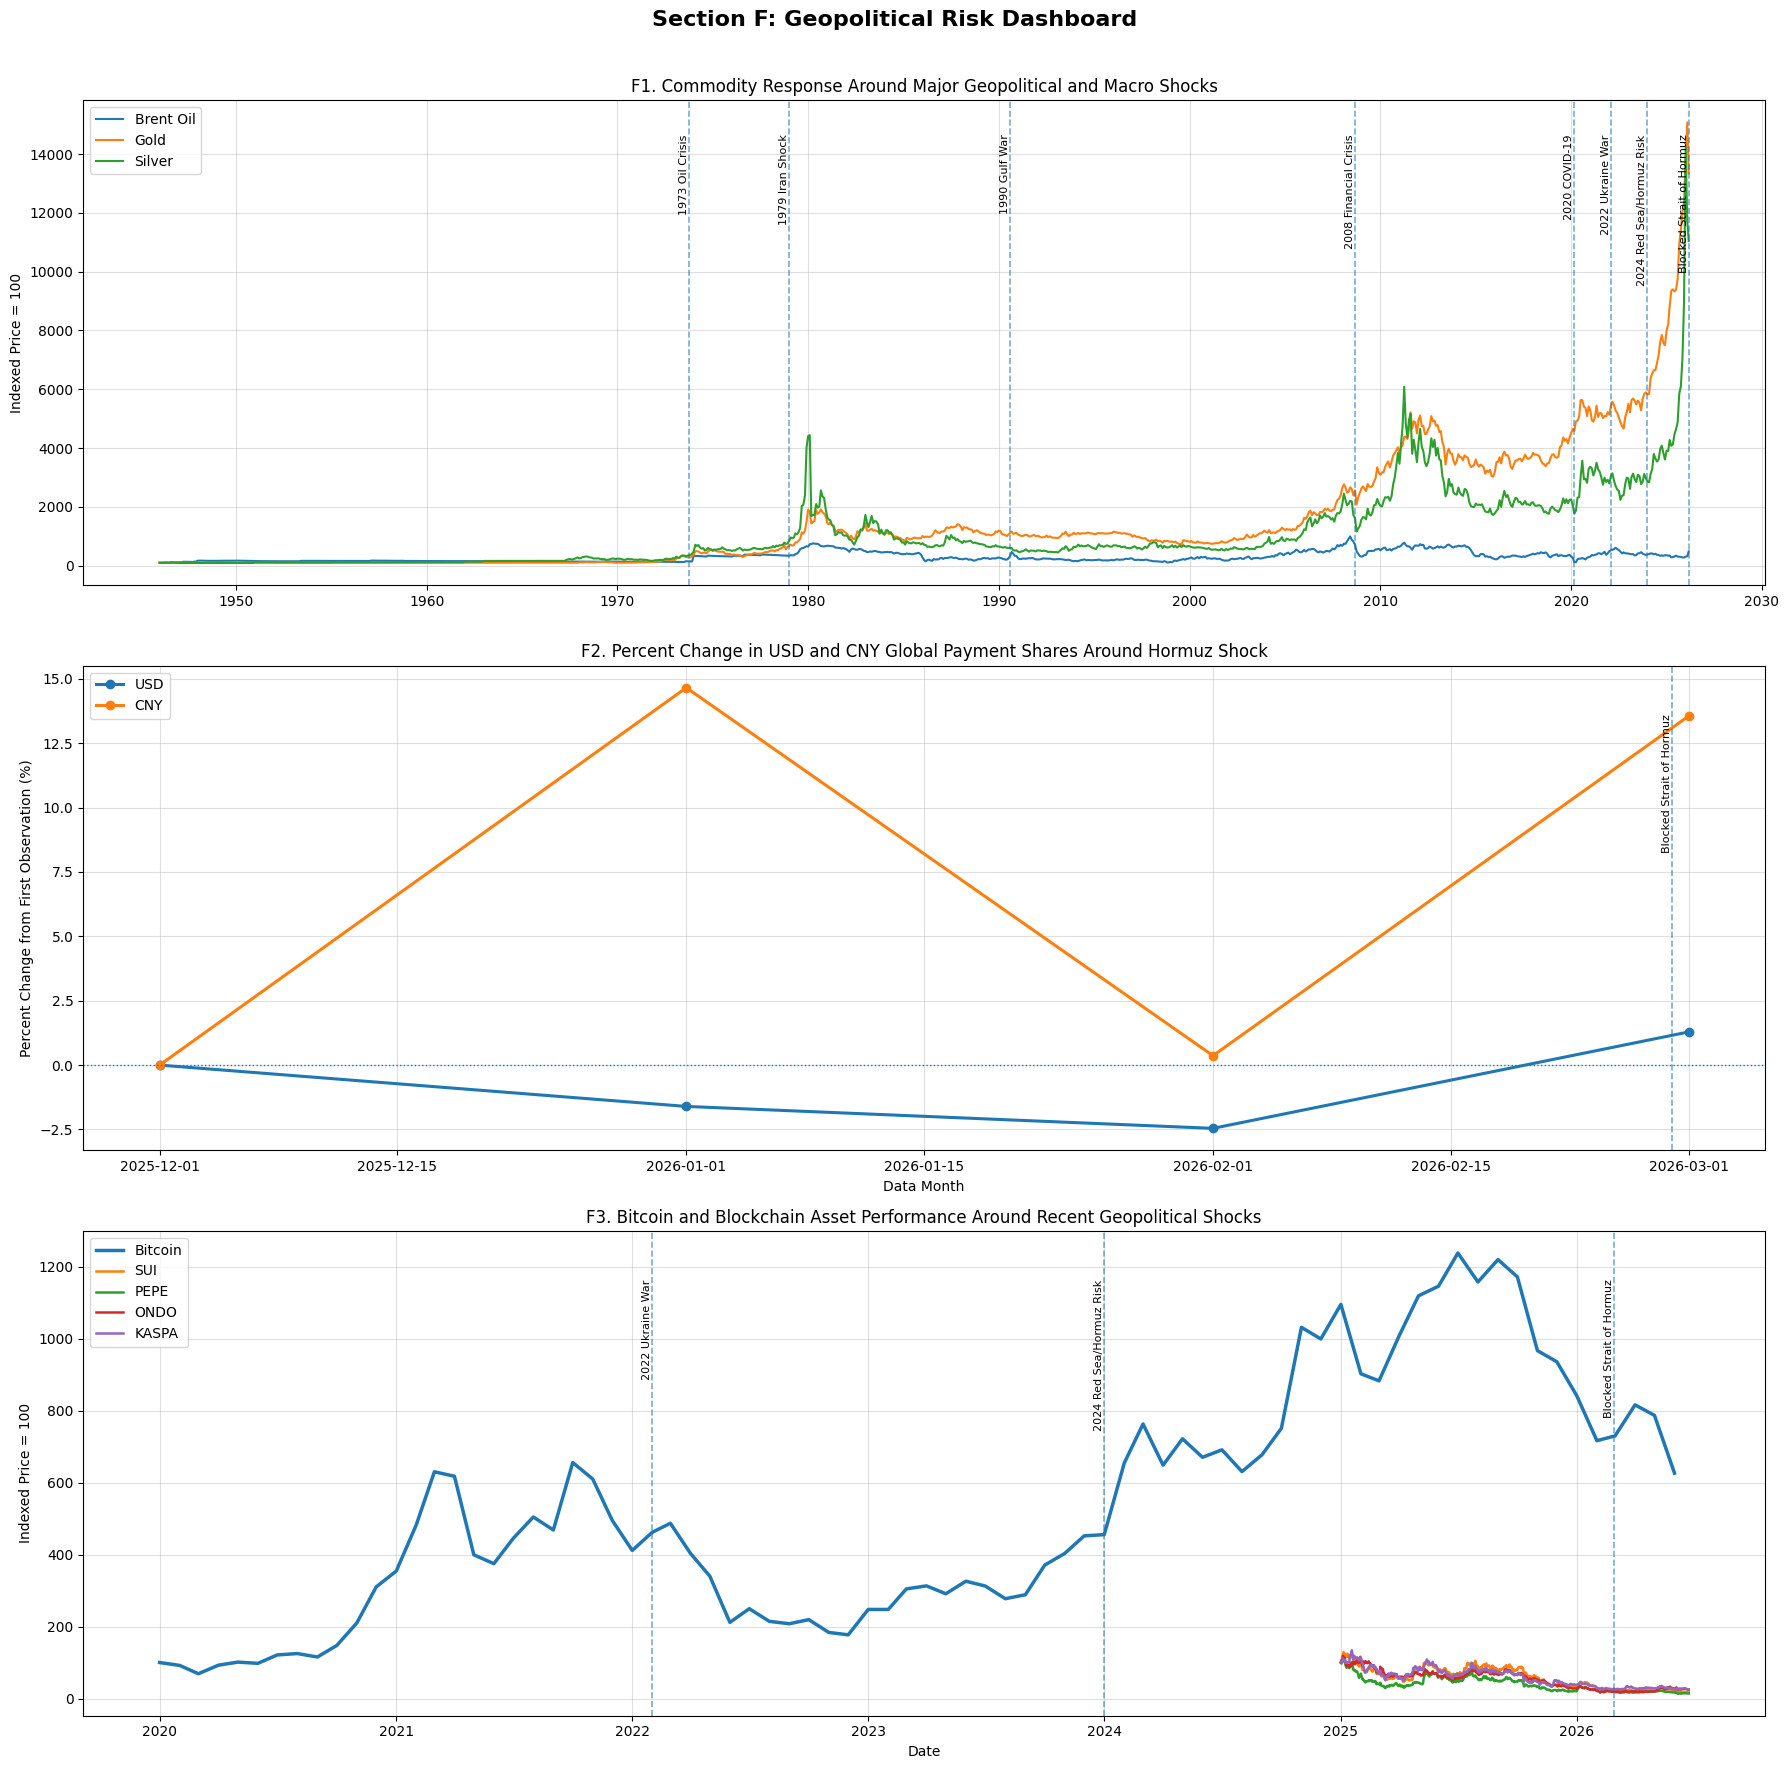

In [124]:
# ============================================================
# Section F: Geopolitical Risk Dashboard
# Updated:
# 1. Adds 28 Feb 2026 as "Blocked Strait of Hormuz"
# 2. Replaces raw USD/CNY shares with percent-change chart
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures/Dashboard", exist_ok=True)

base_path = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset"
crypto_path = "/kaggle/input/datasets/maryammoghaddasbayat/set2-crypto/Crypto_Market_Dataset_2025_2026-2.xlsx"

# ------------------------------------------------------------
# 1. Load commodity data
# ------------------------------------------------------------

oil = pd.read_csv(f"{base_path}/Brent Oil.csv")
gold = pd.read_csv(f"{base_path}/Gold 100years.csv")
silver = pd.read_csv(f"{base_path}/silver 100 years.csv")

for df in [oil, gold, silver]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)

commodity = pd.merge(
    oil[["Date", "Value"]].rename(columns={"Value": "Oil"}),
    gold[["Date", "Value"]].rename(columns={"Value": "Gold"}),
    on="Date",
    how="inner"
)

commodity = pd.merge(
    commodity,
    silver[["Date", "Value"]].rename(columns={"Value": "Silver"}),
    on="Date",
    how="inner"
)

for col in ["Oil", "Gold", "Silver"]:
    commodity[col + "_Index"] = commodity[col] / commodity[col].iloc[0] * 100

# ------------------------------------------------------------
# 2. Load SWIFT data
# ------------------------------------------------------------

swift = pd.read_excel(
    f"{base_path}/swift_currency_tracker_research_ready_MAY_ADDED.xlsx",
    sheet_name="Cleaned_Data"
)

swift["data_month"] = pd.to_datetime(swift["data_month"])
swift["metric"] = swift["metric"].astype(str).str.strip()
swift["currency_or_economy"] = swift["currency_or_economy"].astype(str).str.strip()

swift_usd_cny = swift[
    (swift["metric"] == "Global Payment Share") &
    (swift["currency_or_economy"].isin(["USD", "CNY"]))
].copy()

swift_usd_cny = swift_usd_cny.sort_values("data_month")

# Calculate percent change from first available observation
swift_usd_cny["Pct_Change"] = (
    swift_usd_cny
    .groupby("currency_or_economy")["value"]
    .transform(lambda x: (x / x.iloc[0] - 1) * 100)
)

# ------------------------------------------------------------
# 3. Bitcoin data
# ------------------------------------------------------------

!pip install yfinance -q
import yfinance as yf

btc = yf.download(
    "BTC-USD",
    start="2020-01-01",
    end="2026-06-30",
    interval="1mo",
    auto_adjust=True
)

btc.reset_index(inplace=True)
btc.columns = [col[0] if isinstance(col, tuple) else col for col in btc.columns]
btc["Date"] = pd.to_datetime(btc["Date"])
btc = btc.sort_values("Date")
btc["BTC_Index"] = btc["Close"] / btc["Close"].iloc[0] * 100

# ------------------------------------------------------------
# 4. Blockchain data
# ------------------------------------------------------------

sheet_map = {
    "SUI": "sui-usd-max",
    "PEPE": "pepe-usd-max",
    "ONDO": "ondo-usd-max",
    "KASPA": "KAS-usd-max"
}

crypto_data = {}

for asset, sheet in sheet_map.items():
    temp = pd.read_excel(crypto_path, sheet_name=sheet)
    temp["Date"] = pd.to_datetime(temp["Clean_Date"])

    if asset == "SUI":
        temp = temp.rename(columns={"Price_USD": "Price"})
    else:
        temp = temp.rename(columns={"price": "Price"})

    temp = temp[["Date", "Price"]].dropna().sort_values("Date")
    temp["Indexed_Price"] = temp["Price"] / temp["Price"].iloc[0] * 100
    crypto_data[asset] = temp

# ------------------------------------------------------------
# 5. Event dictionaries
# ------------------------------------------------------------

long_events = {
    "1973 Oil Crisis": "1973-10-01",
    "1979 Iran Shock": "1979-01-01",
    "1990 Gulf War": "1990-08-01",
    "2008 Financial Crisis": "2008-09-01",
    "2020 COVID-19": "2020-03-01",
    "2022 Ukraine War": "2022-02-01",
    "2024 Red Sea/Hormuz Risk": "2024-01-01",
    "Blocked Strait of Hormuz": "2026-02-28"
}

# For SWIFT, only use Feb 2026 shock because dataset starts recently
swift_event = {
    "Blocked Strait of Hormuz": "2026-02-28"
}

recent_events = {
    "2022 Ukraine War": "2022-02-01",
    "2024 Red Sea/Hormuz Risk": "2024-01-01",
    "Blocked Strait of Hormuz": "2026-02-28"
}

# ------------------------------------------------------------
# 6. Helper function for vertical event lines
# ------------------------------------------------------------

def add_event_lines(ax, events, label_y=0.90, fontsize=8):
    y_min, y_max = ax.get_ylim()
    y_pos = y_min + (y_max - y_min) * label_y

    for label, date in events.items():
        date = pd.to_datetime(date)
        ax.axvline(date, linestyle="--", linewidth=1.2, alpha=0.6)
        ax.text(
            date,
            y_pos,
            label,
            rotation=90,
            fontsize=fontsize,
            verticalalignment="top",
            horizontalalignment="right"
        )

# ------------------------------------------------------------
# 7. Build dashboard
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(18, 18))

# ------------------------------------------------------------
# F1: Commodity shocks
# ------------------------------------------------------------

axes[0].plot(commodity["Date"], commodity["Oil_Index"], label="Brent Oil")
axes[0].plot(commodity["Date"], commodity["Gold_Index"], label="Gold")
axes[0].plot(commodity["Date"], commodity["Silver_Index"], label="Silver")

axes[0].set_title("F1. Commodity Response Around Major Geopolitical and Macro Shocks")
axes[0].set_ylabel("Indexed Price = 100")
axes[0].grid(True, alpha=0.4)
axes[0].legend(loc="upper left")

add_event_lines(axes[0], long_events, label_y=0.93, fontsize=8)

# ------------------------------------------------------------
# F2: USD/CNY percent change with Feb 2026 shock only
# ------------------------------------------------------------

for currency in ["USD", "CNY"]:
    temp = swift_usd_cny[swift_usd_cny["currency_or_economy"] == currency]
    axes[1].plot(
        temp["data_month"],
        temp["Pct_Change"],
        marker="o",
        linewidth=2.2,
        label=currency
    )

axes[1].axhline(0, linestyle=":", linewidth=1)
axes[1].set_title("F2. Percent Change in USD and CNY Global Payment Shares Around Hormuz Shock")
axes[1].set_xlabel("Data Month")
axes[1].set_ylabel("Percent Change from First Observation (%)")
axes[1].grid(True, alpha=0.4)
axes[1].legend(loc="upper left")

add_event_lines(axes[1], swift_event, label_y=0.90, fontsize=8)

# ------------------------------------------------------------
# F3: Bitcoin and blockchain with recent shocks
# ------------------------------------------------------------

axes[2].plot(
    btc["Date"],
    btc["BTC_Index"],
    linewidth=2.5,
    label="Bitcoin"
)

for asset, data in crypto_data.items():
    axes[2].plot(
        data["Date"],
        data["Indexed_Price"],
        linewidth=1.8,
        label=asset
    )

axes[2].set_title("F3. Bitcoin and Blockchain Asset Performance Around Recent Geopolitical Shocks")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Indexed Price = 100")
axes[2].grid(True, alpha=0.4)
axes[2].legend(loc="upper left")

add_event_lines(axes[2], recent_events, label_y=0.90, fontsize=8)

# ------------------------------------------------------------
# Main title and save
# ------------------------------------------------------------

fig.suptitle(
    "Section F: Geopolitical Risk Dashboard",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    "figures/Dashboard/Dashboard_Section_F_Geopolitical_Risk_Updated.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler

In [126]:
commodity_folder = "/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset"

crypto_file = "/kaggle/input/datasets/maryammoghaddasbayat/set2-crypto/Crypto_Market_Dataset_2025_2026-2.xlsx"


oil_file = os.path.join(
    commodity_folder,
    "Brent Oil.csv"
)


gold_file = os.path.join(
    commodity_folder,
    "Gold 100years.csv"
)


silver_file = os.path.join(
    commodity_folder,
    "silver 100 years.csv"
)


bitcoin_file = "/kaggle/input/YOUR_FOLDER/Bitcoin_2020_2026_Monthly.csv"

In [127]:
oil = pd.read_csv(oil_file)

oil.head()

,Date,Value
0,01/01/1946,21.23
1,02/01/1946,21.35
2,03/01/1946,21.11
3,04/01/1946,22.79
4,05/01/1946,22.67


In [128]:
silver = pd.read_csv(silver_file)

silver.head()

,Date,Value
0,01/01/1915,0.51
1,02/01/1915,0.51
2,03/01/1915,0.51
3,04/01/1915,0.51
4,05/01/1915,0.51


In [129]:
gold = pd.read_csv(gold_file)

gold.head()

,Date,Value
0,01/01/1915,19.25
1,02/01/1915,19.25
2,03/01/1915,19.25
3,04/01/1915,19.25
4,05/01/1915,19.25


In [130]:
def prepare_asset(df):

    temp = df.copy()

    temp["Date"] = pd.to_datetime(
        temp["Date"]
    )

    temp = temp[["Date", "Value"]]

    temp.columns = [
        "Date",
        "Price"
    ]

    temp = temp.sort_values(
        "Date"
    )

    temp = temp.dropna()

    return temp

In [131]:
print(oil.columns)

Index(['Date', 'Value'], dtype='object')


In [132]:
def prepare_asset(df):

    temp = df.copy()

    # Convert date
    temp["Date"] = pd.to_datetime(
        temp["Date"]
    )

    # Detect price column automatically
    if "Value" in temp.columns:
        price_col = "Value"

    elif "Price" in temp.columns:
        price_col = "Price"

    elif "Close" in temp.columns:
        price_col = "Close"

    else:
        raise ValueError(
            "No price column found. Check dataframe columns."
        )


    temp = temp[
        ["Date", price_col]
    ]


    temp.columns = [
        "Date",
        "Price"
    ]


    temp = temp.sort_values(
        "Date"
    )


    temp = temp.dropna()


    return temp

In [133]:
oil = prepare_asset(oil)

gold = prepare_asset(gold)

silver = prepare_asset(silver)

In [134]:
oil.head()

,Date,Price
0,1946-01-01,21.23
1,1946-02-01,21.35
2,1946-03-01,21.11
3,1946-04-01,22.79
4,1946-05-01,22.67


In [135]:
import numpy as np
import pandas as pd


# 1. Volatility
def calculate_volatility(df):

    returns = df["Price"].pct_change().dropna()

    return returns.std()



# 2. Maximum Drawdown
def calculate_drawdown(df):

    price = df["Price"]

    running_max = price.cummax()

    drawdown = (
        price - running_max
    ) / running_max


    return abs(drawdown.min())



# 3. Trend Instability
def calculate_trend_instability(df):

    price = df["Price"]

    x = np.arange(len(price))


    trend = np.polyfit(
        x,
        price,
        1
    )


    fitted = np.polyval(
        trend,
        x
    )


    error = np.std(
        price - fitted
    )


    return error

In [136]:
def calculate_hormuz_shock(df):

    feb = df[
        (df["Date"].dt.year == 2026) &
        (df["Date"].dt.month == 2)
    ]["Price"]


    march = df[
        (df["Date"].dt.year == 2026) &
        (df["Date"].dt.month == 3)
    ]["Price"]


    if len(feb)==0 or len(march)==0:
        return 0


    shock = (
        march.iloc[0] - feb.iloc[0]
    ) / feb.iloc[0]


    return abs(shock)

In [137]:
commodity_risk = []


for name, data in {
    "Brent Oil": oil,
    "Gold": gold,
    "Silver": silver

}.items():

    commodity_risk.append({

        "Asset": name,


        "Volatility":
        calculate_volatility(data),


        "Drawdown":
        calculate_drawdown(data),


        "Trend":
        calculate_trend_instability(data),


        "Shock":
        calculate_hormuz_shock(data)

    })


commodity_risk = pd.DataFrame(
    commodity_risk
)


commodity_risk

,Asset,Volatility,Drawdown,Trend,Shock
0,Brent Oil,0.090506,0.882723,29.567069,0.520248
1,Gold,0.042956,0.620000,451.133623,0.115111
2,Silver,0.076948,0.899493,7.208519,0.056588


In [138]:
import os

# Create output folder
output_folder = "Risk_Calculation"

os.makedirs(
    output_folder,
    exist_ok=True
)


# Save commodity risk calculation table

commodity_risk.to_csv(
    os.path.join(
        output_folder,
        "Commodity_Risk_Calculation_Table.csv"
    ),
    index=False
)


print("Risk calculation folder created successfully.")
print("Commodity risk table saved.")

Risk calculation folder created successfully.
Commodity risk table saved.


In [139]:
import os
import matplotlib.pyplot as plt

# Create folder
output_folder = "Risk_Calculation"

os.makedirs(
    output_folder,
    exist_ok=True
)


# Save CSV
commodity_risk.to_csv(
    os.path.join(
        output_folder,
        "Commodity_Risk_Calculation_Table.csv"
    ),
    index=False
)


# Create PDF table

fig, ax = plt.subplots(
    figsize=(10,3)
)

ax.axis("off")


table = ax.table(
    cellText=commodity_risk.round(4).values,
    colLabels=commodity_risk.columns,
    loc="center"
)


table.auto_set_font_size(False)

table.set_fontsize(10)

table.scale(
    1.2,
    1.5
)


plt.title(
    "Commodity Risk Calculation Table",
    fontsize=14,
    pad=20
)


plt.savefig(
    os.path.join(
        output_folder,
        "Commodity_Risk_Calculation_Table.pdf"
    ),
    bbox_inches="tight",
    dpi=300
)


plt.close()


print("CSV and PDF risk tables saved successfully.")

CSV and PDF risk tables saved successfully.


In [140]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if "Bitcoin" in file:
            print(os.path.join(root, file))

/kaggle/working/results_part2/tables/Table_A3_Bitcoin_Digital_Asset_Evidence.csv
/kaggle/working/datasets/Bitcoin_2020_2026_Monthly.csv
/kaggle/working/figures/Part_C/Figure_Bitcoin_Moving_Average.pdf
/kaggle/working/tables/Table_A3_Bitcoin_Digital_Asset_Evidence.csv


In [141]:
bitcoin = pd.read_csv(
    "/kaggle/working/datasets/Bitcoin_2020_2026_Monthly.csv"
)

bitcoin.head()

,Date,Close,High,Low,Open,Volume
0,NaN,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,2020-01-01,9350.529296875,9553.1259765625,6914.99609375,7194.89208984375,852872174496
2,2020-02-01,8599.5087890625,10457.626953125,8492.9326171875,9346.357421875,1163376492768
3,2020-03-01,6438.64453125,9167.6953125,4106.98095703125,8599.7587890625,1290442059648
4,2020-04-01,8658.5537109375,9440.650390625,6202.37353515625,6437.3193359375,1156127164831


In [142]:
bitcoin.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [143]:
# Prepare Bitcoin dataset

bitcoin = bitcoin.copy()

bitcoin["Date"] = pd.to_datetime(
    bitcoin["Date"]
)


bitcoin = bitcoin[
    ["Date", "Close"]
]


bitcoin.columns = [
    "Date",
    "Price"
]


bitcoin = bitcoin.sort_values(
    "Date"
)


bitcoin.head()

,Date,Price
1,2020-01-01,9350.529296875
2,2020-02-01,8599.5087890625
3,2020-03-01,6438.64453125
4,2020-04-01,8658.5537109375
5,2020-05-01,9461.05859375


In [144]:
# Convert price to numeric

bitcoin["Price"] = pd.to_numeric(
    bitcoin["Price"],
    errors="coerce"
)


# Remove missing values

bitcoin = bitcoin.dropna()


bitcoin.dtypes

Date     datetime64[ns]
Price           float64
dtype: object

In [145]:
bitcoin_risk = pd.DataFrame([{

    "Asset": "Bitcoin",

    "Volatility":
    calculate_volatility(bitcoin),

    "Drawdown":
    calculate_drawdown(bitcoin),

    "Trend":
    calculate_trend_instability(bitcoin),

    "Shock":
    calculate_hormuz_shock(bitcoin)

}])


bitcoin_risk

,Asset,Volatility,Drawdown,Trend,Shock
0,Bitcoin,0.183924,0.730141,18735.521263,0.018471


In [146]:
import os

os.makedirs(
    "Risk_Calculation",
    exist_ok=True
)


bitcoin_risk.to_csv(
    "Risk_Calculation/Bitcoin_Risk_Calculation_Table.csv",
    index=False
)


print("Bitcoin risk table saved successfully.")

Bitcoin risk table saved successfully.


In [147]:
import os
import matplotlib.pyplot as plt


# Create folder
output_folder = "Risk_Calculation"

os.makedirs(
    output_folder,
    exist_ok=True
)



def save_table_pdf_csv(df, filename):

    # Save CSV
    csv_path = os.path.join(
        output_folder,
        filename + ".csv"
    )

    df.to_csv(
        csv_path,
        index=False
    )


    # Save PDF table

    fig, ax = plt.subplots(
        figsize=(10, max(2, len(df)*0.5))
    )

    ax.axis("off")


    table = ax.table(
        cellText=df.round(4).values,
        colLabels=df.columns,
        loc="center"
    )


    table.auto_set_font_size(False)

    table.set_fontsize(9)

    table.scale(
        1.2,
        1.5
    )


    plt.title(
        filename.replace("_"," "),
        fontsize=14,
        pad=20
    )


    pdf_path = os.path.join(
        output_folder,
        filename + ".pdf"
    )


    plt.savefig(
        pdf_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.close()


    print(filename, "saved successfully")

In [148]:
import os

os.listdir("Risk_Calculation")

['Commodity_Risk_Calculation_Table.pdf',
 'Commodity_Risk_Calculation_Table.csv',
 'Bitcoin_Risk_Calculation_Table.csv']

In [149]:
import matplotlib.pyplot as plt
import os


filename = "Bitcoin_Risk_Calculation_Table"

output_folder = "Risk_Calculation"


fig, ax = plt.subplots(
    figsize=(10,3)
)

ax.axis("off")


table = ax.table(
    cellText=bitcoin_risk.round(4).values,
    colLabels=bitcoin_risk.columns,
    loc="center"
)


table.auto_set_font_size(False)

table.set_fontsize(10)

table.scale(
    1.3,
    1.8
)


plt.title(
    "Bitcoin Risk Calculation Table",
    fontsize=14,
    pad=20
)


plt.savefig(
    os.path.join(
        output_folder,
        filename + ".pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.close()


print("Bitcoin PDF saved successfully")

Bitcoin PDF saved successfully


In [150]:
crypto_file = "/kaggle/input/datasets/maryammoghaddasbayat/set2-crypto/Crypto_Market_Dataset_2025_2026-2.xlsx"

crypto_excel = pd.ExcelFile(
    crypto_file
)

crypto_excel.sheet_names

['sui-usd-max', 'pepe-usd-max', 'ondo-usd-max', 'KAS-usd-max']

In [151]:
def prepare_crypto(sheet_name):

    df = pd.read_excel(
        crypto_file,
        sheet_name=sheet_name
    )


    df["Clean_Date"] = pd.to_datetime(
        df["Clean_Date"]
    )


    df = df[
        [
            "Clean_Date",
            "Price_USD"
        ]
    ]


    df.columns = [
        "Date",
        "Price"
    ]


    df["Price"] = pd.to_numeric(
        df["Price"],
        errors="coerce"
    )


    df = df.dropna()


    df = df.sort_values(
        "Date"
    )


    return df

In [152]:
# Check all blockchain sheet columns

for sheet in crypto_excel.sheet_names:
    df = pd.read_excel(
        crypto_file,
        sheet_name=sheet
    )
    
    print("\nSheet:", sheet)
    print(df.columns.tolist())


Sheet: sui-usd-max
['snapped_at', 'Clean_Date', 'Year', 'Month', 'Price_USD', 'Market_Cap_USD', 'Volume_USD']

Sheet: pepe-usd-max
['snapped_at', 'Clean_Date', 'Year', 'Month', 'price', 'market_cap', 'total_volume']

Sheet: ondo-usd-max
['snapped_at', 'Clean_Date', 'Year', 'Month', 'price', 'market_cap', 'total_volume']

Sheet: KAS-usd-max
['snapped_at', 'Clean_Date', 'Year', 'Month', 'price', 'market_cap', 'total_volume']


In [153]:
def prepare_crypto(sheet_name):

    df = pd.read_excel(
        crypto_file,
        sheet_name=sheet_name
    )


    # Date column
    df["Clean_Date"] = pd.to_datetime(
        df["Clean_Date"]
    )


    # Price column selection
    if "Price_USD" in df.columns:
        price_col = "Price_USD"

    elif "price" in df.columns:
        price_col = "price"

    else:
        raise ValueError(
            f"No price column found in {sheet_name}"
        )


    # Keep required columns

    df = df[
        [
            "Clean_Date",
            price_col
        ]
    ]


    df.columns = [
        "Date",
        "Price"
    ]


    # Convert price to numeric

    df["Price"] = pd.to_numeric(
        df["Price"],
        errors="coerce"
    )


    df = df.dropna()


    df = df.sort_values(
        "Date"
    )


    return df

In [154]:
sui = prepare_crypto(
    "sui-usd-max"
)


ondo = prepare_crypto(
    "ondo-usd-max"
)


pepe = prepare_crypto(
    "pepe-usd-max"
)


kaspa = prepare_crypto(
    "KAS-usd-max"
)

In [155]:
print("SUI")
print(sui.head())


print("\nONDO")
print(ondo.head())


print("\nPEPE")
print(pepe.head())


print("\nKASPA")
print(kaspa.head())

SUI
        Date     Price
0 2025-01-01  4.118603
1 2025-01-02  4.269667
2 2025-01-03  4.351739
3 2025-01-04  4.959401
4 2025-01-05  5.297820

ONDO
        Date     Price
0 2025-01-01  1.349387
1 2025-01-02  1.462056
2 2025-01-03  1.450167
3 2025-01-04  1.597955
4 2025-01-05  1.580091

PEPE
        Date     Price
0 2025-01-01  0.000020
1 2025-01-02  0.000019
2 2025-01-03  0.000020
3 2025-01-04  0.000022
4 2025-01-05  0.000021

KASPA
        Date     Price
0 2025-01-01  0.115116
1 2025-01-02  0.116917
2 2025-01-03  0.122619
3 2025-01-04  0.128709
4 2025-01-05  0.126439


In [156]:
blockchain_risk = []


for name, data in {

    "SUI": sui,
    "ONDO": ondo,
    "PEPE": pepe,
    "KASPA": kaspa

}.items():


    blockchain_risk.append({

        "Asset": name,

        "Volatility":
        calculate_volatility(data),

        "Drawdown":
        calculate_drawdown(data),

        "Trend":
        calculate_trend_instability(data),

        "Shock":
        calculate_hormuz_shock(data)

    })


blockchain_risk = pd.DataFrame(
    blockchain_risk
)


blockchain_risk

,Asset,Volatility,Drawdown,Trend,Shock
0,SUI,0.051749,0.869156,0.668038,0.212719
1,ONDO,0.049813,0.858825,0.153129,0.089766
2,PEPE,0.056812,0.875726,0.000002,0.116047
3,KASPA,0.048540,0.824293,0.013938,0.090452


In [157]:
save_table_pdf_csv(
    blockchain_risk,
    "Blockchain_Risk_Calculation_Table"
)

Blockchain_Risk_Calculation_Table saved successfully


In [158]:
# Combine all risk calculations

combined_risk = pd.concat(
    [
        commodity_risk,
        bitcoin_risk,
        blockchain_risk
    ],
    ignore_index=True
)


combined_risk

,Asset,Volatility,Drawdown,Trend,Shock
0,Brent Oil,0.090506,0.882723,29.567069,0.520248
1,Gold,0.042956,0.620000,451.133623,0.115111
2,Silver,0.076948,0.899493,7.208519,0.056588
3,Bitcoin,0.183924,0.730141,18735.521263,0.018471
4,SUI,0.051749,0.869156,0.668038,0.212719
5,ONDO,0.049813,0.858825,0.153129,0.089766
6,PEPE,0.056812,0.875726,0.000002,0.116047
7,KASPA,0.048540,0.824293,0.013938,0.090452


In [159]:
save_table_pdf_csv(
    combined_risk,
    "04_Combined_Risk_Table"
)

04_Combined_Risk_Table saved successfully


In [160]:
from sklearn.preprocessing import MinMaxScaler


normalized_risk = combined_risk.copy()


features = [
    "Shock",
    "Volatility",
    "Drawdown",
    "Trend"
]


scaler = MinMaxScaler()


normalized_risk[features] = scaler.fit_transform(
    normalized_risk[features]
)


normalized_risk[features] = (
    normalized_risk[features] * 100
)


normalized_risk

,Asset,Volatility,Drawdown,Trend,Shock
0,Brent Oil,33.731493,93.999895,0.157813,100.000000
1,Gold,0.000000,0.000000,2.407905,19.259538
2,Silver,24.113577,100.000000,0.038475,7.596405
3,Bitcoin,100.000000,39.407255,100.000000,0.000000
4,SUI,6.237863,89.145470,0.003566,38.712014
5,ONDO,4.864597,85.449239,0.000817,14.208564
6,PEPE,9.829469,91.496265,0.000000,19.446184
7,KASPA,3.961369,73.094129,0.000074,14.345220


In [161]:
save_table_pdf_csv(
    normalized_risk,
    "05_Normalized_Risk_Table"
)

05_Normalized_Risk_Table saved successfully


In [162]:
combined_risk

,Asset,Volatility,Drawdown,Trend,Shock
0,Brent Oil,0.090506,0.882723,29.567069,0.520248
1,Gold,0.042956,0.620000,451.133623,0.115111
2,Silver,0.076948,0.899493,7.208519,0.056588
3,Bitcoin,0.183924,0.730141,18735.521263,0.018471
4,SUI,0.051749,0.869156,0.668038,0.212719
5,ONDO,0.049813,0.858825,0.153129,0.089766
6,PEPE,0.056812,0.875726,0.000002,0.116047
7,KASPA,0.048540,0.824293,0.013938,0.090452


In [163]:
# Recalculate relative trend instability

def calculate_relative_trend(df):

    price = df["Price"]

    x = np.arange(len(price))


    model = np.polyfit(
        x,
        price,
        1
    )


    fitted = np.polyval(
        model,
        x
    )


    error = np.std(
        price - fitted
    )


    return error / price.mean()

In [164]:
def fix_commodity_column(df):

    df = df.copy()

    if "Value" in df.columns:
        df = df.rename(
            columns={"Value":"Price"}
        )

    return df


oil = fix_commodity_column(oil)

gold = fix_commodity_column(gold)

silver = fix_commodity_column(silver)

In [165]:
oil = fix_commodity_column(oil)
gold = fix_commodity_column(gold)
silver = fix_commodity_column(silver)

In [166]:
print(oil.columns)
print(gold.columns)
print(silver.columns)

Index(['Date', 'Price'], dtype='object')
Index(['Date', 'Price'], dtype='object')
Index(['Date', 'Price'], dtype='object')


In [167]:
all_assets = {

    "Brent Oil": oil,
    "Gold": gold,
    "Silver": silver,
    "Bitcoin": bitcoin,
    "SUI": sui,
    "ONDO": ondo,
    "PEPE": pepe,
    "KASPA": kaspa

}

In [168]:
for name, data in all_assets.items():
    print(name, data.columns.tolist())

Brent Oil ['Date', 'Price']
Gold ['Date', 'Price']
Silver ['Date', 'Price']
Bitcoin ['Date', 'Price']
SUI ['Date', 'Price']
ONDO ['Date', 'Price']
PEPE ['Date', 'Price']
KASPA ['Date', 'Price']


In [169]:
combined_risk = []


for name, data in all_assets.items():

    combined_risk.append({

        "Asset": name,

        "Volatility":
        calculate_volatility(data),

        "Drawdown":
        calculate_drawdown(data),

        "Trend":
        calculate_relative_trend(data),

        "Shock":
        calculate_hormuz_shock(data)

    })


combined_risk = pd.DataFrame(
    combined_risk
)


combined_risk

,Asset,Volatility,Drawdown,Trend,Shock
0,Brent Oil,0.090506,0.882723,0.471493,0.520248
1,Gold,0.042956,0.620000,1.134781,0.115111
2,Silver,0.076948,0.899493,1.122515,0.056588
3,Bitcoin,0.183924,0.730141,0.380522,0.018471
4,SUI,0.051749,0.869156,0.279392,0.212719
5,ONDO,0.049813,0.858825,0.216055,0.089766
6,PEPE,0.056812,0.875726,0.318830,0.116047
7,KASPA,0.048540,0.824293,0.209257,0.090452


In [170]:
save_table_pdf_csv(
    combined_risk,
    "04_Combined_Risk_Table"
)

04_Combined_Risk_Table saved successfully


In [171]:
from sklearn.preprocessing import MinMaxScaler


normalized_risk = combined_risk.copy()


risk_features = [
    "Volatility",
    "Drawdown",
    "Trend",
    "Shock"
]


scaler = MinMaxScaler()


normalized_risk[risk_features] = scaler.fit_transform(
    normalized_risk[risk_features]
)


# Convert to 0-100 scale

normalized_risk[risk_features] = (
    normalized_risk[risk_features] * 100
)


normalized_risk

,Asset,Volatility,Drawdown,Trend,Shock
0,Brent Oil,33.731493,93.999895,28.333815,100.000000
1,Gold,0.000000,0.000000,100.000000,19.259538
2,Silver,24.113577,100.000000,98.674774,7.596405
3,Bitcoin,100.000000,39.407255,18.504648,0.000000
4,SUI,6.237863,89.145470,7.577903,38.712014
5,ONDO,4.864597,85.449239,0.734523,14.208564
6,PEPE,9.829469,91.496265,11.839055,19.446184
7,KASPA,3.961369,73.094129,0.000000,14.345220


In [172]:
save_table_pdf_csv(
    normalized_risk,
    "05_Normalized_Risk_Table"
)

05_Normalized_Risk_Table saved successfully


In [173]:
normalized_risk

,Asset,Volatility,Drawdown,Trend,Shock
0,Brent Oil,33.731493,93.999895,28.333815,100.000000
1,Gold,0.000000,0.000000,100.000000,19.259538
2,Silver,24.113577,100.000000,98.674774,7.596405
3,Bitcoin,100.000000,39.407255,18.504648,0.000000
4,SUI,6.237863,89.145470,7.577903,38.712014
5,ONDO,4.864597,85.449239,0.734523,14.208564
6,PEPE,9.829469,91.496265,11.839055,19.446184
7,KASPA,3.961369,73.094129,0.000000,14.345220


In [174]:
gmri_results = normalized_risk.copy()


# Scenario 1: Hormuz 40%

gmri_results["GMRI_40"] = (
    0.40 * gmri_results["Shock"]
    +
    0.25 * gmri_results["Volatility"]
    +
    0.20 * gmri_results["Drawdown"]
    +
    0.15 * gmri_results["Trend"]
)



# Scenario 2: Hormuz 45%

gmri_results["GMRI_45"] = (
    0.45 * gmri_results["Shock"]
    +
    0.25 * gmri_results["Volatility"]
    +
    0.20 * gmri_results["Drawdown"]
    +
    0.10 * gmri_results["Trend"]
)



# Scenario 3: Hormuz 50%

gmri_results["GMRI_50"] = (
    0.50 * gmri_results["Shock"]
    +
    0.25 * gmri_results["Volatility"]
    +
    0.20 * gmri_results["Drawdown"]
    +
    0.05 * gmri_results["Trend"]
)



gmri_results

,Asset,Volatility,Drawdown,Trend,Shock,GMRI_40,GMRI_45,GMRI_50
0,Brent Oil,33.731493,93.999895,28.333815,100.000000,71.482925,75.066234,78.649543
1,Gold,0.000000,0.000000,100.000000,19.259538,22.703815,18.666792,14.629769
2,Silver,24.113577,100.000000,98.674774,7.596405,43.868172,39.314254,34.760335
3,Bitcoin,100.000000,39.407255,18.504648,0.000000,35.657148,34.731916,33.806683
4,SUI,6.237863,89.145470,7.577903,38.712014,36.010051,37.566756,39.123462
5,ONDO,4.864597,85.449239,0.734523,14.208564,24.099601,24.773303,25.447005
6,PEPE,9.829469,91.496265,11.839055,19.446184,30.310952,30.691308,31.071665
7,KASPA,3.961369,73.094129,0.000000,14.345220,21.347256,22.064517,22.781778


In [175]:
sensitivity_table = gmri_results[
    [
        "Asset",
        "GMRI_40",
        "GMRI_45",
        "GMRI_50"
    ]
]


sensitivity_table

,Asset,GMRI_40,GMRI_45,GMRI_50
0,Brent Oil,71.482925,75.066234,78.649543
1,Gold,22.703815,18.666792,14.629769
2,Silver,43.868172,39.314254,34.760335
3,Bitcoin,35.657148,34.731916,33.806683
4,SUI,36.010051,37.566756,39.123462
5,ONDO,24.099601,24.773303,25.447005
6,PEPE,30.310952,30.691308,31.071665
7,KASPA,21.347256,22.064517,22.781778


In [176]:
save_table_pdf_csv(
    sensitivity_table,
    "06_GMRI_Sensitivity_Analysis"
)

06_GMRI_Sensitivity_Analysis saved successfully


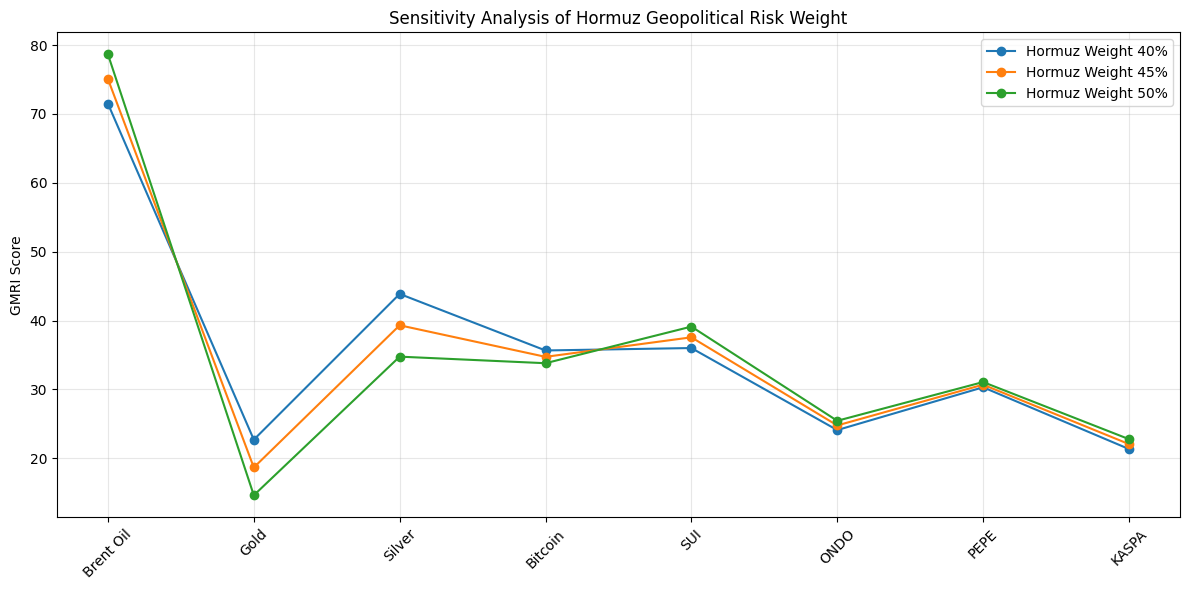

In [177]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,6))


plt.plot(
    sensitivity_table["Asset"],
    sensitivity_table["GMRI_40"],
    marker="o",
    label="Hormuz Weight 40%"
)


plt.plot(
    sensitivity_table["Asset"],
    sensitivity_table["GMRI_45"],
    marker="o",
    label="Hormuz Weight 45%"
)


plt.plot(
    sensitivity_table["Asset"],
    sensitivity_table["GMRI_50"],
    marker="o",
    label="Hormuz Weight 50%"
)



plt.xticks(
    rotation=45
)


plt.ylabel(
    "GMRI Score"
)


plt.title(
    "Sensitivity Analysis of Hormuz Geopolitical Risk Weight"
)


plt.legend()

plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    "Risk_Calculation/GMRI_Sensitivity_Analysis.pdf",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [178]:
sensitivity_table

,Asset,GMRI_40,GMRI_45,GMRI_50
0,Brent Oil,71.482925,75.066234,78.649543
1,Gold,22.703815,18.666792,14.629769
2,Silver,43.868172,39.314254,34.760335
3,Bitcoin,35.657148,34.731916,33.806683
4,SUI,36.010051,37.566756,39.123462
5,ONDO,24.099601,24.773303,25.447005
6,PEPE,30.310952,30.691308,31.071665
7,KASPA,21.347256,22.064517,22.781778


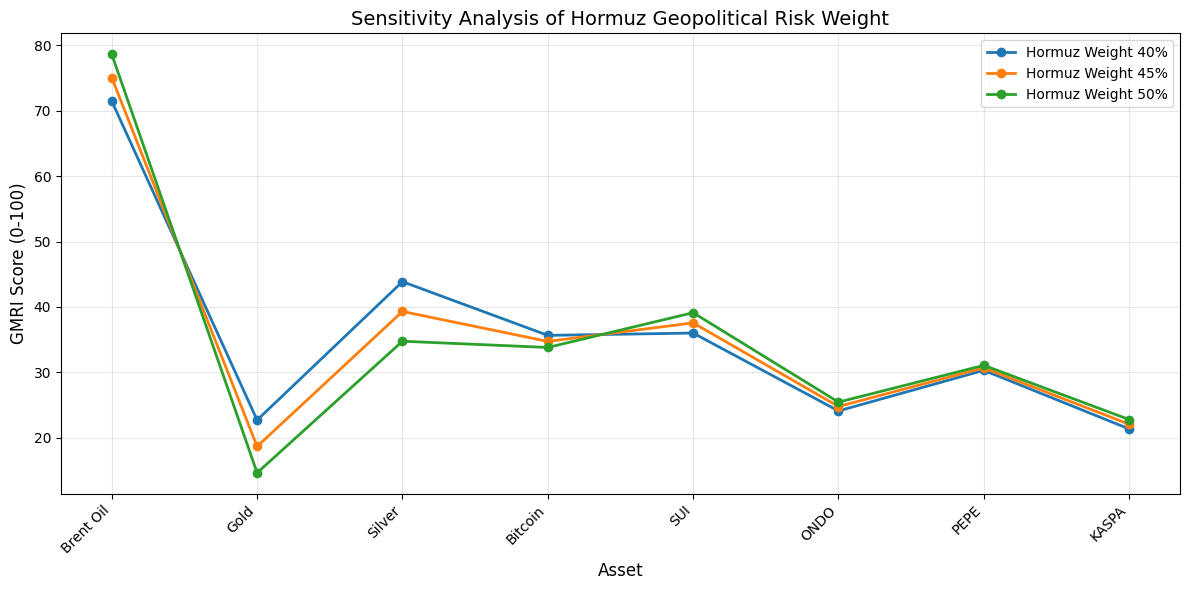

Figure 6.4 saved successfully.


In [179]:
import matplotlib.pyplot as plt
import os


# Make sure folder exists
output_folder = "Risk_Calculation"

os.makedirs(
    output_folder,
    exist_ok=True
)


plt.figure(figsize=(12,6))


plt.plot(
    sensitivity_table["Asset"],
    sensitivity_table["GMRI_40"],
    marker="o",
    linewidth=2,
    label="Hormuz Weight 40%"
)


plt.plot(
    sensitivity_table["Asset"],
    sensitivity_table["GMRI_45"],
    marker="o",
    linewidth=2,
    label="Hormuz Weight 45%"
)


plt.plot(
    sensitivity_table["Asset"],
    sensitivity_table["GMRI_50"],
    marker="o",
    linewidth=2,
    label="Hormuz Weight 50%"
)



plt.xticks(
    rotation=45,
    ha="right"
)


plt.ylabel(
    "GMRI Score (0-100)",
    fontsize=12
)


plt.xlabel(
    "Asset",
    fontsize=12
)


plt.title(
    "Sensitivity Analysis of Hormuz Geopolitical Risk Weight",
    fontsize=14
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


# Save as PDF

plt.savefig(
    os.path.join(
        output_folder,
        "Figure_6_4_GMRI_Hormuz_Sensitivity_Analysis.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print("Figure 6.4 saved successfully.")

In [180]:
final_GMRI = sensitivity_table[
    [
        "Asset",
        "GMRI_45"
    ]
].copy()


# Rank from highest risk to lowest

final_GMRI = final_GMRI.sort_values(
    by="GMRI_45",
    ascending=False
)


# Reset index

final_GMRI.reset_index(
    drop=True,
    inplace=True
)


final_GMRI

,Asset,GMRI_45
0,Brent Oil,75.066234
1,Silver,39.314254
2,SUI,37.566756
3,Bitcoin,34.731916
4,PEPE,30.691308
5,ONDO,24.773303
6,KASPA,22.064517
7,Gold,18.666792


In [181]:
save_table_pdf_csv(
    final_GMRI,
    "07_Final_GMRI_45_Hormuz_Scenario"
)

07_Final_GMRI_45_Hormuz_Scenario saved successfully


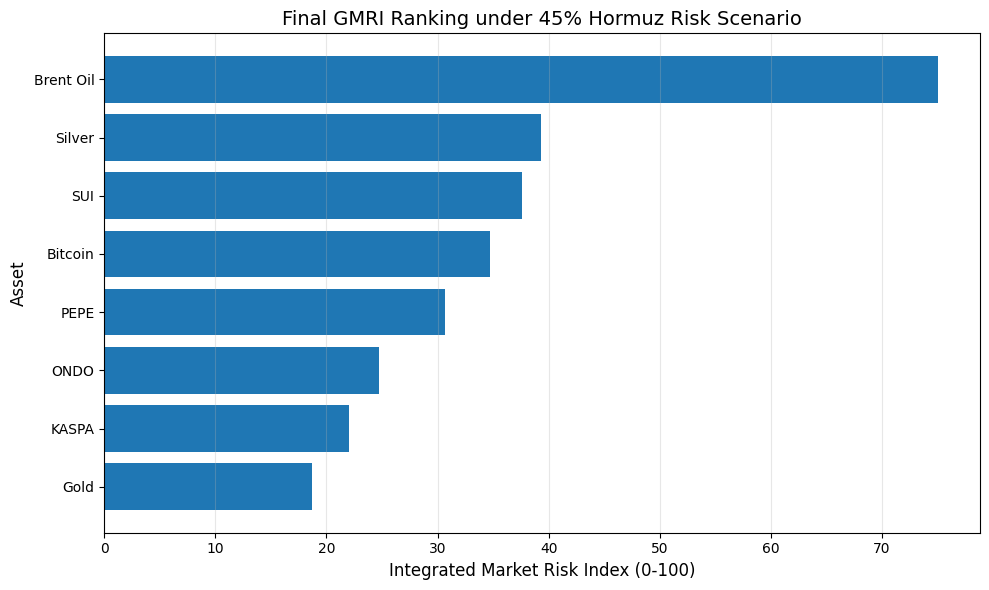

Final GMRI figure saved.


In [182]:
import matplotlib.pyplot as plt
import os


plt.figure(figsize=(10,6))


plt.barh(
    final_GMRI["Asset"],
    final_GMRI["GMRI_45"]
)


plt.xlabel(
    "Integrated Market Risk Index (0-100)",
    fontsize=12
)


plt.ylabel(
    "Asset",
    fontsize=12
)


plt.title(
    "Final GMRI Ranking under 45% Hormuz Risk Scenario",
    fontsize=14
)


plt.gca().invert_yaxis()


plt.grid(
    axis="x",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    "Risk_Calculation/Figure_7_Final_GMRI_Ranking.pdf",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print("Final GMRI figure saved.")

/kaggle/input/datasets/maryammoghaddasbayat/dbs-4dataset/swift_currency_tracker_research_ready_MAY_ADDED.xlsx /kaggle/working/swift_analysis_outputs
Sheets: ['Data_Summary', 'Cleaned_Data', 'report_month', 'data_month', 'source_report_name', 'metric', 'category', 'rmb_global_rank', 'notes', 'MAY2026_GlobalPayments', 'MAY2026_TradeFinance']
Data_Summary                        (15, 2)
Cleaned_Data                        (330, 10)
report_month                        (4, 2)
data_month                          (4, 2)
source_report_name                  (2, 2)
metric                              (8, 2)
category                            (5, 2)
rmb_global_rank                     (4, 2)
notes                               (29, 2)
MAY2026_GlobalPayments              (10, 3)
MAY2026_TradeFinance                (5, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------      

,report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,rmb_global_rank,notes,data_date,report_date
0,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,USD,50.49,%,NaN,Rank 1,2025-12-01,2026-01-01
1,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,EUR,21.90,%,NaN,Rank 2,2025-12-01,2026-01-01
2,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,GBP,6.73,%,NaN,Rank 3,2025-12-01,2026-01-01
3,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,CAD,3.44,%,NaN,Rank 4,2025-12-01,2026-01-01
4,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,JPY,3.42,%,NaN,Rank 5,2025-12-01,2026-01-01


,Measure,Result
0,Workbook sheets,11
1,Cleaned observations,330
2,Variables,10
3,Activity months,4
4,Metrics,8
5,Categories,5
6,Currencies/economies,48
7,Available numeric values,288
8,Missing numeric values,42
9,Exact duplicate rows,0


,Variable,Missing_Count,Completeness_%
0,report_month,0,100.0
1,data_month,0,100.0
2,source_report_name,0,100.0
3,metric,0,100.0
4,category,0,100.0
5,currency_or_economy,0,100.0
6,value,42,87.3
7,unit,42,87.3
8,rmb_global_rank,280,15.2
9,notes,24,92.7


,Metric,Observations
0,Global Payment Share,80
1,International Payment Share (ex-Eurozone),80
2,Offshore RMB by Economy,60
3,Trade Finance Share,40
4,FX Spot Currency Ranking,40
5,FX Spot Economies (RMB),24
6,RMB MoM Payment Growth,4
7,All Currencies MoM Payment Growth,2


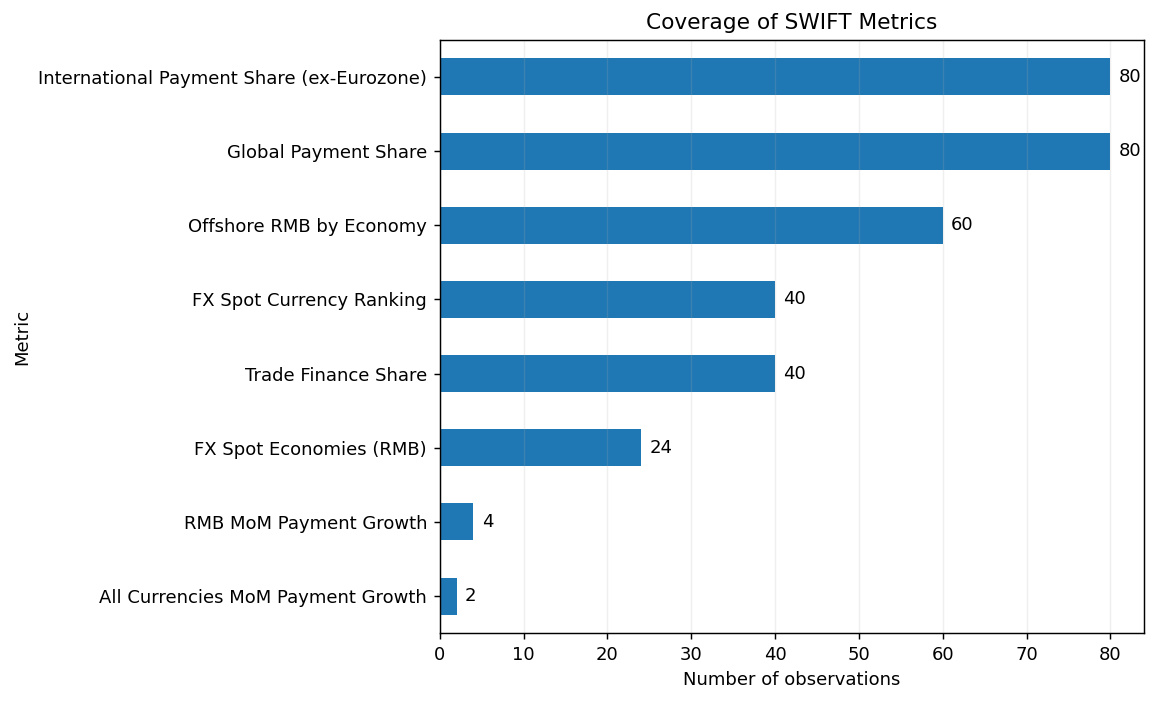

(345, 12) 2025-12-01 00:00:00 2026-04-01 00:00:00


metric              Global Payment Share                            \
currency_or_economy                  CNY    EUR   GBP   JPY    USD   
data_date                                                            
2025-12-01                          2.73  21.90  6.73  3.42  50.49   
2026-01-01                          3.13  22.36  6.91  3.44  49.68   
2026-02-01                          2.74  22.82  7.16  3.46  49.25   
2026-03-01                          3.10  21.30  6.54  3.53  51.14   
2026-04-01                          2.85  21.60  6.95  3.82  50.61   

metric              International Payment Share (ex-Eurozone)               \
currency_or_economy                                       CNY    EUR   GBP   
data_date                                                                    
2025-12-01                                               2.13  13.68  5.21   
2026-01-01                                               2.42  13.54  5.30   
2026-02-01                                               2.16  14.07  5.68   
2026-03-01                                               2.44  13.49  5.00   
2026-04-01                                                NaN    NaN   NaN   

metric                           Trade Finance Share                     
currency_or_economy   JPY    USD                 CNY   EUR   JPY    USD  
data_date                                                                
2025-12-01           5.02  58.62                8.30  6.73  1.36  79.53  
2026-01-01           5.01  58.83                8.46  5.57  1.31  80.70  
2026-02-01           5.11  57.49                5.90  6.02  1.56  81.96  
2026-03-01           5.32  58.50                8.04  5.78  1.38  80.73  
2026-04-01            NaN    NaN                5.99  6.03  1.08  82.74

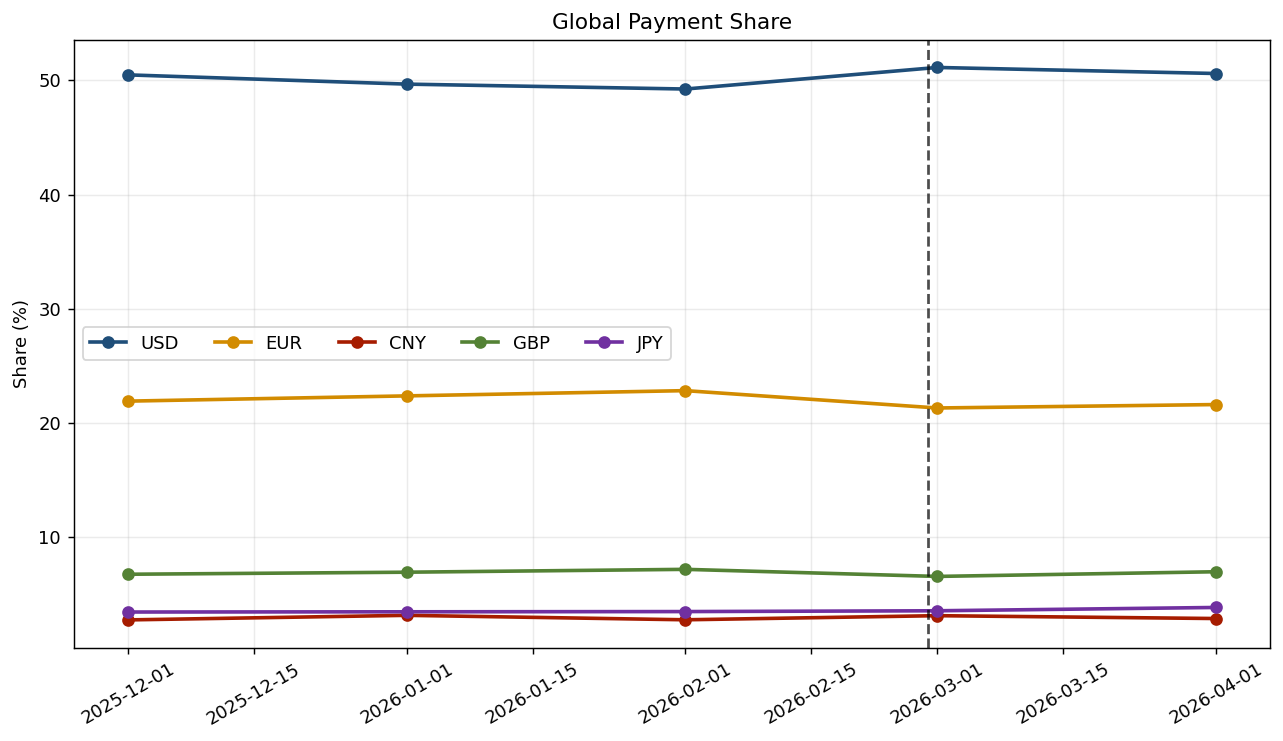

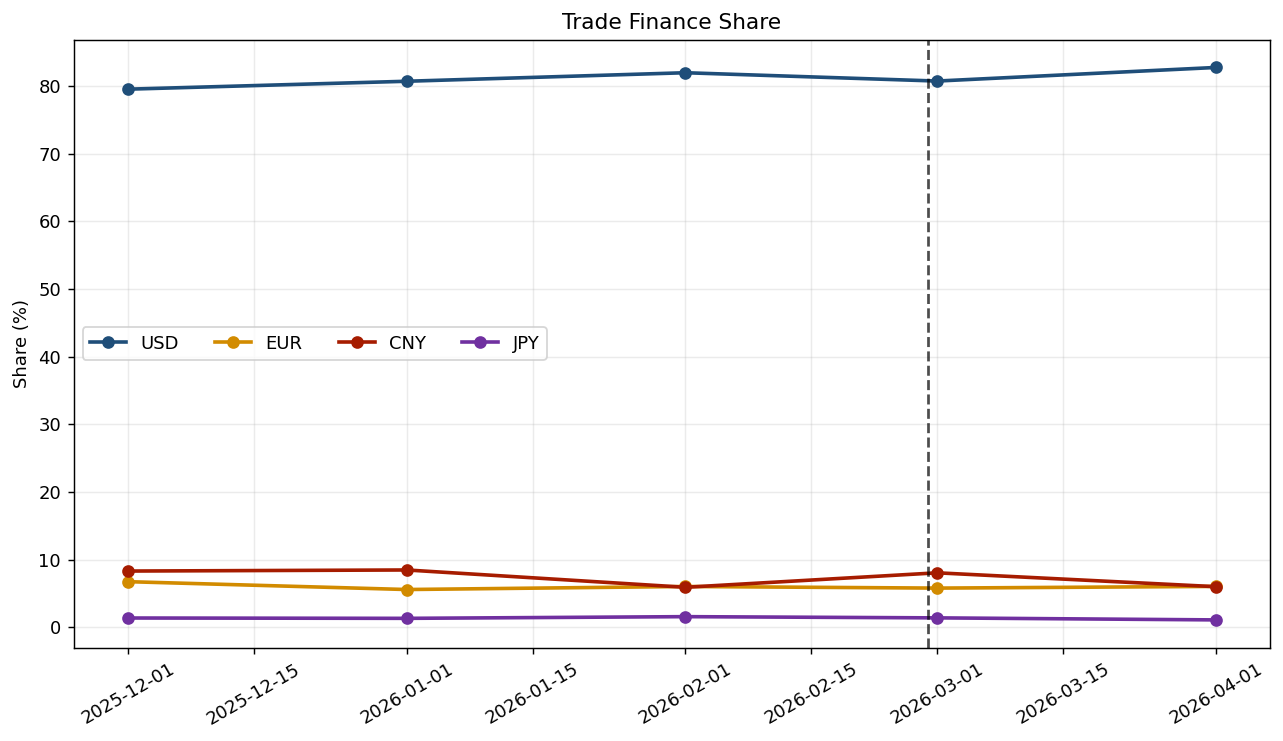

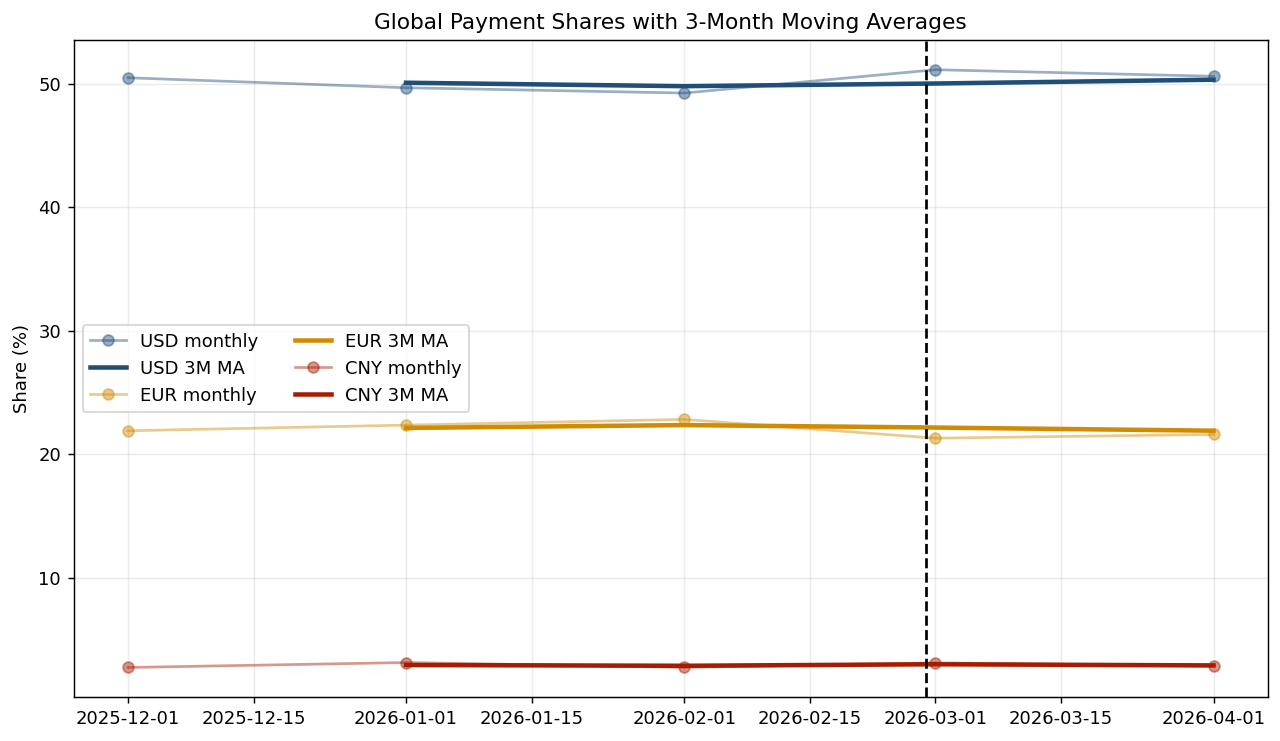

,Metric,Currency,Latest_Month,Latest_Value_%,Latest_3M_MA_%
0,Global Payment Share,USD,2026-04-01,50.61,50.33
1,Global Payment Share,EUR,2026-04-01,21.60,21.91
2,Global Payment Share,CNY,2026-04-01,2.85,2.90


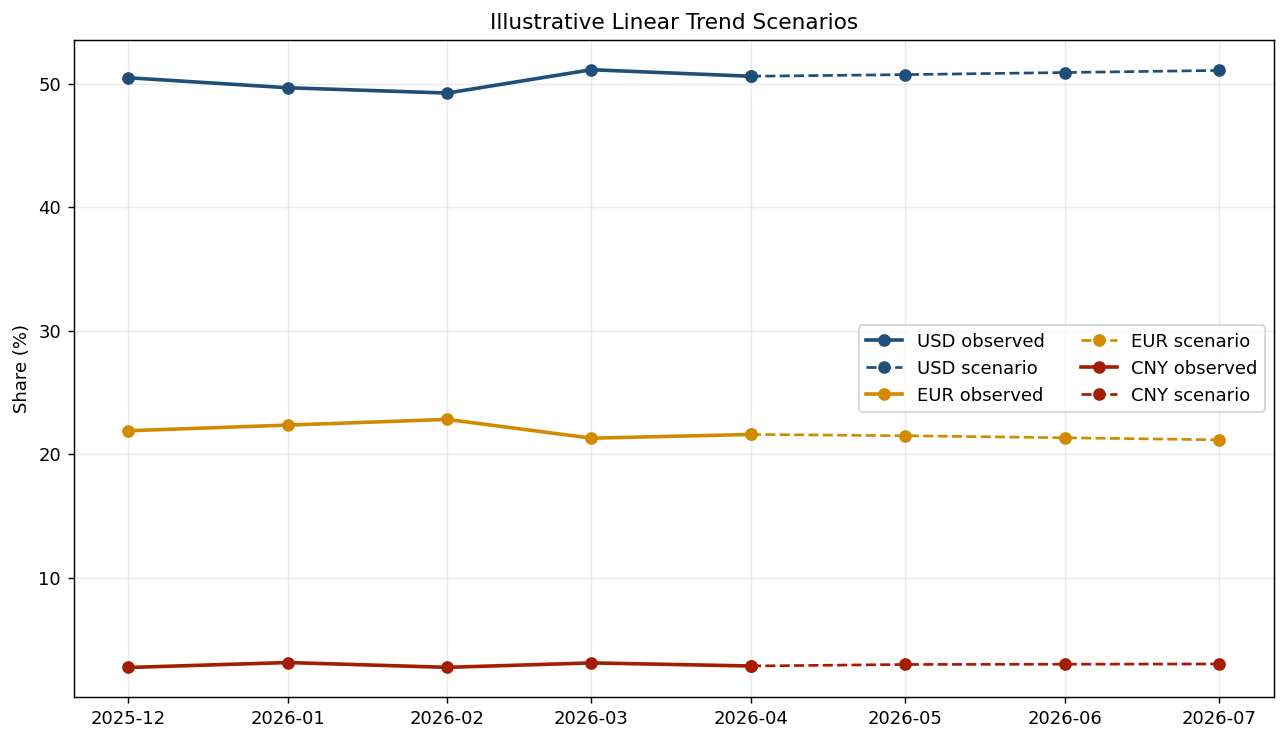

,Metric,Currency,Forecast_Month,Illustrative_Forecast_%,Monthly_Trend_pp,In_Sample_R2
0,Global Payment Share,USD,2026-05-01,50.744,0.170,0.125
1,Global Payment Share,USD,2026-06-01,50.914,0.170,0.125
2,Global Payment Share,USD,2026-07-01,51.084,0.170,0.125
3,Global Payment Share,EUR,2026-05-01,21.498,-0.166,0.188
4,Global Payment Share,EUR,2026-06-01,21.332,-0.166,0.188
5,Global Payment Share,EUR,2026-07-01,21.166,-0.166,0.188
6,Global Payment Share,CNY,2026-05-01,2.973,0.021,0.030
7,Global Payment Share,CNY,2026-06-01,2.994,0.021,0.030
8,Global Payment Share,CNY,2026-07-01,3.015,0.021,0.030


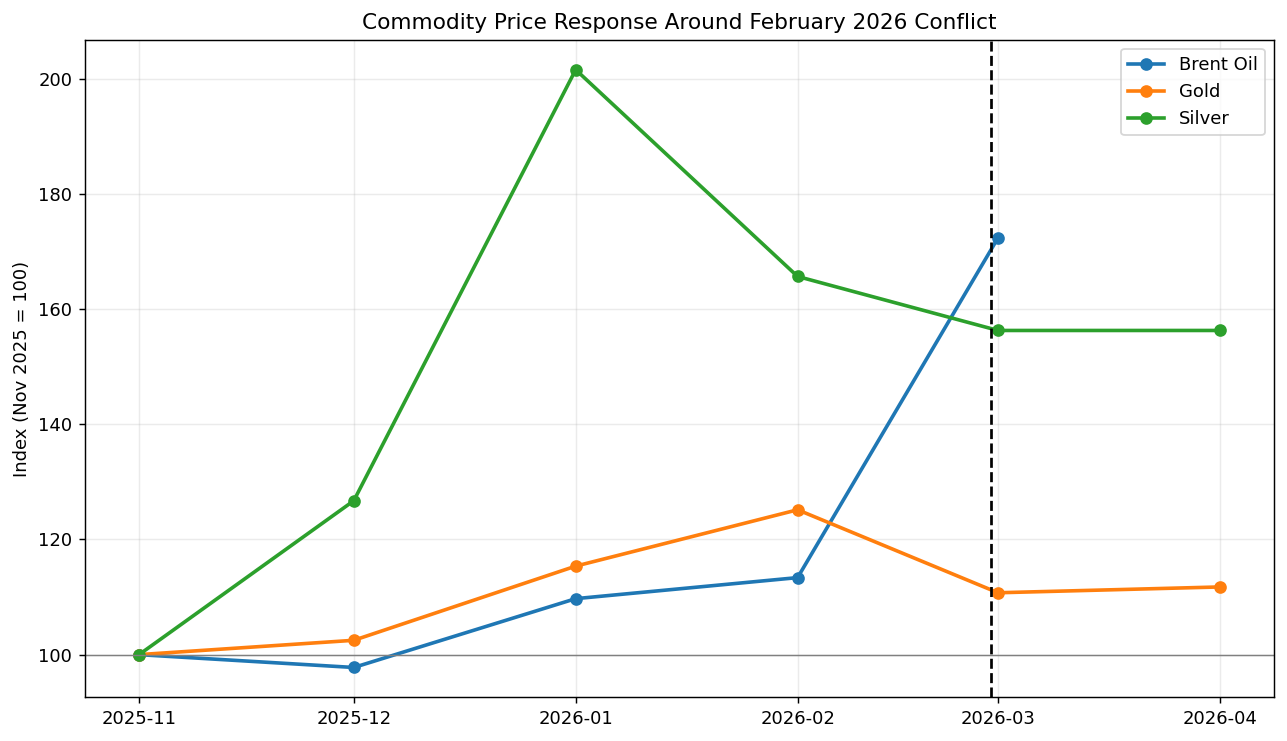

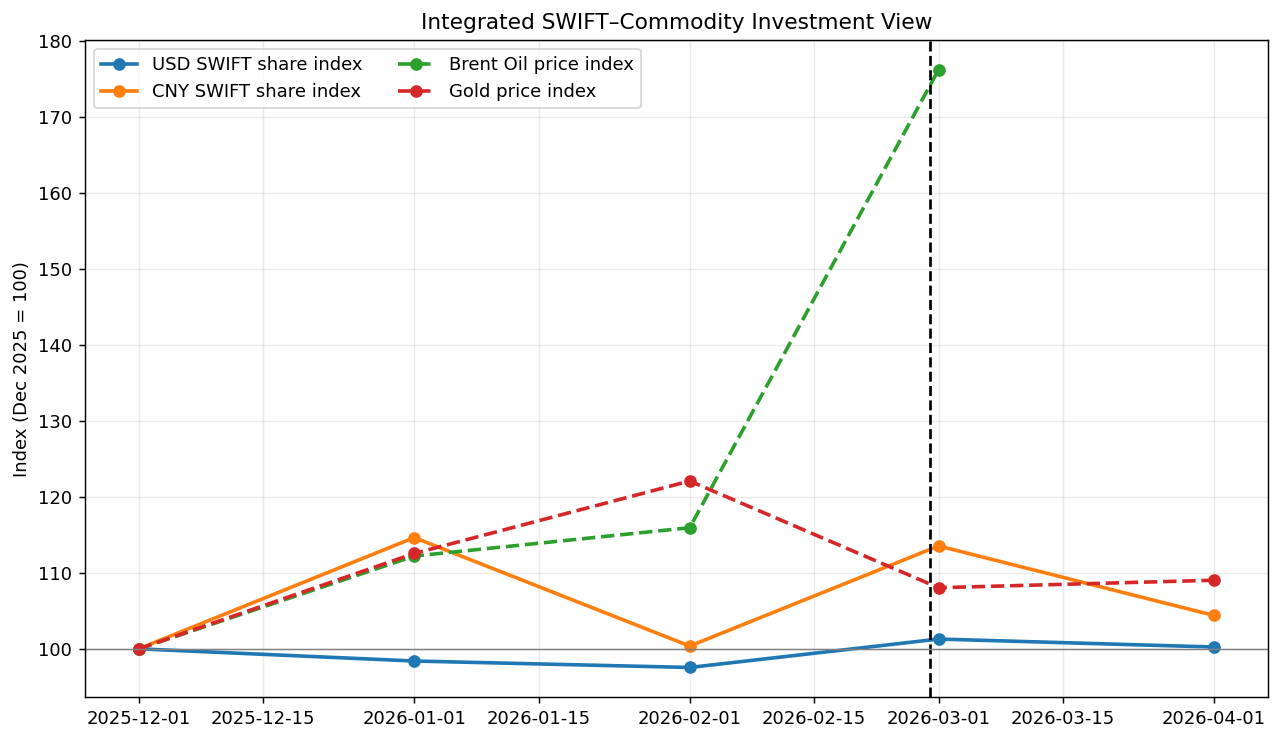

,Date,Event,Type
0,2025-06-13,Twelve-Day War begins,war_onset
1,2025-06-24,Iran-Israel ceasefire,ceasefire
2,2026-02-28,2026 war begins,war_onset
3,2026-03-01,Hormuz disruption period,shipping_shock
4,2026-06-15,Preliminary ceasefire/de-escalation arrangement,ceasefire
5,2026-06-26,Renewed US strikes after tanker incident,renewed_escalation
6,2026-07-07,New US-Iran strikes,renewed_escalation
7,2026-07-11,Iran claims Hormuz closed,shipping_shock


,data_date,post_2026_war,hormuz_period
0,2025-12-01,0,0
83,2026-01-01,0,0
248,2026-02-01,0,0
166,2026-03-01,1,1
330,2026-04-01,1,1


Only 5 observations are available. Collect at least 12–24 months before formal forecast validation.
Created: /kaggle/working/swift_analysis_outputs.zip


In [183]:
# Comprehensive SWIFT Currency Tracker Analysis
# Kaggle-ready Python script generated from the validated notebook.


# %% [markdown]
# # Comprehensive SWIFT Currency Tracker Analysis
# 
# This Kaggle-ready notebook audits the workbook, integrates the May 2026 supplements, produces every report table and figure, examines geopolitical event windows, calculates moving averages, and creates clearly labelled **illustrative** trend scenarios.
# 
# **Important:** the available SWIFT activity history is very short. Forecasts are scenarios, not validated investment predictions.


# %%
# Cell 2
# 1. Imports and Kaggle path discovery
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

plt.rcParams.update({"figure.dpi": 130, "savefig.bbox": "tight"})

# Works in Kaggle and locally. It searches recursively for the files.
roots = [Path('/kaggle/input'), Path('/kaggle/working'), Path('/mnt/data/swift_extract'), Path('.')]
def find_file(filename):
    for root in roots:
        if root.exists():
            hits = list(root.rglob(filename))
            if hits:
                return hits[0]
    raise FileNotFoundError(filename)

xlsx_path = find_file('swift_currency_tracker_research_ready_MAY_ADDED.xlsx')
brent_path = find_file('Brent Oil.csv')
gold_path = find_file('Gold 100years.csv')
silver_path = find_file('silver 100 years.csv')

OUTPUT = Path('/kaggle/working/swift_analysis_outputs') if Path('/kaggle/working').exists() else Path('swift_analysis_outputs')
FIG = OUTPUT/'figures'; TAB = OUTPUT/'tables'
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)
print(xlsx_path, OUTPUT)


# %%
# Cell 3
# 2. Load all workbook sheets and inspect organisation
excel = pd.ExcelFile(xlsx_path)
print('Sheets:', excel.sheet_names)
for sheet in excel.sheet_names:
    df = pd.read_excel(xlsx_path, sheet_name=sheet)
    print(f'{sheet:35s} {df.shape}')


# %%
# Cell 4
# 3. Load and clean the main SWIFT table
clean = pd.read_excel(xlsx_path, sheet_name='Cleaned_Data')
clean['data_date'] = pd.to_datetime(clean['data_month'], format='%B %Y', errors='coerce')
clean['report_date'] = pd.to_datetime(clean['report_month'], format='%B %Y', errors='coerce')
clean.info()
display(clean.head())


# %%
# Cell 5
# 4. Dataset audit table
summary = pd.DataFrame({
    'Measure':['Workbook sheets','Cleaned observations','Variables','Activity months','Metrics','Categories','Currencies/economies','Available numeric values','Missing numeric values','Exact duplicate rows'],
    'Result':[len(excel.sheet_names),len(clean),10,clean.data_date.nunique(),clean.metric.nunique(),clean.category.nunique(),clean.currency_or_economy.nunique(),clean.value.notna().sum(),clean.value.isna().sum(),clean.duplicated().sum()]
})
display(summary)
summary.to_csv(TAB/'Table_1_Dataset_Audit.csv', index=False)


# %%
# Cell 6
# 5. Missingness and metric coverage tables
missing = pd.DataFrame({'Variable': clean.columns[:10],
                        'Missing_Count':[clean[c].isna().sum() for c in clean.columns[:10]],
                        'Completeness_%':[100*(1-clean[c].isna().mean()) for c in clean.columns[:10]]})
metric_counts = clean.metric.value_counts().rename_axis('Metric').reset_index(name='Observations')
display(missing.round(1)); display(metric_counts)
missing.to_csv(TAB/'Table_3_Missingness.csv',index=False)
metric_counts.to_csv(TAB/'Table_2_Metric_Coverage.csv',index=False)


# %%
# Cell 7
# 6. Figure: metric coverage
m = metric_counts.sort_values('Observations')
ax = m.plot.barh(x='Metric', y='Observations', figsize=(9,5.5), legend=False, title='Coverage of SWIFT Metrics')
ax.set_xlabel('Number of observations'); ax.grid(axis='x',alpha=.2)
for i,v in enumerate(m.Observations): ax.text(v+1,i,str(v),va='center')
plt.tight_layout(); plt.savefig(FIG/'Figure_2_Metric_Coverage.png',dpi=220); plt.show()


# %%
# Cell 8
# 7. Integrate April 2026 activity from the May supplemental sheets
gp_may = pd.read_excel(xlsx_path, sheet_name='MAY2026_GlobalPayments')
tf_may = pd.read_excel(xlsx_path, sheet_name='MAY2026_TradeFinance')
def supplemental(df, metric):
    return pd.DataFrame({'report_month':'May 2026','data_month':'April 2026','source_report_name':'Global Currency Tracker',
        'metric':metric,'category':'Currency Ranking','currency_or_economy':df.Currency,'value':df['Share_%'],'unit':'%',
        'rmb_global_rank':np.where(df.Currency.eq('CNY'),df.Rank,np.nan),'notes':'Rank '+df.Rank.astype(str),
        'data_date':pd.Timestamp('2026-04-01'),'report_date':pd.Timestamp('2026-05-01')})
analysis_data = pd.concat([clean, supplemental(gp_may,'Global Payment Share'), supplemental(tf_may,'Trade Finance Share')],ignore_index=True)
analysis_data = analysis_data.drop_duplicates(['data_date','metric','currency_or_economy','value'])
print(analysis_data.shape, analysis_data.data_date.min(), analysis_data.data_date.max())


# %%
# Cell 9
# 8. Key SWIFT shares table
major = ['USD','EUR','CNY','GBP','JPY']
metrics = ['Global Payment Share','Trade Finance Share','International Payment Share (ex-Eurozone)']
key = analysis_data[analysis_data.metric.isin(metrics) & analysis_data.currency_or_economy.isin(major)]
key_table = key.pivot_table(index='data_date',columns=['metric','currency_or_economy'],values='value',aggfunc='first').sort_index()
display(key_table.round(2))
key_table.to_csv(TAB/'Table_4_Key_SWIFT_Shares.csv')


# %%
# Cell 10
# 9. Figures: global payment and trade-finance shares
colors={'USD':'#1f4e79','EUR':'#d28b00','CNY':'#a61c00','GBP':'#548235','JPY':'#7030a0'}
for metric,filename in [('Global Payment Share','Figure_3_Global_Payment_Shares.png'),('Trade Finance Share','Figure_4_Trade_Finance_Shares.png')]:
    fig,ax=plt.subplots(figsize=(10,5.8))
    for curr in major:
        s=key[(key.metric==metric)&(key.currency_or_economy==curr)].set_index('data_date').value.sort_index().dropna()
        if len(s): ax.plot(s.index,s,marker='o',lw=2,label=curr,color=colors[curr])
    ax.axvline(pd.Timestamp('2026-02-28'),ls='--',color='black',alpha=.7)
    ax.set_ylabel('Share (%)'); ax.set_title(metric); ax.legend(ncol=5); ax.grid(alpha=.25); ax.tick_params(axis='x',rotation=30)
    plt.tight_layout(); plt.savefig(FIG/filename,dpi=220); plt.show()


# %%
# Cell 11
# 10. Rolling and moving-average analysis
fig,ax=plt.subplots(figsize=(10,5.8))
ma_rows=[]
for curr in ['USD','EUR','CNY']:
    s=key[(key.metric=='Global Payment Share')&(key.currency_or_economy==curr)].set_index('data_date').value.sort_index().dropna()
    ma=s.rolling(3,min_periods=2).mean()
    ax.plot(s.index,s,marker='o',alpha=.45,color=colors[curr],label=f'{curr} monthly')
    ax.plot(ma.index,ma,lw=2.5,color=colors[curr],label=f'{curr} 3M MA')
    ma_rows.append(['Global Payment Share',curr,s.index[-1],s.iloc[-1],ma.iloc[-1]])
ax.axvline(pd.Timestamp('2026-02-28'),ls='--',color='black'); ax.set_ylabel('Share (%)'); ax.set_title('Global Payment Shares with 3-Month Moving Averages'); ax.grid(alpha=.25); ax.legend(ncol=2)
plt.tight_layout(); plt.savefig(FIG/'Figure_5_Moving_Averages.png',dpi=220); plt.show()
ma_table=pd.DataFrame(ma_rows,columns=['Metric','Currency','Latest_Month','Latest_Value_%','Latest_3M_MA_%'])
display(ma_table.round(2)); ma_table.to_csv(TAB/'Table_6_Moving_Averages.csv',index=False)


# %%
# Cell 12
# 11. Illustrative linear trend scenario (not a validated forecast)
fig,ax=plt.subplots(figsize=(10,5.8)); forecast_rows=[]
for curr in ['USD','EUR','CNY']:
    s=key[(key.metric=='Global Payment Share')&(key.currency_or_economy==curr)].set_index('data_date').value.sort_index().dropna()
    X=np.arange(len(s)).reshape(-1,1); model=LinearRegression().fit(X,s.values)
    future_dates=pd.date_range(s.index[-1]+pd.offsets.MonthBegin(1),periods=3,freq='MS')
    pred=model.predict(np.arange(len(s),len(s)+3).reshape(-1,1))
    ax.plot(s.index,s,marker='o',lw=2,color=colors[curr],label=f'{curr} observed')
    ax.plot([s.index[-1],*future_dates],[s.iloc[-1],*pred],ls='--',marker='o',color=colors[curr],label=f'{curr} scenario')
    for d,v in zip(future_dates,pred): forecast_rows.append(['Global Payment Share',curr,d,v,model.coef_[0],model.score(X,s.values)])
ax.set_ylabel('Share (%)'); ax.set_title('Illustrative Linear Trend Scenarios'); ax.grid(alpha=.25); ax.legend(ncol=2)
plt.tight_layout(); plt.savefig(FIG/'Figure_6_Trend_Scenarios.png',dpi=220); plt.show()
forecast_table=pd.DataFrame(forecast_rows,columns=['Metric','Currency','Forecast_Month','Illustrative_Forecast_%','Monthly_Trend_pp','In_Sample_R2'])
display(forecast_table.round(3)); forecast_table.to_csv(TAB/'Table_7_Illustrative_Trend_Forecast.csv',index=False)


# %%
# Cell 13
# 12. Load commodity datasets for investment-context analysis
def load_commodity(path):
    d=pd.read_csv(path); d['Date']=pd.to_datetime(d.Date,format='%m/%d/%Y',errors='coerce'); d['Value']=pd.to_numeric(d.Value,errors='coerce'); return d.dropna().sort_values('Date')
commodities={'Brent Oil':load_commodity(brent_path),'Gold':load_commodity(gold_path),'Silver':load_commodity(silver_path)}
{key:(value.Date.min(),value.Date.max(),len(value)) for key,value in commodities.items()}


# %%
# Cell 14
# 13. Commodity event-window figure
fig,ax=plt.subplots(figsize=(10,5.8))
for label,d in commodities.items():
    w=d[(d.Date>='2025-11-01')&(d.Date<='2026-04-01')].copy(); w['Index']=100*w.Value/w.Value.iloc[0]
    ax.plot(w.Date,w.Index,marker='o',lw=2,label=label)
ax.axvline(pd.Timestamp('2026-02-28'),ls='--',color='black'); ax.axhline(100,color='grey',lw=.8)
ax.set_ylabel('Index (Nov 2025 = 100)'); ax.set_title('Commodity Price Response Around February 2026 Conflict'); ax.legend(); ax.grid(alpha=.25)
plt.tight_layout(); plt.savefig(FIG/'Figure_7_Commodity_Event_Window.png',dpi=220); plt.show()


# %%
# Cell 15
# 14. Integrated SWIFT–commodity investment figure
fig,ax=plt.subplots(figsize=(10,5.8))
for curr in ['USD','CNY']:
    s=key[(key.metric=='Global Payment Share')&(key.currency_or_economy==curr)].set_index('data_date').value.sort_index().dropna(); idx=100*s/s.iloc[0]
    ax.plot(idx.index,idx,marker='o',lw=2,label=f'{curr} SWIFT share index')
for label in ['Brent Oil','Gold']:
    d=commodities[label][(commodities[label].Date>='2025-12-01')&(commodities[label].Date<='2026-04-01')].set_index('Date').Value; idx=100*d/d.iloc[0]
    ax.plot(idx.index,idx,marker='o',lw=2,ls='--',label=f'{label} price index')
ax.axvline(pd.Timestamp('2026-02-28'),ls='--',color='black'); ax.axhline(100,color='grey',lw=.8)
ax.set_ylabel('Index (Dec 2025 = 100)'); ax.set_title('Integrated SWIFT–Commodity Investment View'); ax.legend(ncol=2); ax.grid(alpha=.25)
plt.tight_layout(); plt.savefig(FIG/'Figure_8_Integrated_SWIFT_Commodities.png',dpi=220); plt.show()


# %%
# Cell 16
# 15. Geopolitical event table and event dummies
events = pd.DataFrame([
['2025-06-13','Twelve-Day War begins','war_onset'],['2025-06-24','Iran-Israel ceasefire','ceasefire'],
['2026-02-28','2026 war begins','war_onset'],['2026-03-01','Hormuz disruption period','shipping_shock'],
['2026-06-15','Preliminary ceasefire/de-escalation arrangement','ceasefire'],['2026-06-26','Renewed US strikes after tanker incident','renewed_escalation'],
['2026-07-07','New US-Iran strikes','renewed_escalation'],['2026-07-11','Iran claims Hormuz closed','shipping_shock']],columns=['Date','Event','Type'])
events['Date']=pd.to_datetime(events.Date); display(events)
events.to_csv(TAB/'Table_8_Event_Timeline.csv',index=False)
# Monthly dummies (extend after new SWIFT releases arrive)
monthly=analysis_data[['data_date']].drop_duplicates().sort_values('data_date').copy()
monthly['post_2026_war']=monthly.data_date.ge('2026-03-01').astype(int)
monthly['hormuz_period']=monthly.data_date.ge('2026-03-01').astype(int)
display(monthly)


# %%
# Cell 17
# 16. Optional future method: time-series cross-validation after at least 12–24 observations
# This code intentionally stops if history is too short.
from sklearn.metrics import mean_absolute_error, mean_squared_error
series = key[(key.metric=='Global Payment Share')&(key.currency_or_economy=='USD')].set_index('data_date').value.sort_index().dropna()
if len(series) < 12:
    print(f'Only {len(series)} observations are available. Collect at least 12–24 months before formal forecast validation.')
else:
    train, test = series.iloc[:-3], series.iloc[-3:]
    naive = np.repeat(train.iloc[-1], len(test))
    print('Naive MAE:', mean_absolute_error(test,naive), 'RMSE:', mean_squared_error(test,naive,squared=False))


# %%
# Cell 18
# 17. Export all outputs as a ZIP
import shutil
zip_path = shutil.make_archive(str(OUTPUT), 'zip', root_dir=OUTPUT)
print('Created:', zip_path)

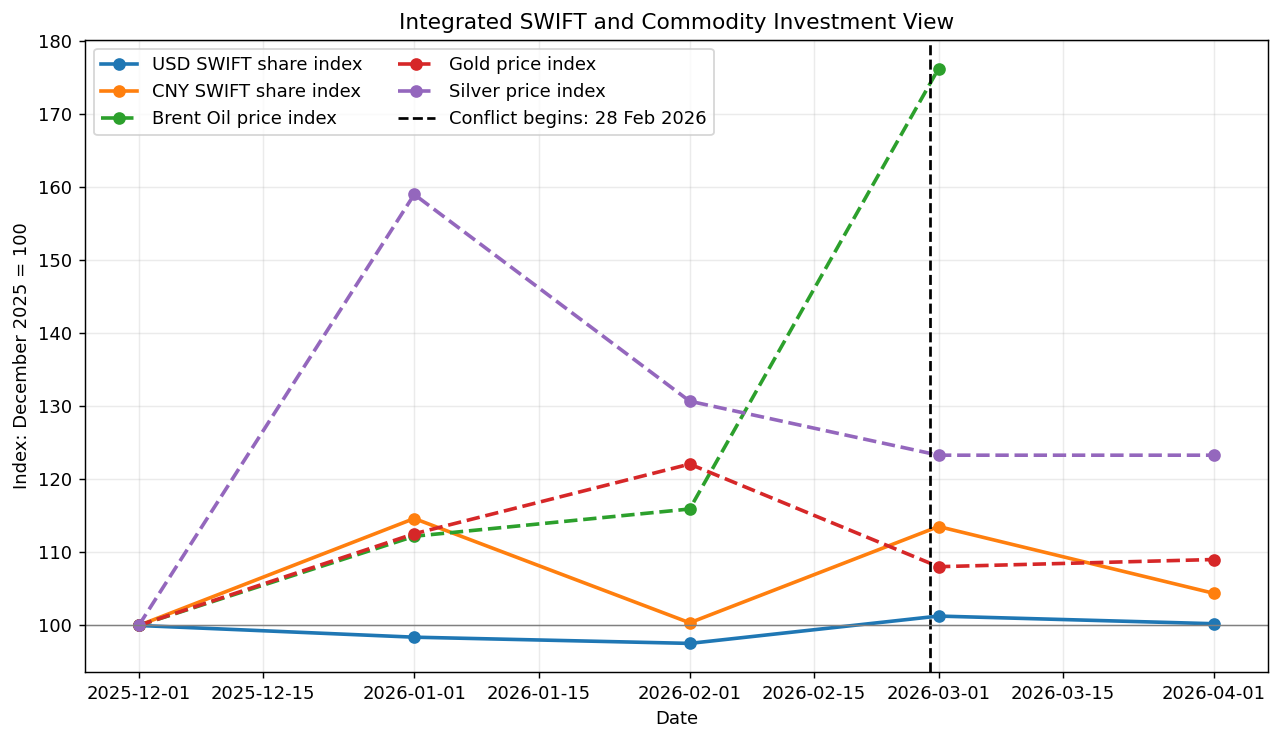

In [184]:
# 14. Integrated SWIFT–commodity investment figure

fig, ax = plt.subplots(figsize=(10, 5.8))

# SWIFT currency-share indices
for curr in ['USD', 'CNY']:
    s = (
        key[
            (key['metric'] == 'Global Payment Share') &
            (key['currency_or_economy'] == curr)
        ]
        .set_index('data_date')['value']
        .sort_index()
        .dropna()
    )

    idx = 100 * s / s.iloc[0]

    ax.plot(
        idx.index,
        idx,
        marker='o',
        linewidth=2,
        label=f'{curr} SWIFT share index'
    )

# Commodity price indices
for label in ['Brent Oil', 'Gold', 'Silver']:
    d = (
        commodities[label][
            (commodities[label]['Date'] >= '2025-12-01') &
            (commodities[label]['Date'] <= '2026-04-01')
        ]
        .set_index('Date')['Value']
        .sort_index()
        .dropna()
    )

    if d.empty:
        print(f'Warning: No observations available for {label}')
        continue

    idx = 100 * d / d.iloc[0]

    ax.plot(
        idx.index,
        idx,
        marker='o',
        linewidth=2,
        linestyle='--',
        label=f'{label} price index'
    )

# Event marker
ax.axvline(
    pd.Timestamp('2026-02-28'),
    linestyle='--',
    color='black',
    label='Conflict begins: 28 Feb 2026'
)

ax.axhline(100, color='grey', linewidth=0.8)

ax.set_ylabel('Index: December 2025 = 100')
ax.set_xlabel('Date')
ax.set_title('Integrated SWIFT and Commodity Investment View')

ax.legend(ncol=2)
ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIG / 'Figure_8_Integrated_SWIFT_Commodities.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    FIG / 'Figure_8_Integrated_SWIFT_Commodities.pdf',
    bbox_inches='tight'
)

plt.show()